# 05 — 集合竞价供需、订单信息与价格形成：09:30→09:35收益率研究

## 最终研究问题

本 notebook 只回答一个最终问题：

> **利用09:30及此前可见的集合竞价、逐笔委托、撤单、成交与盘口信息，能否预测股票09:30→09:35的严格五分钟收益率？**

严格标签固定为：

$$
future\_return\_{5m}=
\frac{mid_{09:35}}{mid_{09:30}}-1
$$

`strict_opening_depth_imbalance_5` 仍是重要基准，但不预设为最终主因子。研究允许得到四种结论：

1. 原始Opening Imbalance仍是最佳方向因子；
2. 经过形成机制修正后的Opening Pressure优于原始A；
3. 新订单流或价格形成因子替代A；
4. 多个经济上独立的因子共同提供最稳定的OOS预测。

## 研究原则

- 所有特征必须在09:30及以前可得；
- 描述性全样本结果只用于提出机制，不用于证明最终有效；
- 最终晋级必须依靠同日期、同股票池的chronological rolling OOS比较；
- 论文是机制与构造方法来源，不按论文名称机械建立因子树；
- 不把大单直接称为机构，不把高参与度直接解释为高方向置信度；
- 在增加模型复杂度前，优先提高因子的经济含义和独立信息。


## Notebook Index（精简正式版）

### A. 数据、标签与基础筛选

1. [Part I — 数据、股票池与时间规范](#part-i-数据股票池与时间规范)
2. [Part II — 严格开盘样本与集合竞价特征](#part-ii-严格开盘样本与集合竞价特征)
3. [Part III — 严格09:30→09:35标签](#part-iii-严格-09300935-标签)
4. [Part IV — 特征可得性与泄漏检查](#part-iv-预测时点可得因子与泄漏检查)
5. [Part V — 基础因子统一排名](#part-v-基础因子统一排名)

### B. 当前正式研究主线

6. [Part VI — 隔夜价格路径与订单可信度](#part-vi-price-path-and-overnight-sentiment)
7. [Part VII — 开盘前价格发现与信息吸收残差](#part-vii-pre-opening-price-discovery-and-information-absorption)
8. [Part VIII — WPC与开盘价格无偏性](#part-viii-wpc-and-opening-price-unbiasedness)

```text
严格数据与标签
→ 基础因子筛选
→ 隔夜信息和订单表达
→ 09:30价格吸收
→ 09:30-09:35剩余信息或价格修正
```

此前的A/B/C/D因子树、固定500k实验、Direction-Magnitude合成和重复模型比较均已移入自动备份，不再构成当前 notebook 的运行依赖。
9. [Part IX — 独立因子与机械五分钟收益预测](#part-ix-independent-factors-and-mechanical-five-minute-prediction)
- **Part X**：冻结 A 基准与 A+G 挑战者，完成强统计、失效诊断与股票池敏感性检验
- **Part XI**：A 动态可信度——竞价末段形成、撤单保留与竞价到开盘的传递状态
- **Part XII**：Opening-book residual 与 G 的独立性、增量及冲突状态检验
- **Part XIII**：G 来源拆解——市场/板块、历史异常、价格形成阶段与正负 gap 不对称


## 本次精简说明

### 当前唯一研究问题

> 使用严格09:30及之前可见的信息，预测09:30-09:35带符号收益率，并解释预测力来自信息延续、价格吸收不足还是开盘过度反应。

### 当前保留的经济变量角色

| 模块 | 代表变量 | 当前角色 |
|---|---|---|
| 开盘供需 | `strict_opening_depth_imbalance_5` | 当前方向基准，不预设为最终主因子 |
| 隔夜价格位置 | relative 09:30 gap及其reversal | 检验高开/低开后的短期修正 |
| 订单可信度 | committed、executed、cancellation variables | 判断情绪是否真实保留并成交 |
| 信息吸收 | expected gap与actual gap的residual | 价格形成机制诊断 |
| 定价效率 | WPC、rolling beta、opening RMSE | 判断信息吸收速度与质量 |

### 已归档内容

旧的静态bid/ask拆分、固定500k树、A1-A4多轮裂变、D1-D2、机械组合、Direction-Magnitude模型以及重复校准实验已经完成其诊断作用。它们没有被否定，而是从正式交付版中移除，完整保存在 `before_streamlining` 备份中。

### 运行规则

- Part I-V必须顺序运行并生成`factor_research_df`；
- Part VI自行读取Notebook 4导出的`04_information_transmission_features.csv`并生成`price_path_df`；
- Part VII和Part VIII只依赖Part VI及各自单元内定义的函数；
- 每个跨Part对象均有显式`assert`或文件存在性检查，避免静默使用旧kernel对象；
- 所有09:35或更晚价格只用于标签或事后价格发现评价，不进入09:30预测特征。


# Part I. 数据、股票池与时间规范

本部分只完成环境配置、研究股票池、`qtick`加载和严格时间字段准备。
所有特征必须在09:30决策时点已经可见。


In [1]:
from dataclasses import dataclass
from typing import Dict, Iterable, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

EPS = 1e-9


def safe_divide(a, b):
    """Element-wise division that returns NaN when the denominator is too small."""
    return np.where(np.abs(b) > EPS, a / b, np.nan)


def require_columns(df: pd.DataFrame, columns: Sequence[str], name: str = "DataFrame") -> None:
    """Fail early with an informative error when required columns are missing."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def cross_sectional_winsorize(
    df: pd.DataFrame,
    columns: Sequence[str],
    group_cols: Sequence[str] = ("date", "minute"),
    lower_q: float = 0.01,
    upper_q: float = 0.99,
) -> pd.DataFrame:
    """Winsorize features within each date-minute cross-section without using future data."""
    result = df.copy()

    for col in columns:
        if col not in result.columns:
            continue

        lower = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(lower_q)
        )
        upper = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(upper_q)
        )
        result[col] = result[col].clip(lower=lower, upper=upper)

    return result


In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.ddb_client import connect_ddb

session = connect_ddb()


In [3]:
@dataclass(frozen=True)
class Config:
    # Data source
    DB_PATH: str = "dfs://quota"

    # QUICK_MODE preserves the original short sample for fast iteration.
    # Set QUICK_MODE=False for the extended research run.
    QUICK_MODE: bool = False

    QUICK_START_DATE: str = "2026.03.11"
    RESEARCH_START_DATE: str = "2026.01.01"
    END_DATE: str = "2026.04.10"

    START_TIME: str = "09:29:45"
    END_TIME: str = "09:36:00"

    QUICK_N_STOCKS: int = 30
    RESEARCH_N_STOCKS: int = 40

    RANDOM_STATE: int = 42
    HORIZON_MINUTES: int = 5
    ROLLING_WINDOW: int = 20

    RF_PARAMS: Optional[Dict] = None
    XGB_PARAMS: Optional[Dict] = None

    @property
    def START_DATE(self) -> str:
        return self.QUICK_START_DATE if self.QUICK_MODE else self.RESEARCH_START_DATE

    @property
    def N_STOCKS(self) -> int:
        return self.QUICK_N_STOCKS if self.QUICK_MODE else self.RESEARCH_N_STOCKS


CFG = Config(
    RF_PARAMS={
        "n_estimators": 200,
        "max_depth": 5,
        "min_samples_leaf": 50,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1,
    },
    XGB_PARAMS={
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
    },
)

DB_PATH = CFG.DB_PATH
START_DATE = CFG.START_DATE
END_DATE = CFG.END_DATE
START_TIME = CFG.START_TIME
END_TIME = CFG.END_TIME
RANDOM_STATE = CFG.RANDOM_STATE
N_STOCKS = CFG.N_STOCKS
ROLLING_WINDOW = CFG.ROLLING_WINDOW
HORIZON_MINUTES = CFG.HORIZON_MINUTES

print("Mode:", "QUICK" if CFG.QUICK_MODE else "EXTENDED RESEARCH")
print("Database:", DB_PATH)
print("Sample period:", START_DATE, "to", END_DATE)
print("Intraday window:", START_TIME, "to", END_TIME)
print("N_STOCKS:", N_STOCKS)
print("Rolling window:", ROLLING_WINDOW, "trading days")
print("Prediction horizon:", HORIZON_MINUTES, "minutes")


Mode: EXTENDED RESEARCH
Database: dfs://quota
Sample period: 2026.01.01 to 2026.04.10
Intraday window: 09:29:45 to 09:36:00
N_STOCKS: 40
Rolling window: 20 trading days
Prediction horizon: 5 minutes


## 1.1 统一研究样本


In [4]:
# ============================================================
# Unified A-share Stock Universe (shared by File 4 and File 5)
# ============================================================
# qtick has no separate security master. We therefore use two independent
# filters: (1) dtype == 1 from qtick, and (2) an exchange-aware A-share code
# whitelist. A prefix alone is unsafe: e.g. 000170.SH is an index, not SZ Main.

POOL_START_DATE = START_DATE
POOL_END_DATE = END_DATE
POOL_RANDOM_STATE = RANDOM_STATE
MIN_QTICK_DATES = 55

BOARD_SAMPLE_PLAN = {
    "SZ Main": 12,
    "SH Main": 12,
    "ChiNext": 8,
    "STAR": 8,
}

universe_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select distinct code, date, dtype, name
from qtick
where date >= {POOL_START_DATE}
  and date <= {POOL_END_DATE}
  and dtype = 1
  and (
        code like "000%.SZ"
        or code like "001%.SZ"
        or code like "002%.SZ"
        or code like "003%.SZ"
        or code like "300%.SZ"
        or code like "301%.SZ"
        or code like "600%.SH"
        or code like "601%.SH"
        or code like "603%.SH"
        or code like "605%.SH"
        or code like "688%.SH"
      )
order by code, date
"""

universe_daily = session.run(universe_script)
universe_daily["code"] = (
    universe_daily["code"].astype(str).str.strip().str.upper()
)


def classify_a_share_board(code):
    """Exchange-aware whitelist for ordinary Shanghai/Shenzhen A shares."""
    code = str(code).strip().upper()
    if code.endswith(".SZ") and code[:3] in {"000", "001", "002", "003"}:
        return "SZ Main"
    if code.endswith(".SZ") and code[:3] in {"300", "301"}:
        return "ChiNext"
    if code.endswith(".SH") and code[:3] in {"600", "601", "603", "605"}:
        return "SH Main"
    if code.endswith(".SH") and code[:3] == "688":
        return "STAR"
    return None


universe_daily["board"] = universe_daily["code"].map(classify_a_share_board)

stock_coverage = (
    universe_daily
    .groupby(["code", "board"], as_index=False)
    .agg(
        name=("name", "first"),
        dtype=("dtype", "first"),
        n_qtick_dates=("date", "nunique"),
    )
)

eligible_pool = stock_coverage[
    stock_coverage["board"].notna()
    & stock_coverage["dtype"].eq(1)
    & stock_coverage["n_qtick_dates"].ge(MIN_QTICK_DATES)
].copy()

selected_parts = []
for board, n_target in BOARD_SAMPLE_PLAN.items():
    board_pool = eligible_pool[eligible_pool["board"].eq(board)].sort_values("code")
    if len(board_pool) < n_target:
        raise ValueError(
            f"Insufficient eligible {board} stocks: need {n_target}, found {len(board_pool)}"
        )
    selected_parts.append(
        board_pool.sample(n=n_target, random_state=POOL_RANDOM_STATE)
    )

stock_pool = (
    pd.concat(selected_parts, ignore_index=True)
    .sort_values(["board", "code"])
    .reset_index(drop=True)
)
sample_codes = stock_pool["code"].tolist()

# Fail loudly if a non-equity code can enter the modelling sample.
assert stock_pool["code"].is_unique
assert stock_pool["dtype"].eq(1).all()
assert stock_pool["board"].notna().all()
assert stock_pool["code"].map(classify_a_share_board).notna().all()
assert not stock_pool["code"].isin(["000001.SH", "399001.SZ", "399006.SZ"]).any()
assert not stock_pool["code"].str.startswith(
    ("159", "510", "511", "512", "513", "515", "516", "518", "588",
     "110", "113", "123", "127", "128")
).any()

codes_ddb = "[" + ",".join(f'"{code}"' for code in sample_codes) + "]"
code_filter = ",".join(f'"{code}"' for code in sample_codes)

print("Eligible ordinary A-share stocks:", len(eligible_pool))
print("Unified selected stocks:", len(sample_codes))
display(stock_pool.groupby("board").size().rename("n_stocks").to_frame())
display(stock_pool[["code", "name", "dtype", "board", "n_qtick_dates"]])



# ============================================================
# Three-table coverage validation for the unified stock pool
# ============================================================
coverage_queries = {
    "qtick": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qtick")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qorder": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qorder")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qknock": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qknock")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
}

coverage_parts = []
for table_name, query in coverage_queries.items():
    tmp = session.run(query)
    tmp["code"] = tmp["code"].astype(str).str.strip().str.upper()
    summary = tmp.groupby("code")["date"].nunique().rename(f"{table_name}_dates")
    coverage_parts.append(summary)

three_table_coverage = (
    stock_pool.set_index("code")[["name", "board"]]
    .join(coverage_parts, how="left")
    .fillna({"qtick_dates": 0, "qorder_dates": 0, "qknock_dates": 0})
    .reset_index()
)

for col in ["qtick_dates", "qorder_dates", "qknock_dates"]:
    three_table_coverage[col] = three_table_coverage[col].astype(int)

three_table_coverage["three_table_ready"] = (
    three_table_coverage[["qtick_dates", "qorder_dates", "qknock_dates"]]
    .min(axis=1)
    .ge(MIN_QTICK_DATES)
)

display(three_table_coverage)
assert three_table_coverage["three_table_ready"].all(), (
    "Some selected stocks lack sufficient qtick/qorder/qknock coverage. "
    "Inspect three_table_coverage before continuing."
)
print("Unified stock pool passed security-type, code-range and three-table coverage checks.")


Eligible ordinary A-share stocks: 5180
Unified selected stocks: 40


,n_stocks
board,
ChiNext,8
SH Main,12
STAR,8
SZ Main,12


,code,name,dtype,board,n_qtick_dates
0,300183.SZ,东软载波,1,ChiNext,63
1,300490.SZ,华自科技,1,ChiNext,63
2,300595.SZ,欧普康视,1,ChiNext,63
3,301052.SZ,果麦文化,1,ChiNext,63
4,301255.SZ,通力科技,1,ChiNext,63
5,301391.SZ,卡莱特,1,ChiNext,63
6,301552.SZ,科力装备,1,ChiNext,63
7,301622.SZ,英思特,1,ChiNext,63
8,600158.SH,中体产业,1,SH Main,63
9,600182.SH,S佳通,1,SH Main,63


,code,name,board,qtick_dates,qorder_dates,qknock_dates,three_table_ready
0,300183.SZ,东软载波,ChiNext,63,63,63,True
1,300490.SZ,华自科技,ChiNext,63,63,63,True
2,300595.SZ,欧普康视,ChiNext,63,63,63,True
3,301052.SZ,果麦文化,ChiNext,63,63,63,True
4,301255.SZ,通力科技,ChiNext,63,63,63,True
5,301391.SZ,卡莱特,ChiNext,63,63,63,True
6,301552.SZ,科力装备,ChiNext,63,63,63,True
7,301622.SZ,英思特,ChiNext,63,63,63,True
8,600158.SH,中体产业,SH Main,63,63,63,True
9,600182.SH,S佳通,SH Main,63,63,63,True


Unified stock pool passed security-type, code-range and three-table coverage checks.


## 1.2 加载 `qtick` 快照数据


In [5]:
# ============================================================
# Batched qtick Query for File 5
# ============================================================

qtick_cols = """
code, date, time,
new_price, pre_close,
bp0, ap0,
bv0, av0,
bv1, av1,
bv2, av2,
bv3, av3,
bv4, av4,
sum_volume, sum_amount
"""


def chunk_codes(codes, batch_size=10):
    for start in range(0, len(codes), batch_size):
        yield codes[start:start + batch_size]


qtick_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_codes_ddb = (
        "["
        + ",".join(
            f'"{code}"'
            for code in code_batch
        )
        + "]"
    )

    qtick_script = f"""
    select {qtick_cols}
    from loadTable("{DB_PATH}", "qtick")
    where code in {batch_codes_ddb}
      and date >= {START_DATE}
      and date <= {END_DATE}
      and time >= {START_TIME}.000
      and time <= {END_TIME}.000
    order by code, date, time
    """

    batch_df = session.run(qtick_script)
    qtick_parts.append(batch_df)

    print(
        f"File 5 qtick batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qtick = pd.concat(
    qtick_parts,
    ignore_index=True
)

print("qtick total shape:", qtick.shape)
display(qtick.head())


File 5 qtick batch 1: 10 stocks, 73520 rows
File 5 qtick batch 2: 10 stocks, 75341 rows
File 5 qtick batch 3: 10 stocks, 74401 rows
File 5 qtick batch 4: 10 stocks, 76007 rows
qtick total shape: (299269, 19)


,code,date,time,new_price,pre_close,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,300183.SZ,2026-01-05,1970-01-01 09:30:00,14.96,14.83,14.92,14.96,100,3100,2000,10000,100,1000,300,3200,1400,200,104800,1567017.0
1,300183.SZ,2026-01-05,1970-01-01 09:30:03,14.97,14.83,14.97,14.99,4900,10000,21400,15000,43000,5100,400,500,2700,2800,155400,2325004.0
2,300183.SZ,2026-01-05,1970-01-01 09:30:06,14.96,14.83,14.96,14.99,21700,11800,46900,15000,400,5100,3200,500,2500,2800,164500,2461201.0
3,300183.SZ,2026-01-05,1970-01-01 09:30:09,14.99,14.83,14.98,14.99,1100,8000,22100,15000,46900,5100,3500,2200,3000,500,169400,2534630.0
4,300183.SZ,2026-01-05,1970-01-01 09:30:12,14.98,14.83,14.96,14.98,22100,1300,46900,8000,3500,15000,3000,5100,1500,2200,170800,2555602.0


## 1.3 分钟级市场状态准备


In [6]:
qtick = qtick.copy()

date_str = pd.to_datetime(qtick["date"]).dt.strftime("%Y-%m-%d")

time_str = qtick["time"].astype(str)
time_str = (
    time_str
    .str.replace("1970-01-01 ", "", regex=False)
    .str.replace("1900-01-01 ", "", regex=False)
)

qtick["datetime"] = pd.to_datetime(
    date_str + " " + time_str,
    format="mixed"
)

qtick["time_clean"] = qtick["datetime"].dt.strftime("%H:%M:%S.%f")
qtick["time_clean"] = qtick["time_clean"].str.replace(".000000", "", regex=False)

qtick["minute"] = qtick["datetime"].dt.floor("min")

display(qtick[["code", "date", "time_clean", "datetime", "minute"]].head())


,code,date,time_clean,datetime,minute
0,300183.SZ,2026-01-05,09:30:00,2026-01-05 09:30:00,2026-01-05 09:30:00
1,300183.SZ,2026-01-05,09:30:03,2026-01-05 09:30:03,2026-01-05 09:30:00
2,300183.SZ,2026-01-05,09:30:06,2026-01-05 09:30:06,2026-01-05 09:30:00
3,300183.SZ,2026-01-05,09:30:09,2026-01-05 09:30:09,2026-01-05 09:30:00
4,300183.SZ,2026-01-05,09:30:12,2026-01-05 09:30:12,2026-01-05 09:30:00


In [7]:
qtick["bp0"] = pd.to_numeric(qtick["bp0"], errors="coerce").replace(0, np.nan)
qtick["ap0"] = pd.to_numeric(qtick["ap0"], errors="coerce").replace(0, np.nan)

qtick["mid_price"] = (qtick["bp0"] + qtick["ap0"]) / 2

display(qtick[["code", "date", "datetime", "bp0", "ap0", "mid_price"]].head())


,code,date,datetime,bp0,ap0,mid_price
0,300183.SZ,2026-01-05,2026-01-05 09:30:00,14.92,14.96,14.940
1,300183.SZ,2026-01-05,2026-01-05 09:30:03,14.97,14.99,14.980
2,300183.SZ,2026-01-05,2026-01-05 09:30:06,14.96,14.99,14.975
3,300183.SZ,2026-01-05,2026-01-05 09:30:09,14.98,14.99,14.985
4,300183.SZ,2026-01-05,2026-01-05 09:30:12,14.96,14.98,14.970


In [8]:
minute_panel = (
    qtick
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date", "minute"])
    .agg(
        mid_price=("mid_price", "last"),
        last_price=("new_price", "last"),
        pre_close=("pre_close", "last"),
        bp0=("bp0", "last"),
        ap0=("ap0", "last"),
        bv0=("bv0", "last"),
        av0=("av0", "last"),
        bv1=("bv1", "last"),
        av1=("av1", "last"),
        bv2=("bv2", "last"),
        av2=("av2", "last"),
        bv3=("bv3", "last"),
        av3=("av3", "last"),
        bv4=("bv4", "last"),
        av4=("av4", "last"),
        sum_volume=("sum_volume", "last"),
        sum_amount=("sum_amount", "last")
    )
    .reset_index()
)

minute_panel = minute_panel.sort_values(["code", "date", "minute"])

print("minute_panel shape:", minute_panel.shape)
display(minute_panel.head())


minute_panel shape: (16768, 20)


,code,date,minute,mid_price,last_price,pre_close,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.625,6.63,6.62,6.62,6.63,57900,42400,97700,51200,85600,63400,20200,112600,59100,93000,222800,1478169.0
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.645,6.64,6.62,6.64,6.65,200,73900,100100,73000,60400,111600,98700,98000,88900,74700,394100,2615055.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.615,6.62,6.62,6.61,6.62,107700,6300,95400,28000,20200,47700,58700,134900,13300,82100,571100,3788036.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.625,6.63,6.62,6.62,6.63,73800,40900,114700,83600,95600,134300,21700,81200,68700,114600,614800,4077336.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.625,6.63,6.62,6.62,6.63,153900,19700,128300,86100,97200,134300,21700,81200,70700,115300,652200,4325279.0


## 1.4 精确时点标签准备


In [9]:
# ============================================================
# Exact-Horizon Label Construction
# ============================================================

require_columns(
    minute_panel,
    ["code", "date", "minute", "mid_price"],
    name="minute_panel",
)

minute_panel = (
    minute_panel
    .sort_values(["code", "date", "minute"])
    .copy()
)

# Exact target timestamp rather than row-based shift(-5).
minute_panel["target_minute_5m"] = (
    minute_panel["minute"]
    + pd.Timedelta(minutes=HORIZON_MINUTES)
)

future_price_lookup = (
    minute_panel[
        ["code", "date", "minute", "mid_price"]
    ]
    .rename(
        columns={
            "minute": "target_minute_5m",
            "mid_price": "future_mid_5m",
        }
    )
    .drop_duplicates(
        subset=["code", "date", "target_minute_5m"]
    )
)

minute_panel = minute_panel.merge(
    future_price_lookup,
    on=["code", "date", "target_minute_5m"],
    how="left",
    validate="many_to_one",
)

minute_panel["future_return_5m"] = (
    minute_panel["future_mid_5m"]
    / minute_panel["mid_price"]
    - 1
)

minute_panel["future_direction_5m"] = np.select(
    [
        minute_panel["future_return_5m"] > 0,
        minute_panel["future_return_5m"] < 0,
    ],
    [1, -1],
    default=0,
)

minute_panel["exact_horizon_available"] = (
    minute_panel["future_mid_5m"].notna()
)

label_df = minute_panel.dropna(
    subset=["mid_price", "future_mid_5m", "future_return_5m"]
).copy()

label_quality = pd.DataFrame({
    "Metric": [
        "Minute-panel observations",
        "Exact 5-minute labels",
        "Missing exact-horizon ratio",
        "Unique dates",
        "Unique stocks",
    ],
    "Value": [
        len(minute_panel),
        len(label_df),
        1 - minute_panel["exact_horizon_available"].mean(),
        label_df["date"].nunique(),
        label_df["code"].nunique(),
    ],
})

display(label_quality)

display(
    label_df[
        [
            "code",
            "date",
            "minute",
            "target_minute_5m",
            "mid_price",
            "future_mid_5m",
            "future_return_5m",
            "future_direction_5m",
        ]
    ].head(10)
)


,Metric,Value
0,Minute-panel observations,16768.000000
1,Exact 5-minute labels,4146.000000
2,Missing exact-horizon ratio,0.752684
3,Unique dates,63.000000
4,Unique stocks,40.000000


,code,date,minute,target_minute_5m,mid_price,future_mid_5m,future_return_5m,future_direction_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,2026-01-05 09:35:00,6.625,6.635,0.001509,1
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,2026-01-05 09:36:00,6.645,6.625,-0.003010,-1
7,000713.SZ,2026-01-06,2026-01-06 09:30:00,2026-01-06 09:35:00,6.675,6.715,0.005993,1
8,000713.SZ,2026-01-06,2026-01-06 09:31:00,2026-01-06 09:36:00,6.675,6.715,0.005993,1
14,000713.SZ,2026-01-07,2026-01-07 09:30:00,2026-01-07 09:35:00,6.745,6.745,0.000000,0
20,000713.SZ,2026-01-08,2026-01-08 09:30:00,2026-01-08 09:35:00,6.725,6.755,0.004461,1
21,000713.SZ,2026-01-08,2026-01-08 09:31:00,2026-01-08 09:36:00,6.755,6.755,0.000000,0
27,000713.SZ,2026-01-09,2026-01-09 09:30:00,2026-01-09 09:35:00,6.745,6.765,0.002965,1
28,000713.SZ,2026-01-09,2026-01-09 09:31:00,2026-01-09 09:36:00,6.755,6.765,0.001480,1
34,000713.SZ,2026-01-12,2026-01-12 09:30:00,2026-01-12 09:35:00,6.765,6.755,-0.001478,-1


In [10]:
# ============================================================
# Exact 5-Minute Horizon Check
# ============================================================

minute_panel["future_minute_5m"] = (
    minute_panel
    .groupby(["code", "date"])["minute"]
    .shift(-5)
)

minute_panel["actual_horizon_min"] = (
    (minute_panel["future_minute_5m"] - minute_panel["minute"])
    .dt.total_seconds() / 60
)

display(
    minute_panel["actual_horizon_min"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)


,count
actual_horizon_min,
5.0,4168
NaN,12600


# Part II. 严格开盘样本与集合竞价特征

以下单元复用原研究中已经验证的数据合并逻辑。Notebook 04 仍是竞价
事件级因子的生产端，本 notebook 只负责标签、评价和机制比较。


In [11]:
# ============================================================
# 2.1 Construct the 09:30 Opening Sample
#
# label_df already contains minute-level exact-horizon labels.
# Rebuild the small set of opening snapshot features locally;
# do not depend on the removed legacy master_feature_df.
# ============================================================

OPENING_TIME = "09:30:00"

required_opening_source_columns = [
    "code",
    "date",
    "minute",
    "mid_price",
    "future_mid_5m",
    "future_return_5m",
    "pre_close",
    "bp0",
    "ap0",
    "bv0",
    "av0",
]

missing_opening_source_columns = [
    column
    for column in required_opening_source_columns
    if column not in label_df.columns
]

if missing_opening_source_columns:
    raise KeyError(
        "label_df is missing opening-sample columns: "
        f"{missing_opening_source_columns}"
    )

opening_model_df = label_df.copy()

opening_model_df["date"] = pd.to_datetime(
    opening_model_df["date"]
).dt.normalize()

opening_model_df["minute"] = pd.to_datetime(
    opening_model_df["minute"]
)

opening_model_df = opening_model_df.loc[
    opening_model_df["minute"]
    .dt.strftime("%H:%M:%S")
    .eq(OPENING_TIME)
].copy()

for column in [
    "mid_price",
    "future_mid_5m",
    "future_return_5m",
    "pre_close",
    "bp0",
    "ap0",
    "bv0",
    "av0",
]:
    opening_model_df[column] = pd.to_numeric(
        opening_model_df[column],
        errors="coerce",
    )

opening_model_df["relative_spread"] = (
    opening_model_df["ap0"]
    - opening_model_df["bp0"]
) / opening_model_df["mid_price"].replace(0, np.nan)

opening_top_depth = (
    opening_model_df["bv0"]
    + opening_model_df["av0"]
)

opening_model_df["log_top_depth"] = np.log1p(
    opening_top_depth.clip(lower=0)
)

opening_model_df["depth_imbalance"] = (
    opening_model_df["bv0"]
    - opening_model_df["av0"]
) / opening_top_depth.replace(0, np.nan)

opening_microprice = (
    opening_model_df["ap0"]
    * opening_model_df["bv0"]
    +
    opening_model_df["bp0"]
    * opening_model_df["av0"]
) / opening_top_depth.replace(0, np.nan)

opening_model_df["microprice_deviation"] = (
    opening_microprice
    - opening_model_df["mid_price"]
) / opening_model_df["mid_price"].replace(0, np.nan)

opening_features = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation",
]

opening_model_df = (
    opening_model_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "code",
            "date",
            "mid_price",
            "future_return_5m",
            "pre_close",
        ]
    )
    .sort_values(["date", "code"])
    .drop_duplicates(["date", "code"])
    .reset_index(drop=True)
)

opening_model_df["future_return_rank"] = (
    opening_model_df
    .groupby("date")["future_return_5m"]
    .rank(
        pct=True,
        method="average",
    )
)

assert not opening_model_df.duplicated(
    ["date", "code"]
).any()

print("Opening observations:", len(opening_model_df))
print("Opening dates:", opening_model_df["date"].nunique())
print("Opening stocks:", opening_model_df["code"].nunique())
print("Opening features:", opening_features)

display(
    opening_model_df[
        [
            "date",
            "minute",
            "code",
            "mid_price",
        ]
        + opening_features
        + [
            "future_return_5m",
            "future_return_rank",
        ]
    ].head()
)


Opening observations: 2506
Opening dates: 63
Opening stocks: 40
Opening features: ['relative_spread', 'log_top_depth', 'depth_imbalance', 'microprice_deviation']


,date,minute,code,mid_price,relative_spread,log_top_depth,depth_imbalance,microprice_deviation,future_return_5m,future_return_rank
0,2026-01-05,2026-01-05 09:30:00,000713.SZ,6.625,0.001509,11.515931,0.154536,0.000117,0.001509,0.525
1,2026-01-05,2026-01-05 09:30:00,000782.SZ,5.005,0.001998,10.594157,-0.804511,-0.000804,-0.005994,0.125
2,2026-01-05,2026-01-05 09:30:00,000816.SZ,3.695,0.002706,11.864997,0.732771,0.000992,-0.005413,0.150
3,2026-01-05,2026-01-05 09:30:00,000863.SZ,6.110,0.006547,12.039433,0.987005,0.003231,-0.006547,0.075
4,2026-01-05,2026-01-05 09:30:00,001215.SZ,38.385,0.000782,8.071219,-0.812500,-0.000318,0.029178,1.000


In [12]:
# ============================================================
# 22.1 Load File 4 Auction Feature Table
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

AUCTION_FEATURE_CANDIDATES = [
    # 优先读取File4最后导出的完整表
    Path("04_auction_feature_table.csv"),
    Path("../notebooks/04_auction_feature_table.csv"),

    # 旧版本只作为fallback
    Path("../notebooks/auction_features_prediction_ready.csv"),

    Path(
        r"C:\Users\work\OneDrive\Documents"
        r"\level2-research\notebooks\04_auction_feature_table.csv"
    ),
]

AUCTION_FEATURE_PATH = next(
    (path for path in AUCTION_FEATURE_CANDIDATES if path.exists()),
    None,
)
if AUCTION_FEATURE_PATH is None:
    raise FileNotFoundError(
        "Run the organized File 4 export first, then update AUCTION_FEATURE_CANDIDATES."
    )

auction_feature_df = pd.read_csv(AUCTION_FEATURE_PATH)

# Standardize primary keys
auction_feature_df["code"] = (
    auction_feature_df["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

auction_feature_df["date"] = (
    pd.to_datetime(
        auction_feature_df["date"],
        errors="coerce"
    )
    .dt.normalize()
)

# Columns that should not be forcibly converted to numeric
NON_NUMERIC_COLUMNS = {
    "code",
    "date",
    "auction_price_consistent"
}

# Define numeric feature columns directly from the CSV
auction_numeric_cols = [
    column
    for column in auction_feature_df.columns
    if column not in NON_NUMERIC_COLUMNS
]

# Convert File 4 features to numeric
auction_feature_df[auction_numeric_cols] = (
    auction_feature_df[auction_numeric_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Convert boolean consistency flag separately
if "auction_price_consistent" in auction_feature_df.columns:
    auction_feature_df["auction_price_consistent"] = (
        auction_feature_df["auction_price_consistent"]
        .astype(str)
        .str.lower()
        .map({
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0
        })
    )

# Primary-key validation
duplicate_keys = auction_feature_df.duplicated(
    ["code", "date"]
).sum()

print("Auction feature shape:", auction_feature_df.shape)
print("Auction stocks:", auction_feature_df["code"].nunique())
print("Auction dates:", auction_feature_df["date"].nunique())
print("Duplicate code-date rows:", duplicate_keys)

assert duplicate_keys == 0, (
    "File 4 contains duplicate code-date rows."
)

# Required fields for boss-directed analysis
required_auction_columns = [
    "code",
    "date",
    "auction_price",
    "auction_trade_volume",
    "auction_trade_amount",
    "prev_day_return"
]

missing_required_columns = [
    column
    for column in required_auction_columns
    if column not in auction_feature_df.columns
]

assert not missing_required_columns, (
    "Missing required File 4 columns: "
    f"{missing_required_columns}"
)

# Price-scale check
auction_price_summary = (
    auction_feature_df["auction_price"]
    .describe()
    .to_frame("auction_price")
)

display(auction_price_summary)

median_auction_price = (
    auction_feature_df["auction_price"]
    .median()
)

assert median_auction_price < 1000, (
    "auction_price appears to remain in raw QKNOCK units."
)

preview_columns = [
    "code",
    "date",
    "auction_price",
    "auction_trade_volume",
    "auction_trade_amount",
    "prev_day_return",
    "has_auction_execution",
    "large_order_amount_share",
    "large_order_imbalance",
    "post920_large_order_imbalance"
]

preview_columns = [
    column
    for column in preview_columns
    if column in auction_feature_df.columns
]

print("Loaded file:", AUCTION_FEATURE_PATH.resolve())
print("Loaded columns:", len(auction_feature_df.columns))

display(
    auction_feature_df[
        preview_columns
    ].head(10)
)


Auction feature shape: (2520, 81)
Auction stocks: 40
Auction dates: 63
Duplicate code-date rows: 0


,auction_price
count,2504.000000
mean,32.596554
std,40.214437
min,3.090000
25%,10.085000
50%,16.200000
75%,39.782500
max,271.970000


Loaded file: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04_auction_feature_table.csv
Loaded columns: 81


,code,date,auction_price,auction_trade_volume,auction_trade_amount,prev_day_return,has_auction_execution,large_order_amount_share,large_order_imbalance,post920_large_order_imbalance
0,000713.SZ,2026-01-05,6.63,27900.0,184977.0,NaN,1,0.297778,-1.000000,-1.0
1,000713.SZ,2026-01-06,6.70,24200.0,162140.0,0.009063,1,0.404593,-1.000000,-1.0
2,000713.SZ,2026-01-07,6.73,24800.0,166904.0,0.010479,1,0.295135,-0.727842,1.0
3,000713.SZ,2026-01-08,6.74,36240.0,244257.6,-0.001481,1,0.367789,-1.000000,0.0
4,000713.SZ,2026-01-09,6.73,54700.0,368131.0,0.002967,1,0.305438,-1.000000,0.0
5,000713.SZ,2026-01-12,6.77,58600.0,396722.0,0.002959,1,0.279774,-1.000000,-1.0
6,000713.SZ,2026-01-13,6.83,143300.0,978739.0,0.008850,1,0.210196,-0.808953,-1.0
7,000713.SZ,2026-01-14,6.80,50500.0,343400.0,-0.005848,1,0.318621,-0.835717,-1.0
8,000713.SZ,2026-01-15,6.77,60800.0,411616.0,-0.007353,1,0.435075,-1.000000,-1.0
9,000713.SZ,2026-01-16,6.82,26300.0,179366.0,0.005926,1,0.373856,-0.850613,-1.0


In [13]:
# ============================================================
# 22.2 Select Economically Distinct Auction Features
# ============================================================

auction_feature_candidates = [
    # --------------------------------------------------------
    # mechanism 1: auction price overreaction
    # --------------------------------------------------------
    "auction_price",
    "auction_vwap",
    "auction_min_price",
    "auction_max_price",
    "auction_price_consistent",

    # --------------------------------------------------------
    # Directional order pressure
    # --------------------------------------------------------
    "submit_imbalance",
    "post920_submit_imbalance",
    "last_minute_submit_imbalance",
    "final_depth_imbalance",
    "net_pressure_to_depth",
    "pressure_intensity_to_depth",

    # --------------------------------------------------------
    # Auction updating and cancellation
    # --------------------------------------------------------
    "post920_volume_share",
    "imbalance_shift",
    "imbalance_reversal",
    "cancel_volume_ratio",
    "cancel_rate_by_order",

    # --------------------------------------------------------
    # Belief divergence
    # --------------------------------------------------------
    "buy_price_divergence",
    "sell_price_divergence",
    "buy_sell_divergence_gap",

    # --------------------------------------------------------
    # Order-size concentration proxies
    # 注意：只能解释为 institutional-like proxy
    # --------------------------------------------------------
    "largest_order_share",
    "order_size_hhi",
    "large_order_amount_share",
    "large_order_count_share",
    "large_order_imbalance",
    "small_order_imbalance",
    "post920_large_order_imbalance",
    "top5_order_amount_share",
    "order_amount_hhi",
    "max_submit_size",
    "avg_submit_size",

    # --------------------------------------------------------
    # Auction price discovery
    # --------------------------------------------------------
    "auction_price_range",
    "auction_price_volatility",
    "last_minute_price_change",
    "price_reversal_rate",
    "n_price_revisions",
    "convergence_speed",
    "price_path_smoothness",

    # --------------------------------------------------------
    # Actual auction execution
    # --------------------------------------------------------
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount",
    "has_auction_execution",

    # --------------------------------------------------------
    # Historical controls from File 4
    # --------------------------------------------------------
    "prev_day_return",
    "prev_day_amount",
    "rolling_5d_vol",
    "rolling_5d_amount"
]

auction_features = [
    feature
    for feature in auction_feature_candidates
    if feature in auction_feature_df.columns
]

missing_auction_features = [
    feature
    for feature in auction_feature_candidates
    if feature not in auction_feature_df.columns
]

print("Available auction features:", len(auction_features))
print(auction_features)

print("\nMissing candidate features:")
print(missing_auction_features)

assert "auction_price" in auction_features


Available auction features: 45
['auction_price', 'auction_vwap', 'auction_min_price', 'auction_max_price', 'auction_price_consistent', 'submit_imbalance', 'post920_submit_imbalance', 'last_minute_submit_imbalance', 'final_depth_imbalance', 'net_pressure_to_depth', 'pressure_intensity_to_depth', 'post920_volume_share', 'imbalance_shift', 'imbalance_reversal', 'cancel_volume_ratio', 'cancel_rate_by_order', 'buy_price_divergence', 'sell_price_divergence', 'buy_sell_divergence_gap', 'largest_order_share', 'order_size_hhi', 'large_order_amount_share', 'large_order_count_share', 'large_order_imbalance', 'small_order_imbalance', 'post920_large_order_imbalance', 'top5_order_amount_share', 'order_amount_hhi', 'max_submit_size', 'avg_submit_size', 'auction_price_range', 'auction_price_volatility', 'last_minute_price_change', 'price_reversal_rate', 'n_price_revisions', 'convergence_speed', 'price_path_smoothness', 'auction_trade_count', 'auction_trade_volume', 'auction_trade_amount', 'has_auction

In [14]:
# ============================================================
# Merge File 4 Auction Features into the Strict Opening Sample
# ============================================================
opening_model_df["date"] = pd.to_datetime(opening_model_df["date"]).dt.normalize()
auction_feature_df["date"] = pd.to_datetime(auction_feature_df["date"]).dt.normalize()

opening_auction_df = opening_model_df.merge(
    auction_feature_df,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
    indicator=True,
)
merge_coverage = opening_auction_df["_merge"].eq("both").mean()
print("Auction merge coverage:", f"{merge_coverage:.2%}")
assert merge_coverage > 0.90
opening_auction_df = opening_auction_df.drop(columns="_merge")


Auction merge coverage: 100.00%


In [15]:
# ============================================================
# Boss-Directed, Leakage-Safe Feature Engineering
# ============================================================
opening_auction_df = opening_auction_df.sort_values(["code", "date"]).copy()
opening_auction_df["auction_return"] = (
    opening_auction_df["auction_price"] / opening_auction_df["pre_close"] - 1
)
opening_auction_df["abs_auction_return"] = opening_auction_df["auction_return"].abs()
opening_auction_df["auction_return_squared"] = opening_auction_df["auction_return"] ** 2

for raw_col, prefix_name in [
    ("auction_trade_volume", "auction_volume"),
    ("auction_trade_amount", "auction_amount"),
]:
    prior_mean = opening_auction_df.groupby("code")[raw_col].transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).mean()
    )
    prior_std = opening_auction_df.groupby("code")[raw_col].transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).std()
    )
    opening_auction_df[f"{prefix_name}_ratio_5d"] = safe_divide(
        opening_auction_df[raw_col], prior_mean
    )
    opening_auction_df[f"{prefix_name}_zscore_5d"] = safe_divide(
        opening_auction_df[raw_col] - prior_mean, prior_std
    )

for feature in [
    "auction_volume_ratio_5d", "final_depth_imbalance",
    "post920_submit_imbalance", "large_order_imbalance",
    "post920_large_order_imbalance",
]:
    if feature in opening_auction_df.columns:
        opening_auction_df[f"auction_return_x_{feature}"] = (
            opening_auction_df["auction_return"] * opening_auction_df[feature]
        )


In [16]:
# ============================================================
# Construct Strict 09:30 First-Quote Anchor
# Must run after qtick has been loaded
# ============================================================

assert "qtick" in globals(), (
    "qtick is not defined. Run the qtick loading cells first."
)

strict_open_ticks = qtick.copy()

# ------------------------------------------------------------
# Create datetime if necessary
# ------------------------------------------------------------

if "datetime" not in strict_open_ticks.columns:

    date_string = (
        pd.to_datetime(
            strict_open_ticks["date"],
            errors="coerce"
        )
        .dt.strftime("%Y-%m-%d")
    )

    time_string = (
        strict_open_ticks["time"]
        .astype(str)
        .str.replace("1970-01-01 ", "", regex=False)
        .str.replace("1900-01-01 ", "", regex=False)
    )

    strict_open_ticks["datetime"] = pd.to_datetime(
        date_string + " " + time_string,
        errors="coerce"
    )

# ------------------------------------------------------------
# Normalize key columns
# ------------------------------------------------------------

strict_open_ticks["date"] = (
    pd.to_datetime(
        strict_open_ticks["date"],
        errors="coerce"
    )
    .dt.normalize()
)

strict_open_ticks["code"] = (
    strict_open_ticks["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# ------------------------------------------------------------
# Build valid midpoint
# ------------------------------------------------------------

strict_open_ticks["bp0"] = (
    pd.to_numeric(
        strict_open_ticks["bp0"],
        errors="coerce"
    )
    .replace(0, np.nan)
)

strict_open_ticks["ap0"] = (
    pd.to_numeric(
        strict_open_ticks["ap0"],
        errors="coerce"
    )
    .replace(0, np.nan)
)

strict_open_ticks["strict_open_mid_price"] = (
    strict_open_ticks["bp0"]
    + strict_open_ticks["ap0"]
) / 2

# ------------------------------------------------------------
# Select 09:30:00–09:30:59
# ------------------------------------------------------------

open_start_timestamp = (
    strict_open_ticks["date"]
    + pd.Timedelta(hours=9, minutes=30)
)

open_end_timestamp = (
    strict_open_ticks["date"]
    + pd.Timedelta(hours=9, minutes=31)
)

strict_open_ticks = strict_open_ticks[
    strict_open_ticks["datetime"].ge(open_start_timestamp)
    & strict_open_ticks["datetime"].lt(open_end_timestamp)
    & strict_open_ticks["strict_open_mid_price"].notna()
    & strict_open_ticks["strict_open_mid_price"].gt(0)
].copy()

# ------------------------------------------------------------
# First valid quote for every stock-date
# ------------------------------------------------------------

strict_open_anchor = (
    strict_open_ticks
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date"], as_index=False)
    .first()[
        [
            "code",
            "date",
            "datetime",
            "strict_open_mid_price"
        ]
    ]
    .rename(
        columns={
            "datetime": "strict_open_timestamp"
        }
    )
)

strict_open_anchor["seconds_after_0930"] = (
    strict_open_anchor["strict_open_timestamp"]
    - (
        strict_open_anchor["date"]
        + pd.Timedelta(hours=9, minutes=30)
    )
).dt.total_seconds()

print("strict_open_anchor created:", "strict_open_anchor" in globals())
print("Shape:", strict_open_anchor.shape)
print("Stocks:", strict_open_anchor["code"].nunique())
print("Dates:", strict_open_anchor["date"].nunique())

display(strict_open_anchor.head(10))

display(
    strict_open_anchor["seconds_after_0930"]
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)


strict_open_anchor created: True
Shape: (2514, 5)
Stocks: 40
Dates: 63


,code,date,strict_open_timestamp,strict_open_mid_price,seconds_after_0930
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.635,0.0
1,000713.SZ,2026-01-06,2026-01-06 09:30:00,6.695,0.0
2,000713.SZ,2026-01-07,2026-01-07 09:30:00,6.745,0.0
3,000713.SZ,2026-01-08,2026-01-08 09:30:00,6.745,0.0
4,000713.SZ,2026-01-09,2026-01-09 09:30:00,6.735,0.0
5,000713.SZ,2026-01-12,2026-01-12 09:30:00,6.775,0.0
6,000713.SZ,2026-01-13,2026-01-13 09:30:00,6.855,0.0
7,000713.SZ,2026-01-14,2026-01-14 09:30:00,6.815,0.0
8,000713.SZ,2026-01-15,2026-01-15 09:30:00,6.765,0.0
9,000713.SZ,2026-01-16,2026-01-16 09:30:00,6.855,0.0


count    2514.000000
mean        0.798329
std         1.221370
min         0.000000
50%         0.000000
90%         3.000000
95%         3.000000
99%         5.000000
max         7.000000
Name: seconds_after_0930, dtype: float64

In [17]:
# ============================================================
# Merge Strict First Quote and Build Leakage-Safe Auction-to-Open Features
# ============================================================
auction_open_df = opening_auction_df.drop(
    columns=["strict_open_timestamp", "strict_open_mid_price", "seconds_after_0930"],
    errors="ignore",
).merge(
    strict_open_anchor,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

MAX_OPEN_DELAY_SECONDS = 10
auction_open_df = auction_open_df.loc[
    auction_open_df["strict_open_mid_price"].notna()
    & auction_open_df["seconds_after_0930"].between(0, MAX_OPEN_DELAY_SECONDS)
].copy()
auction_open_df["actual_open_price"] = auction_open_df["strict_open_mid_price"]
auction_open_df["target_auction_to_open_return"] = (
    auction_open_df["actual_open_price"] / auction_open_df["auction_price"] - 1
)
print("Strict opening sample:", auction_open_df.shape)


Strict opening sample: (2506, 126)


# Part III. 严格 09:30→09:35 标签

主标签固定为：

```text
future_return_5m_raw = strict_mid_0935 / strict_mid_0930 - 1
```

两端价格均取目标时刻后允许范围内第一条有效双边报价的 midpoint。


In [18]:
# ============================================================
# Correct Strict 09:30 → 09:35 Mid-Price Return Label
# ============================================================

import numpy as np
import pandas as pd

strict_tick = qtick.copy()

# ------------------------------------------------------------
# 1. Basic timestamp and quote validation
# ------------------------------------------------------------

strict_tick["date"] = pd.to_datetime(
    strict_tick["date"]
).dt.normalize()

strict_tick["datetime"] = pd.to_datetime(
    strict_tick["datetime"]
)

for col in ["bp0", "ap0"]:
    strict_tick[col] = pd.to_numeric(
        strict_tick[col],
        errors="coerce"
    )

strict_tick = (
    strict_tick
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "code",
            "date",
            "datetime",
            "bp0",
            "ap0"
        ]
    )
    .copy()
)

# Keep only valid two-sided quotes
strict_tick = strict_tick[
    (strict_tick["bp0"] > 0)
    &
    (strict_tick["ap0"] > 0)
    &
    (strict_tick["ap0"] >= strict_tick["bp0"])
].copy()

strict_tick["strict_mid_price"] = (
    strict_tick["bp0"]
    + strict_tick["ap0"]
) / 2

strict_tick = (
    strict_tick
    .sort_values(["code", "date", "datetime"])
    .drop_duplicates(
        subset=["code", "date", "datetime"],
        keep="last"
    )
)

# ------------------------------------------------------------
# 2. Construct target timestamps
# ------------------------------------------------------------

strict_tick["target_0930"] = (
    strict_tick["date"]
    + pd.Timedelta(hours=9, minutes=30)
)

strict_tick["target_0935"] = (
    strict_tick["date"]
    + pd.Timedelta(hours=9, minutes=35)
)

# Allow the first valid quote within 10 seconds
MAX_DELAY = pd.Timedelta(seconds=10)

# ------------------------------------------------------------
# 3. First valid quote at or after 09:30:00
# ------------------------------------------------------------

strict_0930 = strict_tick[
    (strict_tick["datetime"] >= strict_tick["target_0930"])
    &
    (
        strict_tick["datetime"]
        <= strict_tick["target_0930"] + MAX_DELAY
    )
].copy()

strict_0930 = (
    strict_0930
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date"], as_index=False)
    .first()
)

strict_0930 = strict_0930[
    [
        "code",
        "date",
        "datetime",
        "bp0",
        "ap0",
        "strict_mid_price"
    ]
].rename(
    columns={
        "datetime": "strict_0930_timestamp",
        "bp0": "strict_0930_bp0",
        "ap0": "strict_0930_ap0",
        "strict_mid_price": "strict_mid_0930"
    }
)

# ------------------------------------------------------------
# 4. First valid quote at or after 09:35:00
# ------------------------------------------------------------

strict_0935 = strict_tick[
    (strict_tick["datetime"] >= strict_tick["target_0935"])
    &
    (
        strict_tick["datetime"]
        <= strict_tick["target_0935"] + MAX_DELAY
    )
].copy()

strict_0935 = (
    strict_0935
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date"], as_index=False)
    .first()
)

strict_0935 = strict_0935[
    [
        "code",
        "date",
        "datetime",
        "bp0",
        "ap0",
        "strict_mid_price"
    ]
].rename(
    columns={
        "datetime": "strict_0935_timestamp",
        "bp0": "strict_0935_bp0",
        "ap0": "strict_0935_ap0",
        "strict_mid_price": "strict_mid_0935"
    }
)

# ------------------------------------------------------------
# 5. Merge strict start and future quotes
# ------------------------------------------------------------

strict_5m_label_df = strict_0930.merge(
    strict_0935,
    on=["code", "date"],
    how="inner",
    validate="one_to_one"
)

strict_5m_label_df[
    "strict_0930_delay_seconds"
] = (
    strict_5m_label_df["strict_0930_timestamp"]
    -
    (
        strict_5m_label_df["date"]
        + pd.Timedelta(hours=9, minutes=30)
    )
).dt.total_seconds()

strict_5m_label_df[
    "strict_0935_delay_seconds"
] = (
    strict_5m_label_df["strict_0935_timestamp"]
    -
    (
        strict_5m_label_df["date"]
        + pd.Timedelta(hours=9, minutes=35)
    )
).dt.total_seconds()

strict_5m_label_df["future_return_5m_strict"] = (
    strict_5m_label_df["strict_mid_0935"]
    / strict_5m_label_df["strict_mid_0930"]
    - 1
)

strict_5m_label_df["future_direction_5m_strict"] = np.select(
    [
        strict_5m_label_df[
            "future_return_5m_strict"
        ] > 0,

        strict_5m_label_df[
            "future_return_5m_strict"
        ] < 0
    ],
    [1, -1],
    default=0
)


# Official binary direction target. Zero returns are class 0.
strict_5m_label_df["future_direction_binary_5m"] = (
    strict_5m_label_df["future_return_5m_strict"] > 0
).astype(int)

print(
    "Strict 09:30–09:35 observations:",
    len(strict_5m_label_df)
)

print(
    "Stocks:",
    strict_5m_label_df["code"].nunique()
)

print(
    "Dates:",
    strict_5m_label_df["date"].nunique()
)

display(
    strict_5m_label_df[
        [
            "code",
            "date",
            "strict_0930_timestamp",
            "strict_mid_0930",
            "strict_0935_timestamp",
            "strict_mid_0935",
            "future_return_5m_strict",
            "future_direction_5m_strict"
        ]
    ].head(10)
)


Strict 09:30–09:35 observations: 2504
Stocks: 40
Dates: 63


,code,date,strict_0930_timestamp,strict_mid_0930,strict_0935_timestamp,strict_mid_0935,future_return_5m_strict,future_direction_5m_strict
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.635,2026-01-05 09:35:00,6.625,-0.001507,-1
1,000713.SZ,2026-01-06,2026-01-06 09:30:00,6.695,2026-01-06 09:35:00,6.725,0.004481,1
2,000713.SZ,2026-01-07,2026-01-07 09:30:00,6.745,2026-01-07 09:35:00,6.735,-0.001483,-1
3,000713.SZ,2026-01-08,2026-01-08 09:30:00,6.745,2026-01-08 09:35:00,6.745,0.000000,0
4,000713.SZ,2026-01-09,2026-01-09 09:30:00,6.735,2026-01-09 09:35:00,6.745,0.001485,1
5,000713.SZ,2026-01-12,2026-01-12 09:30:00,6.775,2026-01-12 09:35:00,6.765,-0.001476,-1
6,000713.SZ,2026-01-13,2026-01-13 09:30:00,6.855,2026-01-13 09:35:00,6.885,0.004376,1
7,000713.SZ,2026-01-14,2026-01-14 09:30:00,6.815,2026-01-14 09:35:00,6.805,-0.001467,-1
8,000713.SZ,2026-01-15,2026-01-15 09:30:00,6.765,2026-01-15 09:35:00,6.765,0.000000,0
9,000713.SZ,2026-01-16,2026-01-16 09:30:00,6.855,2026-01-16 09:35:00,6.805,-0.007294,-1


In [19]:
# ============================================================
# Validate Strict Quote Timing
# ============================================================

timing_validation = (
    strict_5m_label_df[
        [
            "strict_0930_delay_seconds",
            "strict_0935_delay_seconds"
        ]
    ]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(timing_validation)

assert (
    strict_5m_label_df[
        "strict_0930_delay_seconds"
    ].between(0, MAX_DELAY.total_seconds())
).all()

assert (
    strict_5m_label_df[
        "strict_0935_delay_seconds"
    ].between(0, MAX_DELAY.total_seconds())
).all()


,count,mean,std,min,50%,90%,95%,99%,max
strict_0930_delay_seconds,2504.0,0.798323,1.222893,0.0,0.0,3.0,3.0,5.0,7.0
strict_0935_delay_seconds,2504.0,0.555911,0.940960,0.0,0.0,2.0,2.0,4.0,10.0


In [20]:
# ============================================================
# Merge Corrected Strict Label into Auction Opening Dataset
# ============================================================

strict_label_cols = [
    "code",
    "date",
    "strict_0930_timestamp",
    "strict_mid_0930",
    "strict_0935_timestamp",
    "strict_mid_0935",
    "strict_0930_delay_seconds",
    "strict_0935_delay_seconds",
    "future_return_5m_strict",
    "future_direction_5m_strict"
]

auction_open_df_corrected = auction_open_df.merge(
    strict_5m_label_df[strict_label_cols],
    on=["code", "date"],
    how="inner",
    validate="one_to_one"
)

# Preserve old label explicitly
auction_open_df_corrected = (
    auction_open_df_corrected
    .rename(
        columns={
            "mid_price": "old_minute_end_mid_0930",
            "future_mid_5m": "old_minute_end_mid_0935",
            "future_return_5m": "old_minute_end_return_5m"
        }
    )
)

# Use the strict labels as the official labels
auction_open_df_corrected["mid_price"] = (
    auction_open_df_corrected["strict_mid_0930"]
)

auction_open_df_corrected["future_mid_5m"] = (
    auction_open_df_corrected["strict_mid_0935"]
)

auction_open_df_corrected["future_return_5m"] = (
    auction_open_df_corrected[
        "future_return_5m_strict"
    ]
)

auction_open_df_corrected["future_direction_5m"] = (
    auction_open_df_corrected[
        "future_direction_5m_strict"
    ]
)

print(
    "Original auction-opening observations:",
    len(auction_open_df)
)

print(
    "Corrected strict observations:",
    len(auction_open_df_corrected)
)


Original auction-opening observations: 2506
Corrected strict observations: 2504


In [21]:
auction_open_df = auction_open_df_corrected.copy()


In [22]:
# ============================================================
# FORCE RESET: Strict Label + Market-Adjusted Label
# ============================================================

# Ensure official raw label is the corrected strict return
auction_open_df["mid_price"] = (
    auction_open_df["strict_mid_0930"]
)

auction_open_df["future_mid_5m"] = (
    auction_open_df["strict_mid_0935"]
)

auction_open_df["future_return_5m"] = (
    auction_open_df["future_return_5m_strict"]
)

auction_open_df["future_direction_5m"] = (
    auction_open_df["future_direction_5m_strict"]
)

# Recalculate daily market return from corrected strict returns
auction_open_df["opening_market_return_5m"] = (
    auction_open_df
    .groupby("date")["future_return_5m"]
    .transform("mean")
)

# Recalculate excess return
auction_open_df[
    "future_opening_excess_return_5m"
] = (
    auction_open_df["future_return_5m"]
    -
    auction_open_df["opening_market_return_5m"]
)

# Recalculate daily rank
auction_open_df[
    "future_opening_excess_rank"
] = (
    auction_open_df
    .groupby("date")[
        "future_opening_excess_return_5m"
    ]
    .rank(
        pct=True,
        method="average"
    )
)

# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

auction_open_df["identity_check"] = (
    auction_open_df["future_return_5m"]
    -
    auction_open_df["opening_market_return_5m"]
    -
    auction_open_df[
        "future_opening_excess_return_5m"
    ]
)

assert (
    auction_open_df["identity_check"]
    .abs()
    .max()
    < 1e-12
)

assert (
    auction_open_df
    .groupby("date")[
        "future_opening_excess_return_5m"
    ]
    .mean()
    .abs()
    .max()
    < 1e-12
)

print("Corrected labels successfully rebuilt.")


Corrected labels successfully rebuilt.


## Strict-label data-quality audit

This audit consolidates sample size, missing values, duplicate keys, invalid
quotes, timestamp delays and extreme returns after the strict label has replaced
all earlier provisional targets.


In [23]:
STRICT_RETURN_COL = "future_return_5m"
STRICT_BINARY_COL = "future_direction_binary_5m"

auction_open_df[STRICT_BINARY_COL] = (
    auction_open_df[STRICT_RETURN_COL] > 0
).astype(int)

quality_columns = [
    "code", "date",
    "strict_0930_timestamp", "strict_mid_0930",
    "strict_0935_timestamp", "strict_mid_0935",
    STRICT_RETURN_COL, STRICT_BINARY_COL,
]
missing_quality_columns = [
    col for col in quality_columns if col not in auction_open_df.columns
]
assert not missing_quality_columns, (
    f"Strict data-quality audit missing columns: {missing_quality_columns}"
)

duplicate_code_dates = auction_open_df.duplicated(["code", "date"]).sum()
invalid_quote_rows = (
    auction_open_df["strict_mid_0930"].le(0)
    | auction_open_df["strict_mid_0935"].le(0)
).sum()
nonfinite_return_rows = (~np.isfinite(
    auction_open_df[STRICT_RETURN_COL]
)).sum()

strict_quality_summary = pd.DataFrame({
    "metric": [
        "observations", "stocks", "dates", "duplicate_code_date_rows",
        "invalid_mid_price_rows", "nonfinite_return_rows",
        "return_missing_ratio", "binary_positive_ratio",
        "zero_return_ratio", "abs_return_over_10pct_rows",
    ],
    "value": [
        len(auction_open_df),
        auction_open_df["code"].nunique(),
        auction_open_df["date"].nunique(),
        duplicate_code_dates,
        invalid_quote_rows,
        nonfinite_return_rows,
        auction_open_df[STRICT_RETURN_COL].isna().mean(),
        auction_open_df[STRICT_BINARY_COL].mean(),
        auction_open_df[STRICT_RETURN_COL].eq(0).mean(),
        auction_open_df[STRICT_RETURN_COL].abs().gt(0.10).sum(),
    ],
})

strict_missing_summary = (
    auction_open_df[quality_columns]
    .isna()
    .mean()
    .rename("missing_ratio")
    .sort_values(ascending=False)
    .to_frame()
)

display(strict_quality_summary)
display(strict_missing_summary)
assert duplicate_code_dates == 0
assert invalid_quote_rows == 0
assert nonfinite_return_rows == 0


,metric,value
0,observations,2504.000000
1,stocks,40.000000
2,dates,63.000000
3,duplicate_code_date_rows,0.000000
4,invalid_mid_price_rows,0.000000
5,nonfinite_return_rows,0.000000
6,return_missing_ratio,0.000000
7,binary_positive_ratio,0.481230
8,zero_return_ratio,0.030751
9,abs_return_over_10pct_rows,1.000000


,missing_ratio
code,0.0
date,0.0
strict_0930_timestamp,0.0
strict_mid_0930,0.0
strict_0935_timestamp,0.0
strict_mid_0935,0.0
future_return_5m,0.0
future_direction_binary_5m,0.0


In [24]:
# ============================================================
# Build the clean factor-research base table
# ============================================================

factor_research_df = auction_open_df.copy()
factor_research_df["date"] = pd.to_datetime(
    factor_research_df["date"]
).dt.normalize()

factor_research_df["future_return_5m_raw"] = (
    pd.to_numeric(
        factor_research_df["strict_mid_0935"],
        errors="coerce",
    )
    /
    pd.to_numeric(
        factor_research_df["strict_mid_0930"],
        errors="coerce",
    )
    - 1
)

factor_research_df["future_direction_5m_raw"] = (
    factor_research_df["future_return_5m_raw"] > 0
).astype(int)

assert not factor_research_df.duplicated(["date", "code"]).any()
assert np.isfinite(
    factor_research_df["future_return_5m_raw"]
).all()

# Compatibility name for the already-tested strict-snapshot feature cells.
tail_df = factor_research_df.copy()

print("Factor-research observations:", len(factor_research_df))
print("Dates:", factor_research_df["date"].nunique())
print("Stocks:", factor_research_df["code"].nunique())


Factor-research observations: 2504
Dates: 63
Stocks: 40


# Part IV. 预测时点可得因子与泄漏检查

只允许使用 09:30 前或严格 09:30 时点已经可见的信息。这里复用并整理
原 notebook 的严格盘口、竞价路径、相对市场/板块缺口和参与者结构特征。


In [25]:
# ============================================================
# Stage 2. Build Strict 09:30 Feature Registry
# ============================================================

# ------------------------------------------------------------
# 1. Features observable before or at strict 09:30
# ------------------------------------------------------------

candidate_feature_blocks = {

    # Previous-day and historical context
    "historical_state": [
        "prev_day_return",
        "prev_day_amount",
        "rolling_5d_return",
        "rolling_20d_return",
        "rolling_5d_vol",
        "rolling_20d_vol",
        "rolling_5d_amount",
        "rolling_20d_amount"
    ],

    # Auction price displacement
    "price_gap": [
        "auction_return",
        "abs_auction_return",
        "auction_return_squared",
        "positive_auction_gap",
        "negative_auction_gap",
        "volatility_adjusted_auction_gap"
    ],

    # Auction price-discovery path
    "price_discovery_path": [
        "auction_price_volatility",
        "n_price_revisions",
        "price_reversal_count",
        "avg_revision_magnitude",
        "median_revision_magnitude",
        "max_revision_magnitude",
        "convergence_speed",
        "path_smoothness",
        "auction_price_range",
        "last_minute_price_change"
    ],

    # Post-09:20 committed order flow
    "committed_order_flow": [
        "submit_imbalance",
        "post920_submit_imbalance",
        "last_minute_submit_imbalance",
        "imbalance_shift",
        "post920_volume_share",
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share"
    ],

    # Order-size structure
    "order_size_structure": [
        "small_order_imbalance",
        "medium_order_imbalance",
        "large_order_imbalance",
        "very_large_order_imbalance",
        "post920_small_order_imbalance",
        "post920_medium_order_imbalance",
        "post920_large_order_imbalance",
        "post920_very_large_order_imbalance",
        "large_order_volume_share",
        "post920_large_order_share",
        "largest_order_share",
        "order_size_hhi"
    ],

    # Auction participation relative to history
    "relative_participation": [
        "auction_trade_count",
        "auction_trade_volume",
        "auction_trade_amount",
        "auction_volume_ratio_5d",
        "auction_volume_ratio_20d",
        "auction_amount_ratio_5d",
        "auction_amount_ratio_20d",
        "auction_volume_zscore_20d",
        "auction_amount_zscore_20d"
    ],

    # Final auction liquidity
    "final_auction_depth": [
        "final_bid_depth",
        "final_ask_depth",
        "final_total_depth",
        "final_depth_imbalance",
        "n_price_levels",
        "net_order_flow_to_depth",
        "large_order_flow_to_depth"
    ],

    # Case-driven gap-flow mechanisms
    "gap_flow_interactions": [
        "auction_gap_direction",
        "late_large_order_support",
        "large_order_imbalance_shift",
        "gap_x_post920_large_order",
        "gap_flow_alignment",
        "late_large_vs_small_divergence",
        "gap_opposition_strength",
        "volume_x_post920_large_order",
        "low_gap_indicator",
        "low_gap_x_late_large_buy",
        "low_gap_x_volume_supported_buy",
        "low_gap_x_opening_bid_support"
    ],

    # Auction result to strict opening transition
    "auction_to_open_transition": [
        "target_auction_to_open_return",
        "auction_to_open_return",
        "abs_auction_to_open_return",
        "auction_open_direction_agreement",
        "auction_open_reversal",
        "gap_absorption_ratio"
    ],

    # Strict first valid 09:30 snapshot
    "strict_opening_snapshot": [
        "relative_spread",
        "log_top_depth",
        "depth_imbalance",
        "microprice_deviation",
        "opening_relative_spread",
        "opening_log_top_depth",
        "opening_depth_imbalance",
        "opening_microprice_deviation"
    ]
}

# Board is categorical context, handled separately
categorical_context_features = [
    "board"
]

# ------------------------------------------------------------
# 2. Check availability
# ------------------------------------------------------------

registry_rows = []

for block_name, feature_list in (
    candidate_feature_blocks.items()
):

    for feature in feature_list:

        is_available = (
            feature in tail_df.columns
        )

        registry_rows.append({
            "feature_block": block_name,
            "feature": feature,
            "available": is_available,

            "n_non_missing": (
                tail_df[feature].notna().sum()
                if is_available
                else 0
            ),

            "coverage_ratio": (
                tail_df[feature].notna().mean()
                if is_available
                else 0.0
            ),

            "n_unique": (
                tail_df[feature].nunique(
                    dropna=True
                )
                if is_available
                else 0
            )
        })

feature_registry = pd.DataFrame(
    registry_rows
)

available_feature_registry = (
    feature_registry[
        feature_registry["available"]
    ]
    .sort_values(
        [
            "feature_block",
            "coverage_ratio",
            "feature"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

missing_feature_registry = (
    feature_registry[
        ~feature_registry["available"]
    ]
    .sort_values(
        ["feature_block", "feature"]
    )
    .reset_index(drop=True)
)

print("Available candidate features:")
display(available_feature_registry)

print("Missing candidate features:")
display(missing_feature_registry)


Available candidate features:


,feature_block,feature,available,n_non_missing,coverage_ratio,n_unique
0,auction_to_open_transition,target_auction_to_open_return,True,2488,0.993610,2356
1,committed_order_flow,imbalance_shift,True,2504,1.000000,2504
2,committed_order_flow,last_minute_submit_count_share,True,2504,1.000000,2461
3,committed_order_flow,last_minute_submit_imbalance,True,2504,1.000000,2496
4,committed_order_flow,last_minute_submit_volume_share,True,2504,1.000000,2504
5,committed_order_flow,post920_submit_imbalance,True,2504,1.000000,2504
6,committed_order_flow,post920_volume_share,True,2504,1.000000,2504
7,committed_order_flow,submit_imbalance,True,2504,1.000000,2503
8,final_auction_depth,final_depth_imbalance,True,2504,1.000000,2410
9,final_auction_depth,final_total_depth,True,2504,1.000000,2049


Missing candidate features:


,feature_block,feature,available,n_non_missing,coverage_ratio,n_unique
0,auction_to_open_transition,abs_auction_to_open_return,False,0,0.0,0
1,auction_to_open_transition,auction_open_direction_agreement,False,0,0.0,0
2,auction_to_open_transition,auction_open_reversal,False,0,0.0,0
3,auction_to_open_transition,auction_to_open_return,False,0,0.0,0
4,auction_to_open_transition,gap_absorption_ratio,False,0,0.0,0
5,final_auction_depth,final_ask_depth,False,0,0.0,0
6,final_auction_depth,final_bid_depth,False,0,0.0,0
7,final_auction_depth,large_order_flow_to_depth,False,0,0.0,0
8,final_auction_depth,net_order_flow_to_depth,False,0,0.0,0
9,gap_flow_interactions,auction_gap_direction,False,0,0.0,0


In [26]:
# ============================================================
# Stage 2A1. Rebuild Strict 09:30 Snapshot Features
# ============================================================

strict_snapshot_source = qtick.copy()

strict_snapshot_source["date"] = pd.to_datetime(
    strict_snapshot_source["date"]
).dt.normalize()

strict_snapshot_source["datetime"] = pd.to_datetime(
    strict_snapshot_source["datetime"]
)

snapshot_numeric_cols = [
    "bp0",
    "ap0",
    "bv0",
    "av0",
    "bv1",
    "av1",
    "bv2",
    "av2",
    "bv3",
    "av3",
    "bv4",
    "av4"
]

for col in snapshot_numeric_cols:

    if col in strict_snapshot_source.columns:

        strict_snapshot_source[col] = pd.to_numeric(
            strict_snapshot_source[col],
            errors="coerce"
        )

# Valid best bid and ask are mandatory
strict_snapshot_source = (
    strict_snapshot_source
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "code",
            "date",
            "datetime",
            "bp0",
            "ap0",
            "bv0",
            "av0"
        ]
    )
    .copy()
)

strict_snapshot_source = strict_snapshot_source[
    (strict_snapshot_source["bp0"] > 0)
    &
    (strict_snapshot_source["ap0"] > 0)
    &
    (
        strict_snapshot_source["ap0"]
        >= strict_snapshot_source["bp0"]
    )
    &
    (strict_snapshot_source["bv0"] >= 0)
    &
    (strict_snapshot_source["av0"] >= 0)
].copy()

# ------------------------------------------------------------
# 1. Strict target timestamp
# ------------------------------------------------------------

strict_snapshot_source["target_0930"] = (
    strict_snapshot_source["date"]
    + pd.Timedelta(
        hours=9,
        minutes=30
    )
)

MAX_OPENING_DELAY = pd.Timedelta(
    seconds=10
)

strict_snapshot_source = strict_snapshot_source[
    (
        strict_snapshot_source["datetime"]
        >= strict_snapshot_source["target_0930"]
    )
    &
    (
        strict_snapshot_source["datetime"]
        <=
        strict_snapshot_source["target_0930"]
        + MAX_OPENING_DELAY
    )
].copy()

# Preserve a coherent snapshot row:
# sort first, then keep the first complete row
strict_snapshot_df = (
    strict_snapshot_source
    .sort_values(
        ["code", "date", "datetime"]
    )
    .drop_duplicates(
        subset=["code", "date"],
        keep="first"
    )
    .copy()
)

strict_snapshot_df[
    "strict_opening_delay_seconds"
] = (
    strict_snapshot_df["datetime"]
    -
    strict_snapshot_df["target_0930"]
).dt.total_seconds()

# ------------------------------------------------------------
# 2. Strict opening midpoint and spread
# ------------------------------------------------------------

strict_snapshot_df["strict_opening_mid"] = (
    strict_snapshot_df["bp0"]
    + strict_snapshot_df["ap0"]
) / 2

strict_snapshot_df["strict_opening_spread"] = (
    strict_snapshot_df["ap0"]
    - strict_snapshot_df["bp0"]
)

strict_snapshot_df[
    "strict_opening_relative_spread"
] = (
    strict_snapshot_df["strict_opening_spread"]
    /
    strict_snapshot_df[
        "strict_opening_mid"
    ].replace(0, np.nan)
)

# ------------------------------------------------------------
# 3. Strict top-level depth
# ------------------------------------------------------------

strict_snapshot_df[
    "strict_opening_top_depth"
] = (
    strict_snapshot_df["bv0"]
    + strict_snapshot_df["av0"]
)

strict_snapshot_df[
    "strict_opening_log_top_depth"
] = np.log1p(
    strict_snapshot_df[
        "strict_opening_top_depth"
    ]
)

strict_snapshot_df[
    "strict_opening_depth_imbalance"
] = (
    strict_snapshot_df["bv0"]
    - strict_snapshot_df["av0"]
) / (
    strict_snapshot_df[
        "strict_opening_top_depth"
    ].replace(0, np.nan)
)

# ------------------------------------------------------------
# 4. Strict opening microprice
# ------------------------------------------------------------

strict_snapshot_df[
    "strict_opening_microprice"
] = (
    (
        strict_snapshot_df["ap0"]
        * strict_snapshot_df["bv0"]
    )
    +
    (
        strict_snapshot_df["bp0"]
        * strict_snapshot_df["av0"]
    )
) / (
    strict_snapshot_df[
        "strict_opening_top_depth"
    ].replace(0, np.nan)
)

strict_snapshot_df[
    "strict_opening_microprice_deviation"
] = (
    strict_snapshot_df[
        "strict_opening_microprice"
    ]
    /
    strict_snapshot_df[
        "strict_opening_mid"
    ].replace(0, np.nan)
    - 1
)

# ------------------------------------------------------------
# 5. Strict top-5 depth
# ------------------------------------------------------------

available_bid_depth_cols = [
    col for col in [
        "bv0", "bv1", "bv2", "bv3", "bv4"
    ]
    if col in strict_snapshot_df.columns
]

available_ask_depth_cols = [
    col for col in [
        "av0", "av1", "av2", "av3", "av4"
    ]
    if col in strict_snapshot_df.columns
]

strict_snapshot_df[
    "strict_opening_bid_depth_5"
] = (
    strict_snapshot_df[
        available_bid_depth_cols
    ]
    .sum(axis=1, min_count=1)
)

strict_snapshot_df[
    "strict_opening_ask_depth_5"
] = (
    strict_snapshot_df[
        available_ask_depth_cols
    ]
    .sum(axis=1, min_count=1)
)

strict_snapshot_df[
    "strict_opening_total_depth_5"
] = (
    strict_snapshot_df[
        "strict_opening_bid_depth_5"
    ]
    +
    strict_snapshot_df[
        "strict_opening_ask_depth_5"
    ]
)

strict_snapshot_df[
    "strict_opening_depth_imbalance_5"
] = (
    strict_snapshot_df[
        "strict_opening_bid_depth_5"
    ]
    -
    strict_snapshot_df[
        "strict_opening_ask_depth_5"
    ]
) / (
    strict_snapshot_df[
        "strict_opening_total_depth_5"
    ].replace(0, np.nan)
)

strict_snapshot_df[
    "strict_opening_log_total_depth_5"
] = np.log1p(
    strict_snapshot_df[
        "strict_opening_total_depth_5"
    ]
)

print(
    "Strict opening snapshots:",
    len(strict_snapshot_df)
)

print(
    "Maximum opening delay:",
    strict_snapshot_df[
        "strict_opening_delay_seconds"
    ].max()
)


Strict opening snapshots: 2514
Maximum opening delay: 7.0


In [27]:
# ============================================================
# Stage 2A2. Merge Strict Opening Features into Tail Dataset
# ============================================================

strict_opening_feature_cols = [
    "code",
    "date",
    "datetime",
    "strict_opening_delay_seconds",
    "strict_opening_mid",
    "strict_opening_spread",
    "strict_opening_relative_spread",
    "strict_opening_top_depth",
    "strict_opening_log_top_depth",
    "strict_opening_depth_imbalance",
    "strict_opening_microprice",
    "strict_opening_microprice_deviation",
    "strict_opening_bid_depth_5",
    "strict_opening_ask_depth_5",
    "strict_opening_total_depth_5",
    "strict_opening_depth_imbalance_5",
    "strict_opening_log_total_depth_5"
]

strict_snapshot_merge = (
    strict_snapshot_df[
        strict_opening_feature_cols
    ]
    .rename(
        columns={
            "datetime":
                "strict_opening_feature_timestamp"
        }
    )
)

# Remove old strict feature columns before merging,
# so rerunning this cell remains safe
existing_strict_feature_cols = [
    col
    for col in strict_snapshot_merge.columns
    if (
        col not in ["code", "date"]
        and col in tail_df.columns
    )
]

if existing_strict_feature_cols:

    tail_df = tail_df.drop(
        columns=existing_strict_feature_cols
    )

tail_df = tail_df.merge(
    strict_snapshot_merge,
    on=["code", "date"],
    how="inner",
    validate="one_to_one"
)

print(
    "Tail observations after strict snapshot merge:",
    len(tail_df)
)


Tail observations after strict snapshot merge: 2504


In [28]:
# ============================================================
# Stage 2A3. Rebuild Auction-to-Open Transition Features
# ============================================================

tail_df["auction_price"] = pd.to_numeric(
    tail_df["auction_price"],
    errors="coerce"
)

tail_df["auction_to_open_return"] = (
    tail_df["strict_opening_mid"]
    /
    tail_df["auction_price"].replace(0, np.nan)
    - 1
)

tail_df["abs_auction_to_open_return"] = (
    tail_df["auction_to_open_return"]
    .abs()
)

tail_df[
    "auction_open_direction_agreement"
] = (
    np.sign(tail_df["auction_return"])
    *
    np.sign(
        tail_df["auction_to_open_return"]
    )
)

# True when auction gap and auction-to-open move
# point in opposite directions
tail_df["auction_open_reversal"] = (
    tail_df[
        "auction_open_direction_agreement"
    ] < 0
).astype(int)

# Gap absorption:
# positive value means part of auction gap was corrected
tail_df["gap_absorption_ratio"] = np.where(
    tail_df["auction_return"].abs()
    > 1e-8,

    -tail_df["auction_to_open_return"]
    / tail_df["auction_return"],

    np.nan
)

# Avoid unstable ratios when auction_return is near zero
tail_df["gap_absorption_ratio"] = (
    tail_df["gap_absorption_ratio"]
    .clip(-5, 5)
)


In [29]:
# ============================================================
# Stage 2A4. Strict Opening Alignment Validation
# ============================================================

strict_alignment_check = pd.DataFrame({
    "metric": [
        "n_observations",
        "max_timestamp_delay_seconds",
        "mean_abs_mid_difference",
        "max_abs_mid_difference",
        "relative_spread_coverage",
        "depth_imbalance_coverage",
        "microprice_coverage"
    ],

    "value": [
        len(tail_df),

        tail_df[
            "strict_opening_delay_seconds"
        ].max(),

        (
            tail_df["strict_opening_mid"]
            - tail_df["strict_mid_0930"]
        ).abs().mean(),

        (
            tail_df["strict_opening_mid"]
            - tail_df["strict_mid_0930"]
        ).abs().max(),

        tail_df[
            "strict_opening_relative_spread"
        ].notna().mean(),

        tail_df[
            "strict_opening_depth_imbalance"
        ].notna().mean(),

        tail_df[
            "strict_opening_microprice_deviation"
        ].notna().mean()
    ]
})

display(strict_alignment_check)

assert (
    tail_df[
        "strict_opening_delay_seconds"
    ].max()
    <= 10
)

assert np.isclose(
    (
        tail_df["strict_opening_mid"]
        - tail_df["strict_mid_0930"]
    ).abs().max(),
    0.0,
    atol=1e-12
)

print(
    "Strict opening feature alignment passed."
)


,metric,value
0,n_observations,2504.0
1,max_timestamp_delay_seconds,7.0
2,mean_abs_mid_difference,0.0
3,max_abs_mid_difference,0.0
4,relative_spread_coverage,1.0
5,depth_imbalance_coverage,1.0
6,microprice_coverage,1.0


Strict opening feature alignment passed.


In [30]:
# ============================================================
# Update Feature Blocks after Strict Snapshot Correction
# ============================================================

candidate_feature_blocks[
    "auction_to_open_transition"
] = [
    "auction_to_open_return",
    "abs_auction_to_open_return",
    "auction_open_direction_agreement",
    "auction_open_reversal",
    "gap_absorption_ratio"
]

candidate_feature_blocks[
    "strict_opening_snapshot"
] = [
    "strict_opening_relative_spread",
    "strict_opening_log_top_depth",
    "strict_opening_depth_imbalance",
    "strict_opening_microprice_deviation",
    "strict_opening_log_total_depth_5",
    "strict_opening_depth_imbalance_5"
]

# Old minute-end snapshot features must not be used
deprecated_opening_features = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation",
    "target_auction_to_open_return"
]


## Stage 2A3. Report-Informed Feature Engineering

这一节把投研报告中的机制转成 **strict 09:30 可观测 features**，但不直接照搬月频结论。

Feature design follows five rules:

1. **Residual gap**: distinguish market/board-wide opening moves from idiosyncratic auction displacement.
2. **Path location**: split total auction range into upper rejection and lower rejection.
3. **Path quality**: distinguish a stable price-discovery path from late jumps and repeated reversals.
4. **Participant structure**: separate large-order pressure from small-order noise and scale it by participation.
5. **No look-ahead**: every model feature must be observable by the strict 09:30 prediction timestamp.

The notebook deliberately does not fabricate multi-scale convergence variables from post-open qtick data. True 09:15–09:25 convergence features must be exported by File 4; if present, they are used automatically, otherwise they remain documented as unavailable candidates.


In [31]:
# ============================================================
# Report-Informed Strict 09:30 Feature Layer
# Safe to rerun: every engineered column is overwritten by name.
# ============================================================

import numpy as np
import pandas as pd


def _numeric_feature(data, column):
    """Return a numeric Series aligned to data.index; missing sources become NaN."""
    if column not in data.columns:
        return pd.Series(np.nan, index=data.index, dtype=float)
    return pd.to_numeric(data[column], errors="coerce")


def _safe_ratio(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan)


tail_df["date"] = pd.to_datetime(tail_df["date"]).dt.normalize()

# ------------------------------------------------------------
# A. Residual / idiosyncratic auction gap
# Source: residual-momentum logic from the momentum report.
# ------------------------------------------------------------
auction_gap = _numeric_feature(tail_df, "auction_return")

tail_df["market_median_auction_gap"] = (
    auction_gap.groupby(tail_df["date"]).transform("median")
)
tail_df["market_residual_auction_gap"] = (
    auction_gap - tail_df["market_median_auction_gap"]
)
tail_df["abs_market_residual_auction_gap"] = (
    tail_df["market_residual_auction_gap"].abs()
)
tail_df["auction_gap_daily_rank"] = (
    auction_gap.groupby(tail_df["date"]).rank(pct=True, method="average")
)

if "board" in tail_df.columns:
    tail_df["board_median_auction_gap"] = (
        auction_gap.groupby([tail_df["date"], tail_df["board"]]).transform("median")
    )
    tail_df["board_residual_auction_gap"] = (
        auction_gap - tail_df["board_median_auction_gap"]
    )
    tail_df["abs_board_residual_auction_gap"] = (
        tail_df["board_residual_auction_gap"].abs()
    )
    tail_df["auction_gap_board_rank"] = (
        auction_gap.groupby([tail_df["date"], tail_df["board"]])
        .rank(pct=True, method="average")
    )
else:
    for column in [
        "board_median_auction_gap",
        "board_residual_auction_gap",
        "abs_board_residual_auction_gap",
        "auction_gap_board_rank",
    ]:
        tail_df[column] = np.nan

# ------------------------------------------------------------
# B. Auction range location: rejection and final position
# Source: hidden structure of amplitude.
# ------------------------------------------------------------
auction_price = _numeric_feature(tail_df, "auction_price")
auction_min_price = _numeric_feature(tail_df, "auction_min_price")
auction_max_price = _numeric_feature(tail_df, "auction_max_price")
pre_close = _numeric_feature(tail_df, "pre_close")

valid_price_path = (
    auction_price.gt(0)
    & auction_min_price.gt(0)
    & auction_max_price.gt(0)
    & pre_close.gt(0)
    & auction_max_price.ge(auction_min_price)
    & auction_price.between(auction_min_price, auction_max_price, inclusive="both")
)

tail_df["auction_upper_rejection"] = np.where(
    valid_price_path,
    _safe_ratio(auction_max_price - auction_price, pre_close),
    np.nan,
)
tail_df["auction_lower_rejection"] = np.where(
    valid_price_path,
    _safe_ratio(auction_price - auction_min_price, pre_close),
    np.nan,
)
tail_df["auction_final_price_position"] = np.where(
    valid_price_path,
    _safe_ratio(
        auction_price - auction_min_price,
        auction_max_price - auction_min_price,
    ),
    np.nan,
)
tail_df["auction_rejection_asymmetry"] = (
    tail_df["auction_lower_rejection"]
    - tail_df["auction_upper_rejection"]
)

# ------------------------------------------------------------
# C. Path-quality proxies from existing File 4 aggregates
# ------------------------------------------------------------
auction_range = _numeric_feature(tail_df, "auction_price_range").abs()
last_minute_move = _numeric_feature(tail_df, "last_minute_price_change")
n_revisions = _numeric_feature(tail_df, "n_price_revisions")
reversal_count = _numeric_feature(tail_df, "price_reversal_count")

tail_df["auction_final_jump_share"] = _safe_ratio(
    last_minute_move.abs(),
    auction_range,
)
tail_df["auction_revision_reversal_ratio"] = _safe_ratio(
    reversal_count,
    n_revisions,
)
tail_df["auction_late_move_to_gap_ratio"] = _safe_ratio(
    last_minute_move.abs(),
    auction_gap.abs(),
)

# Keep extreme ratios numerically stable without using future labels.
for column in [
    "auction_final_jump_share",
    "auction_revision_reversal_ratio",
    "auction_late_move_to_gap_ratio",
]:
    tail_df[column] = tail_df[column].clip(lower=0, upper=10)

# ------------------------------------------------------------
# D. Large-order structure and gap-flow confirmation
# Source: large-trade microstructure and reversal mechanism.
# ------------------------------------------------------------
large_imbalance = _numeric_feature(tail_df, "large_order_imbalance")
small_imbalance = _numeric_feature(tail_df, "small_order_imbalance")
late_large_imbalance = _numeric_feature(tail_df, "post920_large_order_imbalance")
large_amount_share = _numeric_feature(tail_df, "large_order_amount_share")
large_volume_share = _numeric_feature(tail_df, "large_order_volume_share")
relative_volume = _numeric_feature(tail_df, "auction_volume_ratio_5d")
relative_amount = _numeric_feature(tail_df, "auction_amount_ratio_5d")

available_large_share = large_amount_share.where(
    large_amount_share.notna(),
    large_volume_share,
)

tail_df["large_vs_small_imbalance"] = (
    large_imbalance - small_imbalance
)
tail_df["late_large_vs_full_large_shift"] = (
    late_large_imbalance - large_imbalance
)
tail_df["large_flow_concentration"] = (
    late_large_imbalance.abs() * available_large_share
)

signed_gap_late_support = np.sign(auction_gap) * late_large_imbalance
tail_df["gap_large_flow_alignment_strength"] = (
    auction_gap.abs() * signed_gap_late_support.clip(lower=0)
)
tail_df["gap_large_flow_opposition_strength"] = (
    auction_gap.abs() * (-signed_gap_late_support).clip(lower=0)
)
tail_df["large_flow_x_relative_volume"] = (
    late_large_imbalance * relative_volume
)
tail_df["large_flow_x_relative_amount"] = (
    late_large_imbalance * relative_amount
)

# ------------------------------------------------------------
# E. APB-inspired terminal-price location (not the original APB)
# ------------------------------------------------------------
auction_vwap = _numeric_feature(tail_df, "auction_vwap")
tail_df["terminal_price_vs_auction_vwap"] = np.where(
    auction_price.gt(0) & auction_vwap.gt(0),
    np.log(auction_price / auction_vwap),
    np.nan,
)

# Mechanism interactions: direction comes from flow; instability from path.
tail_df["upper_rejection_x_large_sell"] = (
    tail_df["auction_upper_rejection"]
    * (-late_large_imbalance).clip(lower=0)
)
tail_df["lower_rejection_x_large_buy"] = (
    tail_df["auction_lower_rejection"]
    * late_large_imbalance.clip(lower=0)
)
tail_df["positive_gap_x_upper_rejection"] = (
    auction_gap.clip(lower=0)
    * tail_df["auction_upper_rejection"]
)
tail_df["negative_gap_x_lower_rejection"] = (
    (-auction_gap).clip(lower=0)
    * tail_df["auction_lower_rejection"]
)

# ------------------------------------------------------------
# F. Optional File 4 multi-scale features
# These are not computed from post-open qtick.
# ------------------------------------------------------------
optional_file4_features = [
    "auction_path_efficiency",
    "auction_trend_slope",
    "auction_trend_r2",
    "auction_multiscale_price_dispersion",
    "auction_multiscale_flow_dispersion",
    "auction_multiscale_flow_mean",
    "auction_price_flow_confirmation",
    "auction_executable_volume_bias",
]

report_engineered_features = [
    "market_residual_auction_gap",
    "abs_market_residual_auction_gap",
    "board_residual_auction_gap",
    "abs_board_residual_auction_gap",
    "auction_gap_daily_rank",
    "auction_gap_board_rank",
    "auction_upper_rejection",
    "auction_lower_rejection",
    "auction_final_price_position",
    "auction_rejection_asymmetry",
    "auction_final_jump_share",
    "auction_revision_reversal_ratio",
    "auction_late_move_to_gap_ratio",
    "large_vs_small_imbalance",
    "late_large_vs_full_large_shift",
    "large_flow_concentration",
    "gap_large_flow_alignment_strength",
    "gap_large_flow_opposition_strength",
    "large_flow_x_relative_volume",
    "large_flow_x_relative_amount",
    "terminal_price_vs_auction_vwap",
    "upper_rejection_x_large_sell",
    "lower_rejection_x_large_buy",
    "positive_gap_x_upper_rejection",
    "negative_gap_x_lower_rejection",
]

tail_df[report_engineered_features] = (
    tail_df[report_engineered_features]
    .replace([np.inf, -np.inf], np.nan)
)

print("Report-informed features created:", len(report_engineered_features))
print("Optional File 4 features already available:", [
    feature for feature in optional_file4_features
    if feature in tail_df.columns
])


Report-informed features created: 25
Optional File 4 features already available: []


In [32]:
# ============================================================
# Add Report-Informed Families to the Strict Feature Registry
# ============================================================

candidate_feature_blocks["residual_price_gap"] = [
    "market_residual_auction_gap",
    "abs_market_residual_auction_gap",
    "board_residual_auction_gap",
    "abs_board_residual_auction_gap",
    "auction_gap_daily_rank",
    "auction_gap_board_rank",
]

candidate_feature_blocks["path_location_and_rejection"] = [
    "auction_upper_rejection",
    "auction_lower_rejection",
    "auction_final_price_position",
    "auction_rejection_asymmetry",
    "terminal_price_vs_auction_vwap",
]

candidate_feature_blocks["path_quality_and_convergence"] = [
    "auction_final_jump_share",
    "auction_revision_reversal_ratio",
    "auction_late_move_to_gap_ratio",
    "auction_path_efficiency",
    "auction_trend_slope",
    "auction_trend_r2",
    "auction_multiscale_price_dispersion",
    "auction_multiscale_flow_dispersion",
    "auction_multiscale_flow_mean",
]

candidate_feature_blocks["large_order_microstructure"] = [
    "large_vs_small_imbalance",
    "late_large_vs_full_large_shift",
    "large_flow_concentration",
    "gap_large_flow_alignment_strength",
    "gap_large_flow_opposition_strength",
    "large_flow_x_relative_volume",
    "large_flow_x_relative_amount",
]

candidate_feature_blocks["report_mechanism_interactions"] = [
    "auction_price_flow_confirmation",
    "auction_executable_volume_bias",
    "upper_rejection_x_large_sell",
    "lower_rejection_x_large_buy",
    "positive_gap_x_upper_rejection",
    "negative_gap_x_lower_rejection",
]

print("Updated candidate feature blocks:", len(candidate_feature_blocks))


Updated candidate feature blocks: 15


In [33]:
# ============================================================
# Validate Report-Informed Features Before Screening
# ============================================================

report_feature_validation_rows = []

for feature in report_engineered_features + optional_file4_features:
    exists = feature in tail_df.columns
    series = (
        pd.to_numeric(tail_df[feature], errors="coerce")
        if exists else pd.Series(dtype=float)
    )
    report_feature_validation_rows.append({
        "feature": feature,
        "available": exists,
        "coverage_ratio": series.notna().mean() if exists else 0.0,
        "n_unique": series.nunique(dropna=True) if exists else 0,
        "has_infinite": bool(np.isinf(series.dropna()).any()) if exists else False,
    })

report_feature_validation = pd.DataFrame(report_feature_validation_rows)

if report_feature_validation["has_infinite"].any():
    bad_features = report_feature_validation.loc[
        report_feature_validation["has_infinite"], "feature"
    ].tolist()
    raise ValueError(f"Infinite engineered feature values detected: {bad_features}")

display(report_feature_validation)


,feature,available,coverage_ratio,n_unique,has_infinite
0,market_residual_auction_gap,True,0.993610,2299,False
1,abs_market_residual_auction_gap,True,0.993610,2257,False
2,board_residual_auction_gap,True,0.000000,0,False
3,abs_board_residual_auction_gap,True,0.000000,0,False
4,auction_gap_daily_rank,True,0.993610,201,False
5,auction_gap_board_rank,True,0.000000,0,False
6,auction_upper_rejection,True,0.938498,1,False
7,auction_lower_rejection,True,0.938498,1,False
8,auction_final_price_position,True,0.000000,0,False
9,auction_rejection_asymmetry,True,0.938498,1,False


In [34]:
# ============================================================
# Rebuild Feature Registry from Updated tail_df
# ============================================================

registry_rows = []

for block_name, feature_list in (
    candidate_feature_blocks.items()
):

    for feature in feature_list:

        is_available = (
            feature in tail_df.columns
        )

        registry_rows.append({
            "feature_block": block_name,
            "feature": feature,
            "available": is_available,

            "n_non_missing": (
                tail_df[feature].notna().sum()
                if is_available
                else 0
            ),

            "coverage_ratio": (
                tail_df[feature].notna().mean()
                if is_available
                else 0.0
            ),

            "n_unique": (
                tail_df[feature].nunique(
                    dropna=True
                )
                if is_available
                else 0
            )
        })

feature_registry = pd.DataFrame(
    registry_rows
)

available_feature_registry = (
    feature_registry[
        feature_registry["available"]
    ]
    .sort_values(
        [
            "feature_block",
            "coverage_ratio",
            "feature"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

missing_feature_registry = (
    feature_registry[
        ~feature_registry["available"]
    ]
    .sort_values(
        ["feature_block", "feature"]
    )
    .reset_index(drop=True)
)

print(
    "Available updated features:",
    len(available_feature_registry)
)

display(available_feature_registry)


Available updated features: 69


,feature_block,feature,available,n_non_missing,coverage_ratio,n_unique
0,auction_to_open_transition,auction_open_reversal,True,2504,1.000000,2
1,auction_to_open_transition,abs_auction_to_open_return,True,2488,0.993610,2295
2,auction_to_open_transition,auction_open_direction_agreement,True,2488,0.993610,3
3,auction_to_open_transition,auction_to_open_return,True,2488,0.993610,2356
4,auction_to_open_transition,gap_absorption_ratio,True,2247,0.897364,2159
...,...,...,...,...,...,...
64,strict_opening_snapshot,strict_opening_depth_imbalance_5,True,2504,1.000000,2467
65,strict_opening_snapshot,strict_opening_log_top_depth,True,2504,1.000000,1233
66,strict_opening_snapshot,strict_opening_log_total_depth_5,True,2504,1.000000,2015
67,strict_opening_snapshot,strict_opening_microprice_deviation,True,2504,1.000000,2459


In [35]:
# ============================================================
# Stage 2A. Updated Block Availability Summary
# ============================================================

feature_block_summary = (
    feature_registry
    .groupby(
        "feature_block",
        observed=True
    )
    .agg(
        n_candidates=("feature", "size"),
        n_available=("available", "sum"),

        mean_coverage=(
            "coverage_ratio",
            "mean"
        )
    )
)

feature_block_summary[
    "availability_ratio"
] = (
    feature_block_summary["n_available"]
    /
    feature_block_summary["n_candidates"]
)

display(feature_block_summary)


,n_candidates,n_available,mean_coverage,availability_ratio
feature_block,,,,
auction_to_open_transition,5,5,0.975639,1.000000
committed_order_flow,7,7,1.000000,1.000000
final_auction_depth,7,3,0.428571,0.428571
gap_flow_interactions,12,0,0.000000,0.000000
historical_state,8,4,0.484125,0.500000
large_order_microstructure,7,7,0.984482,1.000000
order_size_structure,12,5,0.416667,0.416667
path_location_and_rejection,5,5,0.761821,1.000000
path_quality_and_convergence,9,3,0.311191,0.333333


In [36]:
# ============================================================
# Stage 2B. Build Updated Usable Feature Blocks
# ============================================================

MIN_FEATURE_COVERAGE = 0.80

usable_feature_blocks = {}

for block_name in candidate_feature_blocks:

    block_features = (
        available_feature_registry.loc[
            (
                available_feature_registry[
                    "feature_block"
                ] == block_name
            )
            &
            (
                available_feature_registry[
                    "coverage_ratio"
                ] >= MIN_FEATURE_COVERAGE
            )
            &
            (
                available_feature_registry[
                    "n_unique"
                ] >= 2
            ),
            "feature"
        ]
        .tolist()
    )

    # Additional safety:
    # remove deprecated minute-end features
    block_features = [
        feature
        for feature in block_features
        if feature not in deprecated_opening_features
    ]

    usable_feature_blocks[
        block_name
    ] = block_features

all_usable_features = []

for block_name, feature_list in (
    usable_feature_blocks.items()
):

    print(
        f"\n{block_name}: "
        f"{len(feature_list)} features"
    )

    for feature in feature_list:
        print("  -", feature)

    all_usable_features.extend(
        feature_list
    )

# Remove accidental duplicates while preserving order
all_usable_features = list(
    dict.fromkeys(all_usable_features)
)

print(
    "\nTotal usable continuous features:",
    len(all_usable_features)
)



historical_state: 4 features
  - prev_day_amount
  - prev_day_return
  - rolling_5d_amount
  - rolling_5d_vol

price_gap: 3 features
  - abs_auction_return
  - auction_return
  - auction_return_squared

price_discovery_path: 6 features
  - n_price_revisions
  - auction_price_range
  - price_reversal_count
  - auction_price_volatility
  - convergence_speed
  - last_minute_price_change

committed_order_flow: 7 features
  - imbalance_shift
  - last_minute_submit_count_share
  - last_minute_submit_imbalance
  - last_minute_submit_volume_share
  - post920_submit_imbalance
  - post920_volume_share
  - submit_imbalance

order_size_structure: 5 features
  - large_order_imbalance
  - largest_order_share
  - order_size_hhi
  - post920_large_order_imbalance
  - small_order_imbalance

relative_participation: 5 features
  - auction_trade_amount
  - auction_trade_count
  - auction_trade_volume
  - auction_amount_ratio_5d
  - auction_volume_ratio_5d

final_auction_depth: 3 features
  - final_depth_i

In [37]:
# ============================================================
# Stage 2C. Updated Leakage-Control Check
# ============================================================

forbidden_model_columns = [
    "strict_mid_0935",
    "future_mid_5m",
    "future_return_5m",
    "future_return_5m_strict",
    "future_direction_5m",
    "future_direction_5m_strict",

    "opening_market_return_5m",
    "future_opening_excess_return_5m",
    "future_opening_excess_rank",

    "future_return_5m_bps",
    "future_excess_return_5m_bps",

    "tail_class",
    "tail_class_label",
    "is_extreme_move",
    "is_large_positive",
    "is_large_negative",

    "old_minute_end_mid_0930",
    "old_minute_end_mid_0935",
    "old_minute_end_return_5m"
]

detected_leakage = [
    feature
    for feature in all_usable_features
    if feature in forbidden_model_columns
]

detected_deprecated_features = [
    feature
    for feature in all_usable_features
    if feature in deprecated_opening_features
]

assert not detected_leakage, (
    f"Future leakage detected: {detected_leakage}"
)

assert not detected_deprecated_features, (
    "Deprecated minute-end features detected: "
    f"{detected_deprecated_features}"
)

assert all(
    feature in tail_df.columns
    for feature in all_usable_features
)

print("Updated feature registry passed.")
print(
    "Usable continuous features:",
    len(all_usable_features)
)

print(
    "Categorical context features:",
    categorical_context_features
)

# Report-informed hard guard: no 09:30–09:35 realized information may enter predictors.
forbidden_post_open_predictors = {
    "return_1m", "return_3m", "return_5m",
    "volatility_3m", "volatility_5m",
    "volume_1m_x", "volume_3m_x", "volume_5m_x",
    "volume_acceleration_x", "turnover_1m", "turnover_3m",
    "turnover_5m", "trade_intensity_5m",
    "signed_trade_volume_5m", "hybrid_signed_volume_5m",
}

post_open_leakage_in_registry = sorted(
    set(all_usable_features) & forbidden_post_open_predictors
)

assert not post_open_leakage_in_registry, (
    "Post-open predictors detected in strict feature registry: "
    f"{post_open_leakage_in_registry}"
)

print("Strict 09:30 post-open leakage guard: PASSED")


Updated feature registry passed.
Usable continuous features: 58
Categorical context features: ['board']
Strict 09:30 post-open leakage guard: PASSED


In [38]:
# Synchronize the clean research table after strict-snapshot engineering.
factor_research_df = tail_df.copy()
factor_research_df["future_return_5m_raw"] = (
    factor_research_df["strict_mid_0935"]
    / factor_research_df["strict_mid_0930"]
    - 1
)
factor_research_df["future_direction_5m_raw"] = (
    factor_research_df["future_return_5m_raw"] > 0
).astype(int)


# Part V. 基础因子统一排名

本阶段只做描述性筛选，不把全样本最高 IC 当作最终证据。二元机制因子
允许进入评价，因此最小唯一值数量为 2。


In [39]:
# ============================================================
# 18. Define the Official Strict Raw-Return Target
# ============================================================

RAW_RETURN_TARGET = (
    "future_return_5m_strict"
)

RAW_DIRECTION_TARGET = (
    "future_direction_binary_5m"
)

required_raw_target_columns = [
    "code",
    "date",
    "strict_mid_0930",
    "strict_mid_0935",
    RAW_RETURN_TARGET,
]

missing_raw_target_columns = [
    col
    for col in required_raw_target_columns
    if col not in tail_df.columns
]

if missing_raw_target_columns:
    raise KeyError(
        "Raw-return research is missing columns: "
        f"{missing_raw_target_columns}"
    )

raw_model_df = factor_research_df.copy()

raw_model_df["date"] = (
    pd.to_datetime(
        raw_model_df["date"]
    )
    .dt.normalize()
)

raw_model_df["code"] = (
    raw_model_df["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Rebuild the official raw target directly from strict prices.
raw_model_df[
    "future_return_5m_raw"
] = (
    raw_model_df[
        "strict_mid_0935"
    ]
    / raw_model_df[
        "strict_mid_0930"
    ]
    - 1
)

raw_model_df[
    "future_direction_5m_raw"
] = (
    raw_model_df[
        "future_return_5m_raw"
    ] > 0
).astype(int)

# Validate against the existing strict target.
raw_target_identity_error = (
    raw_model_df[
        "future_return_5m_raw"
    ]
    - raw_model_df[
        RAW_RETURN_TARGET
    ]
).abs().max()

assert (
    raw_target_identity_error
    < 1e-12
), (
    "Rebuilt raw target does not match "
    "future_return_5m_strict."
)

RAW_MODEL_TARGET = (
    "future_return_5m_raw"
)

RAW_MODEL_DIRECTION_TARGET = (
    "future_direction_5m_raw"
)

print(
    "Official raw-return target:",
    RAW_MODEL_TARGET,
)

print(
    "Maximum strict-label identity error:",
    raw_target_identity_error,
)


Official raw-return target: future_return_5m_raw
Maximum strict-label identity error: 0.0


In [40]:
# ============================================================
# 18A. Leakage-Safe Raw-Return Feature Registry
# ============================================================

raw_return_feature_blocks = {

    # --------------------------------------------------------
    # Historical information available before current date
    # --------------------------------------------------------
    "historical_state": [
        "prev_day_return",
        "prev_day_amount",
        "rolling_5d_return",
        "rolling_20d_return",
        "rolling_5d_vol",
        "rolling_20d_vol",
        "rolling_5d_amount",
        "rolling_20d_amount",
    ],

    # --------------------------------------------------------
    # Auction price discovery
    # --------------------------------------------------------
    "auction_price_discovery": [
        "auction_return",
        "abs_auction_return",
        "auction_return_squared",
        "positive_auction_gap",
        "negative_auction_gap",
        "volatility_adjusted_auction_gap",
        "market_residual_auction_gap",
        "board_residual_auction_gap",
        "abs_market_residual_auction_gap",
        "abs_board_residual_auction_gap",
        "auction_price_range",
        "auction_final_jump_share",
        "auction_revision_reversal_ratio",
        "auction_late_move_to_gap_ratio",
    ],

    # --------------------------------------------------------
    # Auction participation intensity
    # --------------------------------------------------------
    "auction_participation": [
        "auction_trade_volume",
        "auction_trade_amount",
        "auction_trade_count",
        "auction_volume_ratio_5d",
        "auction_amount_ratio_5d",
        "auction_volume_zscore_5d",
        "auction_amount_zscore_5d",
        "post920_volume_share",
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share",
    ],

    # --------------------------------------------------------
    # Order support and cancellation
    # --------------------------------------------------------
    "order_support": [
        "submit_imbalance",
        "post920_submit_imbalance",
        "last_minute_submit_imbalance",
        "final_depth_imbalance",
        "net_pressure_to_depth",
        "pressure_intensity_to_depth",
        "cancel_imbalance",
        "cancel_to_submit_ratio",
        "n_price_revisions",
    ],

    # --------------------------------------------------------
    # Large/small participant proxies
    # --------------------------------------------------------
    "participant_structure": [
        "large_order_imbalance",
        "small_order_imbalance",
        "post920_large_order_imbalance",
        "large_order_amount_share",
        "large_order_count_share",
        "large_flow_concentration",
        "large_vs_small_imbalance",
        "late_large_vs_full_large_shift",
        "gap_large_flow_alignment_strength",
        "gap_large_flow_opposition_strength",
    ],

    # --------------------------------------------------------
    # Strict 09:30 snapshot
    # --------------------------------------------------------
    "strict_opening_snapshot": [
        "strict_opening_relative_spread",
        "strict_opening_log_top_depth",
        "strict_opening_depth_imbalance",
        "strict_opening_microprice_deviation",
        "strict_opening_log_total_depth_5",
        "strict_opening_depth_imbalance_5",
    ],

    # --------------------------------------------------------
    # Auction-to-open transition
    # Observable at the strict 09:30 prediction timestamp
    # --------------------------------------------------------
    "auction_to_open_transition": [
        "auction_to_open_return",
        "abs_auction_to_open_return",
        "auction_open_direction_agreement",
        "auction_open_reversal",
        "gap_absorption_ratio",
    ],
}

# ------------------------------------------------------------
# Keep only columns that actually exist.
# ------------------------------------------------------------

available_raw_feature_blocks = {}

for block_name, feature_list in (
    raw_return_feature_blocks.items()
):

    available_features = [
        feature
        for feature in feature_list
        if feature in raw_model_df.columns
    ]

    available_raw_feature_blocks[
        block_name
    ] = available_features

raw_candidate_features = list(
    dict.fromkeys(
        feature
        for feature_list
        in available_raw_feature_blocks.values()
        for feature in feature_list
    )
)

# ------------------------------------------------------------
# Explicit leakage guards
# ------------------------------------------------------------

raw_forbidden_exact_columns = {
    "strict_mid_0935",
    "future_mid_5m",
    "future_return_5m",
    "future_return_5m_strict",
    "future_return_5m_raw",
    "future_direction_5m",
    "future_direction_5m_strict",
    "future_direction_5m_raw",
    "future_direction_binary_5m",
    "future_signed_return_5m",
    "future_opening_excess_return_5m",
    "future_opening_excess_rank",
    "opening_market_return_5m",
}

raw_forbidden_prefixes = (
    "future_",
    "actual_",
    "target_",
)

raw_leakage_candidates = [
    feature
    for feature in raw_candidate_features
    if (
        feature in raw_forbidden_exact_columns
        or feature.startswith(
            raw_forbidden_prefixes
        )
    )
]

if (
    "FORBIDDEN_POST_OPEN_FEATURES"
    in globals()
):

    raw_leakage_candidates.extend([
        feature
        for feature in raw_candidate_features
        if feature
        in FORBIDDEN_POST_OPEN_FEATURES
    ])

raw_leakage_candidates = sorted(
    set(raw_leakage_candidates)
)

assert not raw_leakage_candidates, (
    "Raw feature registry contains future "
    "or post-open information: "
    f"{raw_leakage_candidates}"
)

print(
    "Available raw-return feature blocks:"
)

for block_name, feature_list in (
    available_raw_feature_blocks.items()
):

    print(
        f"{block_name}: "
        f"{len(feature_list)} features"
    )

    print(
        feature_list
    )

print(
    "\nTotal raw candidate features:",
    len(raw_candidate_features),
)


Available raw-return feature blocks:
historical_state: 4 features
['prev_day_return', 'prev_day_amount', 'rolling_5d_vol', 'rolling_5d_amount']
auction_price_discovery: 11 features
['auction_return', 'abs_auction_return', 'auction_return_squared', 'market_residual_auction_gap', 'board_residual_auction_gap', 'abs_market_residual_auction_gap', 'abs_board_residual_auction_gap', 'auction_price_range', 'auction_final_jump_share', 'auction_revision_reversal_ratio', 'auction_late_move_to_gap_ratio']
auction_participation: 10 features
['auction_trade_volume', 'auction_trade_amount', 'auction_trade_count', 'auction_volume_ratio_5d', 'auction_amount_ratio_5d', 'auction_volume_zscore_5d', 'auction_amount_zscore_5d', 'post920_volume_share', 'last_minute_submit_volume_share', 'last_minute_submit_count_share']
order_support: 7 features
['submit_imbalance', 'post920_submit_imbalance', 'last_minute_submit_imbalance', 'final_depth_imbalance', 'net_pressure_to_depth', 'pressure_intensity_to_depth', 'n_p

In [41]:
# ============================================================
# 18B. Construct the Raw-Return Master Modeling Table
# ============================================================

raw_context_candidates = [
    "board",
    "price_group",
]

available_raw_context_columns = [
    col
    for col in raw_context_candidates
    if col in raw_model_df.columns
]

raw_master_columns = list(
    dict.fromkeys(
        [
            "code",
            "date",
            "strict_mid_0930",
            "strict_mid_0935",
            RAW_MODEL_TARGET,
            RAW_MODEL_DIRECTION_TARGET,
        ]
        + raw_candidate_features
        + available_raw_context_columns
    )
)

raw_return_master_df = (
    raw_model_df[
        raw_master_columns
    ]
    .copy()
    .sort_values(
        [
            "date",
            "code",
        ]
    )
    .reset_index(drop=True)
)

# Convert model features to numeric.
for feature in raw_candidate_features:

    raw_return_master_df[
        feature
    ] = pd.to_numeric(
        raw_return_master_df[
            feature
        ],
        errors="coerce",
    )

raw_return_master_df = (
    raw_return_master_df
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

print(
    "Raw-return master shape:",
    raw_return_master_df.shape,
)

print(
    "Raw-return dates:",
    raw_return_master_df[
        "date"
    ].nunique(),
)

print(
    "Raw-return stocks:",
    raw_return_master_df[
        "code"
    ].nunique(),
)

display(
    raw_return_master_df.head()
)


Raw-return master shape: (2504, 59)
Raw-return dates: 63
Raw-return stocks: 40


,code,date,strict_mid_0930,strict_mid_0935,future_return_5m_raw,future_direction_5m_raw,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,auction_return,abs_auction_return,auction_return_squared,market_residual_auction_gap,board_residual_auction_gap,abs_market_residual_auction_gap,abs_board_residual_auction_gap,auction_price_range,auction_final_jump_share,auction_revision_reversal_ratio,auction_late_move_to_gap_ratio,auction_trade_volume,auction_trade_amount,auction_trade_count,auction_volume_ratio_5d,auction_amount_ratio_5d,auction_volume_zscore_5d,auction_amount_zscore_5d,post920_volume_share,last_minute_submit_volume_share,last_minute_submit_count_share,submit_imbalance,post920_submit_imbalance,last_minute_submit_imbalance,final_depth_imbalance,net_pressure_to_depth,pressure_intensity_to_depth,n_price_revisions,large_order_imbalance,small_order_imbalance,post920_large_order_imbalance,large_order_amount_share,large_order_count_share,large_flow_concentration,large_vs_small_imbalance,late_large_vs_full_large_shift,gap_large_flow_alignment_strength,gap_large_flow_opposition_strength,strict_opening_relative_spread,strict_opening_log_top_depth,strict_opening_depth_imbalance,strict_opening_microprice_deviation,strict_opening_log_total_depth_5,strict_opening_depth_imbalance_5,auction_to_open_return,abs_auction_to_open_return,auction_open_direction_agreement,auction_open_reversal,gap_absorption_ratio
0,000713.SZ,2026-01-05,6.635,6.625,-0.001507,0,NaN,NaN,NaN,NaN,1.510574e-03,1.510574e-03,2.281834e-06,0.000223,NaN,0.000223,NaN,0.004545,0.332326,0.5,1.000000,27900.0,184977.0,28.0,NaN,NaN,NaN,NaN,0.159026,0.032549,0.033333,-0.718764,-0.529504,-0.411515,0.178808,-52.822691,52.822691,2,-1.000000,-0.444999,-1.000000,0.297778,0.007576,0.297778,-0.555001,1.443290e-15,0.000000e+00,0.001511,0.001507,9.989711,0.211009,0.000159,12.593717,-0.323380,0.000754,0.000754,1.0,0,-0.499246
1,000782.SZ,2026-01-05,4.975,4.985,0.002010,1,NaN,NaN,NaN,NaN,2.016129e-03,2.016129e-03,4.064776e-06,0.000729,NaN,0.000729,NaN,0.008065,0.000000,0.8,0.000000,64800.0,322056.0,23.0,NaN,NaN,NaN,NaN,0.195267,0.095506,0.118321,-0.159460,0.177565,0.775401,0.234201,-2.887975,2.887975,5,0.000000,0.162766,0.000000,0.000000,0.000000,0.000000,-0.162766,0.000000e+00,0.000000e+00,-0.000000,0.002010,11.002117,0.000000,0.000000,12.488243,0.019608,0.001006,0.001006,1.0,0,-0.498994
2,000816.SZ,2026-01-05,3.705,3.655,-0.013495,0,NaN,NaN,NaN,NaN,2.220446e-16,2.220446e-16,4.930381e-32,-0.001287,NaN,0.001287,NaN,0.008152,0.000000,1.0,0.000000,1318900.0,4853552.0,306.0,NaN,NaN,NaN,NaN,0.330450,0.131912,0.093936,-0.339973,-0.265725,0.313052,-0.012175,-3.966927,3.966927,5,-0.268448,-0.398075,0.013839,0.226227,0.007134,0.003131,0.129628,2.822867e-01,3.072827e-18,0.000000,0.002699,13.314637,0.882178,0.001191,14.041690,0.357314,0.006793,0.006793,1.0,0,NaN
3,000863.SZ,2026-01-05,6.345,6.035,-0.048857,0,NaN,NaN,NaN,NaN,1.444623e-02,1.444623e-02,2.086935e-04,0.013159,NaN,0.013159,NaN,0.035313,0.000000,0.4,0.000000,4766900.0,30126808.0,710.0,NaN,NaN,NaN,NaN,0.728484,0.490986,0.251285,0.307370,0.355298,0.811274,0.183318,1.903361,1.903361,5,0.456499,-0.107171,0.416413,0.609120,0.026992,0.253645,0.563670,-4.008637e-02,6.015595e-03,0.000000,0.001576,13.905626,0.983186,0.000775,14.667242,0.842386,0.003956,0.003956,1.0,0,-0.273822
4,001215.SZ,2026-01-05,38.340,39.215,0.022822,1,NaN,NaN,NaN,NaN,-7.792208e-04,7.792208e-04,6.071850e-07,-0.002066,NaN,0.002066,NaN,0.002597,0.798548,0.5,2.661137,13800.0,530886.0,29.0,NaN,NaN,NaN,NaN,0.243892,0.119947,0.099010,-0.397601,-0.748634,-0.666667,-0.262295,-5.960044,5.960044,4,-1.000000,-0.594800,0.000000,0.199348,0.009901,0.000000,-0.405200,1.000000e+00,-0.000000e+00,0.000000,0.002087,7.378384,-0.750000,-0.000782,10.250652,-0.689046,-0.003379,0.003379,1.0,0,-4.336713


## 19. Raw-Return Data Quality Audit

The following audit checks whether the strict raw-return sample is suitable for
rolling out-of-sample modeling.

The audit covers:

- duplicate stock-date observations;
- missing strict 09:30 and 09:35 prices;
- invalid prices;
- non-finite returns;
- extreme returns;
- feature coverage;
- feature uniqueness;
- stock and date counts.

Features are not removed solely because of weak full-sample IC. The feature
registry is based primarily on economic mechanism and information timing.
Full-sample IC is treated as a descriptive diagnostic rather than a leakage-safe
model-selection procedure.


In [42]:
# ============================================================
# 19A. Raw-Return Data Quality Audit
# ============================================================

raw_duplicate_count = (
    raw_return_master_df
    .duplicated(
        subset=[
            "code",
            "date",
        ]
    )
    .sum()
)

raw_invalid_price_count = (
    raw_return_master_df[
        "strict_mid_0930"
    ].le(0)
    | raw_return_master_df[
        "strict_mid_0935"
    ].le(0)
).sum()

raw_nonfinite_target_count = (
    ~np.isfinite(
        raw_return_master_df[
            RAW_MODEL_TARGET
        ]
    )
).sum()

raw_extreme_return_count = (
    raw_return_master_df[
        RAW_MODEL_TARGET
    ]
    .abs()
    .gt(0.10)
    .sum()
)

raw_quality_summary = pd.DataFrame({
    "metric": [
        "n_observations",
        "n_dates",
        "n_stocks",
        "duplicate_code_date_rows",
        "invalid_strict_price_rows",
        "nonfinite_target_rows",
        "target_missing_ratio",
        "positive_return_ratio",
        "zero_return_ratio",
        "absolute_return_over_10pct_rows",
    ],
    "value": [
        len(
            raw_return_master_df
        ),

        raw_return_master_df[
            "date"
        ].nunique(),

        raw_return_master_df[
            "code"
        ].nunique(),

        raw_duplicate_count,

        raw_invalid_price_count,

        raw_nonfinite_target_count,

        raw_return_master_df[
            RAW_MODEL_TARGET
        ].isna().mean(),

        raw_return_master_df[
            RAW_MODEL_DIRECTION_TARGET
        ].mean(),

        raw_return_master_df[
            RAW_MODEL_TARGET
        ].eq(0).mean(),

        raw_extreme_return_count,
    ],
})

display(
    raw_quality_summary
)

assert raw_duplicate_count == 0

assert raw_invalid_price_count == 0

assert raw_nonfinite_target_count == 0


,metric,value
0,n_observations,2504.000000
1,n_dates,63.000000
2,n_stocks,40.000000
3,duplicate_code_date_rows,0.000000
4,invalid_strict_price_rows,0.000000
5,nonfinite_target_rows,0.000000
6,target_missing_ratio,0.000000
7,positive_return_ratio,0.481230
8,zero_return_ratio,0.030751
9,absolute_return_over_10pct_rows,1.000000


In [43]:
# ============================================================
# 19B. Feature Coverage and Uniqueness
# ============================================================

raw_feature_quality_rows = []

for feature in raw_candidate_features:

    feature_series = (
        raw_return_master_df[
            feature
        ]
    )

    raw_feature_quality_rows.append({
        "feature":
            feature,

        "feature_block":
            next(
                (
                    block_name
                    for block_name, features
                    in available_raw_feature_blocks.items()
                    if feature in features
                ),
                "Unknown",
            ),

        "coverage_ratio":
            feature_series.notna().mean(),

        "missing_ratio":
            feature_series.isna().mean(),

        "n_unique":
            feature_series.nunique(
                dropna=True
            ),

        "mean":
            feature_series.mean(),

        "std":
            feature_series.std(),

        "minimum":
            feature_series.min(),

        "maximum":
            feature_series.max(),
    })

raw_feature_quality = (
    pd.DataFrame(
        raw_feature_quality_rows
    )
    .sort_values(
        [
            "coverage_ratio",
            "n_unique",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    raw_feature_quality
)

RAW_MIN_FEATURE_COVERAGE = 0.50
RAW_MIN_FEATURE_UNIQUE = 2

raw_model_features = (
    raw_feature_quality[
        raw_feature_quality[
            "coverage_ratio"
        ].ge(
            RAW_MIN_FEATURE_COVERAGE
        )
        & raw_feature_quality[
            "n_unique"
        ].ge(
            RAW_MIN_FEATURE_UNIQUE
        )
    ][
        "feature"
    ]
    .tolist()
)

raw_excluded_features = (
    raw_feature_quality[
        ~raw_feature_quality[
            "feature"
        ].isin(
            raw_model_features
        )
    ]
)

print(
    "Raw model features passing quality guard:",
    len(raw_model_features),
)

print(
    "Excluded low-coverage/low-variation features:",
    len(raw_excluded_features),
)

display(
    raw_excluded_features
)


,feature,feature_block,coverage_ratio,missing_ratio,n_unique,mean,std,minimum,maximum
0,board_residual_auction_gap,auction_price_discovery,0.000000,1.000000,0,NaN,NaN,NaN,NaN
1,abs_board_residual_auction_gap,auction_price_discovery,0.000000,1.000000,0,NaN,NaN,NaN,NaN
2,auction_late_move_to_gap_ratio,auction_price_discovery,0.893770,0.106230,1532,8.618628e-01,1.822151e+00,0.000000e+00,1.000000e+01
3,gap_absorption_ratio,auction_to_open_transition,0.897364,0.102636,2159,-5.853219e-02,1.277944e+00,-5.000000e+00,5.000000e+00
4,auction_final_jump_share,auction_price_discovery,0.948882,0.051118,1592,2.228767e-01,2.886866e-01,0.000000e+00,1.015209e+00
5,auction_volume_ratio_5d,auction_participation,0.952077,0.047923,2362,1.443625e+00,3.868613e+00,0.000000e+00,9.652983e+01
6,auction_amount_ratio_5d,auction_participation,0.952077,0.047923,2369,1.484464e+00,4.309773e+00,0.000000e+00,1.066930e+02
7,auction_volume_zscore_5d,auction_participation,0.952077,0.047923,2384,6.955887e-01,5.981961e+00,-4.910740e+00,1.293246e+02
8,auction_amount_zscore_5d,auction_participation,0.952077,0.047923,2384,7.581207e-01,6.687234e+00,-5.550114e+00,1.391895e+02
9,rolling_5d_vol,historical_state,0.952476,0.047524,2384,2.935853e-02,1.716787e-02,8.043944e-04,1.073728e-01


Raw model features passing quality guard: 51
Excluded low-coverage/low-variation features: 2


,feature,feature_block,coverage_ratio,missing_ratio,n_unique,mean,std,minimum,maximum
0,board_residual_auction_gap,auction_price_discovery,0.0,1.0,0,NaN,NaN,NaN,NaN
1,abs_board_residual_auction_gap,auction_price_discovery,0.0,1.0,0,NaN,NaN,NaN,NaN


## 20. Strict Raw Five-Minute Return Distribution

This section describes the official strict 09:30→09:35 raw-return target.

The distribution is evaluated before any model fitting. The target is not
winsorized or clipped in the official label table. Robust models may reduce the
influence of extreme observations during training, but evaluation always uses
the original unmodified return.


count    2504.000000
mean        0.000475
std         0.013880
min        -0.106954
1%         -0.033902
5%         -0.019247
25%        -0.006476
50%         0.000000
75%         0.006558
95%         0.021859
99%         0.046124
max         0.098293
Name: future_return_5m_raw, dtype: float64

,count,ratio
future_direction_5m_raw,,
Non-positive,1299,0.51877
Positive,1205,0.48123


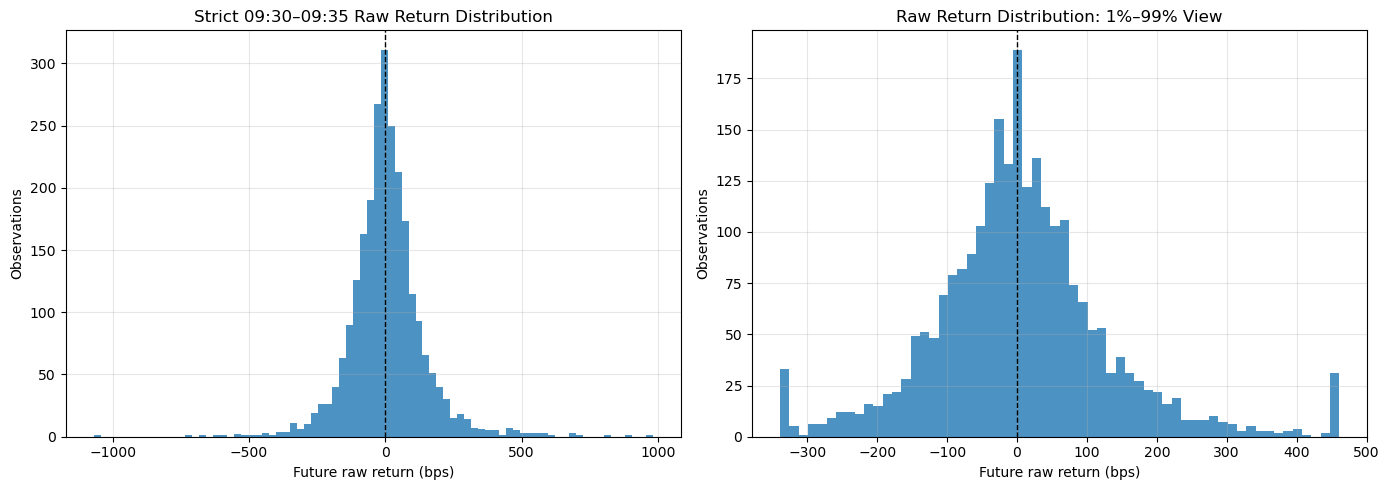

In [44]:
# ============================================================
# 20A. Raw Five-Minute Return Distribution
# ============================================================

raw_target_summary = (
    raw_return_master_df[
        RAW_MODEL_TARGET
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

display(
    raw_target_summary
)

raw_direction_summary = (
    raw_return_master_df[
        RAW_MODEL_DIRECTION_TARGET
    ]
    .value_counts(
        normalize=False
    )
    .sort_index()
    .rename("count")
    .to_frame()
)

raw_direction_summary[
    "ratio"
] = (
    raw_direction_summary[
        "count"
    ]
    / raw_direction_summary[
        "count"
    ].sum()
)

raw_direction_summary.index = (
    raw_direction_summary.index.map({
        0: "Non-positive",
        1: "Positive",
    })
)

display(
    raw_direction_summary
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

# Full distribution
axes[0].hist(
    raw_return_master_df[
        RAW_MODEL_TARGET
    ].dropna() * 10_000,
    bins=80,
    alpha=0.8,
)

axes[0].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[0].set_title(
    "Strict 09:30–09:35 Raw Return Distribution"
)

axes[0].set_xlabel(
    "Future raw return (bps)"
)

axes[0].set_ylabel(
    "Observations"
)

axes[0].grid(
    alpha=0.3
)

# Winsorized view for visualization only
raw_plot_return_bps = (
    raw_return_master_df[
        RAW_MODEL_TARGET
    ]
    .clip(
        lower=raw_return_master_df[
            RAW_MODEL_TARGET
        ].quantile(0.01),

        upper=raw_return_master_df[
            RAW_MODEL_TARGET
        ].quantile(0.99),
    )
    * 10_000
)

axes[1].hist(
    raw_plot_return_bps.dropna(),
    bins=60,
    alpha=0.8,
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Raw Return Distribution: 1%–99% View"
)

axes[1].set_xlabel(
    "Future raw return (bps)"
)

axes[1].set_ylabel(
    "Observations"
)

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


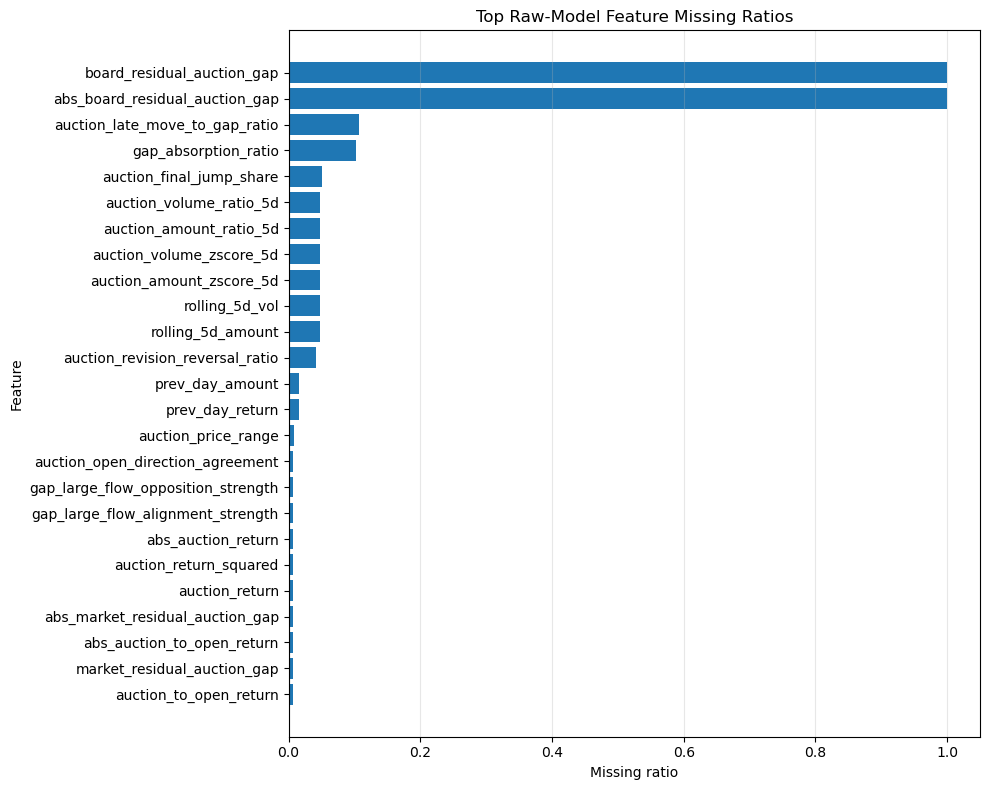

In [45]:
# ============================================================
# 20B. Feature Missing-Rate Visualization
# ============================================================

raw_missing_plot = (
    raw_feature_quality
    .sort_values(
        "missing_ratio",
        ascending=True,
    )
    .tail(25)
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    raw_missing_plot[
        "feature"
    ],
    raw_missing_plot[
        "missing_ratio"
    ],
)

plt.xlabel(
    "Missing ratio"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Raw-Model Feature Missing Ratios"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()
plt.show()


## 21 描述性单因子IC


In [46]:
# ============================================================
# 21. Descriptive Raw-Return Single-Factor IC
#
# This is a research diagnostic only.
# It is not used to select features using future OOS dates.
# ============================================================

raw_single_factor_rows = []

raw_daily_factor_ic_parts = []

for feature in raw_model_features:

    factor_part = (
        raw_return_master_df[
            [
                "date",
                "code",
                feature,
                RAW_MODEL_TARGET,
            ]
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .copy()
    )

    if (
        len(factor_part) < 30
        or factor_part[
            feature
        ].nunique() < 2
    ):
        continue

    pooled_pearson_ic = (
        factor_part[
            feature
        ]
        .corr(
            factor_part[
                RAW_MODEL_TARGET
            ],
            method="pearson",
        )
    )

    pooled_rank_ic = (
        factor_part[
            feature
        ]
        .corr(
            factor_part[
                RAW_MODEL_TARGET
            ],
            method="spearman",
        )
    )

    daily_ic = (
        factor_part
        .groupby("date")
        .apply(
            lambda day: (
                day[feature]
                .corr(
                    day[
                        RAW_MODEL_TARGET
                    ],
                    method="spearman",
                )
                if (
                    day[feature].nunique() > 1
                    and day[
                        RAW_MODEL_TARGET
                    ].nunique() > 1
                )
                else np.nan
            ),
            include_groups=False,
        )
        .dropna()
    )

    raw_single_factor_rows.append({
        "feature":
            feature,

        "pooled_pearson_ic":
            pooled_pearson_ic,

        "pooled_rank_ic":
            pooled_rank_ic,

        "mean_daily_rank_ic":
            daily_ic.mean(),

        "median_daily_rank_ic":
            daily_ic.median(),

        "daily_ic_std":
            daily_ic.std(),

        "positive_daily_ic_ratio":
            (daily_ic > 0).mean(),

        "n_dates":
            len(daily_ic),

        "n_obs":
            len(factor_part),
    })

    if not daily_ic.empty:

        daily_ic_part = (
            daily_ic
            .rename("daily_rank_ic")
            .reset_index()
        )

        daily_ic_part[
            "feature"
        ] = feature

        raw_daily_factor_ic_parts.append(
            daily_ic_part
        )

raw_single_factor_summary = (
    pd.DataFrame(
        raw_single_factor_rows
    )
)

raw_single_factor_summary[
    "abs_mean_daily_rank_ic"
] = (
    raw_single_factor_summary[
        "mean_daily_rank_ic"
    ].abs()
)

raw_single_factor_summary = (
    raw_single_factor_summary
    .sort_values(
        "abs_mean_daily_rank_ic",
        ascending=False,
    )
    .reset_index(drop=True)
)

raw_daily_factor_ic = (
    pd.concat(
        raw_daily_factor_ic_parts,
        ignore_index=True,
    )
    if raw_daily_factor_ic_parts
    else pd.DataFrame()
)

display(
    raw_single_factor_summary.head(30)
)


,feature,pooled_pearson_ic,pooled_rank_ic,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,n_dates,n_obs,abs_mean_daily_rank_ic
0,strict_opening_depth_imbalance_5,0.085425,0.098453,0.079802,0.079835,0.178187,0.682540,63,2504,0.079802
1,strict_opening_microprice_deviation,0.063039,0.076529,0.078205,0.098386,0.195242,0.698413,63,2504,0.078205
2,abs_market_residual_auction_gap,-0.069393,-0.043343,-0.066606,-0.047785,0.198128,0.333333,63,2488,0.066606
3,final_depth_imbalance,-0.034345,-0.055591,-0.063583,-0.056296,0.152529,0.253968,63,2504,0.063583
4,strict_opening_depth_imbalance,0.064911,0.063277,0.062601,0.076458,0.195224,0.698413,63,2504,0.062601
5,auction_late_move_to_gap_ratio,0.030940,0.033201,0.045361,0.083391,0.175905,0.603175,63,2238,0.045361
6,prev_day_return,-0.011580,0.003197,-0.044605,-0.065760,0.193934,0.403226,62,2464,0.044605
7,auction_to_open_return,-0.025397,-0.031675,-0.039549,-0.052128,0.195069,0.380952,63,2488,0.039549
8,abs_auction_return,-0.049328,-0.026256,-0.036928,-0.055748,0.199421,0.428571,63,2488,0.036928
9,auction_return_squared,-0.041386,-0.026256,-0.036928,-0.055748,0.199421,0.428571,63,2488,0.036928


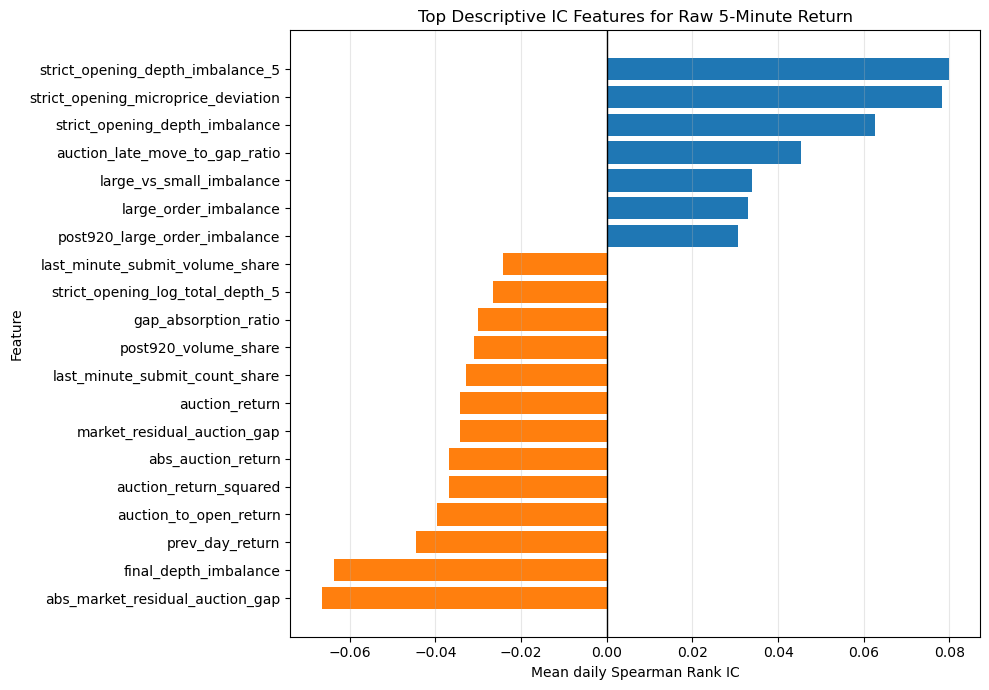

In [47]:
# ============================================================
# 21A. Top Raw-Return Single-Factor IC Plot
# ============================================================

RAW_TOP_IC_FEATURES = 20

raw_ic_plot = (
    raw_single_factor_summary
    .head(
        RAW_TOP_IC_FEATURES
    )
    .sort_values(
        "mean_daily_rank_ic"
    )
)

plt.figure(
    figsize=(10, 7)
)

colors = np.where(
    raw_ic_plot[
        "mean_daily_rank_ic"
    ] >= 0,
    "tab:blue",
    "tab:orange",
)

plt.barh(
    raw_ic_plot[
        "feature"
    ],
    raw_ic_plot[
        "mean_daily_rank_ic"
    ],
    color=colors,
)

plt.axvline(
    0,
    color="black",
    linewidth=1,
)

plt.xlabel(
    "Mean daily Spearman Rank IC"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Descriptive IC Features for Raw 5-Minute Return"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()
plt.show()


# 精简版正式研究主线

此前的 A/B/C/D 因子树、多轮组合模型、Direction-Magnitude 合成和中间消融实验已从正式 notebook 中归档，以避免研究主线被历史试验淹没。完整内容保存在本次修改前的自动备份中。

当前 notebook 只保留三层：

```text
Part I-IX
I-V   数据、严格标签、泄漏检查与基础因子筛选
VI    隔夜价格路径、订单可信度与短期反转
VII   竞价信息预期价格与实际开盘价的信息吸收残差
VIII  WPC、开盘价格无偏性与 prior-only 效率因子
IX    A/G/C独立性检验、机械合成与收益率预测
```

正式研究问题保持不变：使用严格 09:30 及之前可见的信息，预测 09:30-09:35 带符号收益率。旧实验结论仅作为研究历史，不再参与后续对象依赖。


# Part VI. Price Path and Overnight Sentiment

## Research question

This section changes the order of research. It does **not** begin by fitting a larger model. It first asks:

> What information was expressed between the previous close and 09:30, which part was common market/board sentiment, which part was stock-specific, and did committed orders, executions and the 09:30 book confirm or reject that price signal?

The observable path is separated into three non-overlapping stages:

```text
previous close -> 09:25 auction price : auction / overnight repricing
09:25 auction price -> strict 09:30 mid : opening correction or reinforcement
strict 09:30 mid -> strict 09:35 mid    : prediction target only
```

No variable from after the strict 09:30 timestamp may enter a feature. Direction and magnitude are evaluated as diagnostics of the same signed target rather than forced into the final formula.


In [159]:
# ============================================================
# 6.1 Build the Three-Stage Price Path
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

assert "factor_research_df" in globals(), (
    "Run Parts I-V first so factor_research_df exists."
)

PATH_REQUIRED = {
    "code", "date", "future_return_5m_raw", "auction_return",
    "auction_to_open_return", "strict_opening_depth_imbalance_5",
}
path_missing = PATH_REQUIRED - set(factor_research_df.columns)
assert not path_missing, f"Missing price-path inputs: {sorted(path_missing)}"

price_path_df = factor_research_df.copy()
price_path_df["date"] = pd.to_datetime(
    price_path_df["date"], errors="raise"
).dt.normalize()
price_path_df["code"] = price_path_df["code"].astype(str)
assert not price_path_df.duplicated(["code", "date"]).any()

for column in [
    "future_return_5m_raw", "auction_return", "auction_to_open_return",
    "strict_opening_depth_imbalance_5", "auction_price", "pre_close",
    "strict_opening_mid", "auction_trade_amount", "rolling_5d_amount",
]:
    if column in price_path_df.columns:
        price_path_df[column] = pd.to_numeric(
            price_path_df[column], errors="coerce"
        )

# Exact price definition is preferred. The compounded return is the safe fallback.
if {"strict_opening_mid", "pre_close"}.issubset(price_path_df.columns):
    price_path_df["overnight_to_0930_gap"] = (
        price_path_df["strict_opening_mid"]
        / price_path_df["pre_close"].replace(0, np.nan)
        - 1
    )
else:
    price_path_df["overnight_to_0930_gap"] = (
        (1 + price_path_df["auction_return"])
        * (1 + price_path_df["auction_to_open_return"])
        - 1
    )

price_path_df["abs_auction_gap"] = price_path_df["auction_return"].abs()
price_path_df["abs_overnight_to_0930_gap"] = (
    price_path_df["overnight_to_0930_gap"].abs()
)

# Same-day market and board benchmarks are observable by 09:30.
price_path_df["market_median_auction_gap"] = (
    price_path_df.groupby("date", observed=True)["auction_return"]
    .transform("median")
)
price_path_df["market_adjusted_auction_gap"] = (
    price_path_df["auction_return"]
    - price_path_df["market_median_auction_gap"]
)
price_path_df["market_median_0930_gap"] = (
    price_path_df.groupby("date", observed=True)["overnight_to_0930_gap"]
    .transform("median")
)
price_path_df["market_adjusted_0930_gap"] = (
    price_path_df["overnight_to_0930_gap"]
    - price_path_df["market_median_0930_gap"]
)

if "board" in price_path_df.columns:
    price_path_df["board_median_0930_gap"] = (
        price_path_df.groupby(["date", "board"], observed=True)[
            "overnight_to_0930_gap"
        ].transform("median")
    )
    price_path_df["board_adjusted_0930_gap"] = (
        price_path_df["overnight_to_0930_gap"]
        - price_path_df["board_median_0930_gap"]
    )
else:
    price_path_df["board_adjusted_0930_gap"] = np.nan

for column in [
    "auction_return", "overnight_to_0930_gap",
    "market_adjusted_0930_gap", "board_adjusted_0930_gap",
]:
    price_path_df[f"{column}__daily_rank_score"] = (
        price_path_df.groupby("date", observed=True)[column]
        .rank(pct=True, method="average") * 2 - 1
    )

path_audit = pd.DataFrame({
    "feature": [
        "auction_return", "auction_to_open_return",
        "overnight_to_0930_gap", "market_adjusted_0930_gap",
        "board_adjusted_0930_gap", "future_return_5m_raw",
    ],
    "coverage_ratio": [
        price_path_df[c].notna().mean()
        for c in [
            "auction_return", "auction_to_open_return",
            "overnight_to_0930_gap", "market_adjusted_0930_gap",
            "board_adjusted_0930_gap", "future_return_5m_raw",
        ]
    ],
    "n_unique": [
        price_path_df[c].nunique(dropna=True)
        for c in [
            "auction_return", "auction_to_open_return",
            "overnight_to_0930_gap", "market_adjusted_0930_gap",
            "board_adjusted_0930_gap", "future_return_5m_raw",
        ]
    ],
})

display(path_audit)
display(price_path_df[[
    "code", "date", "auction_return", "auction_to_open_return",
    "overnight_to_0930_gap", "market_adjusted_0930_gap",
    "board_adjusted_0930_gap", "future_return_5m_raw",
]].head())


,feature,coverage_ratio,n_unique
0,auction_return,0.99361,2189
1,auction_to_open_return,0.99361,2356
2,overnight_to_0930_gap,1.00000,2441
3,market_adjusted_0930_gap,1.00000,2494
4,board_adjusted_0930_gap,0.00000,0
5,future_return_5m_raw,1.00000,2400


,code,date,auction_return,auction_to_open_return,overnight_to_0930_gap,market_adjusted_0930_gap,board_adjusted_0930_gap,future_return_5m_raw
0,000713.SZ,2026-01-05,0.001511,0.000754,0.002266,-0.000914,NaN,-0.001507
1,000713.SZ,2026-01-06,0.002994,-0.000746,0.002246,0.001035,NaN,0.004481
2,000713.SZ,2026-01-07,-0.002963,0.002229,-0.000741,0.000668,NaN,-0.001483
3,000713.SZ,2026-01-08,0.000000,0.000742,0.000742,0.002456,NaN,0.000000
4,000713.SZ,2026-01-09,-0.004438,0.000743,-0.003698,-0.002107,NaN,0.001485


## 6.2 Historical surprise: abnormal relative to the stock itself

Cross-sectional adjustment asks whether a stock is unusual relative to other stocks today. Historical surprise asks a different question: whether today's gap is unusual relative to the stock's own prior behavior. Only prior dates are used.


In [160]:
# ============================================================
# 6.2 Prior-Only Historical Gap Surprise
# ============================================================

def _attach_prior_robust_surprise(
    frame, column, window=20, minimum=10
):
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    center = pd.Series(np.nan, index=frame.index, dtype=float)
    scale = pd.Series(np.nan, index=frame.index, dtype=float)

    for _, group in frame.sort_values("date").groupby(
        "code", sort=False, observed=True
    ):
        values = pd.to_numeric(group[column], errors="coerce")
        prior = values.shift(1)
        rolling_center = prior.rolling(
            window, min_periods=minimum
        ).median()
        rolling_mad = prior.rolling(
            window, min_periods=minimum
        ).apply(
            lambda x: np.nanmedian(
                np.abs(x - np.nanmedian(x))
            ),
            raw=True,
        )
        robust_scale = 1.4826 * rolling_mad
        surprise = (
            (values - rolling_center)
            / robust_scale.replace(0, np.nan)
        ).clip(-10, 10)
        result.loc[group.index] = surprise
        center.loc[group.index] = rolling_center
        scale.loc[group.index] = robust_scale

    return result, center, scale


for source_column, short_name in [
    ("auction_return", "auction_gap"),
    ("overnight_to_0930_gap", "gap_0930"),
]:
    (
        price_path_df[f"historical_{short_name}_surprise"],
        price_path_df[f"prior_{short_name}_median_20d"],
        price_path_df[f"prior_{short_name}_robust_scale_20d"],
    ) = _attach_prior_robust_surprise(
        price_path_df, source_column, window=20, minimum=10
    )

historical_surprise_audit = pd.DataFrame({
    "feature": [
        "historical_auction_gap_surprise",
        "historical_gap_0930_surprise",
    ],
    "coverage_ratio": [
        price_path_df[c].notna().mean()
        for c in [
            "historical_auction_gap_surprise",
            "historical_gap_0930_surprise",
        ]
    ],
    "first_available_date": [
        price_path_df.loc[
            price_path_df[c].notna(), "date"
        ].min()
        for c in [
            "historical_auction_gap_surprise",
            "historical_gap_0930_surprise",
        ]
    ],
})
display(historical_surprise_audit)


,feature,coverage_ratio,first_available_date
0,historical_auction_gap_surprise,0.830272,2026-01-19
1,historical_gap_0930_surprise,0.840256,2026-01-19


## 6.3 Price information map: continuation or reversal?

Both the original signed feature and its reversal orientation are reported. The sign is not chosen after looking at the result. Positive/negative paths are then evaluated separately because A-share continuation can be asymmetric.


In [161]:
# ============================================================
# 6.3 Same-Sample Daily Rank IC and Path States
# ============================================================

def _daily_rank_ic_table(frame, feature, target="future_return_5m_raw"):
    rows = []
    for date_value, daily in frame.groupby("date", observed=True):
        valid = daily[[feature, target]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        ic = (
            valid[feature].corr(valid[target], method="spearman")
            if len(valid) >= 8
            and valid[feature].nunique() >= 3
            and valid[target].nunique() >= 3
            else np.nan
        )
        rows.append({"date": date_value, "daily_rank_ic": ic})
    return pd.DataFrame(rows).dropna(subset=["daily_rank_ic"])


PRICE_PATH_FEATURES = [
    "auction_return",
    "auction_to_open_return",
    "overnight_to_0930_gap",
    "market_adjusted_0930_gap",
    "board_adjusted_0930_gap",
    "historical_auction_gap_surprise",
    "historical_gap_0930_surprise",
]

price_path_ic_rows = []
for feature in PRICE_PATH_FEATURES:
    daily_ic = _daily_rank_ic_table(price_path_df, feature)
    for orientation, multiplier in [
        ("Continuation", 1.0), ("Reversal", -1.0)
    ]:
        oriented = daily_ic["daily_rank_ic"] * multiplier
        price_path_ic_rows.append({
            "feature": feature,
            "orientation": orientation,
            "n_ic_dates": int(oriented.notna().sum()),
            "mean_daily_rank_ic": oriented.mean(),
            "median_daily_rank_ic": oriented.median(),
            "daily_ic_std": oriented.std(ddof=1),
            "positive_daily_ic_ratio": (oriented > 0).mean(),
            "icir": oriented.mean() / oriented.std(ddof=1)
            if oriented.std(ddof=1) > 0 else np.nan,
        })

price_path_ic_summary = pd.DataFrame(price_path_ic_rows)
display(price_path_ic_summary.sort_values(
    ["feature", "orientation"]
).reset_index(drop=True))

# A state map preserves the economic path rather than compressing it too early.
auction_sign = np.sign(
    pd.to_numeric(price_path_df["auction_return"], errors="coerce")
)
correction_sign = np.sign(
    pd.to_numeric(
        price_path_df["auction_to_open_return"], errors="coerce"
    )
)

price_path_df["price_path_state"] = np.select(
    [
        auction_sign.eq(1) & correction_sign.eq(1),
        auction_sign.eq(1) & correction_sign.eq(-1),
        auction_sign.eq(-1) & correction_sign.eq(-1),
        auction_sign.eq(-1) & correction_sign.eq(1),
    ],
    [
        "Positive gap reinforced before 09:30",
        "Positive gap corrected before 09:30",
        "Negative gap reinforced before 09:30",
        "Negative gap repaired before 09:30",
    ],
    default="Flat / mixed / unavailable",
)

price_path_state_summary = (
    price_path_df.groupby("price_path_state", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_auction_gap_bps=("auction_return", lambda x: x.mean() * 1e4),
        mean_auction_to_0930_bps=("auction_to_open_return", lambda x: x.mean() * 1e4),
        mean_future_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        median_future_return_bps=("future_return_5m_raw", lambda x: x.median() * 1e4),
        positive_future_ratio=("future_return_5m_raw", lambda x: (x > 0).mean()),
    )
    .reset_index()
)
display(price_path_state_summary.sort_values(
    "mean_future_return_bps", ascending=False
))


,feature,orientation,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir
0,auction_return,Continuation,63,-0.034198,-0.048148,0.202223,0.396825,-0.169110
1,auction_return,Reversal,63,0.034198,0.048148,0.202223,0.603175,0.169110
2,auction_to_open_return,Continuation,63,-0.039549,-0.052128,0.195069,0.380952,-0.202744
3,auction_to_open_return,Reversal,63,0.039549,0.052128,0.195069,0.619048,0.202744
4,board_adjusted_0930_gap,Continuation,0,NaN,NaN,NaN,NaN,NaN
5,board_adjusted_0930_gap,Reversal,0,NaN,NaN,NaN,NaN,NaN
6,historical_auction_gap_surprise,Continuation,53,-0.004636,-0.005441,0.190204,0.490566,-0.024374
7,historical_auction_gap_surprise,Reversal,53,0.004636,0.005441,0.190204,0.509434,0.024374
8,historical_gap_0930_surprise,Continuation,53,-0.034824,-0.065219,0.195810,0.339623,-0.177848
9,historical_gap_0930_surprise,Reversal,53,0.034824,0.065219,0.195810,0.660377,0.177848


,price_path_state,n_obs,n_dates,mean_auction_gap_bps,mean_auction_to_0930_bps,mean_future_return_bps,median_future_return_bps,positive_future_ratio
2,Negative gap repaired before 09:30,623,60,-105.468452,33.858450,14.192359,2.858674,0.507223
1,Negative gap reinforced before 09:30,588,60,-84.269464,-23.878956,12.474967,10.351420,0.535714
0,Flat / mixed / unavailable,248,59,-1.596526,5.187563,4.599358,0.000000,0.435484
4,Positive gap reinforced before 09:30,561,58,101.826158,25.325584,-1.154489,-5.751140,0.452763
3,Positive gap corrected before 09:30,484,62,103.506484,-32.908586,-9.892492,-6.837233,0.438017


## 6.4 Order credibility and price absorption

Price movement is the phenomenon to explain. Order behavior is used to decide whether that movement represents committed information, tentative sentiment, successful execution, or absorption.

Important definitions:

- `gap_committed_confirmation_strength > 0`: committed pressure supports the stock-specific gap direction.
- `gap_execution_confirmation_strength > 0`: executed pressure supports that direction.
- `gap_cancellation_opposition > 0`: pressure initially supporting the gap was subsequently withdrawn.
- `price_commitment_residual`: committed directional pressure is stronger than the observed relative price move; this is a candidate for unabsorbed sentiment, not automatically a trading signal.


In [162]:
# ============================================================
# 6.4 Merge Order Credibility and Build Mechanism Variables
# ============================================================

IT_CANDIDATES = [
    Path(
        r"C:\Users\work\OneDrive\Documents\level2-research\notebooks"
    ) / "04_information_transmission_features.csv",
    Path("04_information_transmission_features.csv"),
    Path.cwd() / "04_information_transmission_features.csv",
]
it_path = next((p for p in IT_CANDIDATES if p.exists()), None)
if it_path is None:
    raise FileNotFoundError(
        "Run Notebook 4 Part IX first to create "
        "04_information_transmission_features.csv."
    )

sentiment_order_df = pd.read_csv(it_path)
sentiment_order_df["date"] = pd.to_datetime(
    sentiment_order_df["date"], errors="raise"
).dt.normalize()
sentiment_order_df["code"] = sentiment_order_df["code"].astype(str)
assert not sentiment_order_df.duplicated(["code", "date"]).any()

ORDER_COLUMNS = [
    "submitted_pressure",
    "cancellation_adjusted_pressure",
    "executed_pressure",
    "commitment_asymmetry",
    "execution_conversion_asymmetry",
    "quantile_large_committed_pressure",
    "price_net_flow_confirmation",
]
missing_order_columns = [
    c for c in ORDER_COLUMNS if c not in sentiment_order_df.columns
]
assert not missing_order_columns, (
    f"Information-transmission export is missing: {missing_order_columns}"
)

drop_before_merge = [
    c for c in ORDER_COLUMNS if c in price_path_df.columns
]
if drop_before_merge:
    price_path_df = price_path_df.drop(columns=drop_before_merge)

price_path_df = price_path_df.merge(
    sentiment_order_df[["code", "date"] + ORDER_COLUMNS],
    on=["code", "date"], how="left", validate="one_to_one",
)

# Use board-adjusted gap where available, otherwise market-adjusted gap.
price_path_df["relative_gap_for_mechanism"] = (
    price_path_df["board_adjusted_0930_gap"]
    .fillna(price_path_df["market_adjusted_0930_gap"])
)
price_path_df["relative_gap_direction"] = np.sign(
    price_path_df["relative_gap_for_mechanism"]
)

price_path_df["gap_committed_confirmation_strength"] = (
    price_path_df["relative_gap_direction"]
    * price_path_df["cancellation_adjusted_pressure"]
)
price_path_df["gap_execution_confirmation_strength"] = (
    price_path_df["relative_gap_direction"]
    * price_path_df["executed_pressure"]
)
price_path_df["gap_opening_confirmation_strength"] = (
    price_path_df["relative_gap_direction"]
    * price_path_df["strict_opening_depth_imbalance_5"]
)

# Submitted pressure minus retained pressure is the directional pressure withdrawn.
price_path_df["withdrawn_directional_pressure"] = (
    price_path_df["submitted_pressure"]
    - price_path_df["cancellation_adjusted_pressure"]
)
price_path_df["gap_cancellation_opposition"] = (
    price_path_df["relative_gap_direction"]
    * price_path_df["withdrawn_directional_pressure"]
)

# Daily ranks make price and pressure comparable without assuming common units.
price_path_df["committed_pressure_rank_score"] = (
    price_path_df.groupby("date", observed=True)[
        "cancellation_adjusted_pressure"
    ].rank(pct=True, method="average") * 2 - 1
)
price_path_df["relative_gap_rank_score"] = (
    price_path_df.groupby("date", observed=True)[
        "relative_gap_for_mechanism"
    ].rank(pct=True, method="average") * 2 - 1
)
price_path_df["price_commitment_residual"] = (
    price_path_df["committed_pressure_rank_score"]
    - price_path_df["relative_gap_rank_score"]
)

mechanism_coverage = pd.DataFrame({
    "feature": ORDER_COLUMNS + [
        "gap_committed_confirmation_strength",
        "gap_execution_confirmation_strength",
        "gap_opening_confirmation_strength",
        "gap_cancellation_opposition",
        "price_commitment_residual",
    ],
    "coverage_ratio": [
        price_path_df[c].notna().mean()
        for c in ORDER_COLUMNS + [
            "gap_committed_confirmation_strength",
            "gap_execution_confirmation_strength",
            "gap_opening_confirmation_strength",
            "gap_cancellation_opposition",
            "price_commitment_residual",
        ]
    ],
})
display(mechanism_coverage)


,feature,coverage_ratio
0,submitted_pressure,1.000000
1,cancellation_adjusted_pressure,1.000000
2,executed_pressure,0.993610
3,commitment_asymmetry,1.000000
4,execution_conversion_asymmetry,1.000000
5,quantile_large_committed_pressure,0.914936
6,price_net_flow_confirmation,0.930112
7,gap_committed_confirmation_strength,1.000000
8,gap_execution_confirmation_strength,0.993610
9,gap_opening_confirmation_strength,1.000000


## 6.5 Does order information explain continuation and reversal?

This section first evaluates continuous mechanism variables, then reports interpretable states. A high IC alone is insufficient: the state means must agree with the proposed mechanism, the result must be reasonably stable through time, and a future rolling OOS section must later confirm any promoted candidate.


In [163]:
# ============================================================
# 6.5 Mechanism IC, Asymmetry and Interpretable States
# ============================================================

MECHANISM_FEATURES = [
    "gap_committed_confirmation_strength",
    "gap_execution_confirmation_strength",
    "gap_opening_confirmation_strength",
    "gap_cancellation_opposition",
    "price_commitment_residual",
    "price_net_flow_confirmation",
]

mechanism_ic_rows = []
for feature in MECHANISM_FEATURES:
    daily_ic = _daily_rank_ic_table(price_path_df, feature)
    values = daily_ic["daily_rank_ic"]
    mechanism_ic_rows.append({
        "feature": feature,
        "n_ic_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "daily_ic_std": values.std(ddof=1),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": values.mean() / values.std(ddof=1)
        if values.std(ddof=1) > 0 else np.nan,
    })

mechanism_ic_summary = pd.DataFrame(mechanism_ic_rows)
display(mechanism_ic_summary.sort_values(
    "mean_daily_rank_ic", ascending=False
).reset_index(drop=True))

# Positive and negative stock-specific gaps are separate hypotheses.
asymmetry_rows = []
for side_name, side_mask in [
    ("Positive relative gap", price_path_df["relative_gap_for_mechanism"] > 0),
    ("Negative relative gap", price_path_df["relative_gap_for_mechanism"] < 0),
]:
    side = price_path_df.loc[side_mask].copy()
    for feature in MECHANISM_FEATURES:
        daily_ic = _daily_rank_ic_table(side, feature)
        asymmetry_rows.append({
            "gap_side": side_name,
            "feature": feature,
            "n_ic_dates": len(daily_ic),
            "mean_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
            "median_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
            "positive_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        })
display(pd.DataFrame(asymmetry_rows))

# State definitions use only signs available by strict 09:30.
gap_sign = np.sign(price_path_df["relative_gap_for_mechanism"])
commit_sign = np.sign(price_path_df["cancellation_adjusted_pressure"])
opening_sign = np.sign(price_path_df["strict_opening_depth_imbalance_5"])

price_path_df["sentiment_transmission_state"] = np.select(
    [
        gap_sign.eq(commit_sign) & gap_sign.eq(opening_sign) & gap_sign.ne(0),
        gap_sign.eq(commit_sign) & gap_sign.ne(opening_sign) & gap_sign.ne(0),
        gap_sign.ne(commit_sign) & commit_sign.eq(opening_sign) & gap_sign.ne(0),
    ],
    [
        "Gap confirmed by commitment and opening book",
        "Commitment confirms gap but opening book rejects",
        "Orders and opening book reject the gap",
    ],
    default="Mixed / zero / unavailable",
)

state_summary = (
    price_path_df.groupby("sentiment_transmission_state", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_relative_gap_bps=("relative_gap_for_mechanism", lambda x: x.mean() * 1e4),
        mean_committed_pressure=("cancellation_adjusted_pressure", "mean"),
        mean_future_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        median_future_return_bps=("future_return_5m_raw", lambda x: x.median() * 1e4),
        positive_future_ratio=("future_return_5m_raw", lambda x: (x > 0).mean()),
        mean_abs_future_return_bps=("future_return_5m_raw", lambda x: x.abs().mean() * 1e4),
    )
    .reset_index()
)
display(state_summary.sort_values(
    "mean_future_return_bps", ascending=False
))


,feature,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir
0,price_commitment_residual,63,0.050564,0.078908,0.175373,0.666667,0.288323
1,gap_committed_confirmation_strength,63,0.043750,0.086304,0.161812,0.650794,0.270378
2,gap_opening_confirmation_strength,63,0.027126,0.006478,0.157522,0.571429,0.172206
3,price_net_flow_confirmation,63,0.002778,-0.007112,0.162033,0.444444,0.017142
4,gap_cancellation_opposition,63,-0.000027,-0.001619,0.147418,0.492063,-0.000183
5,gap_execution_confirmation_strength,63,-0.048137,-0.032219,0.188425,0.412698,-0.255470


,gap_side,feature,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Positive relative gap,gap_committed_confirmation_strength,63,-0.001975,0.003008,0.507937
1,Positive relative gap,gap_execution_confirmation_strength,63,0.011712,0.018045,0.523810
2,Positive relative gap,gap_opening_confirmation_strength,63,0.100934,0.145865,0.714286
3,Positive relative gap,gap_cancellation_opposition,63,0.023700,0.033083,0.619048
4,Positive relative gap,price_commitment_residual,63,0.044161,0.051166,0.587302
5,Positive relative gap,price_net_flow_confirmation,63,0.010828,0.027864,0.555556
6,Negative relative gap,gap_committed_confirmation_strength,63,-0.022620,-0.007522,0.492063
7,Negative relative gap,gap_execution_confirmation_strength,63,0.017950,0.018045,0.555556
8,Negative relative gap,gap_opening_confirmation_strength,63,-0.065457,-0.084359,0.380952
9,Negative relative gap,gap_cancellation_opposition,63,-0.007552,-0.012030,0.460317


,sentiment_transmission_state,n_obs,n_dates,mean_relative_gap_bps,mean_committed_pressure,mean_future_return_bps,median_future_return_bps,positive_future_ratio,mean_abs_future_return_bps
2,Mixed / zero / unavailable,605,63,56.368894,-0.371770,13.369682,9.278424,0.538843,94.343954
0,Commitment confirms gap but opening book rejects,627,63,-48.989157,-0.388167,10.833646,3.313453,0.510367,90.596297
1,Gap confirmed by commitment and opening book,674,63,-40.973248,-0.402966,3.670916,-3.323367,0.465875,94.794656
3,Orders and opening book reject the gap,598,63,46.231206,-0.419410,-9.152883,-18.245625,0.409699,96.179344


## 6.6 Interpretation and promotion protocol

This chapter does not promote a signal merely because one table is positive. The research decision must answer three levels:

1. **Information:** what market behavior does the feature represent?
2. **Evidence:** do daily IC, path-state returns and positive/negative asymmetry support the hypothesis?
3. **Boundary:** in which price path, liquidity, participation and commitment states does the relation fail?

The next step is allowed only after reviewing 18.1-18.5:

```text
same-sample mechanism diagnosis
-> chronological subperiod and liquidity/participation stability
-> paired incremental IC versus Opening A and raw gap
-> strict rolling OOS direct signed-return comparison
-> locked future-holdout candidate
```

The expected roles are deliberately separated:

- `relative/residual gap`: stock-specific price information;
- `committed/executed pressure`: credibility of expressed sentiment;
- `opening imbalance`: final confirmation at the forecast origin;
- `price_commitment_residual`: possible unabsorbed information or absorption, requiring state validation;
- participation and volatility: conditions, not automatic direction signals.


# Part VII. Pre-opening Price Discovery and Information Absorption

## 7.1 Research design

The motivating paper, *Are pre-opening periods important? Evidence from Chinese market lunch breaks*, treats the call auction as an information-aggregation mechanism rather than merely a source of another return predictor. This section translates that idea into a stock-level 09:30-09:35 test:

```text
information observable during the call auction
-> expected stock-specific 09:30 gap, estimated using prior dates only
-> compare expected and realized 09:30 gap
-> test whether the discrepancy predicts 09:30-09:35 return
```

The central object is not the raw overnight gap. It is the difference between the price adjustment normally implied by pre-opening information and the adjustment actually completed by strict 09:30.

Definitions:

- `expected_relative_0930_gap`: rolling OOS estimate of the stock-specific 09:30 gap;
- `realized_relative_0930_gap`: board-adjusted gap, falling back to market-adjusted gap;
- `information_absorption_residual = expected - realized`;
- positive residual: pre-opening information is more bullish than the realized relative opening price;
- negative residual: pre-opening information is more bearish than the realized relative opening price.

The residual is a hypothesis, not automatically an alpha. Its meaning is validated separately in under-absorption, over-absorption and price-rejection states. All model fitting uses dates strictly earlier than the test date.


In [164]:
# ============================================================
# 7.1 Prior-Only Expected 09:30 Price Formation
# ============================================================

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

assert "price_path_df" in globals(), "Run Part VI.1-VI.4 first."

absorption_df = price_path_df.copy()
absorption_df["date"] = pd.to_datetime(
    absorption_df["date"], errors="raise"
).dt.normalize()
absorption_df["code"] = absorption_df["code"].astype(str)
assert not absorption_df.duplicated(["code", "date"]).any()

# Board-adjusted price is preferred; market adjustment is the complete fallback.
absorption_df["realized_relative_0930_gap"] = (
    absorption_df["board_adjusted_0930_gap"]
    .fillna(absorption_df["market_adjusted_0930_gap"])
)

# Inputs must be observable no later than strict 09:30. The model does not use
# auction_to_open_return or any 09:30-09:35 outcome as an explanatory variable.
ABSORPTION_INPUT_CANDIDATES = [
    "auction_return",
    "historical_auction_gap_surprise",
    "cancellation_adjusted_pressure",
    "executed_pressure",
    "execution_conversion_asymmetry",
    "quantile_large_committed_pressure",
    "price_net_flow_confirmation",
    "strict_opening_depth_imbalance_5",
]
ABSORPTION_INPUTS = [
    column for column in ABSORPTION_INPUT_CANDIDATES
    if column in absorption_df.columns
    and absorption_df[column].notna().any()
]

required_inputs = {
    "auction_return", "cancellation_adjusted_pressure",
    "strict_opening_depth_imbalance_5",
}
missing_required = required_inputs - set(ABSORPTION_INPUTS)
assert not missing_required, (
    f"Missing core absorption inputs: {sorted(missing_required)}"
)

# Daily ranks remove scale incompatibility between returns, order pressure and
# conversion variables while retaining only information observable that morning.
ABSORPTION_SCORE_COLUMNS = []
for column in ABSORPTION_INPUTS:
    score_column = f"x19__{column}__rank_score"
    absorption_df[score_column] = (
        absorption_df.groupby("date", observed=True)[column]
        .rank(pct=True, method="average") * 2 - 1
    )
    ABSORPTION_SCORE_COLUMNS.append(score_column)

all_dates = np.array(sorted(absorption_df["date"].dropna().unique()))
MIN_TRAIN_DATES_19 = 20
ROLLING_TRAIN_DATES_19 = 40
RIDGE_ALPHA_19 = 10.0  # fixed before looking at the test results

prediction_parts = []
for test_date in all_dates:
    prior_dates = all_dates[all_dates < test_date]
    if len(prior_dates) < MIN_TRAIN_DATES_19:
        continue
    train_dates = prior_dates[-ROLLING_TRAIN_DATES_19:]
    train = absorption_df[
        absorption_df["date"].isin(train_dates)
    ].copy()
    test = absorption_df[absorption_df["date"].eq(test_date)].copy()

    train_valid = train.dropna(subset=["realized_relative_0930_gap"])
    test_valid = test.dropna(subset=["realized_relative_0930_gap"])
    if len(train_valid) < 200 or len(test_valid) < 8:
        continue

    price_formation_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=RIDGE_ALPHA_19)),
    ])
    price_formation_model.fit(
        train_valid[ABSORPTION_SCORE_COLUMNS],
        train_valid["realized_relative_0930_gap"],
    )
    test_valid["expected_relative_0930_gap"] = (
        price_formation_model.predict(
            test_valid[ABSORPTION_SCORE_COLUMNS]
        )
    )
    test_valid["absorption_train_start"] = pd.Timestamp(train_dates.min())
    test_valid["absorption_train_end"] = pd.Timestamp(train_dates.max())
    test_valid["absorption_train_n_dates"] = len(train_dates)
    prediction_parts.append(test_valid)

assert prediction_parts, "No Part VII rolling predictions were created."
absorption_oos_df = pd.concat(prediction_parts, ignore_index=True)

absorption_oos_df["information_absorption_residual"] = (
    absorption_oos_df["expected_relative_0930_gap"]
    - absorption_oos_df["realized_relative_0930_gap"]
)
absorption_oos_df["opening_price_surprise"] = (
    -absorption_oos_df["information_absorption_residual"]
)

for column in [
    "expected_relative_0930_gap",
    "realized_relative_0930_gap",
    "information_absorption_residual",
    "opening_price_surprise",
]:
    absorption_oos_df[f"{column}__rank_score"] = (
        absorption_oos_df.groupby("date", observed=True)[column]
        .rank(pct=True, method="average") * 2 - 1
    )

absorption_prediction_audit = pd.DataFrame({
    "metric": [
        "n_oos_predictions", "n_oos_dates", "first_oos_date",
        "last_oos_date", "n_absorption_inputs", "ridge_alpha",
        "mean_daily_price_formation_rank_corr",
    ],
    "value": [
        len(absorption_oos_df), absorption_oos_df["date"].nunique(),
        absorption_oos_df["date"].min(), absorption_oos_df["date"].max(),
        len(ABSORPTION_SCORE_COLUMNS), RIDGE_ALPHA_19,
        np.nanmean([
            daily["expected_relative_0930_gap"].corr(
                daily["realized_relative_0930_gap"], method="spearman"
            )
            for _, daily in absorption_oos_df.groupby(
                "date", observed=True
            )
        ]),
    ],
})

print("Part VII absorption inputs:", ABSORPTION_INPUTS)
display(absorption_prediction_audit)
display(absorption_oos_df[[
    "date", "code", "expected_relative_0930_gap",
    "realized_relative_0930_gap", "information_absorption_residual",
    "future_return_5m_raw", "absorption_train_start",
    "absorption_train_end",
]].head(10))


Part XIX absorption inputs: ['auction_return', 'historical_auction_gap_surprise', 'cancellation_adjusted_pressure', 'executed_pressure', 'execution_conversion_asymmetry', 'quantile_large_committed_pressure', 'price_net_flow_confirmation', 'strict_opening_depth_imbalance_5']


,metric,value
0,n_oos_predictions,1707
1,n_oos_dates,43
2,first_oos_date,2026-02-02 00:00:00
3,last_oos_date,2026-04-10 00:00:00
4,n_absorption_inputs,8
5,ridge_alpha,10.0
6,mean_daily_price_formation_rank_corr,0.846637


,date,code,expected_relative_0930_gap,realized_relative_0930_gap,information_absorption_residual,future_return_5m_raw,absorption_train_start,absorption_train_end
0,2026-02-02,000713.SZ,-0.008633,-0.023182,0.014549,-0.015374,2026-01-05,2026-01-30
1,2026-02-02,000782.SZ,0.009763,-0.008823,0.018586,0.022433,2026-01-05,2026-01-30
2,2026-02-02,000816.SZ,-0.007362,-0.016267,0.008905,-0.012706,2026-01-05,2026-01-30
3,2026-02-02,000863.SZ,0.005617,0.014012,-0.008396,-0.028127,2026-01-05,2026-01-30
4,2026-02-02,001215.SZ,0.011787,0.010350,0.001438,0.011595,2026-01-05,2026-01-30
5,2026-02-02,002240.SZ,-0.012986,-0.012525,-0.000461,0.028125,2026-01-05,2026-01-30
6,2026-02-02,002278.SZ,-0.014111,-0.031540,0.017429,0.027611,2026-01-05,2026-01-30
7,2026-02-02,002438.SZ,-0.002103,-0.001690,-0.000414,0.002343,2026-01-05,2026-01-30
8,2026-02-02,002441.SZ,0.008403,0.011400,-0.002998,0.010194,2026-01-05,2026-01-30
9,2026-02-02,002451.SZ,0.014168,0.022428,-0.008260,0.009130,2026-01-05,2026-01-30


## 7.2 Does incomplete absorption predict the next five minutes?

Four distinct objects are compared on exactly the same rolling-OOS dates:

1. raw stock-specific opening gap;
2. the gap implied by auction information;
3. `expected - realized`, interpreted provisionally as unabsorbed information;
4. `realized - expected`, interpreted provisionally as an opening-price surprise.

Both residual orientations are shown because the data must decide between continuation and correction. The sign will not be selected retrospectively without a future holdout.


In [165]:
# ============================================================
# 7.2 OOS IC Map and Same-Date Comparisons
# ============================================================

def _x19_daily_rank_ic(frame, feature, target="future_return_5m_raw"):
    rows = []
    for date_value, daily in frame.groupby("date", observed=True):
        valid = daily[[feature, target]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        ic = np.nan
        if (
            len(valid) >= 8
            and valid[feature].nunique() >= 3
            and valid[target].nunique() >= 3
        ):
            ic = valid[feature].corr(valid[target], method="spearman")
        rows.append({"date": date_value, "daily_rank_ic": ic})
    return pd.DataFrame(rows).dropna(subset=["daily_rank_ic"])


X19_SIGNALS = {
    "Raw relative 09:30 gap": "realized_relative_0930_gap",
    "Expected gap from auction information": "expected_relative_0930_gap",
    "Information absorption residual": "information_absorption_residual",
    "Opening price surprise": "opening_price_surprise",
    "Opening A": "strict_opening_depth_imbalance_5",
}

x19_ic_series = {}
x19_ic_rows = []
for signal_name, column in X19_SIGNALS.items():
    daily = _x19_daily_rank_ic(absorption_oos_df, column)
    values = daily.set_index("date")["daily_rank_ic"]
    x19_ic_series[signal_name] = values
    x19_ic_rows.append({
        "signal": signal_name,
        "n_ic_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "daily_ic_std": values.std(ddof=1),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": values.mean() / values.std(ddof=1)
        if values.std(ddof=1) > 0 else np.nan,
    })

x19_ic_summary = pd.DataFrame(x19_ic_rows).sort_values(
    "mean_daily_rank_ic", ascending=False
).reset_index(drop=True)
display(x19_ic_summary)

# Compare each absorption residual orientation with Opening A on paired dates.
rng_x19 = np.random.default_rng(20260723)
x19_paired_rows = []
for candidate in [
    "Information absorption residual", "Opening price surprise",
    "Expected gap from auction information", "Raw relative 09:30 gap",
]:
    paired = pd.concat(
        [x19_ic_series[candidate], x19_ic_series["Opening A"]],
        axis=1, keys=["candidate", "opening_a"]
    ).dropna()
    difference = paired["candidate"] - paired["opening_a"]
    boot = np.array([
        rng_x19.choice(difference.to_numpy(), len(difference), replace=True).mean()
        for _ in range(5000)
    ]) if len(difference) else np.array([np.nan])
    x19_paired_rows.append({
        "candidate": candidate,
        "n_paired_dates": len(difference),
        "mean_candidate_minus_A_ic": difference.mean(),
        "median_candidate_minus_A_ic": difference.median(),
        "positive_difference_ratio": (difference > 0).mean(),
        "bootstrap_ci_low": np.nanquantile(boot, 0.025),
        "bootstrap_ci_high": np.nanquantile(boot, 0.975),
        "probability_mean_increment_positive": np.nanmean(boot > 0),
    })

x19_paired_comparison = pd.DataFrame(x19_paired_rows)
display(x19_paired_comparison)


,signal,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir
0,Opening A,43,0.080959,0.079835,0.190934,0.674419,0.424015
1,Information absorption residual,43,0.010473,0.050469,0.203472,0.534884,0.051471
2,Opening price surprise,43,-0.010473,-0.050469,0.203472,0.465116,-0.051471
3,Expected gap from auction information,43,-0.033216,0.000657,0.207321,0.511628,-0.160216
4,Raw relative 09:30 gap,43,-0.059681,-0.082739,0.238558,0.372093,-0.250172


,candidate,n_paired_dates,mean_candidate_minus_A_ic,median_candidate_minus_A_ic,positive_difference_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_mean_increment_positive
0,Information absorption residual,43,-0.070486,-0.059963,0.395349,-0.143725,0.004524,0.0340
1,Opening price surprise,43,-0.091432,-0.122702,0.372093,-0.178810,-0.003971,0.0212
2,Expected gap from auction information,43,-0.114175,-0.106379,0.325581,-0.199853,-0.029630,0.0062
3,Raw relative 09:30 gap,43,-0.140639,-0.157598,0.325581,-0.234260,-0.044150,0.0022


## 7.3 Mechanism states: under-absorption, over-absorption and rejection

A residual alone is ambiguous. The same numerical residual can arise because the opening price moved too little in the information direction, moved too far, or moved in the opposite direction. These are separated before drawing an economic conclusion.

- **Under-absorbed:** expected and realized gaps have the same sign, but the realized move is smaller;
- **Over-absorbed:** same sign, but the realized move is larger;
- **Opening rejects auction information:** expected and realized gaps have opposite signs;
- **Weak expected information:** the expected gap lies in the daily bottom 20% by absolute size.

The key outcome is the return signed in the direction of the auction-implied information. If under-absorption is real, this signed return should be positive specifically in the under-absorbed state.


In [166]:
# ============================================================
# 7.3 State Validation and Falsification Tests
# ============================================================

expected = absorption_oos_df["expected_relative_0930_gap"]
realized = absorption_oos_df["realized_relative_0930_gap"]
expected_sign = np.sign(expected)
realized_sign = np.sign(realized)

absorption_oos_df["absolute_expected_gap_rank"] = (
    absorption_oos_df.groupby("date", observed=True)[
        "expected_relative_0930_gap"
    ].transform(lambda x: x.abs().rank(pct=True, method="average"))
)
weak_expected = absorption_oos_df["absolute_expected_gap_rank"].le(0.20)
same_nonzero_sign = expected_sign.eq(realized_sign) & expected_sign.ne(0)

absorption_oos_df["absorption_state"] = np.select(
    [
        weak_expected,
        same_nonzero_sign & realized.abs().lt(expected.abs()),
        same_nonzero_sign & realized.abs().ge(expected.abs()),
        expected_sign.ne(realized_sign) & expected_sign.ne(0) & realized_sign.ne(0),
    ],
    [
        "Weak expected information",
        "Under-absorbed in information direction",
        "Over-absorbed in information direction",
        "Opening rejects auction information",
    ],
    default="Zero / mixed / unavailable",
)

absorption_oos_df["information_signed_future_return"] = (
    expected_sign * absorption_oos_df["future_return_5m_raw"]
)
absorption_oos_df["opening_signed_future_return"] = (
    realized_sign * absorption_oos_df["future_return_5m_raw"]
)

x19_state_summary = (
    absorption_oos_df.groupby("absorption_state", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_expected_gap_bps=(
            "expected_relative_0930_gap", lambda x: x.mean() * 1e4
        ),
        mean_realized_gap_bps=(
            "realized_relative_0930_gap", lambda x: x.mean() * 1e4
        ),
        mean_absorption_residual_bps=(
            "information_absorption_residual", lambda x: x.mean() * 1e4
        ),
        mean_future_return_bps=(
            "future_return_5m_raw", lambda x: x.mean() * 1e4
        ),
        mean_information_signed_return_bps=(
            "information_signed_future_return", lambda x: x.mean() * 1e4
        ),
        median_information_signed_return_bps=(
            "information_signed_future_return", lambda x: x.median() * 1e4
        ),
        information_direction_accuracy=(
            "information_signed_future_return", lambda x: (x > 0).mean()
        ),
        mean_abs_future_return_bps=(
            "future_return_5m_raw", lambda x: x.abs().mean() * 1e4
        ),
    )
    .reset_index()
)
display(x19_state_summary.sort_values(
    "mean_information_signed_return_bps", ascending=False
))

# Positive and negative information are checked separately to expose asymmetry.
x19_state_side_summary = (
    absorption_oos_df.assign(
        expected_information_side=np.where(
            expected_sign > 0, "Positive expected information",
            np.where(expected_sign < 0, "Negative expected information", "Zero")
        )
    )
    .groupby(["absorption_state", "expected_information_side"], observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_information_signed_return_bps=(
            "information_signed_future_return", lambda x: x.mean() * 1e4
        ),
        information_direction_accuracy=(
            "information_signed_future_return", lambda x: (x > 0).mean()
        ),
    )
    .reset_index()
)
display(x19_state_side_summary)


,absorption_state,n_obs,n_dates,mean_expected_gap_bps,mean_realized_gap_bps,mean_absorption_residual_bps,mean_future_return_bps,mean_information_signed_return_bps,median_information_signed_return_bps,information_direction_accuracy,mean_abs_future_return_bps
0,Opening rejects auction information,138,41,-0.652241,0.438746,-1.090986,12.546756,18.131393,15.369948,0.565217,87.769768
1,Over-absorbed in information direction,344,43,10.168092,16.299644,-6.131552,-4.342183,5.133743,17.543398,0.534884,133.942670
3,Weak expected information,335,43,-1.392762,0.396537,-1.789299,17.791364,-0.281974,-2.687450,0.468657,76.882929
2,Under-absorbed in information direction,888,43,-2.874193,-2.199061,-0.675132,-1.814757,-8.587294,-3.491673,0.450450,81.804685
4,Zero / mixed / unavailable,2,2,66.270303,0.000000,66.270303,-57.664697,-57.664697,-57.664697,0.500000,97.143282


,absorption_state,expected_information_side,n_obs,n_dates,mean_information_signed_return_bps,information_direction_accuracy
0,Opening rejects auction information,Negative expected information,72,34,5.351944,0.569444
1,Opening rejects auction information,Positive expected information,66,39,32.072611,0.560606
2,Over-absorbed in information direction,Negative expected information,160,43,10.186620,0.568750
3,Over-absorbed in information direction,Positive expected information,184,40,0.739936,0.505435
4,Under-absorbed in information direction,Negative expected information,452,43,-6.652669,0.466814
5,Under-absorbed in information direction,Positive expected information,436,43,-10.592915,0.433486
6,Weak expected information,Negative expected information,178,43,-17.007214,0.426966
7,Weak expected information,Positive expected information,157,42,18.680401,0.515924
8,Zero / mixed / unavailable,Positive expected information,2,2,-57.664697,0.500000


## 7.4 Stability, visualization and promotion rule

This section tests whether an apparent residual effect survives time and market-state splits. Liquidity and participation are conditioning variables, not direction labels. Missing optional state columns are skipped explicitly rather than causing undefined-name errors.

Promotion requires all of the following:

1. the rolling-OOS residual has positive mean daily Rank IC in its pre-specified orientation;
2. the under-absorbed state has positive information-signed return and accuracy above 50%;
3. the result does not reverse in the last 21 OOS dates;
4. bootstrap probability of positive mean IC is at least 90%;
5. the economic state table agrees with the statistical sign.

Passing makes the residual a **locked candidate for a future holdout**, not permission to keep tuning it on the current 43 OOS dates.


Skipped optional Liquidity split: no compatible column.
Skipped optional Participation split: no compatible column.
Skipped optional Board split: no compatible column.


,split_type,group,signal,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Time,Earlier OOS dates,Information absorption residual,22,0.019693,0.092542,0.636364
1,Time,Earlier OOS dates,Opening A,22,0.127949,0.114822,0.727273
2,Time,Earlier OOS dates,Raw relative 09:30 gap,22,-0.064546,-0.079800,0.409091
3,Time,Last 21 OOS dates,Information absorption residual,21,0.000814,-0.006894,0.428571
4,Time,Last 21 OOS dates,Opening A,21,0.031731,0.053069,0.619048
5,Time,Last 21 OOS dates,Raw relative 09:30 gap,21,-0.054583,-0.082739,0.333333


,metric,value
0,observed_mean_daily_ic,0.010473
1,bootstrap_ci_low,-0.050106
2,bootstrap_ci_high,0.069867
3,probability_mean_ic_positive,0.640200


,criterion,value,pass
0,Residual rolling-OOS mean daily Rank IC > 0,0.010473,True
1,Under-absorbed mean information-signed return ...,-8.587294,False
2,Under-absorbed information-direction accuracy ...,0.450450,False
3,Last 21 OOS mean residual IC > 0,0.000814,True
4,Bootstrap P(mean residual IC > 0) >= 90%,0.640200,False


Part XIX locked future-holdout candidate: False


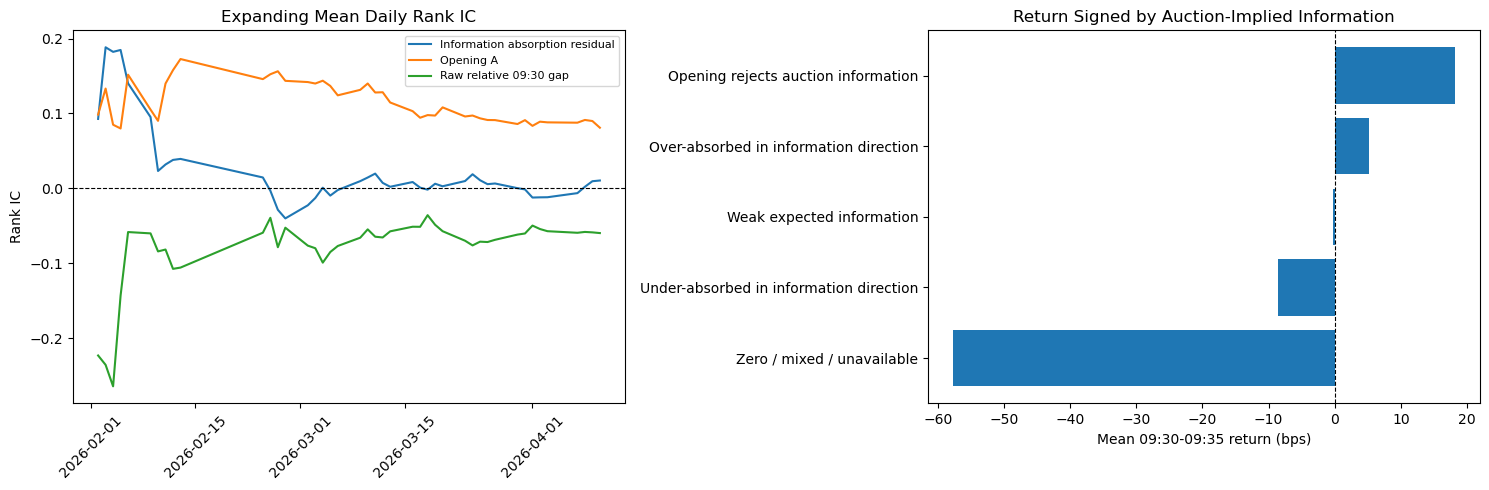

In [167]:
# ============================================================
# 7.4 Stability, Bootstrap, Charts and Frozen Decision
# ============================================================

residual_daily_ic = x19_ic_series["Information absorption residual"].dropna()
rng_x19_final = np.random.default_rng(20260724)
residual_bootstrap = np.array([
    rng_x19_final.choice(
        residual_daily_ic.to_numpy(), len(residual_daily_ic), replace=True
    ).mean()
    for _ in range(10000)
])

sorted_oos_dates = np.array(sorted(absorption_oos_df["date"].unique()))
last_21_dates = set(sorted_oos_dates[-21:])
absorption_oos_df["x19_subperiod"] = np.where(
    absorption_oos_df["date"].isin(last_21_dates),
    "Last 21 OOS dates", "Earlier OOS dates"
)

x19_stability_rows = []
for subperiod, subframe in absorption_oos_df.groupby(
    "x19_subperiod", observed=True
):
    for signal_name, column in {
        "Information absorption residual": "information_absorption_residual",
        "Opening A": "strict_opening_depth_imbalance_5",
        "Raw relative 09:30 gap": "realized_relative_0930_gap",
    }.items():
        values = _x19_daily_rank_ic(subframe, column)["daily_rank_ic"]
        x19_stability_rows.append({
            "split_type": "Time",
            "group": subperiod,
            "signal": signal_name,
            "n_ic_dates": len(values),
            "mean_daily_rank_ic": values.mean(),
            "median_daily_rank_ic": values.median(),
            "positive_ic_ratio": (values > 0).mean(),
        })

OPTIONAL_STATE_COLUMNS = {
    "Liquidity": ["liquidity_group", "daily_liquidity_group"],
    "Participation": ["participation_group", "daily_participation_group"],
    "Board": ["board"],
}
for split_type, candidates in OPTIONAL_STATE_COLUMNS.items():
    group_column = next(
        (c for c in candidates if c in absorption_oos_df.columns), None
    )
    if group_column is None:
        print(f"Skipped optional {split_type} split: no compatible column.")
        continue
    for group_value, subframe in absorption_oos_df.groupby(
        group_column, observed=True
    ):
        values = _x19_daily_rank_ic(
            subframe, "information_absorption_residual"
        )["daily_rank_ic"]
        x19_stability_rows.append({
            "split_type": split_type,
            "group": group_value,
            "signal": "Information absorption residual",
            "n_ic_dates": len(values),
            "mean_daily_rank_ic": values.mean(),
            "median_daily_rank_ic": values.median(),
            "positive_ic_ratio": (values > 0).mean(),
        })

x19_stability_summary = pd.DataFrame(x19_stability_rows)
display(x19_stability_summary)

under_absorbed_row = x19_state_summary[
    x19_state_summary["absorption_state"].eq(
        "Under-absorbed in information direction"
    )
]
under_signed_bps = (
    under_absorbed_row["mean_information_signed_return_bps"].iloc[0]
    if len(under_absorbed_row) else np.nan
)
under_accuracy = (
    under_absorbed_row["information_direction_accuracy"].iloc[0]
    if len(under_absorbed_row) else np.nan
)
last_period_ic = x19_stability_summary.loc[
    x19_stability_summary["split_type"].eq("Time")
    & x19_stability_summary["group"].eq("Last 21 OOS dates")
    & x19_stability_summary["signal"].eq(
        "Information absorption residual"
    ),
    "mean_daily_rank_ic",
]
last_period_ic = last_period_ic.iloc[0] if len(last_period_ic) else np.nan

x19_decision = pd.DataFrame({
    "criterion": [
        "Residual rolling-OOS mean daily Rank IC > 0",
        "Under-absorbed mean information-signed return > 0 bps",
        "Under-absorbed information-direction accuracy > 50%",
        "Last 21 OOS mean residual IC > 0",
        "Bootstrap P(mean residual IC > 0) >= 90%",
    ],
    "value": [
        residual_daily_ic.mean(), under_signed_bps, under_accuracy,
        last_period_ic, np.mean(residual_bootstrap > 0),
    ],
})
x19_decision["pass"] = [
    residual_daily_ic.mean() > 0,
    under_signed_bps > 0,
    under_accuracy > 0.50,
    last_period_ic > 0,
    np.mean(residual_bootstrap > 0) >= 0.90,
]
x19_all_pass = bool(x19_decision["pass"].all())
display(pd.DataFrame({
    "metric": [
        "observed_mean_daily_ic", "bootstrap_ci_low",
        "bootstrap_ci_high", "probability_mean_ic_positive",
    ],
    "value": [
        residual_daily_ic.mean(),
        np.quantile(residual_bootstrap, 0.025),
        np.quantile(residual_bootstrap, 0.975),
        np.mean(residual_bootstrap > 0),
    ],
}))
display(x19_decision)
print("Part VII locked future-holdout candidate:", x19_all_pass)

# Two required research visuals: IC path and economically interpretable states.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for signal_name in [
    "Information absorption residual", "Opening A",
    "Raw relative 09:30 gap",
]:
    series = x19_ic_series[signal_name].sort_index()
    axes[0].plot(
        series.index, series.expanding().mean(), label=signal_name
    )
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Expanding Mean Daily Rank IC")
axes[0].set_ylabel("Rank IC")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)

state_plot = x19_state_summary.sort_values(
    "mean_information_signed_return_bps"
)
axes[1].barh(
    state_plot["absorption_state"],
    state_plot["mean_information_signed_return_bps"],
)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Return Signed by Auction-Implied Information")
axes[1].set_xlabel("Mean 09:30-09:35 return (bps)")

plt.tight_layout()
plt.show()


## 7.5 Result interpretation template

Fill this section only after running 19.1-19.4.

1. **Can pre-opening information explain the 09:30 relative opening price?** Report the rolling test-date price-formation rank correlation. This measures price discovery, not return alpha.
2. **Which side predicts 09:30-09:35: expected information, realized gap, or their residual?** Report mean daily Rank IC and the paired difference versus Opening A.
3. **Does the state mechanism agree?** Under-absorption must continue in the auction-implied direction; over-absorption or rejection may instead reverse.
4. **Where does it work?** Report the last-21-date, liquidity, participation and board splits without selecting a group retrospectively.
5. **Final role:** choose only one: `Locked future-holdout candidate`, `Conditional mechanism/filter`, or `Diagnostic only`.

This part deliberately does not add the residual to the final signed-return formula. If it passes, the next section should freeze the definition and compare `Opening A`, `absorption residual`, and a pre-specified two-factor combination on genuinely new dates.


# Part VIII. WPC and Opening-Price Unbiasedness

## 8.1 Purpose and leakage boundary

This compact section adapts two price-discovery tools from *Are pre-opening periods important? Evidence from Chinese market lunch breaks*.

- **Weighted Price Contribution (WPC):** where did the previous-close-to-09:35 price discovery occur - in the call auction, between 09:25 and strict 09:30, or during 09:30-09:35?
- **Unbiasedness regression:** did the strict 09:30 price change correctly anticipate the price observed at 09:35, or was the opening response systematically incomplete or excessive?

The same-day WPC and regression outcome use the 09:35 price and are therefore **evaluation-only**. They never enter a 09:30 feature. Prediction candidates are created only from coefficients and WPC diagnostics estimated on strictly prior dates.

The adaptation is intentionally aligned with the project's five-minute target. It is not claimed to reproduce the paper's morning-versus-afternoon institutional test exactly.


In [168]:
# ============================================================
# 8.1 Additive Price Path and Daily Weighted Price Contribution
# ============================================================

import numpy as np
import pandas as pd

assert "price_path_df" in globals(), "Run Part VI.1-VI.4 first."

wpc_df = price_path_df.copy()
wpc_df["date"] = pd.to_datetime(wpc_df["date"], errors="raise").dt.normalize()
wpc_df["code"] = wpc_df["code"].astype(str)
assert not wpc_df.duplicated(["code", "date"]).any()

WPC_REQUIRED = {
    "auction_return", "auction_to_open_return", "future_return_5m_raw",
    "strict_opening_depth_imbalance_5", "cancellation_adjusted_pressure",
}
wpc_missing = WPC_REQUIRED - set(wpc_df.columns)
assert not wpc_missing, f"Missing Part VIII inputs: {sorted(wpc_missing)}"

for column in [
    "auction_return", "auction_to_open_return", "future_return_5m_raw",
    "strict_opening_depth_imbalance_5", "cancellation_adjusted_pressure",
]:
    wpc_df[column] = pd.to_numeric(wpc_df[column], errors="coerce")

assert not (
    wpc_df[[
        "auction_return", "auction_to_open_return", "future_return_5m_raw"
    ]] <= -1
).any().any(), "Log-return conversion found a return <= -100%."

# Log returns make the three stages exactly additive.
wpc_df["log_prevclose_to_auction"] = np.log1p(wpc_df["auction_return"])
wpc_df["log_auction_to_0930"] = np.log1p(wpc_df["auction_to_open_return"])
wpc_df["log_0930_to_0935"] = np.log1p(wpc_df["future_return_5m_raw"])
wpc_df["log_prevclose_to_0930"] = (
    wpc_df["log_prevclose_to_auction"]
    + wpc_df["log_auction_to_0930"]
)
wpc_df["log_prevclose_to_0935"] = (
    wpc_df["log_prevclose_to_0930"]
    + wpc_df["log_0930_to_0935"]
)

def _x20_daily_wpc(daily):
    valid = daily[[
        "log_prevclose_to_auction", "log_auction_to_0930",
        "log_0930_to_0935", "log_prevclose_to_0935",
    ]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(valid) < 8:
        return None
    total = valid["log_prevclose_to_0935"]
    denominator = total.abs().sum()
    if not np.isfinite(denominator) or denominator <= 0:
        return None
    direction = np.sign(total)
    return {
        "n_obs": len(valid),
        "wpc_call_auction": (
            direction * valid["log_prevclose_to_auction"]
        ).sum() / denominator,
        "wpc_auction_to_0930": (
            direction * valid["log_auction_to_0930"]
        ).sum() / denominator,
        "wpc_0930_to_0935": (
            direction * valid["log_0930_to_0935"]
        ).sum() / denominator,
    }

wpc_daily_rows = []
for date_value, daily in wpc_df.groupby("date", observed=True):
    result = _x20_daily_wpc(daily)
    if result is not None:
        result["date"] = date_value
        wpc_daily_rows.append(result)

wpc_daily_summary = pd.DataFrame(wpc_daily_rows).sort_values("date")
wpc_daily_summary["wpc_sum"] = wpc_daily_summary[[
    "wpc_call_auction", "wpc_auction_to_0930", "wpc_0930_to_0935"
]].sum(axis=1)
assert np.allclose(wpc_daily_summary["wpc_sum"], 1.0, atol=1e-10)

wpc_stage_summary = pd.DataFrame({
    "stage": ["Call auction", "09:25 to strict 09:30", "09:30 to 09:35"],
    "mean_wpc": [
        wpc_daily_summary["wpc_call_auction"].mean(),
        wpc_daily_summary["wpc_auction_to_0930"].mean(),
        wpc_daily_summary["wpc_0930_to_0935"].mean(),
    ],
    "median_wpc": [
        wpc_daily_summary["wpc_call_auction"].median(),
        wpc_daily_summary["wpc_auction_to_0930"].median(),
        wpc_daily_summary["wpc_0930_to_0935"].median(),
    ],
    "positive_day_ratio": [
        (wpc_daily_summary["wpc_call_auction"] > 0).mean(),
        (wpc_daily_summary["wpc_auction_to_0930"] > 0).mean(),
        (wpc_daily_summary["wpc_0930_to_0935"] > 0).mean(),
    ],
})

display(wpc_stage_summary)
display(wpc_daily_summary.head())


,stage,mean_wpc,median_wpc,positive_day_ratio
0,Call auction,0.409001,0.385629,0.968254
1,09:25 to strict 09:30,0.016769,0.024120,0.698413
2,09:30 to 09:35,0.574229,0.630234,0.984127


,n_obs,wpc_call_auction,wpc_auction_to_0930,wpc_0930_to_0935,date,wpc_sum
0,40,0.262791,0.003375,0.733834,2026-01-05,1.0
1,40,0.248274,0.069985,0.681741,2026-01-06,1.0
2,39,0.551274,0.008998,0.439728,2026-01-07,1.0
3,38,0.426933,-0.131417,0.704484,2026-01-08,1.0
4,40,0.640387,-0.045077,0.404690,2026-01-09,1.0


## 8.2 Unbiasedness regression as an opening-price quality test

For each date, estimate across stocks:

\[
r_{close\rightarrow09:35}=\alpha+\beta r_{close\rightarrow09:30}+\epsilon.
\]

The benchmark for a fully unbiased 09:30 price is approximately `alpha = 0` and `beta = 1`.

- `beta < 1`: opening changes are excessive on average and tend to be corrected;
- `beta > 1`: opening changes are incomplete and tend to continue;
- low `R2` or large RMSE: the opening price contains substantial stock-level noise relative to 09:35.

This is a price-quality diagnosis. The same-day beta and residual are not prediction features.


In [222]:
# ============================================================
# 8.2 Daily and Pooled Unbiasedness Regressions
# ============================================================

def _x20_ols_summary(frame, x_column, y_column, minimum=8):
    valid = frame[[x_column, y_column]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(valid) < minimum or valid[x_column].nunique() < 3:
        return None
    x = valid[x_column].to_numpy(dtype=float)
    y = valid[y_column].to_numpy(dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    coefficients = np.linalg.lstsq(design, y, rcond=None)[0]
    prediction = design @ coefficients
    residual = y - prediction
    sst = np.sum((y - y.mean()) ** 2)
    r2 = 1 - np.sum(residual ** 2) / sst if sst > 0 else np.nan
    return {
        "n_obs": len(valid),
        "alpha": coefficients[0],
        "beta": coefficients[1],
        "rmse": np.sqrt(np.mean(residual ** 2)),
        "r2": r2,
    }

unbiasedness_daily_rows = []
for date_value, daily in wpc_df.groupby("date", observed=True):
    result = _x20_ols_summary(
        daily, "log_prevclose_to_0930", "log_prevclose_to_0935"
    )
    if result is not None:
        result["date"] = date_value
        unbiasedness_daily_rows.append(result)

unbiasedness_daily = pd.DataFrame(unbiasedness_daily_rows).sort_values("date")
pooled_unbiasedness = _x20_ols_summary(
    wpc_df, "log_prevclose_to_0930", "log_prevclose_to_0935",
    minimum=200,
)

unbiasedness_summary = pd.DataFrame({
    "metric": [
        "pooled_alpha_bps", "pooled_beta", "pooled_r2",
        "mean_daily_alpha_bps", "mean_daily_beta", "median_daily_beta",
        "mean_daily_r2", "beta_below_one_day_ratio",
    ],
    "value": [
        pooled_unbiasedness["alpha"] * 1e4,
        pooled_unbiasedness["beta"], pooled_unbiasedness["r2"],
        unbiasedness_daily["alpha"].mean() * 1e4,
        unbiasedness_daily["beta"].mean(),
        unbiasedness_daily["beta"].median(),
        unbiasedness_daily["r2"].mean(),
        (unbiasedness_daily["beta"] < 1).mean(),
    ],
})
display(unbiasedness_summary)
display(unbiasedness_daily.head())


,metric,value
0,pooled_alpha_bps,3.523005
1,pooled_beta,0.922253
2,pooled_r2,0.456647
3,mean_daily_alpha_bps,2.034037
4,mean_daily_beta,0.966956
5,median_daily_beta,0.977680
6,mean_daily_r2,0.386750
7,beta_below_one_day_ratio,0.523810


,n_obs,alpha,beta,rmse,r2,date
0,40,0.001568,0.679522,0.013909,0.138179,2026-01-05
1,40,0.002239,1.457644,0.014091,0.470879,2026-01-06
2,39,0.001286,1.056025,0.009239,0.662054,2026-01-07
3,38,-0.000565,0.661325,0.021936,0.357123,2026-01-08
4,40,0.003028,0.862424,0.008635,0.557746,2026-01-09


## 8.3 Convert evaluation tools into prior-only prediction candidates

The following variables are legal at 09:30 because every coefficient and diagnostic is computed from earlier dates only:

- `rolling_opening_beta`: how strongly this stock's historical 09:30 move was confirmed by 09:35;
- `rolling_opening_alpha`: historical systematic five-minute correction;
- `rolling_opening_rmse`: historical opening-price noise;
- `historical_auction_absorption`: historical share of close-to-09:35 price discovery completed in the call auction;
- `historical_efficiency_predicted_return_5m = alpha + (beta - 1) * current_opening_gap`.

The final expression has a direct interpretation: use the stock's historical opening-price response to estimate how much of today's opening move is normally left for 09:30-09:35. This is a fixed one-factor mechanism, not a newly tuned machine-learning model.


In [223]:
# ============================================================
# 8.3 Strictly Prior Rolling Efficiency Features
# ============================================================

wpc_df = wpc_df.sort_values(["code", "date"]).reset_index(drop=True)
for column in [
    "rolling_opening_alpha", "rolling_opening_beta",
    "rolling_opening_rmse", "rolling_opening_r2",
    "historical_auction_absorption",
]:
    wpc_df[column] = np.nan

# Stock-day diagnostic used only after shifting into history. Observations with
# a nearly zero total move are excluded because their contribution ratio explodes.
minimum_total_move = 5e-4  # five basis points in log-return units
valid_total = wpc_df["log_prevclose_to_0935"].abs().ge(minimum_total_move)
wpc_df["realized_auction_absorption_proxy"] = np.where(
    valid_total,
    (
        np.sign(wpc_df["log_prevclose_to_0935"])
        * wpc_df["log_prevclose_to_auction"]
        / wpc_df["log_prevclose_to_0935"].abs()
    ).clip(-3, 3),
    np.nan,
)

MIN_PRIOR_DATES_20 = 15
MAX_PRIOR_DATES_20 = 40

for _, group in wpc_df.groupby("code", sort=False, observed=True):
    ordered_indices = list(group.sort_values("date").index)
    for position, current_index in enumerate(ordered_indices):
        prior_indices = ordered_indices[max(0, position - MAX_PRIOR_DATES_20):position]
        prior = wpc_df.loc[prior_indices, [
            "log_prevclose_to_0930", "log_prevclose_to_0935",
            "realized_auction_absorption_proxy",
        ]]
        regression_prior = prior[[
            "log_prevclose_to_0930", "log_prevclose_to_0935"
        ]].dropna()
        if len(regression_prior) < MIN_PRIOR_DATES_20:
            continue
        result = _x20_ols_summary(
            regression_prior,
            "log_prevclose_to_0930", "log_prevclose_to_0935",
            minimum=MIN_PRIOR_DATES_20,
        )
        if result is None:
            continue
        wpc_df.loc[current_index, "rolling_opening_alpha"] = result["alpha"]
        wpc_df.loc[current_index, "rolling_opening_beta"] = result["beta"]
        wpc_df.loc[current_index, "rolling_opening_rmse"] = result["rmse"]
        wpc_df.loc[current_index, "rolling_opening_r2"] = result["r2"]
        wpc_df.loc[current_index, "historical_auction_absorption"] = (
            prior["realized_auction_absorption_proxy"].median()
        )

wpc_df["historical_efficiency_predicted_return_5m"] = (
    wpc_df["rolling_opening_alpha"]
    + (wpc_df["rolling_opening_beta"] - 1.0)
    * wpc_df["log_prevclose_to_0930"]
)

# Economic interactions are specified before observing their return IC.
wpc_df["historical_underreaction_tendency"] = (
    wpc_df["rolling_opening_beta"] - 1.0
).clip(lower=0, upper=2)
wpc_df["gap_x_historical_underreaction"] = (
    wpc_df["log_prevclose_to_0930"]
    * wpc_df["historical_underreaction_tendency"]
)
wpc_df["committed_x_historical_underreaction"] = (
    wpc_df["cancellation_adjusted_pressure"]
    * wpc_df["historical_underreaction_tendency"]
)

# A noisy historical opening receives less weight, but its direction is unchanged.
wpc_df["historical_opening_reliability"] = (
    wpc_df.groupby("date", observed=True)["rolling_opening_rmse"]
    .rank(pct=True, ascending=False, method="average")
)
wpc_df["reliability_adjusted_opening_A"] = (
    wpc_df["strict_opening_depth_imbalance_5"]
    * wpc_df["historical_opening_reliability"]
)

prior_feature_audit = pd.DataFrame({
    "feature": [
        "rolling_opening_beta", "rolling_opening_rmse",
        "historical_auction_absorption",
        "historical_efficiency_predicted_return_5m",
        "gap_x_historical_underreaction",
        "committed_x_historical_underreaction",
        "reliability_adjusted_opening_A",
    ],
    "coverage_ratio": [
        wpc_df[column].notna().mean() for column in [
            "rolling_opening_beta", "rolling_opening_rmse",
            "historical_auction_absorption",
            "historical_efficiency_predicted_return_5m",
            "gap_x_historical_underreaction",
            "committed_x_historical_underreaction",
            "reliability_adjusted_opening_A",
        ]
    ],
    "first_available_date": [
        wpc_df.loc[wpc_df[column].notna(), "date"].min() for column in [
            "rolling_opening_beta", "rolling_opening_rmse",
            "historical_auction_absorption",
            "historical_efficiency_predicted_return_5m",
            "gap_x_historical_underreaction",
            "committed_x_historical_underreaction",
            "reliability_adjusted_opening_A",
        ]
    ],
})
display(prior_feature_audit)
display(wpc_df[[
    "date", "code", "rolling_opening_alpha", "rolling_opening_beta",
    "rolling_opening_rmse", "historical_auction_absorption",
    "historical_efficiency_predicted_return_5m", "future_return_5m_raw",
]].dropna().head(10))


,feature,coverage_ratio,first_available_date
0,rolling_opening_beta,0.759585,2026-01-26
1,rolling_opening_rmse,0.759585,2026-01-26
2,historical_auction_absorption,0.759585,2026-01-26
3,historical_efficiency_predicted_return_5m,0.753994,2026-01-26
4,gap_x_historical_underreaction,0.753994,2026-01-26
5,committed_x_historical_underreaction,0.759585,2026-01-26
6,reliability_adjusted_opening_A,0.759585,2026-01-26


,date,code,rolling_opening_alpha,rolling_opening_beta,rolling_opening_rmse,historical_auction_absorption,historical_efficiency_predicted_return_5m,future_return_5m_raw
15,2026-01-26,000713.SZ,-0.000723,0.695051,0.003128,0.666421,-0.000504,0.000000
16,2026-01-27,000713.SZ,-0.000686,0.689273,0.003031,0.999631,-0.000464,-0.005727
17,2026-01-28,000713.SZ,-0.001048,0.745070,0.003188,0.666421,-0.000493,0.007262
18,2026-01-29,000713.SZ,-0.000516,0.606909,0.003544,0.555847,0.000323,0.021352
19,2026-01-30,000713.SZ,0.000776,0.275697,0.005700,0.445274,0.004355,0.016985
20,2026-02-02,000713.SZ,0.001503,-0.052115,0.006099,0.333469,0.034079,-0.015374
21,2026-02-03,000713.SZ,0.000674,1.252399,0.007426,0.445274,0.001216,-0.004289
22,2026-02-04,000713.SZ,0.000408,1.237101,0.007345,0.333469,0.003294,-0.014235
23,2026-02-05,000713.SZ,-0.000435,1.067091,0.007930,0.221665,-0.000969,-0.002905
24,2026-02-06,000713.SZ,-0.000508,1.077332,0.007772,0.333469,-0.000792,0.004409


## 8.4 Factor validation and restrained decision

The pre-specified primary candidate is `historical_efficiency_predicted_return_5m`. The remaining interactions are mechanism diagnostics. Every comparison uses the same available stock-dates and reports daily Rank IC, subperiod stability and a paired bootstrap versus Opening A.

This section does not automatically replace Opening A. A candidate is promoted only if its sign is economically coherent, its last-21-date IC remains positive, and the paired bootstrap probability of improving on Opening A reaches 90%. Otherwise WPC and unbiasedness remain price-discovery diagnostics.


,signal,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,last_21_mean_daily_ic,icir
0,Reliability-adjusted Opening A,48,0.082814,0.087244,0.161896,0.708333,0.038729,0.511527
1,Opening A,63,0.079802,0.079835,0.178187,0.682540,0.031731,0.447857
2,Historical efficiency implied return,48,0.015053,-0.000094,0.199477,0.479167,0.017081,0.075464
3,Committed x historical underreaction,48,-0.012754,0.004275,0.150647,0.520833,-0.033970,-0.084659
4,Gap x historical underreaction,48,-0.054858,-0.072153,0.150020,0.375000,-0.069326,-0.365668


,metric,value
0,n_paired_dates,48.000000
1,primary_mean_daily_ic,0.015053
2,opening_A_mean_daily_ic,0.084862
3,mean_primary_minus_A_ic,-0.069808
4,bootstrap_ci_low,-0.137310
5,bootstrap_ci_high,-0.002770
6,probability_primary_ic_increment_positive,0.020400
7,primary_last_21_mean_daily_ic,0.017081


,criterion,value,pass
0,Primary mean daily Rank IC > 0,0.015053,True
1,Primary last-21 mean daily Rank IC > 0,0.017081,True
2,Mean paired IC increment versus Opening A > 0,-0.069808,False
3,Bootstrap P(IC increment > 0) >= 90%,0.020400,False


Part VIII independent factor promotion: False


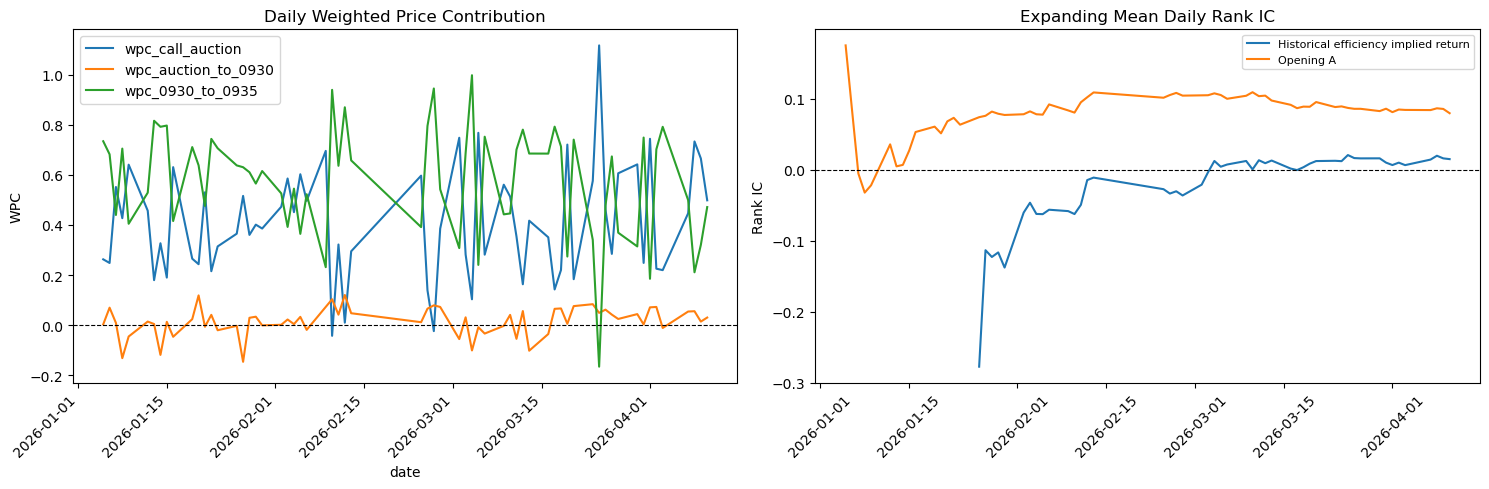

In [224]:
# ============================================================
# 8.4 Prior-Only Factor IC, Stability and Paired Test
# ============================================================

def _x20_daily_ic(frame, feature, target="future_return_5m_raw"):
    rows = []
    for date_value, daily in frame.groupby("date", observed=True):
        valid = daily[[feature, target]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        ic = np.nan
        if (
            len(valid) >= 8 and valid[feature].nunique() >= 3
            and valid[target].nunique() >= 3
        ):
            ic = valid[feature].corr(valid[target], method="spearman")
        rows.append({"date": date_value, "daily_rank_ic": ic})
    return pd.DataFrame(rows).dropna(subset=["daily_rank_ic"])

X20_FACTOR_MAP = {
    "Historical efficiency implied return": (
        "historical_efficiency_predicted_return_5m"
    ),
    "Gap x historical underreaction": "gap_x_historical_underreaction",
    "Committed x historical underreaction": (
        "committed_x_historical_underreaction"
    ),
    "Reliability-adjusted Opening A": "reliability_adjusted_opening_A",
    "Opening A": "strict_opening_depth_imbalance_5",
}

x20_ic_series = {}
x20_factor_rows = []
for name, column in X20_FACTOR_MAP.items():
    daily = _x20_daily_ic(wpc_df, column)
    values = daily.set_index("date")["daily_rank_ic"]
    x20_ic_series[name] = values
    split_date_values = sorted(values.index)
    last_dates = set(split_date_values[-21:])
    x20_factor_rows.append({
        "signal": name,
        "n_ic_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "daily_ic_std": values.std(ddof=1),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "last_21_mean_daily_ic": values.loc[
            values.index.isin(last_dates)
        ].mean(),
        "icir": values.mean() / values.std(ddof=1)
        if values.std(ddof=1) > 0 else np.nan,
    })

x20_factor_summary = pd.DataFrame(x20_factor_rows).sort_values(
    "mean_daily_rank_ic", ascending=False
).reset_index(drop=True)
display(x20_factor_summary)

primary = x20_ic_series["Historical efficiency implied return"]
baseline = x20_ic_series["Opening A"]
paired = pd.concat(
    [primary, baseline], axis=1, keys=["primary", "opening_a"]
).dropna()
paired_difference = paired["primary"] - paired["opening_a"]

rng_x20 = np.random.default_rng(20260725)
x20_bootstrap = np.array([
    rng_x20.choice(
        paired_difference.to_numpy(), len(paired_difference), replace=True
    ).mean()
    for _ in range(10000)
])

primary_last_21 = x20_factor_summary.loc[
    x20_factor_summary["signal"].eq(
        "Historical efficiency implied return"
    ), "last_21_mean_daily_ic"
].iloc[0]

x20_primary_test = pd.DataFrame({
    "metric": [
        "n_paired_dates", "primary_mean_daily_ic", "opening_A_mean_daily_ic",
        "mean_primary_minus_A_ic", "bootstrap_ci_low",
        "bootstrap_ci_high", "probability_primary_ic_increment_positive",
        "primary_last_21_mean_daily_ic",
    ],
    "value": [
        len(paired), primary.mean(), baseline.reindex(paired.index).mean(),
        paired_difference.mean(), np.quantile(x20_bootstrap, 0.025),
        np.quantile(x20_bootstrap, 0.975), np.mean(x20_bootstrap > 0),
        primary_last_21,
    ],
})
display(x20_primary_test)

x20_promotion = pd.DataFrame({
    "criterion": [
        "Primary mean daily Rank IC > 0",
        "Primary last-21 mean daily Rank IC > 0",
        "Mean paired IC increment versus Opening A > 0",
        "Bootstrap P(IC increment > 0) >= 90%",
    ],
    "value": [
        primary.mean(), primary_last_21, paired_difference.mean(),
        np.mean(x20_bootstrap > 0),
    ],
})
x20_promotion["pass"] = [
    primary.mean() > 0,
    primary_last_21 > 0,
    paired_difference.mean() > 0,
    np.mean(x20_bootstrap > 0) >= 0.90,
]
display(x20_promotion)
print(
    "Part VIII independent factor promotion:",
    bool(x20_promotion["pass"].all()),
)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
wpc_daily_summary.plot(
    x="date",
    y=["wpc_call_auction", "wpc_auction_to_0930", "wpc_0930_to_0935"],
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Daily Weighted Price Contribution")
axes[0].set_ylabel("WPC")
axes[0].tick_params(axis="x", rotation=45)

for name in ["Historical efficiency implied return", "Opening A"]:
    series = x20_ic_series[name].sort_index()
    axes[1].plot(series.index, series.expanding().mean(), label=name)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Expanding Mean Daily Rank IC")
axes[1].set_ylabel("Rank IC")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8.5 Interpretation template

After running Part VIII, summarize the evidence in this order:

1. **Price-discovery timing:** report the mean WPC of the call auction, 09:25-09:30 and 09:30-09:35 stages.
2. **Opening-price quality:** report pooled and mean daily beta, R2 and the fraction of dates with beta below one.
3. **Historical predictability:** report the IC of `historical_efficiency_predicted_return_5m` and its last-21-date result.
4. **Increment over Opening A:** report the paired IC difference and bootstrap probability.
5. **Role:** choose `Independent candidate`, `Conditional explanation`, or `Diagnostic only`.

Do not infer that a high call-auction WPC is itself bullish. WPC measures when information enters prices, while the unbiasedness-derived prediction estimates whether today's opening move historically tends to continue or correct.


# Part IX. Independent Factors and Mechanical Five-Minute Prediction

## 9.1 Freeze the candidate set and common OOS sample

This section stops broad factor expansion. It evaluates exactly three economically distinct candidates on the same rolling-OOS dates and stock observations:

```text
A: strict 09:30 five-level opening imbalance
G: reversal of the market-relative 09:30 overnight gap
C: committed order pressure not yet reflected in the relative opening price
```

The research sequence is fixed:

```text
single-factor evidence
-> residual independence beyond earlier factors
-> paired date bootstrap
-> automatic rejection or retention
-> equal-weight rank combination
-> prior-only linear calibration into a predicted five-minute return
```

Factor selection in this section uses the current 43 development-OOS dates. The selected formula is therefore a **locked candidate for future holdout**, not a final claim based on unseen dates.


In [225]:
# ============================================================
# 9.1 Common OOS Sample and Frozen A/G/C Definitions
# ============================================================

import numpy as np
import pandas as pd

assert "absorption_oos_df" in globals(), "Run Part VII.1-VII.4 first."
assert "price_path_df" in globals(), "Run Part VI.1-VI.5 first."

FINAL_REQUIRED = {
    "code", "date", "future_return_5m_raw",
    "strict_opening_depth_imbalance_5",
    "market_adjusted_0930_gap", "price_commitment_residual",
}
final_missing = FINAL_REQUIRED - set(absorption_oos_df.columns)
assert not final_missing, f"Missing final-pipeline inputs: {sorted(final_missing)}"

final_factor_df = absorption_oos_df.copy()
final_factor_df["date"] = pd.to_datetime(
    final_factor_df["date"], errors="raise"
).dt.normalize()
final_factor_df["code"] = final_factor_df["code"].astype(str)
assert not final_factor_df.duplicated(["code", "date"]).any()

final_factor_df["A_opening"] = pd.to_numeric(
    final_factor_df["strict_opening_depth_imbalance_5"], errors="coerce"
)
final_factor_df["G_gap_reversal"] = -pd.to_numeric(
    final_factor_df["market_adjusted_0930_gap"], errors="coerce"
)
final_factor_df["C_commitment_residual"] = pd.to_numeric(
    final_factor_df["price_commitment_residual"], errors="coerce"
)
final_factor_df["future_return_5m_raw"] = pd.to_numeric(
    final_factor_df["future_return_5m_raw"], errors="coerce"
)
final_factor_df["future_excess_return_5m"] = (
    final_factor_df["future_return_5m_raw"]
    - final_factor_df.groupby("date", observed=True)[
        "future_return_5m_raw"
    ].transform("median")
)

FINAL_RAW_FACTORS = {
    "A Opening Imbalance": "A_opening",
    "G Gap Reversal": "G_gap_reversal",
    "C Commitment Residual": "C_commitment_residual",
}
FINAL_SCORE_COLUMNS = {}
for factor_name, raw_column in FINAL_RAW_FACTORS.items():
    score_column = f"{raw_column}__rank_score"
    final_factor_df[score_column] = (
        final_factor_df.groupby("date", observed=True)[raw_column]
        .rank(pct=True, method="average") * 2 - 1
    )
    FINAL_SCORE_COLUMNS[factor_name] = score_column

common_columns = [
    "code", "date", "future_return_5m_raw", "future_excess_return_5m"
] + list(FINAL_SCORE_COLUMNS.values())
final_factor_df = final_factor_df.dropna(subset=common_columns).copy()

# A daily liquidity state is observable at 09:30 and used only for robustness.
LIQUIDITY_CANDIDATES = [
    "rolling_5d_amount", "strict_opening_log_total_depth_5",
    "auction_trade_amount",
]
FINAL_LIQUIDITY_SOURCE = next(
    (column for column in LIQUIDITY_CANDIDATES
     if column in final_factor_df.columns
     and final_factor_df[column].notna().mean() >= 0.70),
    None,
)
if FINAL_LIQUIDITY_SOURCE is not None:
    liquidity_rank = final_factor_df.groupby("date", observed=True)[
        FINAL_LIQUIDITY_SOURCE
    ].rank(pct=True, method="average")
    final_factor_df["final_liquidity_group"] = pd.cut(
        liquidity_rank,
        bins=[0, 1/3, 2/3, 1.0],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )
else:
    final_factor_df["final_liquidity_group"] = "Unavailable"

common_sample_audit = pd.DataFrame({
    "metric": [
        "n_observations", "n_dates", "n_stocks", "first_date", "last_date",
        "duplicate_code_date_rows", "liquidity_source",
    ],
    "value": [
        len(final_factor_df), final_factor_df["date"].nunique(),
        final_factor_df["code"].nunique(), final_factor_df["date"].min(),
        final_factor_df["date"].max(),
        final_factor_df.duplicated(["code", "date"]).sum(),
        FINAL_LIQUIDITY_SOURCE or "Unavailable",
    ],
})
display(common_sample_audit)
display(final_factor_df[common_columns + ["final_liquidity_group"]].head())


,metric,value
0,n_observations,1707
1,n_dates,43
2,n_stocks,40
3,first_date,2026-02-02 00:00:00
4,last_date,2026-04-10 00:00:00
5,duplicate_code_date_rows,0
6,liquidity_source,rolling_5d_amount


,code,date,future_return_5m_raw,future_excess_return_5m,A_opening__rank_score,G_gap_reversal__rank_score,C_commitment_residual__rank_score,final_liquidity_group
0,000713.SZ,2026-02-02,-0.015374,-0.020968,-0.10,0.85,0.450,Medium
1,000782.SZ,2026-02-02,0.022433,0.016839,-0.65,0.45,0.075,Low
2,000816.SZ,2026-02-02,-0.012706,-0.018300,0.80,0.65,0.525,High
3,000863.SZ,2026-02-02,-0.028127,-0.033721,0.25,-0.75,0.150,Medium
4,001215.SZ,2026-02-02,0.011595,0.006001,0.00,-0.60,-0.100,Low


## 9.2 Single-factor evidence and residual independence

Single-factor IC is not sufficient. `G_residual_beyond_A` removes the same-day linear component of G explained by A. `C_residual_beyond_A_G` removes the component of C explained by both A and G. No future return is used in residualization.

A candidate is independent only if its residual retains positive, stable cross-sectional relation with the future five-minute return.


In [226]:
# ============================================================
# 9.2 Factor Metrics and Same-Day Feature Residualization
# ============================================================

def _f9_daily_rank_ic(frame, feature, target="future_return_5m_raw"):
    rows = []
    for date_value, daily in frame.groupby("date", observed=True):
        valid = daily[[feature, target]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        ic = np.nan
        if (
            len(valid) >= 8 and valid[feature].nunique() >= 3
            and valid[target].nunique() >= 3
        ):
            ic = valid[feature].corr(valid[target], method="spearman")
        rows.append({"date": date_value, "daily_rank_ic": ic})
    return pd.DataFrame(rows).dropna(subset=["daily_rank_ic"])


def _f9_factor_summary(frame, name, feature):
    daily_ic = _f9_daily_rank_ic(frame, feature)
    values = daily_ic["daily_rank_ic"]
    q_spreads = []
    for _, daily in frame.groupby("date", observed=True):
        valid = daily[[feature, "future_excess_return_5m"]].dropna().copy()
        if len(valid) < 15 or valid[feature].nunique() < 5:
            continue
        valid["quintile"] = pd.qcut(
            valid[feature].rank(method="first"), 5,
            labels=False, duplicates="drop"
        ) + 1
        means = valid.groupby("quintile", observed=True)[
            "future_excess_return_5m"
        ].mean()
        if 1 in means.index and 5 in means.index:
            q_spreads.append((means.loc[5] - means.loc[1]) * 1e4)
    raw_valid = frame[[feature, "future_return_5m_raw"]].dropna()
    excess_valid = frame[[feature, "future_excess_return_5m"]].dropna()
    return {
        "signal": name,
        "n_obs": len(raw_valid),
        "n_dates": daily_ic["date"].nunique(),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "daily_ic_std": values.std(ddof=1),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": values.mean() / values.std(ddof=1)
        if values.std(ddof=1) > 0 else np.nan,
        "mean_daily_q5_q1_bps": np.mean(q_spreads) if q_spreads else np.nan,
        "positive_q5_q1_day_ratio": (
            np.mean(np.asarray(q_spreads) > 0) if q_spreads else np.nan
        ),
        "raw_direction_accuracy": (
            np.sign(raw_valid[feature]).eq(
                np.sign(raw_valid["future_return_5m_raw"])
            ).mean()
        ),
        "excess_direction_accuracy": (
            np.sign(excess_valid[feature]).eq(
                np.sign(excess_valid["future_excess_return_5m"])
            ).mean()
        ),
    }


def _f9_residualize_by_date(frame, dependent, controls, output):
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    for _, daily in frame.groupby("date", observed=True):
        columns = [dependent] + controls
        valid = daily[columns].replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) < max(8, len(controls) + 3):
            continue
        x = valid[controls].to_numpy(dtype=float)
        x = np.column_stack([np.ones(len(x)), x])
        y = valid[dependent].to_numpy(dtype=float)
        fitted = x @ np.linalg.lstsq(x, y, rcond=None)[0]
        result.loc[valid.index] = y - fitted
    frame[output] = result


_f9_residualize_by_date(
    final_factor_df,
    FINAL_SCORE_COLUMNS["G Gap Reversal"],
    [FINAL_SCORE_COLUMNS["A Opening Imbalance"]],
    "G_residual_beyond_A",
)
_f9_residualize_by_date(
    final_factor_df,
    FINAL_SCORE_COLUMNS["C Commitment Residual"],
    [
        FINAL_SCORE_COLUMNS["A Opening Imbalance"],
        FINAL_SCORE_COLUMNS["G Gap Reversal"],
    ],
    "C_residual_beyond_A_G",
)

FINAL_EVALUATION_SIGNALS = {
    **FINAL_SCORE_COLUMNS,
    "G Residual Beyond A": "G_residual_beyond_A",
    "C Residual Beyond A+G": "C_residual_beyond_A_G",
}
factor_summary_rows = [
    _f9_factor_summary(final_factor_df, name, column)
    for name, column in FINAL_EVALUATION_SIGNALS.items()
]
final_factor_summary = pd.DataFrame(factor_summary_rows).sort_values(
    "mean_daily_rank_ic", ascending=False
).reset_index(drop=True)
display(final_factor_summary)


,signal,n_obs,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,mean_daily_q5_q1_bps,positive_q5_q1_day_ratio,raw_direction_accuracy,excess_direction_accuracy
0,A Opening Imbalance,1707,43,0.080959,0.079835,0.190934,0.674419,0.424015,22.900315,0.581395,0.524312,0.534856
1,G Gap Reversal,1707,43,0.059681,0.082739,0.238558,0.627907,0.250172,4.118859,0.534884,0.492091,0.512009
2,G Residual Beyond A,1707,43,0.056231,0.069043,0.229344,0.604651,0.245182,5.909210,0.534884,0.504979,0.531342
3,C Commitment Residual,1707,43,0.047727,0.051998,0.183507,0.581395,0.260083,22.293154,0.581395,0.483890,0.508494
4,C Residual Beyond A+G,1707,43,-0.006835,0.001126,0.150057,0.534884,-0.045550,5.597393,0.558140,0.477446,0.494435


## 9.3 Automatic promotion and rejection

A and G/C have different roles. A is the established benchmark and is always retained. G and C are retained only when their **residual** passes every pre-specified condition:

1. mean daily residual Rank IC > 0;
2. positive residual IC on more than 55% of dates;
3. last-21-date mean residual IC > 0;
4. bootstrap probability of positive mean residual IC >= 90%.

This rule prevents a factor from entering the mechanical formula merely because its raw IC duplicates Opening A.


In [227]:
# ============================================================
# 9.3 Paired Bootstrap and Frozen Factor Promotion
# ============================================================

sorted_final_dates = np.array(sorted(final_factor_df["date"].unique()))
last_21_final_dates = set(sorted_final_dates[-21:])
rng_f9 = np.random.default_rng(20260726)

PROMOTION_TESTS = {
    "G Gap Reversal": "G_residual_beyond_A",
    "C Commitment Residual": "C_residual_beyond_A_G",
}

promotion_rows = []
for factor_name, residual_column in PROMOTION_TESTS.items():
    daily = _f9_daily_rank_ic(final_factor_df, residual_column)
    values = daily.set_index("date")["daily_rank_ic"]
    bootstrap = np.array([
        rng_f9.choice(values.to_numpy(), len(values), replace=True).mean()
        for _ in range(10000)
    ])
    last_21_ic = values.loc[values.index.isin(last_21_final_dates)].mean()
    criteria = {
        "mean_ic_positive": values.mean() > 0,
        "positive_date_ratio_above_55pct": (values > 0).mean() > 0.55,
        "last_21_ic_positive": last_21_ic > 0,
        "bootstrap_probability_at_least_90pct": np.mean(bootstrap > 0) >= 0.90,
    }
    promotion_rows.append({
        "factor": factor_name,
        "residual_definition": residual_column,
        "n_ic_dates": len(values),
        "mean_residual_daily_ic": values.mean(),
        "median_residual_daily_ic": values.median(),
        "positive_residual_ic_ratio": (values > 0).mean(),
        "last_21_mean_residual_ic": last_21_ic,
        "bootstrap_ci_low": np.quantile(bootstrap, 0.025),
        "bootstrap_ci_high": np.quantile(bootstrap, 0.975),
        "probability_mean_residual_ic_positive": np.mean(bootstrap > 0),
        "promotion_pass": all(criteria.values()),
        "failed_checks": "; ".join(
            name for name, passed in criteria.items() if not passed
        ) or "None",
    })

final_promotion_table = pd.DataFrame(promotion_rows)
display(final_promotion_table)

PROMOTED_FACTOR_NAMES = ["A Opening Imbalance"]
for _, row in final_promotion_table.iterrows():
    if bool(row["promotion_pass"]):
        PROMOTED_FACTOR_NAMES.append(row["factor"])

PROMOTED_SCORE_COLUMNS = [
    FINAL_SCORE_COLUMNS[name] for name in PROMOTED_FACTOR_NAMES
]
print("Development-selected factors:", PROMOTED_FACTOR_NAMES)


,factor,residual_definition,n_ic_dates,mean_residual_daily_ic,median_residual_daily_ic,positive_residual_ic_ratio,last_21_mean_residual_ic,bootstrap_ci_low,bootstrap_ci_high,probability_mean_residual_ic_positive,promotion_pass,failed_checks
0,G Gap Reversal,G_residual_beyond_A,43,0.056231,0.069043,0.604651,0.048117,-0.010689,0.124287,0.9489,True,None
1,C Commitment Residual,C_residual_beyond_A_G,43,-0.006835,0.001126,0.534884,-0.033391,-0.051759,0.037691,0.3805,False,mean_ic_positive; positive_date_ratio_above_55...


Promoted mechanical factors: ['A Opening Imbalance', 'G Gap Reversal']


## 9.4 Fixed equal-weight combinations

No weight is optimized on the current dates. Four transparent candidates are reported:

- A only;
- A + G, equal weighted;
- A + G + C, equal weighted;
- the automatically promoted equal-weight combination.

The promoted combination is the only formula eligible to become a future-holdout candidate. The other two combinations are diagnostics showing whether forced inclusion helps or hurts.


In [228]:
# ============================================================
# 9.4 Mechanical Scores and Same-Date Comparison
# ============================================================

MECHANICAL_DEFINITIONS = {
    "A Only": [FINAL_SCORE_COLUMNS["A Opening Imbalance"]],
    "A + G Equal Weight": [
        FINAL_SCORE_COLUMNS["A Opening Imbalance"],
        FINAL_SCORE_COLUMNS["G Gap Reversal"],
    ],
    "A + G + C Equal Weight": [
        FINAL_SCORE_COLUMNS["A Opening Imbalance"],
        FINAL_SCORE_COLUMNS["G Gap Reversal"],
        FINAL_SCORE_COLUMNS["C Commitment Residual"],
    ],
    "Development-Selected Mechanical Score": PROMOTED_SCORE_COLUMNS,
}

MECHANICAL_SCORE_COLUMNS = {}
for name, columns in MECHANICAL_DEFINITIONS.items():
    output_column = (
        "mechanical_" + name.lower().replace(" ", "_")
        .replace("+", "plus").replace("-", "_")
    )
    final_factor_df[output_column] = final_factor_df[columns].mean(axis=1)
    MECHANICAL_SCORE_COLUMNS[name] = output_column

mechanical_summary = pd.DataFrame([
    _f9_factor_summary(final_factor_df, name, column)
    for name, column in MECHANICAL_SCORE_COLUMNS.items()
]).sort_values("mean_daily_rank_ic", ascending=False).reset_index(drop=True)
display(mechanical_summary)

baseline_ic = _f9_daily_rank_ic(
    final_factor_df, MECHANICAL_SCORE_COLUMNS["A Only"]
).set_index("date")["daily_rank_ic"]
promoted_ic = _f9_daily_rank_ic(
    final_factor_df, MECHANICAL_SCORE_COLUMNS["Development-Selected Mechanical Score"]
).set_index("date")["daily_rank_ic"]
paired_mechanical_ic = pd.concat(
    [promoted_ic, baseline_ic], axis=1,
    keys=["promoted", "a_only"]
).dropna()
mechanical_ic_difference = (
    paired_mechanical_ic["promoted"] - paired_mechanical_ic["a_only"]
)
rng_mechanical = np.random.default_rng(20260727)
mechanical_bootstrap = np.array([
    rng_mechanical.choice(
        mechanical_ic_difference.to_numpy(),
        len(mechanical_ic_difference), replace=True
    ).mean()
    for _ in range(10000)
])
mechanical_increment_test = pd.DataFrame({
    "metric": [
        "n_paired_dates", "mean_promoted_minus_A_ic",
        "bootstrap_ci_low", "bootstrap_ci_high",
        "probability_promoted_ic_higher",
    ],
    "value": [
        len(mechanical_ic_difference), mechanical_ic_difference.mean(),
        np.quantile(mechanical_bootstrap, 0.025),
        np.quantile(mechanical_bootstrap, 0.975),
        np.mean(mechanical_bootstrap > 0),
    ],
})
display(mechanical_increment_test)


,signal,n_obs,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,mean_daily_q5_q1_bps,positive_q5_q1_day_ratio,raw_direction_accuracy,excess_direction_accuracy
0,A + G Equal Weight,1707,43,0.100285,0.122355,0.225590,0.651163,0.444548,23.979511,0.627907,0.530756,0.541301
1,Promoted Mechanical Score,1707,43,0.100285,0.122355,0.225590,0.651163,0.444548,23.979511,0.627907,0.530756,0.541301
2,A + G + C Equal Weight,1707,43,0.087338,0.097115,0.214563,0.674419,0.407049,27.162840,0.651163,0.507909,0.530756
3,A Only,1707,43,0.080959,0.079835,0.190934,0.674419,0.424015,22.900315,0.581395,0.524312,0.534856


,metric,value
0,n_paired_dates,43.000000
1,mean_promoted_minus_A_ic,0.019327
2,bootstrap_ci_low,-0.029843
3,bootstrap_ci_high,0.069703
4,probability_promoted_ic_higher,0.772900


## 9.5 Convert the frozen score into a predicted return

For each test date, a one-parameter linear calibration is fitted using prior dates only:

\[
\widehat r_{i,d}=\widehat\alpha_{prior}+\max(0,\widehat\beta_{prior})Score_{i,d}.
\]

The intercept is the historical mean five-minute return. The non-negative slope preserves the pre-specified factor orientation. This produces a return forecast while keeping the primary objective cross-sectional and avoiding a complex black-box model.


In [229]:
# ============================================================
# 9.5 Prior-Only Calibration and Final Prediction Output
# ============================================================

# Rebuild the selected score over all 63 dates for calibration history.
calibration_history_df = price_path_df.copy()
calibration_history_df["date"] = pd.to_datetime(
    calibration_history_df["date"], errors="raise"
).dt.normalize()
calibration_history_df["code"] = calibration_history_df["code"].astype(str)
calibration_history_df["A_opening"] = pd.to_numeric(
    calibration_history_df["strict_opening_depth_imbalance_5"], errors="coerce"
)
calibration_history_df["G_gap_reversal"] = -pd.to_numeric(
    calibration_history_df["market_adjusted_0930_gap"], errors="coerce"
)
calibration_history_df["C_commitment_residual"] = pd.to_numeric(
    calibration_history_df["price_commitment_residual"], errors="coerce"
)

for name, raw_column in FINAL_RAW_FACTORS.items():
    score_column = FINAL_SCORE_COLUMNS[name]
    calibration_history_df[score_column] = (
        calibration_history_df.groupby("date", observed=True)[raw_column]
        .rank(pct=True, method="average") * 2 - 1
    )

calibration_history_df["promoted_mechanical_score"] = (
    calibration_history_df[PROMOTED_SCORE_COLUMNS].mean(axis=1)
)
calibration_history_df["a_only_score"] = calibration_history_df[
    FINAL_SCORE_COLUMNS["A Opening Imbalance"]
]

def _f9_prior_calibration_predictions(
    history, test_dates, score_column, model_name,
    minimum_train_dates=20, maximum_train_dates=40,
):
    parts = []
    all_history_dates = np.array(sorted(history["date"].dropna().unique()))
    for test_date in sorted(test_dates):
        prior_dates = all_history_dates[all_history_dates < test_date]
        if len(prior_dates) < minimum_train_dates:
            continue
        train_dates = prior_dates[-maximum_train_dates:]
        train = history[history["date"].isin(train_dates)][[
            score_column, "future_return_5m_raw"
        ]].replace([np.inf, -np.inf], np.nan).dropna()
        test = history[history["date"].eq(test_date)].copy()
        test = test.dropna(subset=[score_column, "future_return_5m_raw"])
        if len(train) < 200 or len(test) < 8:
            continue
        x_train = train[score_column].to_numpy(dtype=float)
        y_train = train["future_return_5m_raw"].to_numpy(dtype=float)
        design = np.column_stack([np.ones(len(x_train)), x_train])
        alpha, raw_slope = np.linalg.lstsq(design, y_train, rcond=None)[0]
        slope = max(0.0, raw_slope)
        test["model_name"] = model_name
        test["final_factor_score"] = test[score_column]
        test["predicted_return_5m"] = alpha + slope * test[score_column]
        test["calibration_intercept"] = alpha
        test["calibration_raw_slope"] = raw_slope
        test["calibration_nonnegative_slope"] = slope
        test["calibration_train_start"] = pd.Timestamp(train_dates.min())
        test["calibration_train_end"] = pd.Timestamp(train_dates.max())
        test["calibration_train_n_dates"] = len(train_dates)
        parts.append(test[[
            "date", "code", "future_return_5m_raw", "model_name",
            "final_factor_score", "predicted_return_5m",
            "calibration_intercept", "calibration_raw_slope",
            "calibration_nonnegative_slope", "calibration_train_start",
            "calibration_train_end", "calibration_train_n_dates",
        ]])
    assert parts, f"No prior-only predictions created for {model_name}."
    return pd.concat(parts, ignore_index=True)


test_dates_f9 = sorted(final_factor_df["date"].unique())
promoted_predictions = _f9_prior_calibration_predictions(
    calibration_history_df, test_dates_f9,
    "promoted_mechanical_score", "Development-Selected Mechanical Prediction",
)
a_only_predictions = _f9_prior_calibration_predictions(
    calibration_history_df, test_dates_f9,
    "a_only_score", "A-Only Prediction",
)
final_prediction_comparison_df = pd.concat(
    [promoted_predictions, a_only_predictions], ignore_index=True
)

def _f9_prediction_metrics(frame):
    rows = []
    for model_name, model in frame.groupby("model_name", observed=True):
        actual = model["future_return_5m_raw"].to_numpy(dtype=float)
        predicted = model["predicted_return_5m"].to_numpy(dtype=float)
        zero_mae = np.mean(np.abs(actual))
        zero_rmse = np.sqrt(np.mean(actual ** 2))
        daily_ic = _f9_daily_rank_ic(
            model, "predicted_return_5m", "future_return_5m_raw"
        )["daily_rank_ic"]
        rows.append({
            "model_name": model_name,
            "n_obs": len(model),
            "n_dates": model["date"].nunique(),
            "mean_daily_rank_ic": daily_ic.mean(),
            "positive_daily_ic_ratio": (daily_ic > 0).mean(),
            "direction_accuracy": (
                np.sign(predicted) == np.sign(actual)
            ).mean(),
            "mae_bps": np.mean(np.abs(actual - predicted)) * 1e4,
            "zero_mae_bps": zero_mae * 1e4,
            "mae_improvement_bps": (
                zero_mae - np.mean(np.abs(actual - predicted))
            ) * 1e4,
            "rmse_bps": np.sqrt(np.mean((actual - predicted) ** 2)) * 1e4,
            "zero_rmse_bps": zero_rmse * 1e4,
            "oos_r2_vs_zero": 1 - np.sum((actual - predicted) ** 2)
            / np.sum(actual ** 2),
            "prediction_std_bps": np.std(predicted, ddof=1) * 1e4,
            "actual_std_bps": np.std(actual, ddof=1) * 1e4,
        })
    return pd.DataFrame(rows)

final_prediction_metrics = _f9_prediction_metrics(
    final_prediction_comparison_df
)
display(final_prediction_metrics)

final_return_predictions = promoted_predictions.copy()
final_return_predictions["predicted_return_5m_bps"] = (
    final_return_predictions["predicted_return_5m"] * 1e4
)
final_return_predictions["actual_return_5m_bps"] = (
    final_return_predictions["future_return_5m_raw"] * 1e4
)
display(final_return_predictions.head(20))


,model_name,n_obs,n_dates,mean_daily_rank_ic,positive_daily_ic_ratio,direction_accuracy,mae_bps,zero_mae_bps,mae_improvement_bps,rmse_bps,zero_rmse_bps,oos_r2_vs_zero,prediction_std_bps,actual_std_bps
0,A-Only Prediction,1707,43,0.080959,0.674419,0.516110,91.921048,91.846007,-0.075040,132.800463,132.925958,0.001887,12.268809,132.939096
1,Promoted Mechanical Prediction,1707,43,0.100138,0.651163,0.528412,91.866263,91.846007,-0.020256,132.750657,132.925958,0.002636,16.135796,132.939096


,date,code,future_return_5m_raw,model_name,final_factor_score,predicted_return_5m,calibration_intercept,calibration_raw_slope,calibration_nonnegative_slope,calibration_train_start,calibration_train_end,calibration_train_n_dates,predicted_return_5m_bps,actual_return_5m_bps
0,2026-02-02,000713.SZ,-0.015374,Promoted Mechanical Prediction,0.375,0.002565,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,25.654257,-153.738644
1,2026-02-02,000782.SZ,0.022433,Promoted Mechanical Prediction,-0.100,0.000345,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,3.451542,224.331320
2,2026-02-02,000816.SZ,-0.012706,Promoted Mechanical Prediction,0.725,0.004201,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,42.014152,-127.064803
3,2026-02-02,000863.SZ,-0.028127,Promoted Mechanical Prediction,-0.250,-0.000356,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,-3.559842,-281.273131
4,2026-02-02,001215.SZ,0.011595,Promoted Mechanical Prediction,-0.300,-0.000590,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,-5.896970,115.951452
5,2026-02-02,002240.SZ,0.028125,Promoted Mechanical Prediction,0.725,0.004201,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,42.014152,281.245516
6,2026-02-02,002278.SZ,0.027611,Promoted Mechanical Prediction,0.650,0.003851,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,38.508460,276.110444
7,2026-02-02,002438.SZ,0.002343,Promoted Mechanical Prediction,-0.075,0.000462,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,4.620106,23.426061
8,2026-02-02,002441.SZ,0.010194,Promoted Mechanical Prediction,-0.700,-0.002459,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,-24.593993,101.936799
9,2026-02-02,002451.SZ,0.009130,Promoted Mechanical Prediction,0.025,0.000929,0.000813,0.004674,0.004674,2026-01-05,2026-01-30,20,9.294361,91.302259


## 9.6 Required robustness tables and charts

The final candidate is reported by time period and daily liquidity tercile. The visuals satisfy the model-stage delivery requirements: rolling IC, direction accuracy, prediction quintile returns and predicted-versus-actual returns.


,split_type,group,n_obs,n_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio
0,Time,Earlier OOS dates,875,22,0.144247,0.186374,0.681818
1,Time,Last 21 OOS dates,832,21,0.054231,0.055269,0.619048
2,Liquidity,Low,555,43,0.178969,0.184319,0.767442
3,Liquidity,Medium,559,43,0.156157,0.146208,0.604651
4,Liquidity,High,593,43,-0.018806,0.050549,0.581395


,prediction_quintile,n_obs,mean_predicted_bps,mean_actual_bps,median_actual_bps,positive_actual_ratio
0,1,344,-15.129277,-17.705523,-23.866382,0.398256
1,2,340,-2.297708,-3.737451,-8.419487,0.432353
2,3,339,6.197811,13.501748,2.687450,0.501475
3,4,340,14.651499,14.484766,4.733392,0.520588
4,5,344,27.831932,6.774810,7.920219,0.534884


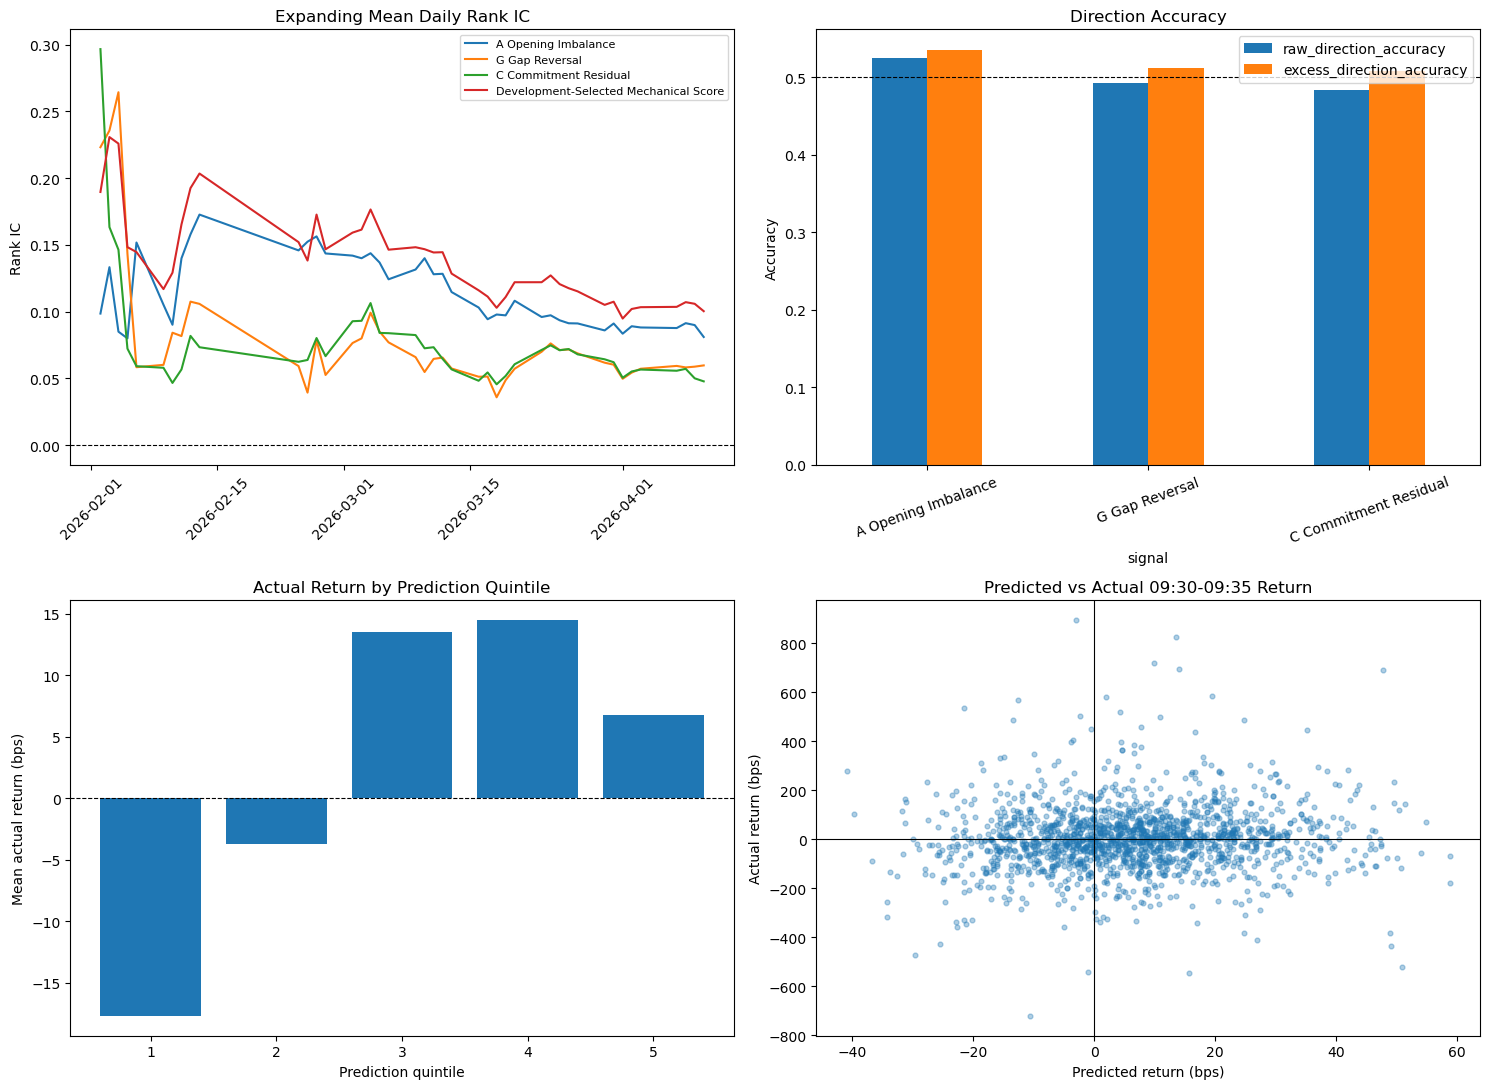

In [286]:
# ============================================================
# 9.6 Time/Liquidity Robustness and Required Visuals
# ============================================================

final_score_column = MECHANICAL_SCORE_COLUMNS["Development-Selected Mechanical Score"]
final_factor_df["final_subperiod"] = np.where(
    final_factor_df["date"].isin(last_21_final_dates),
    "Last 21 OOS dates", "Earlier OOS dates"
)

robustness_rows = []
for split_type, group_column in [
    ("Time", "final_subperiod"),
    ("Liquidity", "final_liquidity_group"),
]:
    for group_value, subframe in final_factor_df.groupby(
        group_column, observed=True
    ):
        daily = _f9_daily_rank_ic(subframe, final_score_column)
        robustness_rows.append({
            "split_type": split_type,
            "group": group_value,
            "n_obs": len(subframe),
            "n_dates": subframe["date"].nunique(),
            "mean_daily_rank_ic": daily["daily_rank_ic"].mean(),
            "median_daily_rank_ic": daily["daily_rank_ic"].median(),
            "positive_daily_ic_ratio": (
                daily["daily_rank_ic"] > 0
            ).mean(),
        })
final_robustness_summary = pd.DataFrame(robustness_rows)
display(final_robustness_summary)

quintile_frame = final_return_predictions.copy()
quintile_frame["prediction_quintile"] = (
    quintile_frame.groupby("date", observed=True)["predicted_return_5m"]
    .transform(
        lambda x: pd.qcut(
            x.rank(method="first"), 5, labels=False, duplicates="drop"
        ) + 1
    )
)
final_quintile_summary = (
    quintile_frame.groupby("prediction_quintile", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        mean_predicted_bps=("predicted_return_5m", lambda x: x.mean() * 1e4),
        mean_actual_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        median_actual_bps=("future_return_5m_raw", lambda x: x.median() * 1e4),
        positive_actual_ratio=("future_return_5m_raw", lambda x: (x > 0).mean()),
    )
    .reset_index()
)
display(final_quintile_summary)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for name in [
    "A Opening Imbalance", "G Gap Reversal", "C Commitment Residual",
    "Development-Selected Mechanical Score",
]:
    column = (
        FINAL_SCORE_COLUMNS[name]
        if name in FINAL_SCORE_COLUMNS
        else MECHANICAL_SCORE_COLUMNS[name]
    )
    series = _f9_daily_rank_ic(
        final_factor_df, column
    ).set_index("date")["daily_rank_ic"].sort_index()
    axes[0, 0].plot(series.index, series.expanding().mean(), label=name)
axes[0, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Expanding Mean Daily Rank IC")
axes[0, 0].set_ylabel("Rank IC")
axes[0, 0].legend(fontsize=8)
axes[0, 0].tick_params(axis="x", rotation=45)

direction_plot = final_factor_summary[
    final_factor_summary["signal"].isin([
        "A Opening Imbalance", "G Gap Reversal", "C Commitment Residual"
    ])
].set_index("signal")[[
    "raw_direction_accuracy", "excess_direction_accuracy"
]]
direction_plot.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].axhline(0.5, color="black", linewidth=0.8, linestyle="--")
axes[0, 1].set_title("Direction Accuracy")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].bar(
    final_quintile_summary["prediction_quintile"].astype(str),
    final_quintile_summary["mean_actual_bps"],
)
axes[1, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1, 0].set_title("Actual Return by Prediction Quintile")
axes[1, 0].set_xlabel("Prediction quintile")
axes[1, 0].set_ylabel("Mean actual return (bps)")

axes[1, 1].scatter(
    final_return_predictions["predicted_return_5m_bps"],
    final_return_predictions["actual_return_5m_bps"],
    alpha=0.35, s=12,
)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Predicted vs Actual 09:30-09:35 Return")
axes[1, 1].set_xlabel("Predicted return (bps)")
axes[1, 1].set_ylabel("Actual return (bps)")

plt.tight_layout()
plt.show()


## 9.7 Final interpretation and handoff

Complete the conclusion in this order after execution:

1. report A, G and C raw IC on the identical 43-date sample;
2. report whether G retains IC beyond A and whether C retains IC beyond A+G;
3. list the automatically promoted factors and rejected factors;
4. compare the promoted mechanical score with A alone;
5. report calibrated return prediction IC, direction accuracy, MAE, RMSE and OOS R2;
6. verify that prediction quintile returns are reasonably monotonic;
7. report last-21-date and liquidity results;
8. freeze the formula for dates after the current sample.

Possible conclusions are deliberately limited:

- **A only:** no second factor has demonstrated independent information;
- **A + G:** gap reversal adds independent price-location information;
- **A + C:** order-price mismatch adds information but gap reversal does not;
- **A + G + C:** both price correction and order credibility survive independently.

The final output columns are `final_factor_score`, `predicted_return_5m`, and `predicted_return_5m_bps`. They are model-development OOS estimates until the locked formula is evaluated on genuinely later dates.


# Part X. Locked A / A+G Validation

## 10.0 本部分回答什么

Part IX 已经得到两个需要明确区分的版本：

- **Frozen baseline：A only**  
  `09:30 五档盘口不平衡`，它是当前最清晰、最稳定的方向基准。
- **Locked challenger：A + G**  
  `A` 与 `隔夜缺口反转 G` 的等权横截面排名组合。它在当前开发样本中平均 IC 较高，但配对增量证据尚不足，因此不能称为“最终晋级模型”。

本部分不再搜索权重、不增加阈值，也不根据结果制造新过滤器。只完成四件事：

1. 使用 moving-block bootstrap、Newey–West 与 leave-one-week-out 检验 A+G 相对 A 的增量；
2. 诊断高流动性组为何均值 IC 偏弱；
3. 诊断预测最高组 Q5 为何没有保持严格单调；
4. 检验结论是否被少数股票或当前 40 只股票的构成主导。

这些检验仍属于 **development-sample validation**。真正的晋级只能由未来、未参与任何选择的 holdout 决定。


In [304]:
# 10.1 Freeze the two specifications; do not tune below this line.
import math
import numpy as np
import pandas as pd

required_x = {
    "final_factor_df",
    "_f9_daily_rank_ic",
}
missing_x = sorted(name for name in required_x if name not in globals())
assert not missing_x, (
    f"Missing Part IX objects: {missing_x}. Run Part IX in order before Part X."
)

LOCKED_A_COLUMN = next(
    (
        col for col in [
            "A_opening__rank_score",
            "A_opening_rank_score",
            "a_imbalance_rank_score",
        ]
        if col in final_factor_df.columns
    ),
    None,
)
LOCKED_G_COLUMN = next(
    (
        col for col in [
            "G_gap_reversal__rank_score",
            "G_gap_reversal_rank_score",
            "gap_opening_reversal_confirmed_signal",
        ]
        if col in final_factor_df.columns
    ),
    None,
)
assert LOCKED_A_COLUMN is not None, (
    "Cannot locate the frozen A score. Available rank columns: "
    f"{[c for c in final_factor_df.columns if 'rank_score' in c]}"
)
assert LOCKED_G_COLUMN is not None, (
    "Cannot locate the locked G score. Available gap columns: "
    f"{[c for c in final_factor_df.columns if 'gap' in c.lower()]}"
)
TARGET_X = "future_excess_return_5m"
RAW_TARGET_X = "future_return_5m_raw"

required_columns_x = {
    "code", "date", LOCKED_A_COLUMN, LOCKED_G_COLUMN,
    TARGET_X, RAW_TARGET_X,
}
missing_columns_x = required_columns_x.difference(final_factor_df.columns)
assert not missing_columns_x, f"final_factor_df is missing: {sorted(missing_columns_x)}"

locked_validation_df = final_factor_df.copy()
locked_validation_df["date"] = pd.to_datetime(locked_validation_df["date"]).dt.tz_localize(None)
locked_validation_df["locked_A_score"] = pd.to_numeric(
    locked_validation_df[LOCKED_A_COLUMN], errors="coerce"
)
locked_validation_df["locked_AG_score"] = (
    pd.to_numeric(locked_validation_df[LOCKED_A_COLUMN], errors="coerce")
    + pd.to_numeric(locked_validation_df[LOCKED_G_COLUMN], errors="coerce")
) / 2.0

def _x_rank_corr(left, right, minimum=8):
    pair = pd.DataFrame({"left": left, "right": right}).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if (
        len(pair) < minimum
        or pair["left"].nunique() < 3
        or pair["right"].nunique() < 3
    ):
        return np.nan
    return pair["left"].corr(pair["right"], method="spearman")

def _x_daily_ic_frame(frame, score_columns, target=TARGET_X):
    rows = []
    for dt, group in frame.groupby("date", sort=True):
        row = {"date": pd.Timestamp(dt)}
        for score in score_columns:
            row[score] = _x_rank_corr(group[score], group[target])
        rows.append(row)
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

locked_daily_ic = _x_daily_ic_frame(
    locked_validation_df,
    ["locked_A_score", "locked_AG_score"],
)
locked_daily_ic["AG_minus_A"] = (
    locked_daily_ic["locked_AG_score"] - locked_daily_ic["locked_A_score"]
)

locked_specification = pd.DataFrame([
    {
        "role": "Frozen baseline",
        "name": "A only",
        "formula": "rank_cs(opening_depth_imbalance_5)",
        "tuning_status": "Frozen",
    },
    {
        "role": "Locked challenger",
        "name": "A + G",
        "formula": "0.5 * rank_cs(A) + 0.5 * rank_cs(gap_reversal)",
        "tuning_status": "Frozen; future holdout required",
    },
])

display(locked_specification)
display(locked_daily_ic.head())


,role,name,formula,tuning_status
0,Frozen baseline,A only,rank_cs(opening_depth_imbalance_5),Frozen
1,Locked challenger,A + G,0.5 * rank_cs(A) + 0.5 * rank_cs(gap_reversal),Frozen; future holdout required


,date,locked_A_score,locked_AG_score,AG_minus_A
0,2026-02-02,0.098499,0.189565,0.091066
1,2026-02-03,0.167949,0.271759,0.103810
2,2026-02-04,-0.011632,0.216059,0.227691
3,2026-02-05,0.064916,-0.084440,-0.149355
4,2026-02-06,0.438837,0.129943,-0.308894


## 10.2 更严格的时间序列统计

普通 bootstrap 把每日 IC 当作完全独立样本，可能低估连续交易日之间的相关性。本节同时使用：

- **5 日 moving-block bootstrap**：保留一周内的时间依赖；
- **Newey–West/HAC**：对均值增量的标准误做自相关修正；
- **Leave-one-week-out**：逐周删除，检查结论是否由某一周驱动；
- **前段与最近 21 日对照**：只判断衰减幅度，不把点估计下降直接写成“显著衰减”。


In [305]:
# 10.2 Strong paired tests for locked A+G versus frozen A.
def _x_moving_block_means(values, block_length=5, n_boot=10000, seed=20260723):
    arr = np.asarray(pd.Series(values).dropna(), dtype=float)
    n = len(arr)
    assert n >= block_length, "Not enough observations for moving-block bootstrap."
    rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(n / block_length))
    out = np.empty(n_boot, dtype=float)
    offsets = np.arange(block_length)
    for b in range(n_boot):
        starts = rng.integers(0, n, size=n_blocks)
        idx = ((starts[:, None] + offsets[None, :]) % n).ravel()[:n]
        out[b] = arr[idx].mean()
    return out

def _x_newey_west_mean_test(values, max_lag=5):
    arr = np.asarray(pd.Series(values).dropna(), dtype=float)
    n = len(arr)
    centered = arr - arr.mean()
    gamma0 = float(np.dot(centered, centered) / n)
    long_run_variance = gamma0
    for lag in range(1, min(max_lag, n - 1) + 1):
        gamma = float(np.dot(centered[lag:], centered[:-lag]) / n)
        weight = 1.0 - lag / (max_lag + 1.0)
        long_run_variance += 2.0 * weight * gamma
    standard_error = math.sqrt(max(long_run_variance, 0.0) / n)
    t_stat = arr.mean() / standard_error if standard_error > 0 else np.nan
    one_sided_p = (
        0.5 * math.erfc(t_stat / math.sqrt(2.0))
        if np.isfinite(t_stat) else np.nan
    )
    return standard_error, t_stat, one_sided_p

paired_diff_x = locked_daily_ic["AG_minus_A"].dropna()
block_boot_x = _x_moving_block_means(paired_diff_x)
nw_se_x, nw_t_x, nw_p_x = _x_newey_west_mean_test(paired_diff_x)

week_id_x = np.arange(len(locked_daily_ic)) // 5
leave_week_rows_x = []
for week in np.unique(week_id_x):
    keep = week_id_x != week
    leave_week_rows_x.append({
        "left_out_week": int(week + 1),
        "n_dates_retained": int(keep.sum()),
        "mean_AG_minus_A_ic": locked_daily_ic.loc[keep, "AG_minus_A"].mean(),
    })
leave_one_week_out_x = pd.DataFrame(leave_week_rows_x)

n_recent_x = min(21, len(locked_daily_ic) // 2)
early_diff_x = locked_daily_ic["AG_minus_A"].iloc[:-n_recent_x].dropna()
recent_diff_x = locked_daily_ic["AG_minus_A"].iloc[-n_recent_x:].dropna()
early_boot_x = _x_moving_block_means(early_diff_x, block_length=min(5, len(early_diff_x)))
recent_boot_x = _x_moving_block_means(recent_diff_x, block_length=min(5, len(recent_diff_x)), seed=20260724)
decay_boot_x = early_boot_x - recent_boot_x

strong_statistics_x = pd.DataFrame([
    {"metric": "n_paired_dates", "value": len(paired_diff_x)},
    {"metric": "mean_AG_minus_A_daily_ic", "value": paired_diff_x.mean()},
    {"metric": "median_AG_minus_A_daily_ic", "value": paired_diff_x.median()},
    {"metric": "moving_block_ci_low", "value": np.quantile(block_boot_x, 0.025)},
    {"metric": "moving_block_ci_high", "value": np.quantile(block_boot_x, 0.975)},
    {"metric": "moving_block_probability_increment_positive", "value": np.mean(block_boot_x > 0)},
    {"metric": "newey_west_standard_error", "value": nw_se_x},
    {"metric": "newey_west_t_stat", "value": nw_t_x},
    {"metric": "newey_west_one_sided_p_value", "value": nw_p_x},
    {"metric": "leave_one_week_out_min_increment", "value": leave_one_week_out_x["mean_AG_minus_A_ic"].min()},
    {"metric": "leave_one_week_out_max_increment", "value": leave_one_week_out_x["mean_AG_minus_A_ic"].max()},
    {"metric": "leave_one_week_out_positive_ratio", "value": (leave_one_week_out_x["mean_AG_minus_A_ic"] > 0).mean()},
    {"metric": "early_mean_increment", "value": early_diff_x.mean()},
    {"metric": "recent_21_mean_increment", "value": recent_diff_x.mean()},
    {"metric": "P(early_increment > recent_increment)", "value": np.mean(decay_boot_x > 0)},
])

display(strong_statistics_x)
display(leave_one_week_out_x)


,metric,value
0,n_paired_dates,43.000000
1,mean_AG_minus_A_daily_ic,0.019327
2,median_AG_minus_A_daily_ic,0.013379
3,moving_block_ci_low,-0.021046
4,moving_block_ci_high,0.060387
5,moving_block_probability_increment_positive,0.821300
6,newey_west_standard_error,0.017588
7,newey_west_t_stat,1.098833
8,newey_west_one_sided_p_value,0.135920
9,leave_one_week_out_min_increment,0.009780


,left_out_week,n_dates_retained,mean_AG_minus_A_ic
0,1,38,0.022809
1,2,38,0.012839
2,3,38,0.023163
3,4,38,0.019887
4,5,38,0.022174
5,6,38,0.009780
6,7,38,0.024815
7,8,38,0.022791
8,9,40,0.015865


### 10.2 判定口径

- 若 block-bootstrap 区间跨 0，A+G 仍只能称为 **locked challenger**；
- Newey–West 与 leave-one-week-out 用来判断增量是否依赖少数连续日期；
- “最近 21 日均值较低”本身不是显著衰减；只有时间分段差异检验也支持时，才可写成衰减证据；
- 无论本节是否通过，当前 43 个 OOS 日期已经参与因子选择，因此都不能替代 future holdout。


## 10.3 高流动性组失效诊断

已有结果显示高流动性组的**平均** IC 偏弱，但其中位数和正 IC 日期比例并非同时为负。这可能是：

1. 少数极端日期拖累均值；
2. 高流动性股票的盘口不平衡更容易被补单、套利或更深的真实流动性吸收；
3. 当前 40 只股票的高流动性组构成特殊。

本节只做诊断，不依据结果新建流动性阈值。


In [306]:
# 10.3 Diagnose liquidity heterogeneity without tuning a filter.
liquidity_column_x = next(
    (
        col for col in [
            "rolling_5d_amount", "prev_day_amount", "auction_trade_amount",
            "auction_amount",
        ]
        if col in locked_validation_df.columns
    ),
    None,
)
assert liquidity_column_x is not None, "No liquidity proxy is available."

locked_validation_df["liquidity_proxy_x"] = pd.to_numeric(
    locked_validation_df[liquidity_column_x], errors="coerce"
)
locked_validation_df["daily_liquidity_group_x"] = locked_validation_df.groupby(
    "date", observed=True
)["liquidity_proxy_x"].transform(
    lambda s: pd.qcut(
        s.rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop",
    )
)

liquidity_ic_rows_x = []
for (dt, group_name), group in locked_validation_df.groupby(
    ["date", "daily_liquidity_group_x"], observed=True, sort=True
):
    liquidity_ic_rows_x.append({
        "date": pd.Timestamp(dt),
        "liquidity_group": str(group_name),
        "n_obs": len(group),
        "daily_ic": _x_rank_corr(group["locked_AG_score"], group[TARGET_X]),
    })
liquidity_daily_ic_x = pd.DataFrame(liquidity_ic_rows_x)

def _x_trimmed_mean(values, proportion=0.10):
    arr = np.sort(np.asarray(pd.Series(values).dropna(), dtype=float))
    if len(arr) == 0:
        return np.nan
    k = int(math.floor(len(arr) * proportion))
    return arr[k:len(arr)-k].mean() if 2 * k < len(arr) else arr.mean()

liquidity_summary_rows_x = []
for group_name, group in liquidity_daily_ic_x.groupby("liquidity_group", sort=False):
    vals = group["daily_ic"].dropna()
    boot = _x_moving_block_means(vals, block_length=min(5, len(vals)), seed=20260725)
    worst_three_removed = vals.drop(vals.nsmallest(min(3, len(vals))).index)
    liquidity_summary_rows_x.append({
        "liquidity_group": group_name,
        "n_dates": len(vals),
        "mean_daily_ic": vals.mean(),
        "median_daily_ic": vals.median(),
        "trimmed_mean_daily_ic_10pct": _x_trimmed_mean(vals),
        "positive_ic_ratio": (vals > 0).mean(),
        "worst_daily_ic": vals.min(),
        "mean_ic_after_removing_worst_3_dates": worst_three_removed.mean(),
        "block_ci_low": np.quantile(boot, 0.025),
        "block_ci_high": np.quantile(boot, 0.975),
    })
liquidity_diagnostic_summary_x = pd.DataFrame(liquidity_summary_rows_x)

liq_pivot_x = liquidity_daily_ic_x.pivot(
    index="date", columns="liquidity_group", values="daily_ic"
).sort_index()
liquidity_pair_rows_x = []
for group_name in ["Low", "Medium"]:
    if group_name in liq_pivot_x.columns and "High" in liq_pivot_x.columns:
        diff = (liq_pivot_x[group_name] - liq_pivot_x["High"]).dropna()
        boot = _x_moving_block_means(diff, block_length=min(5, len(diff)), seed=20260726)
        liquidity_pair_rows_x.append({
            "comparison": f"{group_name} minus High",
            "n_paired_dates": len(diff),
            "mean_ic_difference": diff.mean(),
            "block_ci_low": np.quantile(boot, 0.025),
            "block_ci_high": np.quantile(boot, 0.975),
            "probability_difference_positive": np.mean(boot > 0),
        })
liquidity_paired_test_x = pd.DataFrame(liquidity_pair_rows_x)

worst_high_dates_x = (
    liquidity_daily_ic_x.query("liquidity_group == 'High'")
    .nsmallest(5, "daily_ic")
    .reset_index(drop=True)
)

display(pd.DataFrame({"liquidity_proxy_used": [liquidity_column_x]}))
display(liquidity_diagnostic_summary_x)
display(liquidity_paired_test_x)
display(worst_high_dates_x)


,liquidity_proxy_used
0,rolling_5d_amount


,liquidity_group,n_dates,mean_daily_ic,median_daily_ic,trimmed_mean_daily_ic_10pct,positive_ic_ratio,worst_daily_ic,mean_ic_after_removing_worst_3_dates,block_ci_low,block_ci_high
0,Low,43,0.180637,0.184319,0.181038,0.767442,-0.374141,0.218188,0.109126,0.259023
1,Medium,43,0.157612,0.146208,0.151268,0.604651,-0.384615,0.194206,0.075057,0.242980
2,High,43,-0.018806,0.050549,-0.004421,0.581395,-0.807481,0.037690,-0.132922,0.087676


,comparison,n_paired_dates,mean_ic_difference,block_ci_low,block_ci_high,probability_difference_positive
0,Low minus High,43,0.199443,0.086788,0.314600,0.9995
1,Medium minus High,43,0.176418,0.038486,0.331788,0.9952


,date,liquidity_group,n_obs,daily_ic
0,2026-02-24,High,14,-0.807481
1,2026-04-01,High,13,-0.763736
2,2026-03-13,High,14,-0.745055
3,2026-04-10,High,14,-0.737074
4,2026-03-30,High,13,-0.561986


## 10.4 Q5 非单调诊断

如果 Q5 的平均收益低于 Q4，不能立刻解释为“信号过强后反转”。需要区分：

- Q5 是否被少数极端亏损拖累；
- Q5 的中位数和正收益比例是否仍然改善；
- Q5 是否集中于某类流动性股票；
- Q5 中 A 与 G 是一致，还是由单个因子极端值推入最高组。

本节不据此调 Q4/Q5 阈值。


In [316]:
# 10.4 Diagnose the top-score bucket without choosing a new cutoff.
def _x_daily_quintile(series):
    valid = series.notna()
    out = pd.Series(np.nan, index=series.index, dtype=float)
    if valid.sum() >= 5:
        out.loc[valid] = pd.qcut(
            series.loc[valid].rank(method="first"),
            q=5,
            labels=[1, 2, 3, 4, 5],
            duplicates="drop",
        ).astype(float)
    return out

locked_validation_df["locked_AG_quintile"] = locked_validation_df.groupby(
    "date", group_keys=False
)["locked_AG_score"].apply(_x_daily_quintile)

daily_quintile_returns_x = (
    locked_validation_df.dropna(subset=["locked_AG_quintile", TARGET_X])
    .groupby(["date", "locked_AG_quintile"], observed=True)[TARGET_X]
    .agg(["count", "mean", "median"])
    .reset_index()
)
daily_quintile_returns_x["mean_bps"] = daily_quintile_returns_x["mean"] * 1e4
daily_quintile_returns_x["median_bps"] = daily_quintile_returns_x["median"] * 1e4

quintile_distribution_summary_x = (
    daily_quintile_returns_x.groupby("locked_AG_quintile", observed=True)
    .agg(
        n_dates=("date", "nunique"),
        mean_of_daily_mean_bps=("mean_bps", "mean"),
        median_daily_mean_bps=("mean_bps", "median"),
        mean_of_daily_median_bps=("median_bps", "mean"),
        positive_daily_mean_ratio=("mean_bps", lambda s: (s > 0).mean()),
    )
    .reset_index()
)

q_pivot_x = daily_quintile_returns_x.pivot(
    index="date", columns="locked_AG_quintile", values="mean_bps"
).sort_index()
q5_minus_q4_x = (q_pivot_x.get(5.0) - q_pivot_x.get(4.0)).dropna()
q54_boot_x = _x_moving_block_means(
    q5_minus_q4_x,
    block_length=min(5, len(q5_minus_q4_x)),
    seed=20260727,
)
q5_q4_test_x = pd.DataFrame([
    {"metric": "n_paired_dates", "value": len(q5_minus_q4_x)},
    {"metric": "mean_Q5_minus_Q4_bps", "value": q5_minus_q4_x.mean()},
    {"metric": "median_Q5_minus_Q4_bps", "value": q5_minus_q4_x.median()},
    {"metric": "positive_Q5_minus_Q4_day_ratio", "value": (q5_minus_q4_x > 0).mean()},
    {"metric": "block_ci_low_bps", "value": np.quantile(q54_boot_x, 0.025)},
    {"metric": "block_ci_high_bps", "value": np.quantile(q54_boot_x, 0.975)},
    {"metric": "probability_Q5_higher_than_Q4", "value": np.mean(q54_boot_x > 0)},
])

def _x_sign_label(a, g):
    if not np.isfinite(a) or not np.isfinite(g):
        return "Unavailable"
    if a > 0 and g > 0:
        return "A and G both positive"
    if a < 0 and g < 0:
        return "A and G both negative"
    if a * g < 0:
        return "A and G conflict"
    return "One component near zero"

locked_validation_df["AG_agreement_state_x"] = [
    _x_sign_label(a, g)
    for a, g in zip(
        locked_validation_df["locked_A_score"],
        locked_validation_df[LOCKED_G_COLUMN],
    )
]
q5_frame_x = locked_validation_df.query("locked_AG_quintile == 5").copy()
q5_composition_x = (
    q5_frame_x.groupby(
        ["daily_liquidity_group_x", "AG_agreement_state_x"],
        observed=True,
    )
    .agg(
        n_obs=("code", "size"),
        n_dates=("date", "nunique"),
        mean_A_score=("locked_A_score", "mean"),
        mean_G_score=(LOCKED_G_COLUMN, "mean"),
        mean_excess_return_bps=(TARGET_X, lambda s: s.mean() * 1e4),
        median_excess_return_bps=(TARGET_X, lambda s: s.median() * 1e4),
        positive_return_ratio=(TARGET_X, lambda s: (s > 0).mean()),
    )
    .reset_index()
    .sort_values("n_obs", ascending=False)
)

display(quintile_distribution_summary_x)
display(q5_q4_test_x)
display(q5_composition_x)


,locked_AG_quintile,n_dates,mean_of_daily_mean_bps,median_daily_mean_bps,mean_of_daily_median_bps,positive_daily_mean_ratio
0,1.0,43,-18.779505,-31.969814,-20.193787,0.348837
1,2.0,43,-5.378225,-1.782513,-7.724690,0.465116
2,3.0,43,12.628034,10.424266,1.719911,0.651163
3,4.0,43,13.501140,3.521358,6.635496,0.604651
4,5.0,43,5.200006,13.469486,5.739022,0.651163


,metric,value
0,n_paired_dates,43.000000
1,mean_Q5_minus_Q4_bps,-8.301133
2,median_Q5_minus_Q4_bps,3.641420
3,positive_Q5_minus_Q4_day_ratio,0.511628
4,block_ci_low_bps,-22.931954
5,block_ci_high_bps,5.525609
6,probability_Q5_higher_than_Q4,0.123500


,daily_liquidity_group_x,AG_agreement_state_x,n_obs,n_dates,mean_A_score,mean_G_score,mean_excess_return_bps,median_excess_return_bps,positive_return_ratio
6,High,A and G both positive,136,43,0.646529,0.707518,2.585544,3.172964,0.507353
3,Medium,A and G both positive,100,40,0.607543,0.536882,11.572709,14.941052,0.570000
0,Low,A and G both positive,82,36,0.529454,0.535888,8.146468,8.626537,0.573171
7,High,A and G conflict,11,11,0.422145,0.367716,-19.703050,-7.942856,0.454545
4,Medium,A and G conflict,6,6,0.377991,0.336111,-116.942309,-9.922787,0.166667
8,High,One component near zero,4,4,0.237500,0.575000,5.228895,-1.544751,0.500000
2,Low,One component near zero,2,2,0.750000,0.000000,-5.956665,-5.956665,0.500000
5,Medium,One component near zero,2,2,0.800000,0.000000,252.895412,252.895412,1.000000
1,Low,A and G conflict,1,1,0.950000,-0.050000,15.481360,15.481360,1.000000


## 10.5 股票池敏感性

当前样本只有 40 只股票。下面做两种内部敏感性检验：

- **按股票流动性分层的 80% 子样本重复抽样**：避免随机抽样意外丢失某一流动性层；
- **Leave-one-stock-out**：逐只删除股票，检查 A+G 相对 A 的增量是否由单一股票决定。

这只能说明结果在当前股票池内部是否脆弱，不能证明对全 A 股有效。外部有效性仍需要更大、按板块与流动性分层的新股票池。


In [317]:
# 10.5 Stock-universe sensitivity.
stock_profile_x = (
    locked_validation_df.groupby("code", as_index=False)
    .agg(median_liquidity=("liquidity_proxy_x", "median"))
)
stock_profile_x["stock_liquidity_stratum"] = pd.qcut(
    stock_profile_x["median_liquidity"].rank(method="first"),
    q=3,
    labels=["Low", "Medium", "High"],
)
stock_stratum_map_x = stock_profile_x.set_index("code")["stock_liquidity_stratum"]

def _x_mean_ic_for_stock_set(stock_set, score):
    frame = locked_validation_df[locked_validation_df["code"].isin(stock_set)]
    values = []
    for _, group in frame.groupby("date", sort=True):
        values.append(_x_rank_corr(group[score], group[TARGET_X]))
    return pd.Series(values, dtype=float).mean()

rng_x = np.random.default_rng(20260728)
stratified_rows_x = []
stock_groups_x = {
    stratum: group["code"].tolist()
    for stratum, group in stock_profile_x.groupby("stock_liquidity_stratum", observed=True)
}
for iteration in range(500):
    sampled = []
    for stratum, codes in stock_groups_x.items():
        take = max(2, int(math.ceil(0.80 * len(codes))))
        sampled.extend(rng_x.choice(codes, size=min(take, len(codes)), replace=False).tolist())
    a_ic = _x_mean_ic_for_stock_set(sampled, "locked_A_score")
    ag_ic = _x_mean_ic_for_stock_set(sampled, "locked_AG_score")
    stratified_rows_x.append({
        "iteration": iteration + 1,
        "n_stocks": len(sampled),
        "A_mean_daily_ic": a_ic,
        "AG_mean_daily_ic": ag_ic,
        "AG_minus_A_ic": ag_ic - a_ic,
    })
stratified_stock_bootstrap_x = pd.DataFrame(stratified_rows_x)

all_stocks_x = sorted(locked_validation_df["code"].dropna().unique())
leave_stock_rows_x = []
for excluded_stock in all_stocks_x:
    retained = [code for code in all_stocks_x if code != excluded_stock]
    a_ic = _x_mean_ic_for_stock_set(retained, "locked_A_score")
    ag_ic = _x_mean_ic_for_stock_set(retained, "locked_AG_score")
    leave_stock_rows_x.append({
        "excluded_stock": excluded_stock,
        "A_mean_daily_ic": a_ic,
        "AG_mean_daily_ic": ag_ic,
        "AG_minus_A_ic": ag_ic - a_ic,
    })
leave_one_stock_out_x = pd.DataFrame(leave_stock_rows_x)

stock_sensitivity_summary_x = pd.DataFrame([
    {
        "test": "500 stratified 80% stock subsamples",
        "n_runs": len(stratified_stock_bootstrap_x),
        "mean_AG_minus_A_ic": stratified_stock_bootstrap_x["AG_minus_A_ic"].mean(),
        "minimum_AG_minus_A_ic": stratified_stock_bootstrap_x["AG_minus_A_ic"].min(),
        "maximum_AG_minus_A_ic": stratified_stock_bootstrap_x["AG_minus_A_ic"].max(),
        "positive_increment_ratio": (stratified_stock_bootstrap_x["AG_minus_A_ic"] > 0).mean(),
        "p05": stratified_stock_bootstrap_x["AG_minus_A_ic"].quantile(0.05),
        "p95": stratified_stock_bootstrap_x["AG_minus_A_ic"].quantile(0.95),
    },
    {
        "test": "Leave one stock out",
        "n_runs": len(leave_one_stock_out_x),
        "mean_AG_minus_A_ic": leave_one_stock_out_x["AG_minus_A_ic"].mean(),
        "minimum_AG_minus_A_ic": leave_one_stock_out_x["AG_minus_A_ic"].min(),
        "maximum_AG_minus_A_ic": leave_one_stock_out_x["AG_minus_A_ic"].max(),
        "positive_increment_ratio": (leave_one_stock_out_x["AG_minus_A_ic"] > 0).mean(),
        "p05": leave_one_stock_out_x["AG_minus_A_ic"].quantile(0.05),
        "p95": leave_one_stock_out_x["AG_minus_A_ic"].quantile(0.95),
    },
])

display(stock_profile_x)
display(stock_sensitivity_summary_x)
display(leave_one_stock_out_x.sort_values("AG_minus_A_ic").head())


,code,median_liquidity,stock_liquidity_stratum
0,000713.SZ,1.323148e+08,Medium
1,000782.SZ,1.173453e+08,Medium
2,000816.SZ,2.916307e+08,High
3,000863.SZ,1.605586e+08,Medium
4,001215.SZ,1.115303e+08,Low
5,002240.SZ,1.674759e+09,High
6,002278.SZ,4.688453e+08,High
7,002438.SZ,3.159269e+08,High
8,002441.SZ,1.794357e+08,Medium
9,002451.SZ,1.950965e+08,Medium


,test,n_runs,mean_AG_minus_A_ic,minimum_AG_minus_A_ic,maximum_AG_minus_A_ic,positive_increment_ratio,p05,p95
0,500 stratified 80% stock subsamples,500,0.019265,-0.023936,0.048379,0.962,0.001635,0.036595
1,Leave one stock out,40,0.019311,0.007656,0.027914,1.000,0.012522,0.027569


,excluded_stock,A_mean_daily_ic,AG_mean_daily_ic,AG_minus_A_ic
5,002240.SZ,0.091231,0.098887,0.007656
28,603466.SH,0.090799,0.100711,0.009913
7,002438.SZ,0.085051,0.097710,0.012659
33,688089.SH,0.079838,0.093328,0.013490
3,000863.SZ,0.080638,0.094473,0.013835


## 10.6 冻结后的 future-holdout 协议

从本节开始，下一批新日期进入前不再更改以下定义：

```text
Baseline:
    A = cross-sectional rank(09:30 five-level depth imbalance)

Challenger:
    A+G = 0.5 × rank(A)
        + 0.5 × rank(market-adjusted overnight-gap reversal)
```

未来样本需同时报告：

1. 每日 Rank IC、ICIR、正 IC 日期比例；
2. A+G 相对 A 的同日期配对 IC 增量；
3. raw return 与 market-adjusted excess return 的方向准确率、MAE、RMSE；
4. Q1–Q5 分组收益及 Q5−Q4；
5. 日期、板块、流动性分层；
6. 若盘口买卖价可用，再报告可执行收益；否则只能标注为 mid-price research return。

预注册判断：

- **H1**：A+G 的平均每日 IC 高于 A；
- **H2**：A/A+G 在低—中流动性样本更强，高流动性差异仅作为异质性结论；
- **H3**：Q5 非单调若不能在 future holdout 重现，应视为开发样本尾部噪声，而不是建立反转规则。

在 future holdout 之前，正式表述应为：

> A 是冻结基准；A+G 是锁定挑战者。A+G 在开发样本中提高了排序相关性，但当前证据不足以宣称稳定替代 A。


In [326]:
# 10.7 Compact handoff table for the report.
locked_handoff_x = pd.DataFrame([
    {
        "item": "Primary target",
        "decision": "09:30→09:35 signed return",
        "status": "Frozen",
    },
    {
        "item": "Baseline",
        "decision": "A only: 09:30 five-level opening depth imbalance",
        "status": "Frozen",
    },
    {
        "item": "Challenger",
        "decision": "Equal-rank A + market-adjusted overnight-gap reversal G",
        "status": "Locked; not promoted",
    },
    {
        "item": "Magnitude branch",
        "decision": "Opportunity/risk diagnostic",
        "status": "Not mechanically multiplied into signed prediction",
    },
    {
        "item": "Next decisive evidence",
        "decision": "Future dates and a larger stratified stock universe",
        "status": "Required",
    },
])
display(locked_handoff_x)


,item,decision,status
0,Primary target,09:30→09:35 signed return,Frozen
1,Baseline,A only: 09:30 five-level opening depth imbalance,Frozen
2,Challenger,Equal-rank A + market-adjusted overnight-gap r...,Locked; not promoted
3,Magnitude branch,Opportunity/risk diagnostic,Not mechanically multiplied into signed predic...
4,Next decisive evidence,Future dates and a larger stratified stock uni...,Required


# Part XI. Auction Pressure Absorption and Opening-Book Innovation

## 11.0 为什么动态可信度拓宽了 A 的经济逻辑

静态 A 只回答：

> 09:30 最终盘口是买方占优还是卖方占优？

但相同的最终 A 可以由完全不同的路径形成：

```text
持续买方承接
→ 竞价末段与开盘方向一致，压力较稳定

最后阶段突然增强
→ 可能是新信息，也可能是临时冲击

卖单大量撤回
→ 表面买方占优，但真实新增需求有限

竞价压力与09:30盘口反向
→ 原有情绪被吸收、撤回或被新订单覆盖
```

因此，动态拆解不是继续扩大 feature 数量，而是增加静态 A 缺少的四类信息：

1. **来源**：买卖压力在竞价末段如何形成；
2. **持续性**：压力是稳定存在还是最后阶段跳变；
3. **承诺程度**：提交压力经过撤单后保留了多少；
4. **传递结果**：竞价压力是否真正传递到 09:30 开盘盘口。

本节使用 Notebook 4 已导出的竞价末段特征，因此只能称为
**auction-stage formation proxy**。它不是 09:29:30–09:30:00 的逐秒连续竞价盘口快照。

本节只回答“什么状态下 A 更可信”，不调整 A+G 权重，不把 confidence 直接乘入预测公式。


In [327]:
# 11.1 Load the auction-stage formation inputs and align them to locked OOS rows.
from pathlib import Path
import math
import numpy as np
import pandas as pd

required_11 = {"locked_validation_df", "LOCKED_A_COLUMN", "TARGET_X"}
missing_11 = sorted(name for name in required_11 if name not in globals())
assert not missing_11, (
    f"Missing Part X objects: {missing_11}. Run Part X 10.1 first."
)

RAW_A_COLUMN_11 = next(
    (
        column for column in [
            "strict_opening_depth_imbalance_5",
            "opening_imbalance_5_a1",
            "opening_imbalance_5",
        ]
        if column in locked_validation_df.columns
    ),
    None,
)
assert RAW_A_COLUMN_11 is not None, (
    "Cannot locate the raw five-level opening imbalance. "
    "Do not use the sign of a cross-sectional rank score as buy/sell direction."
)

def _first_existing_path_11(candidates):
    return next((path.resolve() for path in candidates if path.exists()), None)

AUCTION_FEATURE_PATH_11 = _first_existing_path_11([
    Path("04_auction_feature_table.csv"),
    Path("notebooks") / "04_auction_feature_table.csv",
    Path("..") / "notebooks" / "04_auction_feature_table.csv",
    Path(
        r"C:\Users\work\OneDrive\Documents\level2-research"
    ) / "notebooks" / "04_auction_feature_table.csv",
])
TRANSMISSION_FEATURE_PATH_11 = _first_existing_path_11([
    Path("04_information_transmission_features.csv"),
    Path("notebooks") / "04_information_transmission_features.csv",
    Path("..") / "notebooks" / "04_information_transmission_features.csv",
    Path(
        r"C:\Users\work\OneDrive\Documents\level2-research"
    ) / "notebooks" / "04_information_transmission_features.csv",
])
assert AUCTION_FEATURE_PATH_11 is not None, (
    "Run Notebook 4 organized feature export first. "
    "Expected 04_auction_feature_table.csv in the notebook or repo notebooks directory."
)
assert TRANSMISSION_FEATURE_PATH_11 is not None, (
    "Run Notebook 4 Part IX information-transmission export first. "
    "Expected 04_information_transmission_features.csv in the notebook or repo notebooks directory."
)
assert AUCTION_FEATURE_PATH_11.exists(), (
    "Run Notebook 4 organized feature export first: "
    f"{AUCTION_FEATURE_PATH_11}"
)
assert TRANSMISSION_FEATURE_PATH_11.exists(), (
    "Run Notebook 4 Part IX information-transmission export first: "
    f"{TRANSMISSION_FEATURE_PATH_11}"
)

auction_formation_11 = pd.read_csv(AUCTION_FEATURE_PATH_11)
transmission_11 = pd.read_csv(TRANSMISSION_FEATURE_PATH_11)
for frame in [auction_formation_11, transmission_11]:
    frame["code"] = frame["code"].astype(str).str.strip()
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce").dt.tz_localize(None)
    assert not frame.duplicated(["code", "date"]).any(), (
        "Notebook 4 export contains duplicate code-date rows."
    )

auction_columns_11 = [
    "code", "date",
    "last_minute_depth_imbalance", "final_depth_imbalance",
    "last_minute_total_depth", "final_total_depth",
    "last_minute_net_order_imbalance", "net_order_imbalance",
    "cancel_volume_ratio", "last_minute_submit_volume_share",
]
transmission_columns_11 = [
    "code", "date",
    "submitted_pressure", "cancellation_adjusted_pressure",
    "commitment_asymmetry", "execution_conversion_asymmetry",
]
missing_auction_11 = set(auction_columns_11).difference(auction_formation_11.columns)
missing_transmission_11 = set(transmission_columns_11).difference(transmission_11.columns)
assert not missing_auction_11, f"Missing auction columns: {sorted(missing_auction_11)}"
assert not missing_transmission_11, (
    f"Missing transmission columns: {sorted(missing_transmission_11)}"
)

a_dynamic_df = locked_validation_df.copy()
auction_new_columns_11 = [
    column for column in auction_columns_11[2:]
    if column not in a_dynamic_df.columns
]
transmission_new_columns_11 = [
    column for column in transmission_columns_11[2:]
    if column not in a_dynamic_df.columns
]
if auction_new_columns_11:
    a_dynamic_df = a_dynamic_df.merge(
        auction_formation_11[
            ["code", "date"] + auction_new_columns_11
        ],
        on=["code", "date"],
        how="left",
        validate="one_to_one",
    )
if transmission_new_columns_11:
    a_dynamic_df = a_dynamic_df.merge(
        transmission_11[
            ["code", "date"] + transmission_new_columns_11
        ],
        on=["code", "date"],
        how="left",
        validate="one_to_one",
    )

numeric_inputs_11 = auction_columns_11[2:] + transmission_columns_11[2:]
for column in numeric_inputs_11:
    a_dynamic_df[column] = pd.to_numeric(a_dynamic_df[column], errors="coerce")

a_dynamic_df["A_late_depth_shift"] = (
    a_dynamic_df["final_depth_imbalance"]
    - a_dynamic_df["last_minute_depth_imbalance"]
)
a_dynamic_df["A_depth_capacity_change"] = (
    np.log1p(a_dynamic_df["final_total_depth"].clip(lower=0))
    - np.log1p(a_dynamic_df["last_minute_total_depth"].clip(lower=0))
)
a_dynamic_df["A_cancellation_retention"] = (
    a_dynamic_df["cancellation_adjusted_pressure"]
    - a_dynamic_df["submitted_pressure"]
)
a_dynamic_df["A_auction_open_alignment"] = (
    np.sign(a_dynamic_df["final_depth_imbalance"])
    == np.sign(a_dynamic_df[RAW_A_COLUMN_11])
)
a_dynamic_df["A_late_direction_persistence"] = (
    np.sign(a_dynamic_df["last_minute_depth_imbalance"])
    == np.sign(a_dynamic_df["final_depth_imbalance"])
)

coverage_11 = pd.DataFrame([
    {
        "feature": column,
        "coverage_ratio": a_dynamic_df[column].notna().mean(),
        "n_unique": a_dynamic_df[column].nunique(dropna=True),
    }
    for column in [
        "last_minute_depth_imbalance", "final_depth_imbalance",
        "A_late_depth_shift", "A_depth_capacity_change",
        "submitted_pressure", "cancellation_adjusted_pressure",
        "A_cancellation_retention",
    ]
])
display(coverage_11)


,feature,coverage_ratio,n_unique
0,last_minute_depth_imbalance,0.991213,1681
1,final_depth_imbalance,1.000000,1642
2,A_late_depth_shift,0.991213,1662
3,A_depth_capacity_change,0.991213,1665
4,submitted_pressure,1.000000,1707
5,cancellation_adjusted_pressure,1.000000,1707
6,A_cancellation_retention,1.000000,1587


## 11.2 先画清楚形成通道，而不是直接制造复合因子

每个动态变量同时检验两条关系：

```text
形成变量 → 最终09:30 A
形成变量 → 09:30–09:35 excess return
```

前者强、后者弱，说明它只是解释 A 如何形成；  
两者都强，才可能成为具有独立预测价值的形成机制。


In [328]:
# 11.2 Formation-to-A and formation-to-return channels.
def _a11_rank_score_by_date(frame, raw_column, output_column):
    frame[output_column] = frame.groupby("date", group_keys=False)[raw_column].transform(
        lambda s: 2.0 * s.rank(pct=True, method="average") - 1.0
    )

def _a11_daily_corr(frame, left, right, minimum=8):
    rows = []
    for dt, daily in frame.groupby("date", sort=True):
        pair = daily[[left, right]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        value = np.nan
        if (
            len(pair) >= minimum
            and pair[left].nunique() >= 3
            and pair[right].nunique() >= 3
        ):
            value = pair[left].corr(pair[right], method="spearman")
        rows.append({"date": pd.Timestamp(dt), "daily_rank_ic": value})
    return pd.DataFrame(rows).dropna(subset=["daily_rank_ic"])

formation_features_11 = {
    "Auction final depth imbalance": "final_depth_imbalance",
    "Auction late depth shift": "A_late_depth_shift",
    "Auction depth capacity change": "A_depth_capacity_change",
    "Cancellation-adjusted pressure": "cancellation_adjusted_pressure",
    "Cancellation retention increment": "A_cancellation_retention",
    "Late net-order imbalance": "last_minute_net_order_imbalance",
}

formation_score_columns_11 = {}
for name, raw_column in formation_features_11.items():
    score_column = "a11__" + (
        name.lower().replace("-", "_").replace(" ", "_")
    ) + "__rank_score"
    _a11_rank_score_by_date(a_dynamic_df, raw_column, score_column)
    formation_score_columns_11[name] = score_column

formation_channel_rows_11 = []
formation_daily_series_11 = {}
for name, score_column in formation_score_columns_11.items():
    to_a = _a11_daily_corr(a_dynamic_df, score_column, "locked_A_score")
    to_return = _a11_daily_corr(a_dynamic_df, score_column, TARGET_X)
    formation_daily_series_11[(name, "A")] = to_a
    formation_daily_series_11[(name, "Return")] = to_return
    formation_channel_rows_11.append({
        "formation_mechanism": name,
        "score_column": score_column,
        "n_dates_to_A": to_a["date"].nunique(),
        "mean_formation_to_A_ic": to_a["daily_rank_ic"].mean(),
        "positive_formation_to_A_ratio": (to_a["daily_rank_ic"] > 0).mean(),
        "n_dates_to_return": to_return["date"].nunique(),
        "mean_formation_to_return_ic": to_return["daily_rank_ic"].mean(),
        "median_formation_to_return_ic": to_return["daily_rank_ic"].median(),
        "positive_return_ic_ratio": (to_return["daily_rank_ic"] > 0).mean(),
        "channel_strength": (
            to_a["daily_rank_ic"].mean()
            * to_return["daily_rank_ic"].mean()
        ),
    })
formation_channel_summary_11 = pd.DataFrame(
    formation_channel_rows_11
).sort_values("channel_strength", ascending=False)
display(formation_channel_summary_11)


,formation_mechanism,score_column,n_dates_to_A,mean_formation_to_A_ic,positive_formation_to_A_ratio,n_dates_to_return,mean_formation_to_return_ic,median_formation_to_return_ic,positive_return_ic_ratio,channel_strength
3,Cancellation-adjusted pressure,a11__cancellation_adjusted_pressure__rank_score,43,0.223890,0.930233,43,0.016638,0.007317,0.558140,0.003725
4,Cancellation retention increment,a11__cancellation_retention_increment__rank_score,43,0.087210,0.674419,43,0.001461,0.015956,0.511628,0.000127
2,Auction depth capacity change,a11__auction_depth_capacity_change__rank_score,43,0.020008,0.627907,43,-0.009236,0.012946,0.511628,-0.000185
1,Auction late depth shift,a11__auction_late_depth_shift__rank_score,43,-0.007497,0.465116,43,0.025390,0.035425,0.651163,-0.000190
5,Late net-order imbalance,a11__late_net_order_imbalance__rank_score,43,0.239120,0.906977,43,-0.031582,-0.006675,0.488372,-0.007552
0,Auction final depth imbalance,a11__auction_final_depth_imbalance__rank_score,43,0.172395,0.860465,43,-0.083290,-0.077486,0.186047,-0.014359


## 11.3 预注册动态状态

以下状态在查看收益前定义，不按结果调整阈值：

- **Late reversal into opening direction**：竞价末段方向发生反转，最终方向与 09:30 A 一致；
- **Late strengthening toward opening**：竞价方向已经与 A 一致，末段变化继续朝 A 加强，且变化幅度高于当日中位数；
- **Persistent auction-to-open support**：末段和最终竞价压力同向，且最终方向传递至 09:30；
- **Auction-to-open discontinuity**：最终竞价压力与 09:30 A 方向相反；
- **Mixed / weak formation**：其余弱状态。

它们回答的是 A 的可信度差异，不直接修改预测值。


In [329]:
# 11.3 Mutually exclusive A-formation states and economic outcomes.
a_dynamic_df["abs_late_shift_11"] = a_dynamic_df["A_late_depth_shift"].abs()
a_dynamic_df["daily_median_abs_late_shift_11"] = a_dynamic_df.groupby(
    "date"
)["abs_late_shift_11"].transform("median")

# Economic buy/sell states must use the raw imbalance sign.
# locked_A_score remains the cross-sectional ranking signal used for IC.
a_sign_11 = np.sign(a_dynamic_df[RAW_A_COLUMN_11])
last_sign_11 = np.sign(a_dynamic_df["last_minute_depth_imbalance"])
final_sign_11 = np.sign(a_dynamic_df["final_depth_imbalance"])
shift_sign_11 = np.sign(a_dynamic_df["A_late_depth_shift"])

reversal_into_a_11 = (
    (last_sign_11 * final_sign_11 < 0)
    & (final_sign_11 == a_sign_11)
)
late_strengthening_11 = (
    (final_sign_11 == a_sign_11)
    & (shift_sign_11 == a_sign_11)
    & (
        a_dynamic_df["abs_late_shift_11"]
        > a_dynamic_df["daily_median_abs_late_shift_11"]
    )
)
persistent_support_11 = (
    (last_sign_11 == final_sign_11)
    & (final_sign_11 == a_sign_11)
)
auction_open_break_11 = final_sign_11 * a_sign_11 < 0

a_dynamic_df["A_dynamic_state"] = np.select(
    [
        reversal_into_a_11,
        late_strengthening_11,
        persistent_support_11,
        auction_open_break_11,
    ],
    [
        "Late reversal into opening direction",
        "Late strengthening toward opening",
        "Persistent auction-to-open support",
        "Auction-to-open discontinuity",
    ],
    default="Mixed / weak formation",
)
a_dynamic_df["A_signed_excess_return_bps"] = (
    np.sign(a_dynamic_df[RAW_A_COLUMN_11])
    * a_dynamic_df[TARGET_X]
    * 1e4
)

state_summary_rows_11 = []
state_daily_ic_11 = {}
for state, group in a_dynamic_df.groupby("A_dynamic_state", sort=False):
    daily_ic = _a11_daily_corr(group, "locked_A_score", TARGET_X)
    state_daily_ic_11[state] = daily_ic
    signed = group["A_signed_excess_return_bps"].dropna()
    state_summary_rows_11.append({
        "A_dynamic_state": state,
        "n_obs": len(group),
        "n_dates": group["date"].nunique(),
        "mean_daily_observations": group.groupby("date").size().mean(),
        "n_ic_dates": daily_ic["date"].nunique(),
        "ic_reliability": (
            "Usable" if daily_ic["date"].nunique() >= 20
            else "Insufficient IC dates; use signed-return diagnostics only"
        ),
        "mean_A_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
        "median_A_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
        "positive_A_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        "mean_A_signed_excess_return_bps": signed.mean(),
        "median_A_signed_excess_return_bps": signed.median(),
        "A_excess_direction_accuracy": (signed > 0).mean(),
    })
a_dynamic_state_summary_11 = pd.DataFrame(
    state_summary_rows_11
).sort_values("mean_A_daily_rank_ic", ascending=False)
display(a_dynamic_state_summary_11)


,A_dynamic_state,n_obs,n_dates,mean_daily_observations,n_ic_dates,ic_reliability,mean_A_daily_rank_ic,median_A_daily_rank_ic,positive_A_ic_ratio,mean_A_signed_excess_return_bps,median_A_signed_excess_return_bps,A_excess_direction_accuracy
4,Late reversal into opening direction,204,43,4.744186,3,Insufficient IC dates; use signed-return diagn...,0.223232,0.381818,0.666667,17.331406,10.797769,0.558824
1,Auction-to-open discontinuity,679,43,15.790698,43,Usable,0.154094,0.134066,0.697674,19.138167,15.867541,0.594993
0,Persistent auction-to-open support,633,43,14.720930,43,Usable,-0.025704,0.014706,0.534884,-2.451064,-4.348864,0.472354
2,Late strengthening toward opening,127,41,3.097561,1,Insufficient IC dates; use signed-return diagn...,-0.366667,-0.366667,0.000000,9.477568,0.460023,0.503937
3,Mixed / weak formation,64,30,2.133333,0,Insufficient IC dates; use signed-return diagn...,NaN,NaN,NaN,4.536167,0.000000,0.484375


## 11.4 三个可信度条件分别检验

为了避免用多个条件拼出“看起来最好”的复合过滤器，本节分别检验：

1. **竞价—开盘传递**：最终竞价压力是否与 A 同向；
2. **末段稳定性**：末段到最终竞价是否保持方向；
3. **撤单后承诺**：撤单调整后的净压力是否与 A 同向。

高可信状态只有在不同日期、不同流动性下都能区分 A 的有效性，才有资格进入新日期候选。


In [330]:
# 11.4 Independent credibility-condition diagnostics with block bootstrap.
def _a11_block_means(values, block_length=5, n_boot=10000, seed=20260729):
    arr = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(arr) < max(3, block_length):
        return np.array([], dtype=float)
    rng = np.random.default_rng(seed)
    n = len(arr)
    n_blocks = int(np.ceil(n / block_length))
    offsets = np.arange(block_length)
    output = np.empty(n_boot)
    for iteration in range(n_boot):
        starts = rng.integers(0, n, n_blocks)
        indices = ((starts[:, None] + offsets) % n).ravel()[:n]
        output[iteration] = arr[indices].mean()
    return output

commitment_sign_11 = np.sign(a_dynamic_df["cancellation_adjusted_pressure"])
a_dynamic_df["Transmission"] = np.where(
    final_sign_11 == a_sign_11, "Aligned", "Conflict"
)
a_dynamic_df["Late stability"] = np.where(
    last_sign_11 == final_sign_11, "Persistent", "Reversed"
)
a_dynamic_df["Cancellation-adjusted commitment"] = np.where(
    commitment_sign_11 == a_sign_11, "Aligned", "Conflict"
)

condition_specs_11 = {
    "Transmission": ("Aligned", "Conflict"),
    "Late stability": ("Persistent", "Reversed"),
    "Cancellation-adjusted commitment": ("Aligned", "Conflict"),
}
condition_rows_11 = []
condition_pair_rows_11 = []
for condition, (high_label, low_label) in condition_specs_11.items():
    daily_by_label = {}
    for label, group in a_dynamic_df.groupby(condition, sort=False):
        daily_ic = _a11_daily_corr(group, "locked_A_score", TARGET_X)
        daily_by_label[label] = daily_ic.set_index("date")["daily_rank_ic"]
        condition_rows_11.append({
            "condition": condition,
            "state": label,
            "n_obs": len(group),
            "n_dates": group["date"].nunique(),
            "n_ic_dates": daily_ic["date"].nunique(),
            "mean_A_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
            "median_A_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
            "positive_A_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
            "mean_A_signed_excess_return_bps": group[
                "A_signed_excess_return_bps"
            ].mean(),
        })
    if high_label in daily_by_label and low_label in daily_by_label:
        paired = pd.concat(
            [daily_by_label[high_label], daily_by_label[low_label]],
            axis=1,
            keys=[high_label, low_label],
        ).dropna()
        difference = paired[high_label] - paired[low_label]
        boot = _a11_block_means(
            difference,
            block_length=min(5, len(difference)),
            seed=20260730,
        )
        condition_pair_rows_11.append({
            "condition": condition,
            "comparison": f"{high_label} minus {low_label}",
            "n_paired_dates": len(difference),
            "mean_daily_ic_difference": difference.mean(),
            "median_daily_ic_difference": difference.median(),
            "positive_difference_ratio": (difference > 0).mean(),
            "block_ci_low": np.quantile(boot, 0.025) if len(boot) else np.nan,
            "block_ci_high": np.quantile(boot, 0.975) if len(boot) else np.nan,
            "probability_difference_positive": (
                np.mean(boot > 0) if len(boot) else np.nan
            ),
        })

a_credibility_condition_summary_11 = pd.DataFrame(condition_rows_11)
a_credibility_paired_tests_11 = pd.DataFrame(condition_pair_rows_11)
display(a_credibility_condition_summary_11)
display(a_credibility_paired_tests_11)


,condition,state,n_obs,n_dates,n_ic_dates,mean_A_daily_rank_ic,median_A_daily_rank_ic,positive_A_ic_ratio,mean_A_signed_excess_return_bps
0,Transmission,Aligned,967,43,43,0.054339,0.039130,0.558140,3.250574
1,Transmission,Conflict,740,43,43,0.159194,0.175824,0.767442,18.012919
2,Late stability,Persistent,1234,43,43,0.059153,0.013572,0.511628,7.250731
3,Late stability,Reversed,473,43,37,0.106663,0.090909,0.594595,15.910068
4,Cancellation-adjusted commitment,Aligned,887,43,43,0.065279,0.055639,0.534884,8.578889
5,Cancellation-adjusted commitment,Conflict,820,43,43,0.036349,0.008893,0.511628,10.809013


,condition,comparison,n_paired_dates,mean_daily_ic_difference,median_daily_ic_difference,positive_difference_ratio,block_ci_low,block_ci_high,probability_difference_positive
0,Transmission,Aligned minus Conflict,43,-0.104855,-0.102992,0.395349,-0.203483,-0.011694,0.0120
1,Late stability,Persistent minus Reversed,37,-0.030877,0.022391,0.513514,-0.167137,0.111893,0.3225
2,Cancellation-adjusted commitment,Aligned minus Conflict,43,0.028930,0.019274,0.558140,-0.064783,0.126975,0.7192


## 11.5 流动性吸收是否解释动态可信度

Part X 已发现 A+G 在高流动性组较弱。本节检验动态状态是否能解释这种现象：

> 高流动性股票中，是所有 A 都弱，还是只有竞价—开盘不连续、撤单后不保留的 A 较弱？

这仍是机制诊断。即使某一状态表现突出，也不能在当前 43 日中据此建立交易过滤器。


In [331]:
# 11.5 Dynamic credibility by liquidity, without selecting a filter.
assert "daily_liquidity_group_x" in a_dynamic_df.columns, (
    "Run Part X 10.3 first so daily liquidity groups are available."
)

liquidity_state_rows_11 = []
for (liquidity, transmission), group in a_dynamic_df.groupby(
    ["daily_liquidity_group_x", "Transmission"],
    observed=True,
    sort=True,
):
    daily_ic = _a11_daily_corr(group, "locked_A_score", TARGET_X)
    liquidity_state_rows_11.append({
        "liquidity_group": str(liquidity),
        "transmission_state": transmission,
        "n_obs": len(group),
        "n_dates": group["date"].nunique(),
        "n_ic_dates": daily_ic["date"].nunique(),
        "mean_A_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
        "median_A_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
        "positive_A_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        "mean_A_signed_excess_return_bps": group[
            "A_signed_excess_return_bps"
        ].mean(),
    })
a_dynamic_liquidity_summary_11 = pd.DataFrame(liquidity_state_rows_11)
display(a_dynamic_liquidity_summary_11)


,liquidity_group,transmission_state,n_obs,n_dates,n_ic_dates,mean_A_daily_rank_ic,median_A_daily_rank_ic,positive_A_ic_ratio,mean_A_signed_excess_return_bps
0,Low,Aligned,300,43,20,0.088245,0.083333,0.600000,12.073241
1,Low,Conflict,259,43,12,0.206890,0.250000,0.666667,20.265380
2,Medium,Aligned,313,43,17,0.069108,0.116667,0.588235,3.440044
3,Medium,Conflict,242,43,4,0.280357,0.261905,1.000000,16.129540
4,High,Aligned,354,43,29,-0.083632,-0.066667,0.448276,-4.393789
5,High,Conflict,239,43,9,0.237566,0.333333,0.777778,17.478986


## 11.6 更深一层：传导链与 Opening Innovation

只说“冲突状态更强”仍然只是分组现象。更深的机制必须形成一条可证伪的传导链：

```text
竞价最终压力 F
→ 部分传递为09:30盘口 A

F中未被开盘吸收的旧压力
→ 可能在09:30–09:35均值回归

A中无法由F解释的部分
→ Opening Innovation
→ 代表开盘附近出现的新订单信息
```

因此将 A 机械分解为：

```text
Expected A from auction
+ Opening innovation beyond auction
```

并同时检验四个可被数据否定的命题：

1. `F → A` 应为正，否则不存在传递；
2. `F → Return` 若为负，说明旧竞价压力存在反转/吸收；
3. `Opening innovation → Return` 应为正；
4. Opening innovation 若没有优于 Raw A，就不能宣称完成了机制提纯。

这里的横截面残差化不使用未来收益，但仍属于当前开发样本机制诊断。


In [332]:
# 11.6 Same-day mechanical decomposition of A into transmitted and innovative parts.
def _a11_residualize_by_date(frame, dependent, control, output):
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    fitted_result = pd.Series(np.nan, index=frame.index, dtype=float)
    for _, daily in frame.groupby("date", sort=True):
        valid = daily[[dependent, control]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        if len(valid) < 8 or valid[control].nunique() < 3:
            continue
        x = np.column_stack([
            np.ones(len(valid)),
            valid[control].to_numpy(dtype=float),
        ])
        y = valid[dependent].to_numpy(dtype=float)
        fitted = x @ np.linalg.lstsq(x, y, rcond=None)[0]
        fitted_result.loc[valid.index] = fitted
        result.loc[valid.index] = y - fitted
    frame[output] = result
    frame[output.replace("residual", "expected")] = fitted_result

auction_final_score_11 = formation_score_columns_11[
    "Auction final depth imbalance"
]
a_dynamic_df["auction_reversal_score_11"] = -a_dynamic_df[
    auction_final_score_11
]
_a11_residualize_by_date(
    a_dynamic_df,
    dependent="locked_A_score",
    control=auction_final_score_11,
    output="A_opening_innovation_residual_11",
)

deep_signal_map_11 = {
    "Raw A": "locked_A_score",
    "Expected A from auction": "A_opening_innovation_expected_11",
    "Opening innovation beyond auction": "A_opening_innovation_residual_11",
    "Auction pressure reversal": "auction_reversal_score_11",
}
deep_rows_11 = []
deep_daily_ic_11 = {}
for signal, column in deep_signal_map_11.items():
    daily_ic = _a11_daily_corr(a_dynamic_df, column, TARGET_X)
    deep_daily_ic_11[signal] = daily_ic.set_index("date")["daily_rank_ic"]
    deep_rows_11.append({
        "signal": signal,
        "n_dates": daily_ic["date"].nunique(),
        "mean_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
        "median_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
        "positive_daily_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        "icir": (
            daily_ic["daily_rank_ic"].mean()
            / daily_ic["daily_rank_ic"].std(ddof=1)
            if daily_ic["daily_rank_ic"].std(ddof=1) > 0 else np.nan
        ),
    })
a_deep_mechanism_summary_11 = pd.DataFrame(deep_rows_11)

deep_pair_rows_11 = []
raw_daily_11 = deep_daily_ic_11["Raw A"]
for signal in [
    "Opening innovation beyond auction",
    "Auction pressure reversal",
]:
    paired = pd.concat(
        [deep_daily_ic_11[signal], raw_daily_11],
        axis=1,
        keys=[signal, "Raw A"],
    ).dropna()
    difference = paired[signal] - paired["Raw A"]
    boot = _a11_block_means(
        difference,
        block_length=min(5, len(difference)),
        seed=20260731,
    )
    deep_pair_rows_11.append({
        "comparison": f"{signal} minus Raw A",
        "n_paired_dates": len(difference),
        "mean_daily_ic_difference": difference.mean(),
        "median_daily_ic_difference": difference.median(),
        "positive_difference_ratio": (difference > 0).mean(),
        "block_ci_low": np.quantile(boot, 0.025) if len(boot) else np.nan,
        "block_ci_high": np.quantile(boot, 0.975) if len(boot) else np.nan,
        "probability_difference_positive": (
            np.mean(boot > 0) if len(boot) else np.nan
        ),
    })
a_deep_mechanism_paired_tests_11 = pd.DataFrame(deep_pair_rows_11)

opening_innovation_handoff_11 = pd.DataFrame([
    {
        "candidate": "Raw A",
        "formula": "cross-sectional rank of raw 09:30 five-level imbalance",
        "economic_role": "Frozen opening-book baseline",
        "status": "Frozen baseline",
    },
    {
        "candidate": "Opening-book innovation relative to auction depth",
        "formula": "residual of same-day A_rank ~ auction_final_depth_rank",
        "economic_role": (
            "09:30 opening-book component not explained by observable "
            "final auction depth pressure"
        ),
        "status": "Frozen development candidate; future holdout required",
    },
    {
        "candidate": "Auction pressure reversal",
        "formula": "-rank_cs(final auction depth imbalance)",
        "economic_role": (
            "Contrarian diagnostic for pressure already observable before 09:30"
        ),
        "status": "Mechanism candidate; not incremental to Raw A yet",
    },
    {
        "candidate": "Opening innovation + G",
        "formula": "0.5 * innovation_rank + 0.5 * frozen_G_rank",
        "economic_role": (
            "Continuation of opening-book innovation plus reversal of "
            "pre-open price displacement"
        ),
        "status": "Pre-registered future-holdout challenger; do not tune now",
    },
])

mechanism_chain_11 = pd.DataFrame([
    {
        "hypothesis": "H1 Auction pressure transmits to opening A",
        "metric": formation_channel_summary_11.loc[
            formation_channel_summary_11["formation_mechanism"]
            == "Auction final depth imbalance",
            "mean_formation_to_A_ic",
        ].iloc[0],
        "expected_sign": "Positive",
    },
    {
        "hypothesis": "H2 Old auction pressure mean-reverts after open",
        "metric": formation_channel_summary_11.loc[
            formation_channel_summary_11["formation_mechanism"]
            == "Auction final depth imbalance",
            "mean_formation_to_return_ic",
        ].iloc[0],
        "expected_sign": "Negative",
    },
    {
        "hypothesis": "H3 Opening innovation predicts future return",
        "metric": a_deep_mechanism_summary_11.loc[
            a_deep_mechanism_summary_11["signal"]
            == "Opening innovation beyond auction",
            "mean_daily_rank_ic",
        ].iloc[0],
        "expected_sign": "Positive",
    },
])

display(mechanism_chain_11)
display(a_deep_mechanism_summary_11)
display(a_deep_mechanism_paired_tests_11)
display(opening_innovation_handoff_11)


,hypothesis,metric,expected_sign
0,H1 Auction pressure transmits to opening A,0.172395,Positive
1,H2 Old auction pressure mean-reverts after open,-0.083290,Negative
2,H3 Opening innovation predicts future return,0.098533,Positive


,signal,n_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,icir
0,Raw A,43,0.080959,0.079835,0.674419,0.424015
1,Expected A from auction,43,-0.050362,-0.056285,0.325581,-0.368502
2,Opening innovation beyond auction,43,0.098533,0.093809,0.697674,0.532944
3,Auction pressure reversal,43,0.083290,0.077486,0.813953,0.699653


,comparison,n_paired_dates,mean_daily_ic_difference,median_daily_ic_difference,positive_difference_ratio,block_ci_low,block_ci_high,probability_difference_positive
0,Opening innovation beyond auction minus Raw A,43,0.017574,0.012570,0.697674,0.007571,0.027395,1.0000
1,Auction pressure reversal minus Raw A,43,0.002332,0.002252,0.511628,-0.060402,0.068750,0.5132


,candidate,formula,economic_role,status
0,Raw A,cross-sectional rank of raw 09:30 five-level i...,Frozen opening-book baseline,Frozen baseline
1,Opening-book innovation relative to auction depth,residual of same-day A_rank ~ auction_final_de...,09:30 opening-book component not explained by ...,Frozen development candidate; future holdout r...
2,Auction pressure reversal,-rank_cs(final auction depth imbalance),Contrarian diagnostic for pressure already obs...,Mechanism candidate; not incremental to Raw A yet
3,Opening innovation + G,0.5 * innovation_rank + 0.5 * frozen_G_rank,Continuation of opening-book innovation plus r...,Pre-registered future-holdout challenger; do n...


## 11.7 候选冻结规则

本节不会从多种状态中选择当前样本收益最高者。最多只允许两类 A 动态信息进入新日期验证：

1. **Formation candidate**：一个末段变化变量，在解释 A 的同时对未来收益仍有同方向信息；
2. **Credibility condition**：一个预注册状态，能稳定区分 A 的 IC，且 block-bootstrap 支持状态差异。

进入新日期时统一比较：

```text
Frozen A
Frozen equal-weight A+G
Opening-book innovation relative to auction depth
Equal-weight Opening Innovation + frozen G
```

并在同一 future holdout 中检验：

```text
Innovation residual beyond G
G residual beyond Innovation
```

同时报告 raw return 与 market-adjusted excess return，并做 exchange、board、
liquidity、spread 和 total-depth 分层。当前43日只负责提出候选，不能用于
确定新权重。


In [334]:
# 11.8 Mechanical candidate registry; no automatic promotion.
formation_candidate_table_11 = formation_channel_summary_11.copy()
same_direction_11 = (
    np.sign(formation_candidate_table_11["mean_formation_to_A_ic"])
    == np.sign(formation_candidate_table_11["mean_formation_to_return_ic"])
)
formation_candidate_table_11["provisional_role"] = np.select(
    [
        (
            formation_candidate_table_11["mean_formation_to_A_ic"].abs() >= 0.05
        )
        & (
            formation_candidate_table_11[
                "mean_formation_to_return_ic"
            ].abs() >= 0.02
        )
        & same_direction_11,
        (
            formation_candidate_table_11["mean_formation_to_A_ic"].abs() >= 0.05
        )
        & (
            formation_candidate_table_11[
                "mean_formation_to_return_ic"
            ].abs() >= 0.02
        )
        & (~same_direction_11),
        formation_candidate_table_11["mean_formation_to_A_ic"].abs() >= 0.05,
        formation_candidate_table_11[
            "mean_formation_to_return_ic"
        ].abs() >= 0.02,
    ],
    [
        "Same-direction formation candidate for future-date validation",
        "Reversal / absorption mechanism candidate",
        "Explains A formation; diagnostic only",
        "Weak independent return channel; not an A-formation candidate",
    ],
    default="Weak formation channel",
)

credibility_candidate_table_11 = a_credibility_paired_tests_11.copy()
credibility_candidate_table_11["provisional_role"] = np.where(
    (
        credibility_candidate_table_11[
            "probability_difference_positive"
        ] >= 0.90
    )
    & (
        credibility_candidate_table_11[
            "mean_daily_ic_difference"
        ] > 0
    ),
    "Credibility condition for future-date validation",
    "Diagnostic only on current development sample",
)

display(formation_candidate_table_11)
display(credibility_candidate_table_11)


,formation_mechanism,score_column,n_dates_to_A,mean_formation_to_A_ic,positive_formation_to_A_ratio,n_dates_to_return,mean_formation_to_return_ic,median_formation_to_return_ic,positive_return_ic_ratio,channel_strength,provisional_role
3,Cancellation-adjusted pressure,a11__cancellation_adjusted_pressure__rank_score,43,0.223890,0.930233,43,0.016638,0.007317,0.558140,0.003725,Explains A formation; diagnostic only
4,Cancellation retention increment,a11__cancellation_retention_increment__rank_score,43,0.087210,0.674419,43,0.001461,0.015956,0.511628,0.000127,Explains A formation; diagnostic only
2,Auction depth capacity change,a11__auction_depth_capacity_change__rank_score,43,0.020008,0.627907,43,-0.009236,0.012946,0.511628,-0.000185,Weak formation channel
1,Auction late depth shift,a11__auction_late_depth_shift__rank_score,43,-0.007497,0.465116,43,0.025390,0.035425,0.651163,-0.000190,Weak independent return channel; not an A-form...
5,Late net-order imbalance,a11__late_net_order_imbalance__rank_score,43,0.239120,0.906977,43,-0.031582,-0.006675,0.488372,-0.007552,Reversal / absorption mechanism candidate
0,Auction final depth imbalance,a11__auction_final_depth_imbalance__rank_score,43,0.172395,0.860465,43,-0.083290,-0.077486,0.186047,-0.014359,Reversal / absorption mechanism candidate


,condition,comparison,n_paired_dates,mean_daily_ic_difference,median_daily_ic_difference,positive_difference_ratio,block_ci_low,block_ci_high,probability_difference_positive,provisional_role
0,Transmission,Aligned minus Conflict,43,-0.104855,-0.102992,0.395349,-0.203483,-0.011694,0.0120,Diagnostic only on current development sample
1,Late stability,Persistent minus Reversed,37,-0.030877,0.022391,0.513514,-0.167137,0.111893,0.3225,Diagnostic only on current development sample
2,Cancellation-adjusted commitment,Aligned minus Conflict,43,0.028930,0.019274,0.558140,-0.064783,0.126975,0.7192,Diagnostic only on current development sample


# Part XII. Is G Independent of the Opening-Book Residual?

## 12.0 研究问题

当前两个候选分别观察：

```text
Opening-book residual I
→ 09:30盘口相对于竞价最终深度的超预期重构

G
→ 个股相对市场的隔夜/开盘价格偏离所对应的反转方向
```

经济解释不同不代表统计上独立。它们可能共享：

```text
隔夜信息
→ gap
→ 竞价订单与价格
→ 09:30盘口
```

本部分只回答：

1. I 与 G 当日横截面相关程度多高；
2. 控制 G 后 I 是否仍有 Rank IC；
3. 控制 I 后 G 是否仍有 Rank IC；
4. 等权 `I+G` 是否比 I、G、Raw A 更好；
5. I 与 G 冲突时，哪一个方向更可信。

当前仍是开发样本诊断。所有权重固定为等权，不搜索最优组合。


In [335]:
# 12.1 Freeze the two candidate scores on the same rows.
import math
import numpy as np
import pandas as pd

required_12 = {
    "a_dynamic_df", "LOCKED_G_COLUMN", "TARGET_X", "RAW_TARGET_X",
    "_a11_daily_corr", "_a11_residualize_by_date", "_a11_block_means",
}
missing_12 = sorted(name for name in required_12 if name not in globals())
assert not missing_12, (
    f"Missing Part XI objects: {missing_12}. Run Part XI through 11.6 first."
)

I_RAW_COLUMN_12 = "A_opening_innovation_residual_11"
assert I_RAW_COLUMN_12 in a_dynamic_df.columns
assert LOCKED_G_COLUMN in a_dynamic_df.columns

innovation_g_df = a_dynamic_df.copy()
innovation_g_df["I_opening_book_residual_rank_score"] = (
    innovation_g_df.groupby("date", group_keys=False)[I_RAW_COLUMN_12]
    .transform(lambda s: 2.0 * s.rank(pct=True, method="average") - 1.0)
)
innovation_g_df["G_frozen_rank_score"] = pd.to_numeric(
    innovation_g_df[LOCKED_G_COLUMN], errors="coerce"
)
innovation_g_df["A_frozen_rank_score"] = pd.to_numeric(
    innovation_g_df["locked_A_score"], errors="coerce"
)

innovation_g_df["A_plus_G_equal_score"] = (
    innovation_g_df["A_frozen_rank_score"]
    + innovation_g_df["G_frozen_rank_score"]
) / 2.0
innovation_g_df["I_plus_G_equal_score"] = (
    innovation_g_df["I_opening_book_residual_rank_score"]
    + innovation_g_df["G_frozen_rank_score"]
) / 2.0

coverage_12 = pd.DataFrame([
    {
        "signal": signal,
        "column": column,
        "coverage_ratio": innovation_g_df[column].notna().mean(),
        "n_unique": innovation_g_df[column].nunique(dropna=True),
    }
    for signal, column in {
        "Raw A": "A_frozen_rank_score",
        "Opening-book residual I": "I_opening_book_residual_rank_score",
        "Frozen G": "G_frozen_rank_score",
        "Equal A+G": "A_plus_G_equal_score",
        "Equal I+G": "I_plus_G_equal_score",
    }.items()
])
display(coverage_12)


,signal,column,coverage_ratio,n_unique
0,Raw A,A_frozen_rank_score,1.0,114
1,Opening-book residual I,I_opening_book_residual_rank_score,1.0,114
2,Frozen G,G_frozen_rank_score,1.0,116
3,Equal A+G,A_plus_G_equal_score,1.0,340
4,Equal I+G,I_plus_G_equal_score,1.0,343


## 12.2 相关性只能检查“看起来是否重复”

低相关不能证明独立，高相关则提示重复风险。真正的独立性由下一节 residual IC 判断。


In [336]:
# 12.2 Same-day I/G correlation and stability.
ig_corr_daily_12 = _a11_daily_corr(
    innovation_g_df,
    "I_opening_book_residual_rank_score",
    "G_frozen_rank_score",
)
ig_corr_values_12 = ig_corr_daily_12["daily_rank_ic"]

n_recent_12 = min(21, len(ig_corr_daily_12) // 2)
ig_correlation_summary_12 = pd.DataFrame([
    {"metric": "n_dates", "value": len(ig_corr_values_12)},
    {"metric": "mean_daily_I_G_rank_correlation", "value": ig_corr_values_12.mean()},
    {"metric": "median_daily_I_G_rank_correlation", "value": ig_corr_values_12.median()},
    {"metric": "mean_absolute_daily_correlation", "value": ig_corr_values_12.abs().mean()},
    {
        "metric": "earlier_dates_mean_correlation",
        "value": ig_corr_values_12.iloc[:-n_recent_12].mean(),
    },
    {
        "metric": "last_21_dates_mean_correlation",
        "value": ig_corr_values_12.iloc[-n_recent_12:].mean(),
    },
])
display(ig_correlation_summary_12)


,metric,value
0,n_dates,43.000000
1,mean_daily_I_G_rank_correlation,-0.014392
2,median_daily_I_G_rank_correlation,-0.004690
3,mean_absolute_daily_correlation,0.116696
4,earlier_dates_mean_correlation,-0.021039
5,last_21_dates_mean_correlation,-0.007428


## 12.3 双向 residual IC：决定 G 是否有资格平行保留

```text
I residual beyond G
→ 控制价格偏离后，盘口重构是否仍有效？

G residual beyond I
→ 控制盘口重构后，gap反转是否仍有效？
```

可能结论：

- 两者都有效：两份独立信息；
- 只有 I 有效：G 主要是上游价格状态或条件变量；
- 只有 G 有效：I 主要是 gap 的盘口表达；
- 两者都失效：同一信息的两种测量方式。


In [337]:
# 12.3 Same-day orthogonal components; no future target is used.
_a11_residualize_by_date(
    innovation_g_df,
    dependent="I_opening_book_residual_rank_score",
    control="G_frozen_rank_score",
    output="I_residual_beyond_G_12",
)
_a11_residualize_by_date(
    innovation_g_df,
    dependent="G_frozen_rank_score",
    control="I_opening_book_residual_rank_score",
    output="G_residual_beyond_I_12",
)

independence_signal_map_12 = {
    "Opening-book residual I": "I_opening_book_residual_rank_score",
    "Frozen G": "G_frozen_rank_score",
    "I residual beyond G": "I_residual_beyond_G_12",
    "G residual beyond I": "G_residual_beyond_I_12",
}
independence_rows_12 = []
independence_daily_ic_12 = {}
for signal, column in independence_signal_map_12.items():
    daily_ic = _a11_daily_corr(innovation_g_df, column, TARGET_X)
    independence_daily_ic_12[signal] = daily_ic.set_index("date")[
        "daily_rank_ic"
    ]
    values = daily_ic["daily_rank_ic"]
    boot = _a11_block_means(
        values, block_length=min(5, len(values)), seed=20260801
    )
    independence_rows_12.append({
        "signal": signal,
        "n_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": values.mean() / values.std(ddof=1)
        if values.std(ddof=1) > 0 else np.nan,
        "block_ci_low": np.quantile(boot, 0.025),
        "block_ci_high": np.quantile(boot, 0.975),
        "probability_mean_ic_positive": np.mean(boot > 0),
    })
innovation_g_independence_summary_12 = pd.DataFrame(independence_rows_12)

independence_decision_12 = pd.DataFrame([
    {
        "criterion": "I remains positive after controlling G",
        "value": innovation_g_independence_summary_12.loc[
            innovation_g_independence_summary_12["signal"]
            == "I residual beyond G",
            "mean_daily_rank_ic",
        ].iloc[0],
        "pass": innovation_g_independence_summary_12.loc[
            innovation_g_independence_summary_12["signal"]
            == "I residual beyond G",
            "probability_mean_ic_positive",
        ].iloc[0] >= 0.90,
    },
    {
        "criterion": "G remains positive after controlling I",
        "value": innovation_g_independence_summary_12.loc[
            innovation_g_independence_summary_12["signal"]
            == "G residual beyond I",
            "mean_daily_rank_ic",
        ].iloc[0],
        "pass": innovation_g_independence_summary_12.loc[
            innovation_g_independence_summary_12["signal"]
            == "G residual beyond I",
            "probability_mean_ic_positive",
        ].iloc[0] >= 0.90,
    },
])

display(innovation_g_independence_summary_12)
display(independence_decision_12)


,signal,n_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,icir,block_ci_low,block_ci_high,probability_mean_ic_positive
0,Opening-book residual I,43,0.098533,0.093809,0.697674,0.532944,0.055646,0.143348,1.0000
1,Frozen G,43,0.059681,0.082739,0.627907,0.250172,0.000721,0.121133,0.9766
2,I residual beyond G,43,0.097833,0.075047,0.697674,0.553365,0.056291,0.141523,1.0000
3,G residual beyond I,43,0.059680,0.083505,0.604651,0.260859,0.004603,0.115941,0.9819


,criterion,value,pass
0,I remains positive after controlling G,0.097833,True
1,G remains positive after controlling I,0.059680,True


## 12.4 固定公式的同日期比较

比较以下五个预先定义的信号：

```text
Raw A
G
Opening-book residual I
Equal A+G
Equal I+G
```

等权只是固定研究对照，不代表最终权重。


In [338]:
# 12.4 Same-date factor comparison and paired block-bootstrap increments.
comparison_signal_map_12 = {
    "Raw A": "A_frozen_rank_score",
    "Frozen G": "G_frozen_rank_score",
    "Opening-book residual I": "I_opening_book_residual_rank_score",
    "Equal A+G": "A_plus_G_equal_score",
    "Equal I+G": "I_plus_G_equal_score",
}
comparison_rows_12 = []
comparison_daily_ic_12 = {}
for signal, column in comparison_signal_map_12.items():
    daily_ic = _a11_daily_corr(innovation_g_df, column, TARGET_X)
    comparison_daily_ic_12[signal] = daily_ic.set_index("date")[
        "daily_rank_ic"
    ]
    values = daily_ic["daily_rank_ic"]
    comparison_rows_12.append({
        "signal": signal,
        "n_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": values.mean() / values.std(ddof=1)
        if values.std(ddof=1) > 0 else np.nan,
    })
innovation_g_comparison_summary_12 = pd.DataFrame(
    comparison_rows_12
).sort_values("mean_daily_rank_ic", ascending=False)

paired_specs_12 = [
    ("Equal I+G", "Opening-book residual I"),
    ("Equal I+G", "Equal A+G"),
    ("Opening-book residual I", "Raw A"),
    ("Equal A+G", "Raw A"),
]
paired_rows_12 = []
for candidate, baseline in paired_specs_12:
    paired = pd.concat(
        [comparison_daily_ic_12[candidate], comparison_daily_ic_12[baseline]],
        axis=1,
        keys=[candidate, baseline],
    ).dropna()
    difference = paired[candidate] - paired[baseline]
    boot = _a11_block_means(
        difference,
        block_length=min(5, len(difference)),
        seed=20260802,
    )
    paired_rows_12.append({
        "comparison": f"{candidate} minus {baseline}",
        "n_paired_dates": len(difference),
        "mean_daily_ic_increment": difference.mean(),
        "median_daily_ic_increment": difference.median(),
        "positive_increment_ratio": (difference > 0).mean(),
        "block_ci_low": np.quantile(boot, 0.025),
        "block_ci_high": np.quantile(boot, 0.975),
        "probability_increment_positive": np.mean(boot > 0),
    })
innovation_g_paired_tests_12 = pd.DataFrame(paired_rows_12)

display(innovation_g_comparison_summary_12)
display(innovation_g_paired_tests_12)


,signal,n_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,icir
4,Equal I+G,43,0.117408,0.143467,0.697674,0.532330
3,Equal A+G,43,0.100285,0.122355,0.651163,0.444548
2,Opening-book residual I,43,0.098533,0.093809,0.697674,0.532944
0,Raw A,43,0.080959,0.079835,0.674419,0.424015
1,Frozen G,43,0.059681,0.082739,0.627907,0.250172


,comparison,n_paired_dates,mean_daily_ic_increment,median_daily_ic_increment,positive_increment_ratio,block_ci_low,block_ci_high,probability_increment_positive
0,Equal I+G minus Opening-book residual I,43,0.018875,0.020223,0.581395,-0.022320,0.060352,0.8116
1,Equal I+G minus Equal A+G,43,0.017122,0.013255,0.720930,0.005498,0.028397,0.9980
2,Opening-book residual I minus Raw A,43,0.017574,0.012570,0.697674,0.007629,0.027797,1.0000
3,Equal A+G minus Raw A,43,0.019327,0.013379,0.534884,-0.021282,0.060127,0.8213


## 12.5 I × G 状态：同向确认还是方向冲突

由于 G 已经转换成“预期反转方向”：

```text
I > 0, G > 0：盘口重构和gap反转都看多
I < 0, G < 0：两者都看空
I > 0, G < 0：盘口看多，但高开反转看空
I < 0, G > 0：盘口看空，但低开修复看多
```

状态分析用于解释交互，不在当前样本内创造门槛或动态权重。


In [339]:
# 12.5 Agreement/conflict states and which signal wins in conflicts.
i_sign_12 = np.sign(
    innovation_g_df["I_opening_book_residual_rank_score"]
)
g_sign_12 = np.sign(innovation_g_df["G_frozen_rank_score"])
innovation_g_df["I_G_state_12"] = np.select(
    [
        (i_sign_12 > 0) & (g_sign_12 > 0),
        (i_sign_12 < 0) & (g_sign_12 < 0),
        (i_sign_12 > 0) & (g_sign_12 < 0),
        (i_sign_12 < 0) & (g_sign_12 > 0),
    ],
    [
        "Agree bullish",
        "Agree bearish",
        "Conflict: I bullish / G bearish",
        "Conflict: I bearish / G bullish",
    ],
    default="Near-zero / unavailable",
)
innovation_g_df["I_signed_excess_bps_12"] = (
    i_sign_12 * innovation_g_df[TARGET_X] * 1e4
)
innovation_g_df["G_signed_excess_bps_12"] = (
    g_sign_12 * innovation_g_df[TARGET_X] * 1e4
)
innovation_g_df["IG_signed_excess_bps_12"] = (
    np.sign(innovation_g_df["I_plus_G_equal_score"])
    * innovation_g_df[TARGET_X] * 1e4
)

state_rows_12 = []
for state, group in innovation_g_df.groupby("I_G_state_12", sort=False):
    state_rows_12.append({
        "I_G_state": state,
        "n_obs": len(group),
        "n_dates": group["date"].nunique(),
        "mean_excess_return_bps": group[TARGET_X].mean() * 1e4,
        "median_excess_return_bps": group[TARGET_X].median() * 1e4,
        "positive_excess_return_ratio": (group[TARGET_X] > 0).mean(),
        "mean_I_signed_excess_bps": group["I_signed_excess_bps_12"].mean(),
        "I_direction_accuracy": (group["I_signed_excess_bps_12"] > 0).mean(),
        "mean_G_signed_excess_bps": group["G_signed_excess_bps_12"].mean(),
        "G_direction_accuracy": (group["G_signed_excess_bps_12"] > 0).mean(),
        "mean_equal_IG_signed_excess_bps": group[
            "IG_signed_excess_bps_12"
        ].mean(),
    })
innovation_g_state_summary_12 = pd.DataFrame(state_rows_12)

conflict_12 = innovation_g_df[
    innovation_g_df["I_G_state_12"].str.startswith("Conflict")
].copy()
conflict_daily_12 = (
    conflict_12.groupby("date")
    .agg(
        I_signed_bps=("I_signed_excess_bps_12", "mean"),
        G_signed_bps=("G_signed_excess_bps_12", "mean"),
    )
    .dropna()
)
conflict_daily_12["I_minus_G_signed_bps"] = (
    conflict_daily_12["I_signed_bps"] - conflict_daily_12["G_signed_bps"]
)
conflict_boot_12 = _a11_block_means(
    conflict_daily_12["I_minus_G_signed_bps"],
    block_length=min(5, len(conflict_daily_12)),
    seed=20260803,
)
innovation_g_conflict_test_12 = pd.DataFrame([
    {"metric": "n_conflict_observations", "value": len(conflict_12)},
    {"metric": "n_conflict_dates", "value": len(conflict_daily_12)},
    {
        "metric": "mean_I_minus_G_signed_return_bps",
        "value": conflict_daily_12["I_minus_G_signed_bps"].mean(),
    },
    {
        "metric": "block_ci_low_bps",
        "value": np.quantile(conflict_boot_12, 0.025),
    },
    {
        "metric": "block_ci_high_bps",
        "value": np.quantile(conflict_boot_12, 0.975),
    },
    {
        "metric": "probability_I_beats_G_in_conflict",
        "value": np.mean(conflict_boot_12 > 0),
    },
])

display(innovation_g_state_summary_12)
display(innovation_g_conflict_test_12)


,I_G_state,n_obs,n_dates,mean_excess_return_bps,median_excess_return_bps,positive_excess_return_ratio,mean_I_signed_excess_bps,I_direction_accuracy,mean_G_signed_excess_bps,G_direction_accuracy,mean_equal_IG_signed_excess_bps
0,Conflict: I bearish / G bullish,407,43,-0.814633,-2.501845,0.479115,0.814633,0.518428,-0.814633,0.479115,-6.824862
1,Agree bullish,434,43,16.997140,11.859857,0.569124,16.997140,0.569124,16.997140,0.569124,16.997140
2,Conflict: I bullish / G bearish,404,43,12.907004,5.289938,0.539604,12.907004,0.539604,-12.907004,0.448020,6.134602
3,Agree bearish,389,43,-23.691388,-16.523111,0.393316,23.691388,0.593830,23.691388,0.593830,23.691388
4,Near-zero / unavailable,73,38,-8.129824,-10.059667,0.452055,21.953323,0.328767,4.002220,0.273973,25.955542


,metric,value
0,n_conflict_observations,811.000000
1,n_conflict_dates,43.000000
2,mean_I_minus_G_signed_return_bps,11.918839
3,block_ci_low_bps,-8.008203
4,block_ci_high_bps,32.499102
5,probability_I_beats_G_in_conflict,0.873900


## 12.6 流动性分层与最终角色规则

G 只有同时满足以下条件，才有资格从“待验证价格候选”升级为平行核心：

1. `G residual beyond I` 的平均 IC 为正；
2. block-bootstrap 正概率至少90%；
3. `Equal I+G` 相对 I 的配对增量为正且证据稳定；
4. 结果不是只来自单一流动性组；
5. 必须在 future holdout 复制。

当前开发样本即使全部通过，也只能冻结候选，不能正式晋级。


In [341]:
# 12.6 Liquidity diagnostics and conservative handoff.
assert "daily_liquidity_group_x" in innovation_g_df.columns
liquidity_rows_12 = []
for liquidity, group in innovation_g_df.groupby(
    "daily_liquidity_group_x", observed=True, sort=True
):
    for signal, column in {
        "Opening-book residual I": "I_opening_book_residual_rank_score",
        "Frozen G": "G_frozen_rank_score",
        "I residual beyond G": "I_residual_beyond_G_12",
        "G residual beyond I": "G_residual_beyond_I_12",
        "Equal I+G": "I_plus_G_equal_score",
    }.items():
        daily_ic = _a11_daily_corr(group, column, TARGET_X)
        liquidity_rows_12.append({
            "liquidity_group": str(liquidity),
            "signal": signal,
            "n_ic_dates": daily_ic["date"].nunique(),
            "mean_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
            "median_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
            "positive_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        })
innovation_g_liquidity_summary_12 = pd.DataFrame(liquidity_rows_12)

g_residual_row_12 = innovation_g_independence_summary_12.loc[
    innovation_g_independence_summary_12["signal"]
    == "G residual beyond I"
].iloc[0]
ig_increment_row_12 = innovation_g_paired_tests_12.loc[
    innovation_g_paired_tests_12["comparison"]
    == "Equal I+G minus Opening-book residual I"
].iloc[0]
g_parallel_development_pass_12 = bool(
    (g_residual_row_12["mean_daily_rank_ic"] > 0)
    and (g_residual_row_12["probability_mean_ic_positive"] >= 0.90)
    and (ig_increment_row_12["mean_daily_ic_increment"] > 0)
    and (ig_increment_row_12["probability_increment_positive"] >= 0.90)
)

innovation_g_handoff_12 = pd.DataFrame([
    {
        "item": "Core baseline",
        "decision": "Raw A",
        "status": "Frozen",
    },
    {
        "item": "Primary A upgrade",
        "decision": "Opening-book residual I",
        "status": "Frozen development candidate",
    },
    {
        "item": "G role",
        "decision": (
            "Parallel development candidate"
            if g_parallel_development_pass_12
            else "Price-location condition / diagnostic candidate"
        ),
        "status": "Future holdout required",
    },
    {
        "item": "Combination",
        "decision": "Equal I+G",
        "status": "Pre-registered challenger; no weight tuning",
    },
])

display(innovation_g_liquidity_summary_12)
display(pd.DataFrame({
    "g_parallel_development_pass": [g_parallel_development_pass_12]
}))
display(innovation_g_handoff_12)


,liquidity_group,signal,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Low,Opening-book residual I,43,0.136399,0.098901,0.627907
1,Low,Frozen G,43,0.159431,0.175824,0.720930
2,Low,I residual beyond G,43,0.126942,0.098901,0.627907
3,Low,G residual beyond I,43,0.167263,0.214286,0.720930
4,Low,Equal I+G,43,0.205719,0.198074,0.767442
5,Medium,Opening-book residual I,43,0.189698,0.203297,0.697674
6,Medium,Frozen G,43,0.067417,0.033012,0.534884
7,Medium,I residual beyond G,43,0.183580,0.192308,0.697674
8,Medium,G residual beyond I,43,0.044630,0.076923,0.534884
9,Medium,Equal I+G,43,0.166536,0.159780,0.627907


,g_parallel_development_pass
0,False


,item,decision,status
0,Core baseline,Raw A,Frozen
1,Primary A upgrade,Opening-book residual I,Frozen development candidate
2,G role,Price-location condition / diagnostic candidate,Future holdout required
3,Combination,Equal I+G,Pre-registered challenger; no weight tuning


# Part XIII. Where Does G Come From?

## 13.0 研究问题

当前冻结 G 是：

```text
G = -(个股昨收→09:30 gap − 当日市场中位数gap)
```

它把多种经济来源压缩成一个数：

```text
市场共同高低开
板块共同信息
个股异常高低开
昨收→09:25竞价形成
09:25→09:30开盘转换
正gap与负gap的不对称
```

本部分不寻找大量新 G，而是回答：

1. G 的反转主要来自竞价阶段还是09:25→09:30转换；
2. 市场调整、板块调整和个股历史异常哪个更接近有效来源；
3. 正gap回落与负gap修复是否对称；
4. 每个 G 来源控制 Opening-book residual I 后是否仍有信息；
5. G 在低流动性更强，是哪一类来源造成的。

所有定义预先固定，不根据结果搜索窗口或权重。


In [360]:
# 13.1 Build one common sample with the frozen I and all available G sources.
import math
import numpy as np
import pandas as pd

required_13 = {
    "innovation_g_df", "price_path_df", "TARGET_X", "RAW_TARGET_X",
    "_a11_daily_corr", "_a11_residualize_by_date", "_a11_block_means",
}
missing_13 = sorted(name for name in required_13 if name not in globals())
assert not missing_13, (
    f"Missing Parts VI/XII objects: {missing_13}. "
    "Run Part VI and Part XII through 12.3 first."
)

path_columns_13 = [
    "code", "date", "auction_return", "auction_to_open_return",
    "overnight_to_0930_gap", "market_median_0930_gap",
    "market_adjusted_0930_gap", "board_adjusted_0930_gap",
    "historical_auction_gap_surprise", "historical_gap_0930_surprise",
]
missing_path_13 = set(path_columns_13).difference(price_path_df.columns)
assert not missing_path_13, f"Missing price-path columns: {sorted(missing_path_13)}"

path_sources_13 = price_path_df[path_columns_13].copy()
path_sources_13["code"] = path_sources_13["code"].astype(str).str.strip()
path_sources_13["date"] = pd.to_datetime(
    path_sources_13["date"], errors="raise"
).dt.tz_localize(None)
assert not path_sources_13.duplicated(["code", "date"]).any()

g_source_df = innovation_g_df.copy()
g_source_df["code"] = g_source_df["code"].astype(str).str.strip()
g_source_df["date"] = pd.to_datetime(
    g_source_df["date"], errors="raise"
).dt.tz_localize(None)
new_path_columns_13 = [
    column for column in path_columns_13[2:]
    if column not in g_source_df.columns
]
if new_path_columns_13:
    g_source_df = g_source_df.merge(
        path_sources_13[["code", "date"] + new_path_columns_13],
        on=["code", "date"],
        how="left",
        validate="one_to_one",
    )

for column in path_columns_13[2:]:
    g_source_df[column] = pd.to_numeric(g_source_df[column], errors="coerce")

# Market-adjust the two formation stages separately.
g_source_df["market_median_auction_gap_13"] = g_source_df.groupby(
    "date"
)["auction_return"].transform("median")
g_source_df["market_adjusted_auction_gap_13"] = (
    g_source_df["auction_return"]
    - g_source_df["market_median_auction_gap_13"]
)
g_source_df["market_median_transition_13"] = g_source_df.groupby(
    "date"
)["auction_to_open_return"].transform("median")
g_source_df["market_adjusted_transition_13"] = (
    g_source_df["auction_to_open_return"]
    - g_source_df["market_median_transition_13"]
)

# All G definitions are oriented as reversal signals.
g_source_df["G_market_0930_13"] = -g_source_df[
    "market_adjusted_0930_gap"
]
g_source_df["G_board_0930_13"] = -g_source_df[
    "board_adjusted_0930_gap"
]
g_source_df["G_historical_0930_13"] = -g_source_df[
    "historical_gap_0930_surprise"
]
g_source_df["G_auction_stage_13"] = -g_source_df[
    "market_adjusted_auction_gap_13"
]
g_source_df["G_transition_stage_13"] = -g_source_df[
    "market_adjusted_transition_13"
]
g_source_df["G_historical_auction_13"] = -g_source_df[
    "historical_auction_gap_surprise"
]

G_SOURCE_RAW_COLUMNS_13 = {
    "Market-adjusted full 09:30 gap": "G_market_0930_13",
    "Board-adjusted full 09:30 gap": "G_board_0930_13",
    "Historical surprise full 09:30 gap": "G_historical_0930_13",
    "Market-adjusted auction-stage gap": "G_auction_stage_13",
    "Market-adjusted 09:25→09:30 transition": "G_transition_stage_13",
    "Historical surprise auction-stage gap": "G_historical_auction_13",
}
G_SOURCE_SCORE_COLUMNS_13 = {}
for name, raw_column in G_SOURCE_RAW_COLUMNS_13.items():
    score_column = (
        "g13__" + name.lower()
        .replace("→", "_to_")
        .replace("-", "_")
        .replace(" ", "_")
        .replace(":", "_")
        + "__rank_score"
    )
    g_source_df[score_column] = g_source_df.groupby(
        "date", group_keys=False
    )[raw_column].transform(
        lambda s: 2.0 * s.rank(pct=True, method="average") - 1.0
    )
    G_SOURCE_SCORE_COLUMNS_13[name] = score_column

g_source_coverage_13 = pd.DataFrame([
    {
        "G_source": name,
        "raw_column": raw_column,
        "score_column": G_SOURCE_SCORE_COLUMNS_13[name],
        "coverage_ratio": g_source_df[raw_column].notna().mean(),
        "n_dates": g_source_df.loc[
            g_source_df[raw_column].notna(), "date"
        ].nunique(),
    }
    for name, raw_column in G_SOURCE_RAW_COLUMNS_13.items()
])
AVAILABLE_G_SOURCES_13 = g_source_coverage_13.loc[
    (g_source_coverage_13["coverage_ratio"] >= 0.50)
    & (g_source_coverage_13["n_dates"] >= 20),
    "G_source",
].tolist()
UNAVAILABLE_G_SOURCES_13 = sorted(
    set(G_SOURCE_RAW_COLUMNS_13).difference(AVAILABLE_G_SOURCES_13)
)
assert AVAILABLE_G_SOURCES_13, "No G source has enough observations for Part XIII."
display(g_source_coverage_13)
display(pd.DataFrame({
    "available_G_sources": [", ".join(AVAILABLE_G_SOURCES_13)],
    "excluded_low_coverage_sources": [
        ", ".join(UNAVAILABLE_G_SOURCES_13) or "None"
    ],
}))


,G_source,raw_column,score_column,coverage_ratio,n_dates
0,Market-adjusted full 09:30 gap,G_market_0930_13,g13__market_adjusted_full_09_30_gap__rank_score,1.000000,43
1,Board-adjusted full 09:30 gap,G_board_0930_13,g13__board_adjusted_full_09_30_gap__rank_score,0.000000,0
2,Historical surprise full 09:30 gap,G_historical_0930_13,g13__historical_surprise_full_09_30_gap__rank_...,1.000000,43
3,Market-adjusted auction-stage gap,G_auction_stage_13,g13__market_adjusted_auction_stage_gap__rank_s...,0.992384,43
4,Market-adjusted 09:25→09:30 transition,G_transition_stage_13,g13__market_adjusted_09_25_to_09_30_transition...,0.992384,43
5,Historical surprise auction-stage gap,G_historical_auction_13,g13__historical_surprise_auction_stage_gap__ra...,0.992384,43


,available_G_sources,excluded_low_coverage_sources
0,"Market-adjusted full 09:30 gap, Historical sur...",Board-adjusted full 09:30 gap


## 13.2 公平比较 G 来源，并控制 I

每个 G 版本同时报告：

```text
Raw G-source IC
G-source residual beyond I
```

如果控制 I 后消失，它只是盘口重构的价格表达；若仍有效，才是独立价格来源。
不同覆盖率的历史 surprise 不能直接与全样本版本比较，因此另做共同样本检验。


In [361]:
# 13.2 Raw and I-controlled IC for every G source.
I_SCORE_13 = "I_opening_book_residual_rank_score"
g_source_rows_13 = []
g_source_daily_ic_13 = {}
for source_name, score_column in G_SOURCE_SCORE_COLUMNS_13.items():
    residual_column = score_column + "__residual_beyond_I"
    _a11_residualize_by_date(
        g_source_df,
        dependent=score_column,
        control=I_SCORE_13,
        output=residual_column,
    )
    for role, column in [
        ("Raw source", score_column),
        ("Residual beyond I", residual_column),
    ]:
        daily_ic = _a11_daily_corr(g_source_df, column, TARGET_X)
        key = (source_name, role)
        g_source_daily_ic_13[key] = daily_ic.set_index("date")[
            "daily_rank_ic"
        ]
        values = daily_ic["daily_rank_ic"]
        boot = _a11_block_means(
            values,
            block_length=min(5, len(values)),
            seed=20260804,
        )
        has_bootstrap = len(boot) > 0
        g_source_rows_13.append({
            "G_source": source_name,
            "role": role,
            "n_ic_dates": len(values),
            "mean_daily_rank_ic": values.mean(),
            "median_daily_rank_ic": values.median(),
            "positive_daily_ic_ratio": (values > 0).mean(),
            "icir": values.mean() / values.std(ddof=1)
            if values.std(ddof=1) > 0 else np.nan,
            "block_ci_low": (
                np.quantile(boot, 0.025) if has_bootstrap else np.nan
            ),
            "block_ci_high": (
                np.quantile(boot, 0.975) if has_bootstrap else np.nan
            ),
            "probability_mean_ic_positive": (
                np.mean(boot > 0) if has_bootstrap else np.nan
            ),
            "availability_status": (
                "Available" if len(values) > 0 else "Unavailable / no valid IC date"
            ),
        })
g_source_independence_summary_13 = pd.DataFrame(g_source_rows_13)
display(g_source_independence_summary_13.sort_values(
    ["role", "mean_daily_rank_ic"],
    ascending=[True, False],
))


,G_source,role,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,icir,block_ci_low,block_ci_high,probability_mean_ic_positive,availability_status
0,Market-adjusted full 09:30 gap,Raw source,43,0.059681,0.082739,0.627907,0.250172,0.001443,0.118002,0.9778,Available
4,Historical surprise full 09:30 gap,Raw source,43,0.039878,0.074396,0.674419,0.198801,0.000413,0.078769,0.9763,Available
6,Market-adjusted auction-stage gap,Raw source,43,0.036969,0.015963,0.558140,0.173975,-0.016609,0.095705,0.8990,Available
8,Market-adjusted 09:25→09:30 transition,Raw source,43,0.033034,0.044174,0.604651,0.172243,-0.034866,0.098090,0.8318,Available
10,Historical surprise auction-stage gap,Raw source,43,0.009499,0.005441,0.511628,0.050397,-0.023064,0.042502,0.7061,Available
2,Board-adjusted full 09:30 gap,Raw source,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable / no valid IC date
9,Market-adjusted 09:25→09:30 transition,Residual beyond I,43,0.071540,0.077486,0.651163,0.351855,0.004598,0.138881,0.9817,Available
1,Market-adjusted full 09:30 gap,Residual beyond I,43,0.059680,0.083505,0.604651,0.260859,0.004212,0.113681,0.9827,Available
5,Historical surprise full 09:30 gap,Residual beyond I,43,0.037808,0.065219,0.651163,0.189944,-0.003187,0.077991,0.9643,Available
7,Market-adjusted auction-stage gap,Residual beyond I,43,0.028169,-0.008237,0.488372,0.141401,-0.016857,0.077450,0.8711,Available


## 13.3 同一可用日期的公平比较

历史 surprise 需要至少10个历史日期，覆盖率较低。为了避免“样本不同导致 IC 不同”，本节在所有候选共同可用的日期和股票上重新比较。

Board-adjusted gap 仍受当前每板块股票数较少限制，因此只作为开发候选。


In [362]:
# 13.3 Identical common-sample comparison across G definitions.
common_columns_13 = [I_SCORE_13, TARGET_X] + [
    G_SOURCE_SCORE_COLUMNS_13[name]
    for name in AVAILABLE_G_SOURCES_13
]
g_common_13 = g_source_df.dropna(subset=common_columns_13).copy()
assert not g_common_13.empty, (
    "The common sample is empty even after excluding low-coverage G sources."
)

common_rows_13 = []
common_daily_ic_13 = {}
for source_name in AVAILABLE_G_SOURCES_13:
    score_column = G_SOURCE_SCORE_COLUMNS_13[source_name]
    residual_column = score_column + "__common_residual_beyond_I"
    _a11_residualize_by_date(
        g_common_13,
        dependent=score_column,
        control=I_SCORE_13,
        output=residual_column,
    )
    for role, column in [
        ("Raw source - common sample", score_column),
        ("Residual beyond I - common sample", residual_column),
    ]:
        daily_ic = _a11_daily_corr(g_common_13, column, TARGET_X)
        common_daily_ic_13[(source_name, role)] = daily_ic.set_index(
            "date"
        )["daily_rank_ic"]
        values = daily_ic["daily_rank_ic"]
        common_rows_13.append({
            "G_source": source_name,
            "role": role,
            "n_obs": len(g_common_13),
            "n_ic_dates": len(values),
            "mean_daily_rank_ic": values.mean(),
            "median_daily_rank_ic": values.median(),
            "positive_daily_ic_ratio": (values > 0).mean(),
            "icir": values.mean() / values.std(ddof=1)
            if values.std(ddof=1) > 0 else np.nan,
        })
g_source_common_sample_summary_13 = pd.DataFrame(common_rows_13)
display(pd.DataFrame({
    "common_n_obs": [len(g_common_13)],
    "common_n_dates": [g_common_13["date"].nunique()],
    "common_n_stocks": [g_common_13["code"].nunique()],
}))
display(g_source_common_sample_summary_13.sort_values(
    ["role", "mean_daily_rank_ic"],
    ascending=[True, False],
))


,common_n_obs,common_n_dates,common_n_stocks
0,1694,43,40


,G_source,role,n_obs,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,icir
0,Market-adjusted full 09:30 gap,Raw source - common sample,1694,43,0.061033,0.068939,0.627907,0.258913
2,Historical surprise full 09:30 gap,Raw source - common sample,1694,43,0.039485,0.074396,0.674419,0.198001
4,Market-adjusted auction-stage gap,Raw source - common sample,1694,43,0.036969,0.015963,0.558140,0.173975
6,Market-adjusted 09:25→09:30 transition,Raw source - common sample,1694,43,0.033034,0.044174,0.604651,0.172243
8,Historical surprise auction-stage gap,Raw source - common sample,1694,43,0.009499,0.005441,0.511628,0.050397
7,Market-adjusted 09:25→09:30 transition,Residual beyond I - common sample,1694,43,0.071540,0.077486,0.651163,0.351855
1,Market-adjusted full 09:30 gap,Residual beyond I - common sample,1694,43,0.060752,0.083505,0.604651,0.268777
3,Historical surprise full 09:30 gap,Residual beyond I - common sample,1694,43,0.037132,0.066924,0.651163,0.187895
5,Market-adjusted auction-stage gap,Residual beyond I - common sample,1694,43,0.028169,-0.008237,0.488372,0.141401
9,Historical surprise auction-stage gap,Residual beyond I - common sample,1694,43,-0.001126,0.004691,0.511628,-0.006144


## 13.4 G 的价格形成阶段：竞价形成还是开盘转换？

完整09:30 gap可以近似理解为：

```text
昨收→09:25竞价价格
+ 09:25→09:30开盘转换
```

这里不把两段机械相加选权重，而是检验：

- 哪一段单独具有反转信息；
- 控制另一段后是否仍有 residual IC；
- 两段方向一致与相反时，完整 G 是否表现不同。


In [363]:
# 13.4 Stage residuals and four price-path states.
G_AUCTION_SCORE_13 = G_SOURCE_SCORE_COLUMNS_13[
    "Market-adjusted auction-stage gap"
]
G_TRANSITION_SCORE_13 = G_SOURCE_SCORE_COLUMNS_13[
    "Market-adjusted 09:25→09:30 transition"
]
_a11_residualize_by_date(
    g_source_df,
    dependent=G_AUCTION_SCORE_13,
    control=G_TRANSITION_SCORE_13,
    output="G_auction_residual_beyond_transition_13",
)
_a11_residualize_by_date(
    g_source_df,
    dependent=G_TRANSITION_SCORE_13,
    control=G_AUCTION_SCORE_13,
    output="G_transition_residual_beyond_auction_13",
)

stage_signal_map_13 = {
    "Full 09:30 G": G_SOURCE_SCORE_COLUMNS_13[
        "Market-adjusted full 09:30 gap"
    ],
    "Auction-stage G": G_AUCTION_SCORE_13,
    "Transition-stage G": G_TRANSITION_SCORE_13,
    "Auction residual beyond transition": (
        "G_auction_residual_beyond_transition_13"
    ),
    "Transition residual beyond auction": (
        "G_transition_residual_beyond_auction_13"
    ),
}
stage_rows_13 = []
for signal, column in stage_signal_map_13.items():
    daily_ic = _a11_daily_corr(g_source_df, column, TARGET_X)
    values = daily_ic["daily_rank_ic"]
    stage_rows_13.append({
        "signal": signal,
        "n_ic_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": values.mean() / values.std(ddof=1)
        if values.std(ddof=1) > 0 else np.nan,
    })
g_stage_summary_13 = pd.DataFrame(stage_rows_13)

auction_gap_sign_13 = np.sign(
    g_source_df["market_adjusted_auction_gap_13"]
)
transition_sign_13 = np.sign(
    g_source_df["market_adjusted_transition_13"]
)
g_source_df["G_price_path_state_13"] = np.select(
    [
        (auction_gap_sign_13 > 0) & (transition_sign_13 > 0),
        (auction_gap_sign_13 > 0) & (transition_sign_13 < 0),
        (auction_gap_sign_13 < 0) & (transition_sign_13 < 0),
        (auction_gap_sign_13 < 0) & (transition_sign_13 > 0),
    ],
    [
        "Positive auction gap reinforced into opening",
        "Positive auction gap corrected before opening",
        "Negative auction gap reinforced into opening",
        "Negative auction gap repaired before opening",
    ],
    default="Flat / mixed / unavailable",
)
full_g_sign_13 = np.sign(
    g_source_df[
        G_SOURCE_SCORE_COLUMNS_13[
            "Market-adjusted full 09:30 gap"
        ]
    ]
)
g_source_df["full_G_signed_excess_bps_13"] = (
    full_g_sign_13 * g_source_df[TARGET_X] * 1e4
)
g_path_state_summary_13 = (
    g_source_df.groupby("G_price_path_state_13", observed=True)
    .agg(
        n_obs=("code", "size"),
        n_dates=("date", "nunique"),
        mean_market_adjusted_auction_gap_bps=(
            "market_adjusted_auction_gap_13", lambda s: s.mean() * 1e4
        ),
        mean_market_adjusted_transition_bps=(
            "market_adjusted_transition_13", lambda s: s.mean() * 1e4
        ),
        mean_future_excess_return_bps=(
            TARGET_X, lambda s: s.mean() * 1e4
        ),
        mean_full_G_signed_excess_bps=(
            "full_G_signed_excess_bps_13", "mean"
        ),
        full_G_direction_accuracy=(
            "full_G_signed_excess_bps_13", lambda s: (s > 0).mean()
        ),
    )
    .reset_index()
)

display(g_stage_summary_13)
display(g_path_state_summary_13)


,signal,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,icir
0,Full 09:30 G,43,0.059681,0.082739,0.627907,0.250172
1,Auction-stage G,43,0.036969,0.015963,0.558140,0.173975
2,Transition-stage G,43,0.033034,0.044174,0.604651,0.172243
3,Auction residual beyond transition,43,0.035718,0.012870,0.558140,0.161274
4,Transition residual beyond auction,43,0.032852,0.041184,0.581395,0.166793


,G_price_path_state_13,n_obs,n_dates,mean_market_adjusted_auction_gap_bps,mean_market_adjusted_transition_bps,mean_future_excess_return_bps,mean_full_G_signed_excess_bps,full_G_direction_accuracy
0,Flat / mixed / unavailable,69,17,-2.146442,1.736053,-11.795504,-2.291458,0.521739
1,Negative auction gap reinforced into opening,348,43,-54.220741,-23.573777,4.618431,4.238604,0.497126
2,Negative auction gap repaired before opening,475,43,-71.584524,31.891807,4.437380,-0.932006,0.486316
3,Positive auction gap corrected before opening,472,43,69.749144,-31.771688,2.820800,17.824547,0.527542
4,Positive auction gap reinforced into opening,343,43,70.558746,22.588209,-5.196187,5.980986,0.539359


## 13.5 正gap回落与负gap修复是否对称

完整 G 默认：

```text
相对高开 → 看空
相对低开 → 看多
```

但两侧可能由不同参与者和约束驱动。本节分开报告，不在当前样本内决定只交易某一侧。


In [364]:
# 13.5 Positive/negative full-gap asymmetry.
relative_gap_13 = g_source_df["market_adjusted_0930_gap"]
g_source_df["G_gap_side_13"] = np.select(
    [relative_gap_13 > 0, relative_gap_13 < 0],
    ["Positive relative gap", "Negative relative gap"],
    default="Flat / unavailable",
)
g_source_df["G_side_signed_excess_bps_13"] = (
    -np.sign(relative_gap_13) * g_source_df[TARGET_X] * 1e4
)

side_rows_13 = []
side_daily_signed_13 = {}
for side, group in g_source_df.groupby("G_gap_side_13", sort=False):
    if side == "Flat / unavailable":
        continue
    daily_signed = group.groupby("date")[
        "G_side_signed_excess_bps_13"
    ].mean().dropna()
    side_daily_signed_13[side] = daily_signed
    boot = _a11_block_means(
        daily_signed,
        block_length=min(5, len(daily_signed)),
        seed=20260805,
    )
    side_rows_13.append({
        "gap_side": side,
        "n_obs": len(group),
        "n_dates": group["date"].nunique(),
        "mean_G_signed_excess_bps": group[
            "G_side_signed_excess_bps_13"
        ].mean(),
        "median_G_signed_excess_bps": group[
            "G_side_signed_excess_bps_13"
        ].median(),
        "G_direction_accuracy": (
            group["G_side_signed_excess_bps_13"] > 0
        ).mean(),
        "block_ci_low_bps": np.quantile(boot, 0.025),
        "block_ci_high_bps": np.quantile(boot, 0.975),
        "probability_mean_signed_return_positive": np.mean(boot > 0),
    })
g_gap_side_summary_13 = pd.DataFrame(side_rows_13)

positive_daily_13 = side_daily_signed_13.get(
    "Positive relative gap", pd.Series(dtype=float)
)
negative_daily_13 = side_daily_signed_13.get(
    "Negative relative gap", pd.Series(dtype=float)
)
side_paired_13 = pd.concat(
    [positive_daily_13, negative_daily_13],
    axis=1,
    keys=["Positive gap reversal", "Negative gap repair"],
).dropna()
side_paired_13["positive_minus_negative_bps"] = (
    side_paired_13["Positive gap reversal"]
    - side_paired_13["Negative gap repair"]
)
side_diff_boot_13 = _a11_block_means(
    side_paired_13["positive_minus_negative_bps"],
    block_length=min(5, len(side_paired_13)),
    seed=20260806,
)
g_gap_side_paired_test_13 = pd.DataFrame([
    {"metric": "n_paired_dates", "value": len(side_paired_13)},
    {
        "metric": "mean_positive_gap_minus_negative_gap_signed_bps",
        "value": side_paired_13["positive_minus_negative_bps"].mean(),
    },
    {
        "metric": "block_ci_low_bps",
        "value": np.quantile(side_diff_boot_13, 0.025),
    },
    {
        "metric": "block_ci_high_bps",
        "value": np.quantile(side_diff_boot_13, 0.975),
    },
    {
        "metric": "probability_positive_gap_reversal_stronger",
        "value": np.mean(side_diff_boot_13 > 0),
    },
])

display(g_gap_side_summary_13)
display(g_gap_side_paired_test_13)


,gap_side,n_obs,n_dates,mean_G_signed_excess_bps,median_G_signed_excess_bps,G_direction_accuracy,block_ci_low_bps,block_ci_high_bps,probability_mean_signed_return_positive
0,Negative relative gap,851,43,8.113797,4.639798,0.526439,-0.210249,16.477032,0.9716
1,Positive relative gap,851,43,5.014867,3.939736,0.521739,-3.009690,13.026107,0.8872


,metric,value
0,n_paired_dates,43.000000
1,mean_positive_gap_minus_negative_gap_signed_bps,-3.028447
2,block_ci_low_bps,-9.284895
3,block_ci_high_bps,3.434479
4,probability_positive_gap_reversal_stronger,0.177100


## 13.6 市场共同状态与流动性来源

市场中位数 gap 是每天所有股票共享的常数，不能作为当日横截面因子，但可以作为 regime：

```text
市场普遍高开
市场普遍低开
```

同时对各 G 来源做流动性分层，定位“低流动性 G 更强”究竟来自哪个价格形成阶段。


In [365]:
# 13.6 Market regime and liquidity heterogeneity by G source.
g_source_df["market_gap_regime_13"] = np.select(
    [
        g_source_df["market_median_0930_gap"] > 0,
        g_source_df["market_median_0930_gap"] < 0,
    ],
    ["Market broadly gaps up", "Market broadly gaps down"],
    default="Market flat / unavailable",
)

market_regime_rows_13 = []
for regime, group in g_source_df.groupby("market_gap_regime_13", sort=False):
    for source_name in [
        "Market-adjusted full 09:30 gap",
        "Board-adjusted full 09:30 gap",
        "Market-adjusted auction-stage gap",
        "Market-adjusted 09:25→09:30 transition",
    ]:
        column = G_SOURCE_SCORE_COLUMNS_13[source_name]
        daily_ic = _a11_daily_corr(group, column, TARGET_X)
        market_regime_rows_13.append({
            "market_regime": regime,
            "G_source": source_name,
            "n_ic_dates": len(daily_ic),
            "mean_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
            "median_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
            "positive_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        })
g_market_regime_summary_13 = pd.DataFrame(market_regime_rows_13)

assert "daily_liquidity_group_x" in g_source_df.columns
liquidity_source_rows_13 = []
for liquidity, group in g_source_df.groupby(
    "daily_liquidity_group_x", observed=True, sort=True
):
    for source_name in AVAILABLE_G_SOURCES_13:
        score_column = G_SOURCE_SCORE_COLUMNS_13[source_name]
        daily_ic = _a11_daily_corr(group, score_column, TARGET_X)
        liquidity_source_rows_13.append({
            "liquidity_group": str(liquidity),
            "G_source": source_name,
            "n_ic_dates": len(daily_ic),
            "mean_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
            "median_daily_rank_ic": daily_ic["daily_rank_ic"].median(),
            "positive_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        })
g_source_liquidity_summary_13 = pd.DataFrame(liquidity_source_rows_13)

display(g_market_regime_summary_13)
display(g_source_liquidity_summary_13)


,market_regime,G_source,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Market broadly gaps down,Market-adjusted full 09:30 gap,23,0.071263,0.082739,0.608696
1,Market broadly gaps down,Board-adjusted full 09:30 gap,0,NaN,NaN,NaN
2,Market broadly gaps down,Market-adjusted auction-stage gap,23,0.051014,0.015963,0.608696
3,Market broadly gaps down,Market-adjusted 09:25→09:30 transition,23,0.059167,0.075047,0.695652
4,Market broadly gaps up,Market-adjusted full 09:30 gap,20,0.046361,0.084001,0.650000
5,Market broadly gaps up,Board-adjusted full 09:30 gap,0,NaN,NaN,NaN
6,Market broadly gaps up,Market-adjusted auction-stage gap,20,0.020816,-0.002176,0.500000
7,Market broadly gaps up,Market-adjusted 09:25→09:30 transition,20,0.002982,-0.013696,0.500000


,liquidity_group,G_source,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Low,Market-adjusted full 09:30 gap,43,0.159431,0.175824,0.720930
1,Low,Historical surprise full 09:30 gap,43,0.206937,0.225275,0.767442
2,Low,Market-adjusted auction-stage gap,43,0.101985,0.082418,0.651163
3,Low,Market-adjusted 09:25→09:30 transition,43,0.062143,0.142857,0.581395
4,Low,Historical surprise auction-stage gap,43,0.132705,0.120879,0.674419
5,Medium,Market-adjusted full 09:30 gap,43,0.067417,0.033012,0.534884
6,Medium,Historical surprise full 09:30 gap,43,0.024749,0.024759,0.534884
7,Medium,Market-adjusted auction-stage gap,43,0.037153,0.020979,0.511628
8,Medium,Market-adjusted 09:25→09:30 transition,43,-0.013176,0.005495,0.511628
9,Medium,Historical surprise auction-stage gap,43,0.025689,0.065934,0.581395


## 13.7 冻结与下一步规则

当前开发样本最多冻结：

- 一个主要 G 来源；
- 一个价格形成阶段解释；
- 一个正负 gap 不对称假设；
- 一个流动性异质性假设。

不在当前43日选择最优权重或阈值。Future holdout 必须同时比较：

```text
Opening-book residual I
Frozen original G
Frozen best-mechanism G candidate
Equal I + original G
Equal I + mechanism G candidate
```

若 mechanism G 控制 I 后无独立 IC，则 G 降级为状态变量；若只在某一流动性层有效，则只能作为预注册的条件性候选。


In [367]:
# 13.8 Conservative development handoff; no formula promotion.
residual_rows_13 = g_source_independence_summary_13[
    g_source_independence_summary_13["role"] == "Residual beyond I"
].copy()
residual_rows_13["development_evidence"] = np.select(
    [
        (
            residual_rows_13["mean_daily_rank_ic"] > 0
        )
        & (
            residual_rows_13["probability_mean_ic_positive"] >= 0.95
        )
        & (
            residual_rows_13["block_ci_low"] > 0
        ),
        (
            residual_rows_13["mean_daily_rank_ic"] > 0
        )
        & (
            residual_rows_13["probability_mean_ic_positive"] >= 0.90
        ),
    ],
    [
        "Strong development evidence; freeze for future holdout",
        "Moderate development evidence; diagnostic candidate",
    ],
    default="Insufficient independent evidence",
)

g_source_development_registry_13 = residual_rows_13.sort_values(
    "mean_daily_rank_ic", ascending=False
).reset_index(drop=True)

g_source_handoff_13 = pd.DataFrame([
    {
        "item": "Original G",
        "definition": "Reversal of market-adjusted full 09:30 gap",
        "role": "Frozen independent secondary signal",
    },
    {
        "item": "G source candidates",
        "definition": "See residual-beyond-I registry",
        "role": "At most one may be frozen after economic review",
    },
    {
        "item": "Weighting",
        "definition": "No optimization on current 43 dates",
        "role": "Equal-weight comparisons only",
    },
    {
        "item": "Next decisive evidence",
        "definition": "Future dates and larger stratified stock universe",
        "role": "Required before promotion",
    },
])

display(g_source_development_registry_13)
display(g_source_handoff_13)


,G_source,role,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,icir,block_ci_low,block_ci_high,probability_mean_ic_positive,availability_status,development_evidence
0,Market-adjusted 09:25→09:30 transition,Residual beyond I,43,0.071540,0.077486,0.651163,0.351855,0.004598,0.138881,0.9817,Available,Strong development evidence; freeze for future...
1,Market-adjusted full 09:30 gap,Residual beyond I,43,0.059680,0.083505,0.604651,0.260859,0.004212,0.113681,0.9827,Available,Strong development evidence; freeze for future...
2,Historical surprise full 09:30 gap,Residual beyond I,43,0.037808,0.065219,0.651163,0.189944,-0.003187,0.077991,0.9643,Available,Moderate development evidence; diagnostic cand...
3,Market-adjusted auction-stage gap,Residual beyond I,43,0.028169,-0.008237,0.488372,0.141401,-0.016857,0.077450,0.8711,Available,Insufficient independent evidence
4,Historical surprise auction-stage gap,Residual beyond I,43,-0.001126,0.004691,0.511628,-0.006144,-0.030539,0.028732,0.4521,Available,Insufficient independent evidence
5,Board-adjusted full 09:30 gap,Residual beyond I,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable / no valid IC date,Insufficient independent evidence


,item,definition,role
0,Original G,Reversal of market-adjusted full 09:30 gap,Frozen independent secondary signal
1,G source candidates,See residual-beyond-I registry,At most one may be frozen after economic review
2,Weighting,No optimization on current 43 dates,Equal-weight comparisons only
3,Next decisive evidence,Future dates and larger stratified stock universe,Required before promotion


```text
I：09:30 最终盘口相对竞价过程出现了多少新增订单压力
G：09:25 竞价价格到 09:30 开盘价格之间发生了怎样的二次定价

# Part XIV — Frozen I–G Candidate Comparison
```text
本节停止继续制造 G 变体，也不搜索最优权重。基于 Part XIII 的经济结论，预先固定四个候选：
I only：09:30 opening-book innovation；
I + Original G：I 与市场调整后完整 09:30 gap reversal 等权；
I + Transition G：I 与控制 I 后的 09:25→09:30 二次定价残差等权；
Conditional I + Transition G：仅在当日低流动性组加入 Transition G，其余股票保持 I。
当前43个日期仅用于开发期的同日期配对检验。任何胜出候选都只能被冻结进入新增日期
future holdout，不能在本节继续优化权重或阈值。

In [368]:
# 14.1 Construct the four frozen candidates without target-based weight search.

required_14 = {
    "g_source_df", "I_SCORE_13", "G_SOURCE_SCORE_COLUMNS_13",
    "TARGET_X", "RAW_TARGET_X", "_a11_daily_corr", "_a11_block_means",
}
missing_14 = sorted(name for name in required_14 if name not in globals())
assert not missing_14, (
    f"Missing Part XIII objects: {missing_14}. Run Part XIII 13.1-13.6 first."
)

ORIGINAL_G_NAME_14 = "Market-adjusted full 09:30 gap"
TRANSITION_G_NAME_14 = "Market-adjusted 09:25→09:30 transition"
ORIGINAL_G_SCORE_14 = G_SOURCE_SCORE_COLUMNS_13[ORIGINAL_G_NAME_14]
TRANSITION_G_RAW_SCORE_14 = G_SOURCE_SCORE_COLUMNS_13[TRANSITION_G_NAME_14]
TRANSITION_G_RESIDUAL_14 = TRANSITION_G_RAW_SCORE_14 + "__residual_beyond_I"

required_columns_14 = {
    "code", "date", I_SCORE_13, ORIGINAL_G_SCORE_14,
    TRANSITION_G_RESIDUAL_14, TARGET_X, RAW_TARGET_X,
    "daily_liquidity_group_x",
}
missing_columns_14 = sorted(required_columns_14.difference(g_source_df.columns))
assert not missing_columns_14, f"g_source_df is missing: {missing_columns_14}"

frozen_ig_df = g_source_df.copy()

def _rank_score_14(series):
    return 2.0 * series.rank(pct=True, method="average") - 1.0

frozen_ig_df["candidate__I_only"] = frozen_ig_df[I_SCORE_13]
frozen_ig_df["candidate__I_plus_original_G"] = (
    0.5 * frozen_ig_df[I_SCORE_13]
    + 0.5 * frozen_ig_df[ORIGINAL_G_SCORE_14]
)
frozen_ig_df["candidate__I_plus_transition_G"] = (
    0.5 * frozen_ig_df[I_SCORE_13]
    + 0.5 * frozen_ig_df[TRANSITION_G_RESIDUAL_14]
)
low_liquidity_14 = (
    frozen_ig_df["daily_liquidity_group_x"].astype(str).str.lower() == "low"
)
frozen_ig_df["candidate__conditional_I_transition_G"] = np.where(
    low_liquidity_14,
    frozen_ig_df["candidate__I_plus_transition_G"],
    frozen_ig_df[I_SCORE_13],
)

CANDIDATE_COLUMNS_14 = {
    "I only": "candidate__I_only",
    "I + Original G": "candidate__I_plus_original_G",
    "I + Transition G": "candidate__I_plus_transition_G",
    "Conditional I + Transition G": "candidate__conditional_I_transition_G",
}
for column in CANDIDATE_COLUMNS_14.values():
    frozen_ig_df[column] = frozen_ig_df.groupby(
        "date", observed=True
    )[column].transform(_rank_score_14)

candidate_coverage_14 = pd.DataFrame([
    {
        "candidate": name,
        "column": column,
        "coverage_ratio": frozen_ig_df[column].notna().mean(),
        "n_dates": frozen_ig_df.loc[
            frozen_ig_df[column].notna(), "date"
        ].nunique(),
        "frozen_definition": (
            "Equal rank weights; G only in daily low-liquidity group"
            if name.startswith("Conditional")
            else "Equal rank weights" if "+" in name else "I rank only"
        ),
    }
    for name, column in CANDIDATE_COLUMNS_14.items()
])
display(candidate_coverage_14)


,candidate,column,coverage_ratio,n_dates,frozen_definition
0,I only,candidate__I_only,1.000000,43,I rank only
1,I + Original G,candidate__I_plus_original_G,1.000000,43,Equal rank weights
2,I + Transition G,candidate__I_plus_transition_G,0.992384,43,Equal rank weights
3,Conditional I + Transition G,candidate__conditional_I_transition_G,0.995899,43,Equal rank weights; G only in daily low-liquid...


## 14.2 全43日的因子排序能力
这里先比较不需要拟合收益率尺度的指标：Daily Rank IC、ICIR、方向准确率和每日
Q5−Q1。它回答“谁的排序更好”，不把预测值校准误差混入因子判断。

In [369]:
# 14.2 Compare frozen factor-ranking performance on the same dates.
def _daily_q5_q1_14(frame, signal, target):
    rows = []
    for date, group in frame[["date", signal, target]].dropna().groupby(
        "date", observed=True, sort=True
    ):
        if len(group) < 10 or group[signal].nunique() < 5:
            continue
        work = group.copy()
        work["bucket"] = pd.qcut(
            work[signal].rank(method="first"), 5, labels=False
        ) + 1
        bucket_mean = work.groupby("bucket", observed=True)[target].mean()
        rows.append({
            "date": date,
            "q5_q1_bps": (bucket_mean.loc[5] - bucket_mean.loc[1]) * 1e4,
        })
    return pd.DataFrame(rows)

candidate_summary_rows_14 = []
candidate_daily_ic_14 = {}
candidate_daily_q_14 = {}
for name, column in CANDIDATE_COLUMNS_14.items():
    daily_ic = _a11_daily_corr(frozen_ig_df, column, TARGET_X)
    daily_q = _daily_q5_q1_14(frozen_ig_df, column, TARGET_X)
    candidate_daily_ic_14[name] = daily_ic.set_index("date")["daily_rank_ic"]
    candidate_daily_q_14[name] = daily_q.set_index("date")["q5_q1_bps"]
    values = daily_ic["daily_rank_ic"]
    valid = frozen_ig_df[[column, TARGET_X]].dropna()
    candidate_summary_rows_14.append({
        "candidate": name,
        "n_obs": len(valid),
        "n_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "daily_ic_std": values.std(ddof=1),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": (
            values.mean() / values.std(ddof=1)
            if values.std(ddof=1) > 0 else np.nan
        ),
        "direction_accuracy": (
            np.sign(valid[column]) == np.sign(valid[TARGET_X])
        ).mean(),
        "mean_daily_q5_q1_bps": daily_q["q5_q1_bps"].mean(),
        "median_daily_q5_q1_bps": daily_q["q5_q1_bps"].median(),
        "positive_q5_q1_day_ratio": (daily_q["q5_q1_bps"] > 0).mean(),
    })
frozen_candidate_factor_summary_14 = pd.DataFrame(candidate_summary_rows_14)
display(frozen_candidate_factor_summary_14.sort_values(
    "mean_daily_rank_ic", ascending=False
))


,candidate,n_obs,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,direction_accuracy,mean_daily_q5_q1_bps,median_daily_q5_q1_bps,positive_q5_q1_day_ratio
2,I + Transition G,1694,43,0.127938,0.127205,0.212091,0.697674,0.603221,0.546045,34.134573,48.462859,0.674419
1,I + Original G,1707,43,0.117408,0.143467,0.220554,0.697674,0.532330,0.541301,30.555416,32.650437,0.651163
3,Conditional I + Transition G,1700,43,0.099231,0.098311,0.186698,0.674419,0.531506,0.551176,19.698988,19.317748,0.604651
0,I only,1707,43,0.098533,0.093809,0.184884,0.697674,0.532944,0.545401,19.517336,26.340440,0.627907


## 14.3 相对 I 的同日期增量
所有候选必须与 I only 在完全相同日期配对。Moving-block bootstrap 保留相邻交易日
相关性。重点不是候选自身 IC 为正，而是其相对 I 的增量能否复制。

In [370]:
# 14.3 Paired daily-IC and Q5-Q1 increments versus frozen I.
baseline_ic_14 = candidate_daily_ic_14["I only"]
baseline_q_14 = candidate_daily_q_14["I only"]
paired_rows_14 = []
paired_ic_differences_14 = {}
for name in CANDIDATE_COLUMNS_14:
    if name == "I only":
        continue
    paired_ic = pd.concat(
        [baseline_ic_14.rename("I"), candidate_daily_ic_14[name].rename("candidate")],
        axis=1,
    ).dropna()
    ic_diff = paired_ic["candidate"] - paired_ic["I"]
    paired_ic_differences_14[name] = ic_diff
    ic_boot = _a11_block_means(
        ic_diff, block_length=min(5, len(ic_diff)), seed=20260814
    )
    paired_q = pd.concat(
        [baseline_q_14.rename("I"), candidate_daily_q_14[name].rename("candidate")],
        axis=1,
    ).dropna()
    q_diff = paired_q["candidate"] - paired_q["I"]
    q_boot = _a11_block_means(
        q_diff, block_length=min(5, len(q_diff)), seed=20260815
    )
    paired_rows_14.append({
        "candidate": name,
        "n_paired_ic_dates": len(ic_diff),
        "mean_ic_increment": ic_diff.mean(),
        "median_ic_increment": ic_diff.median(),
        "positive_ic_increment_ratio": (ic_diff > 0).mean(),
        "ic_increment_ci_low": (
            np.quantile(ic_boot, 0.025) if len(ic_boot) else np.nan
        ),
        "ic_increment_ci_high": (
            np.quantile(ic_boot, 0.975) if len(ic_boot) else np.nan
        ),
        "probability_ic_increment_positive": (
            np.mean(ic_boot > 0) if len(ic_boot) else np.nan
        ),
        "mean_q5_q1_increment_bps": q_diff.mean(),
        "probability_q5_q1_increment_positive": (
            np.mean(q_boot > 0) if len(q_boot) else np.nan
        ),
    })
frozen_candidate_paired_summary_14 = pd.DataFrame(paired_rows_14)
display(frozen_candidate_paired_summary_14.sort_values(
    "mean_ic_increment", ascending=False
))


,candidate,n_paired_ic_dates,mean_ic_increment,median_ic_increment,positive_ic_increment_ratio,ic_increment_ci_low,ic_increment_ci_high,probability_ic_increment_positive,mean_q5_q1_increment_bps,probability_q5_q1_increment_positive
1,I + Transition G,43,0.029405,0.044465,0.627907,-0.019059,0.082722,0.8761,14.617237,0.9233
0,I + Original G,43,0.018875,0.020223,0.581395,-0.021697,0.061806,0.8147,11.038080,0.8590
2,Conditional I + Transition G,43,0.000698,0.000188,0.511628,-0.019501,0.020162,0.5406,0.181651,0.5160


## 14.4 流动性条件检验
本节不重新寻找分组阈值。直接使用前文已经定义的当日 Low/Medium/High 流动性分组，
检查 G 的增量是否确实集中于 Low 组，以及条件组合是否避免中高流动性中的反向风险。

In [371]:
# 14.4 Pre-specified liquidity heterogeneity.
liquidity_rows_14 = []
for liquidity, group in frozen_ig_df.groupby(
    "daily_liquidity_group_x", observed=True, sort=True
):
    for name, column in CANDIDATE_COLUMNS_14.items():
        daily_ic = _a11_daily_corr(group, column, TARGET_X)
        values = daily_ic["daily_rank_ic"]
        liquidity_rows_14.append({
            "liquidity_group": str(liquidity),
            "candidate": name,
            "n_ic_dates": len(values),
            "mean_daily_rank_ic": values.mean(),
            "median_daily_rank_ic": values.median(),
            "positive_ic_ratio": (values > 0).mean(),
        })
frozen_candidate_liquidity_summary_14 = pd.DataFrame(liquidity_rows_14)
display(frozen_candidate_liquidity_summary_14)


,liquidity_group,candidate,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Low,I only,43,0.136399,0.098901,0.627907
1,Low,I + Original G,43,0.205719,0.198074,0.767442
2,Low,I + Transition G,43,0.171573,0.164835,0.744186
3,Low,Conditional I + Transition G,43,0.171573,0.164835,0.744186
4,Medium,I only,43,0.189698,0.203297,0.697674
5,Medium,I + Original G,43,0.166536,0.159780,0.627907
6,Medium,I + Transition G,43,0.189555,0.160839,0.720930
7,Medium,Conditional I + Transition G,43,0.189698,0.203297,0.697674
8,High,I only,43,-0.013230,0.054945,0.534884
9,High,I + Original G,43,-0.022092,0.050549,0.534884


## 14.5 严格时间顺序的收益率数值校准
```text
因子分数先负责横截面排序；为了输出带单位的5分钟收益率，每个测试日只使用此前至少
15个日期，拟合一个带截距的一参数线性映射：
predicted_return = historical_intercept
                 + max(historical_slope, 0) × frozen_score
非负 slope 只保证冻结方向不被历史噪声机械翻转，不搜索模型复杂度。

In [372]:
# 14.5 Expanding-window one-slope calibration of raw 5-minute return.
def _rolling_calibrate_14(frame, signal, target, minimum_train_dates=15):
    rows = []
    dates = sorted(frame["date"].dropna().unique())
    for index, test_date in enumerate(dates):
        train_dates = dates[:index]
        if len(train_dates) < minimum_train_dates:
            continue
        train = frame.loc[
            frame["date"].isin(train_dates), [signal, target]
        ].dropna()
        test = frame.loc[
            frame["date"].eq(test_date),
            ["code", "date", signal, target],
        ].dropna()
        if len(train) < 100 or test.empty or train[signal].nunique() < 2:
            continue
        x = train[signal].to_numpy(float)
        y = train[target].to_numpy(float)
        design = np.column_stack([np.ones(len(x)), x])
        intercept, raw_slope = np.linalg.lstsq(design, y, rcond=None)[0]
        slope = max(float(raw_slope), 0.0)
        out = test.rename(columns={target: "actual_return_5m"}).copy()
        out["predicted_return_5m"] = intercept + slope * out[signal]
        out["rolling_intercept"] = intercept
        out["rolling_raw_slope"] = raw_slope
        out["rolling_nonnegative_slope"] = slope
        out["train_start"] = min(train_dates)
        out["train_end"] = max(train_dates)
        out["train_n_dates"] = len(train_dates)
        rows.append(out)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

rolling_prediction_frames_14 = []
for name, column in CANDIDATE_COLUMNS_14.items():
    prediction = _rolling_calibrate_14(
        frozen_ig_df, column, RAW_TARGET_X, minimum_train_dates=15
    )
    assert not prediction.empty, f"No rolling predictions for {name}."
    prediction["candidate"] = name
    rolling_prediction_frames_14.append(prediction)
frozen_candidate_predictions_14 = pd.concat(
    rolling_prediction_frames_14, ignore_index=True
)

prediction_metric_rows_14 = []
for name, group in frozen_candidate_predictions_14.groupby(
    "candidate", observed=True, sort=False
):
    error = group["predicted_return_5m"] - group["actual_return_5m"]
    daily_ic = _a11_daily_corr(
        group, "predicted_return_5m", "actual_return_5m"
    )
    prediction_metric_rows_14.append({
        "candidate": name,
        "n_obs": len(group),
        "n_dates": group["date"].nunique(),
        "mean_daily_rank_ic": daily_ic["daily_rank_ic"].mean(),
        "positive_daily_ic_ratio": (daily_ic["daily_rank_ic"] > 0).mean(),
        "mae_bps": error.abs().mean() * 1e4,
        "rmse_bps": np.sqrt(np.mean(error ** 2)) * 1e4,
        "direction_accuracy": (
            np.sign(group["predicted_return_5m"])
            == np.sign(group["actual_return_5m"])
        ).mean(),
        "prediction_std_bps": group["predicted_return_5m"].std() * 1e4,
        "actual_std_bps": group["actual_return_5m"].std() * 1e4,
        "mean_rolling_slope": group["rolling_nonnegative_slope"].mean(),
    })
frozen_candidate_prediction_summary_14 = pd.DataFrame(
    prediction_metric_rows_14
)
display(frozen_candidate_prediction_summary_14.sort_values("mae_bps"))
display(frozen_candidate_predictions_14.head(10))


,candidate,n_obs,n_dates,mean_daily_rank_ic,positive_daily_ic_ratio,mae_bps,rmse_bps,direction_accuracy,prediction_std_bps,actual_std_bps,mean_rolling_slope
2,I + Transition G,1101,28,0.134777,0.678571,93.000231,133.385688,0.544051,15.025572,133.742510,0.002527
3,Conditional I + Transition G,1106,28,0.082677,0.642857,93.139488,133.589686,0.523508,14.098388,133.514000,0.002366
1,I + Original G,1112,28,0.092480,0.678571,93.144223,133.361914,0.517986,15.402518,133.186992,0.002582
0,I only,1112,28,0.071279,0.642857,93.176471,133.293656,0.517986,14.157818,133.186992,0.002377


,code,date,candidate__I_only,actual_return_5m,predicted_return_5m,rolling_intercept,rolling_raw_slope,rolling_nonnegative_slope,train_start,train_end,train_n_dates,candidate,candidate__I_plus_original_G,candidate__I_plus_transition_G,candidate__conditional_I_transition_G
0,000713.SZ,2026-03-03,-0.60,0.001409,-0.001479,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
1,000782.SZ,2026-03-03,-0.45,-0.009577,-0.001076,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
2,000816.SZ,2026-03-03,-0.55,0.000000,-0.001345,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
3,000863.SZ,2026-03-03,-0.75,-0.006130,-0.001883,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
4,001215.SZ,2026-03-03,0.65,-0.002261,0.001881,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
5,002240.SZ,2026-03-03,0.15,0.016369,0.000537,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
6,002278.SZ,2026-03-03,-0.85,-0.013986,-0.002151,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
7,002438.SZ,2026-03-03,-0.20,-0.016103,-0.000404,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
8,002441.SZ,2026-03-03,1.00,0.002291,0.002822,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN
9,002451.SZ,2026-03-03,-0.10,-0.007029,-0.000135,0.000134,0.002688,0.002688,2026-02-02,2026-03-02,15,I only,NaN,NaN,NaN


## 14.6 冻结结论
```text
本节的 promotion rule 预先固定为：
相对 I 的平均 Daily IC 增量为正；
Moving-block bootstrap P(IC increment > 0) ≥ 90%；
平均 Q5−Q1 不恶化；
数值预测 MAE 不高于 I；
通过也只代表进入新增日期 future holdout，不代表当前样本中的最终公式。

In [373]:
# 14.6 Apply the pre-declared development criteria.
baseline_prediction_14 = frozen_candidate_predictions_14.loc[
    frozen_candidate_predictions_14["candidate"].eq("I only"),
    ["code", "date", "predicted_return_5m", "actual_return_5m"],
].rename(columns={"predicted_return_5m": "I_prediction"})

decision_rows_14 = []
for _, paired_result in frozen_candidate_paired_summary_14.iterrows():
    name = paired_result["candidate"]
    candidate_prediction = frozen_candidate_predictions_14.loc[
        frozen_candidate_predictions_14["candidate"].eq(name),
        ["code", "date", "predicted_return_5m"],
    ].rename(columns={"predicted_return_5m": "candidate_prediction"})
    paired_prediction = baseline_prediction_14.merge(
        candidate_prediction, on=["code", "date"], how="inner",
        validate="one_to_one",
    )
    i_abs_error = (
        paired_prediction["I_prediction"]
        - paired_prediction["actual_return_5m"]
    ).abs()
    candidate_abs_error = (
        paired_prediction["candidate_prediction"]
        - paired_prediction["actual_return_5m"]
    ).abs()
    mae_difference_bps = (
        candidate_abs_error.mean() - i_abs_error.mean()
    ) * 1e4
    criteria = {
        "mean_ic_increment_positive": paired_result["mean_ic_increment"] > 0,
        "bootstrap_probability_at_least_90pct": (
            paired_result["probability_ic_increment_positive"] >= 0.90
        ),
        "q5_q1_not_worse": (
            paired_result["mean_q5_q1_increment_bps"] >= 0
        ),
        "rolling_mae_not_worse": mae_difference_bps <= 0,
    }
    decision_rows_14.append({
        "candidate": name,
        "mean_ic_increment": paired_result["mean_ic_increment"],
        "probability_ic_increment_positive": paired_result[
            "probability_ic_increment_positive"
        ],
        "mean_q5_q1_increment_bps": paired_result[
            "mean_q5_q1_increment_bps"
        ],
        "paired_rolling_mae_difference_bps": mae_difference_bps,
        "n_criteria_passed": sum(criteria.values()),
        "all_development_criteria_pass": all(criteria.values()),
        "future_holdout_role": (
            "Freeze as future-holdout challenger"
            if all(criteria.values())
            else "Diagnostic / conditional challenger only"
        ),
    })
frozen_candidate_decision_14 = pd.DataFrame(decision_rows_14)
display(frozen_candidate_decision_14.sort_values(
    ["all_development_criteria_pass", "mean_ic_increment"],
    ascending=[False, False],
))


,candidate,mean_ic_increment,probability_ic_increment_positive,mean_q5_q1_increment_bps,paired_rolling_mae_difference_bps,n_criteria_passed,all_development_criteria_pass,future_holdout_role
1,I + Transition G,0.029405,0.8761,14.617237,-0.666692,3,False,Diagnostic / conditional challenger only
0,I + Original G,0.018875,0.8147,11.038080,-0.032248,3,False,Diagnostic / conditional challenger only
2,Conditional I + Transition G,0.000698,0.5406,0.181651,-0.327403,3,False,Diagnostic / conditional challenger only


## 14.7 图形交付：累计 IC 增量与预测分组收益
图形只展示冻结候选的结果，不用于重新选择权重。

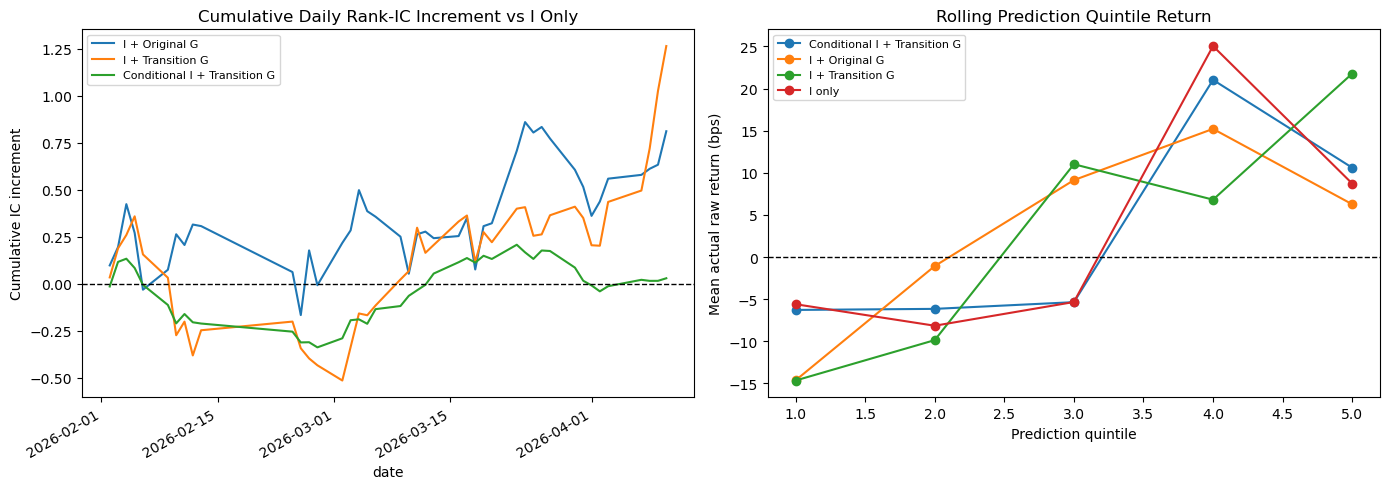

In [374]:
# 14.7 Required visual diagnostics.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, difference in paired_ic_differences_14.items():
    difference.sort_index().cumsum().plot(ax=axes[0], label=name)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Cumulative Daily Rank-IC Increment vs I Only")
axes[0].set_ylabel("Cumulative IC increment")
axes[0].legend(fontsize=8)

plot_rows_14 = []
for name, group in frozen_candidate_predictions_14.groupby(
    "candidate", observed=True
):
    work = group.copy()
    work["prediction_quintile"] = work.groupby(
        "date", observed=True
    )["predicted_return_5m"].transform(
        lambda s: pd.qcut(
            s.rank(method="first"), 5, labels=False
        ) + 1 if len(s) >= 5 else np.nan
    )
    means = work.groupby(
        "prediction_quintile", observed=True
    )["actual_return_5m"].mean() * 1e4
    for quintile, value in means.items():
        plot_rows_14.append({
            "candidate": name,
            "prediction_quintile": quintile,
            "mean_actual_return_bps": value,
        })
plot_df_14 = pd.DataFrame(plot_rows_14)
for name, group in plot_df_14.groupby("candidate", observed=True):
    axes[1].plot(
        group["prediction_quintile"],
        group["mean_actual_return_bps"],
        marker="o",
        label=name,
    )
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Rolling Prediction Quintile Return")
axes[1].set_xlabel("Prediction quintile")
axes[1].set_ylabel("Mean actual raw return (bps)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


本阶段在原始五档盘口不平衡A的基础上，进一步区分了竞价阶段已经表达的压力和09:30新增盘口信息。结果显示，Opening Innovation I比Raw A具有更高且更稳定的五分钟收益排序能力。随后对gap reversal进行来源拆解，发现I与G横截面相关性接近0，互相控制后仍保留正IC，说明两者代表相对独立的信息。进一步看，G的有效部分更可能来自09:25竞价价格到09:30开盘价格之间的二次定价，而不是单纯的竞价阶段gap。开发样本中I与Transition G等权组合的Mean daily IC达到0.128，Q5−Q1约34 bps，均高于I only，但配对block bootstrap正增量概率为87.6%，尚未达到预设90%晋级标准。因此目前将I冻结为baseline，将I+Transition G锁定为future-holdout challenger，下一步不再调整权重，直接用新增日期和更大分层股票池验证。

# Part XV — True Future Holdout: Frozen I–G Validation

本节只使用2026-04-14之后、从未参与因子发现和权重选择的新日期。冻结比较：

```text
Baseline             = I only
Primary challenger   = 0.5 × I + 0.5 × Transition G
Secondary challenger = 0.5 × I + 0.5 × Original G
```

其中：

- `I`：09:30五档盘口Rank中，无法被09:25最终竞价深度Rank解释的同日横截面残差；
- `Original G`：市场调整后完整09:30 gap的反转Rank；
- `Transition G`：市场调整后09:25→09:30二次定价反转Rank中，无法被I解释的残差。

本节不修改因子、权重、流动性阈值或晋级标准。


In [375]:
# 15.1 Load and audit the three isolated holdout exports.
from pathlib import Path
import math
import numpy as np
import pandas as pd

NOTEBOOK_DIR_15 = Path(
    r"C:\Users\work\OneDrive\Documents\level2-research\notebooks"
)
FEATURE_PATH_15 = NOTEBOOK_DIR_15 / "04b_holdout_auction_feature_table.csv"
TRANSMISSION_PATH_15 = (
    NOTEBOOK_DIR_15 / "04b_holdout_information_transmission_features.csv"
)
OPEN_LABEL_PATH_15 = (
    NOTEBOOK_DIR_15 / "04b_holdout_opening_label_table.csv"
)
for path in [FEATURE_PATH_15, TRANSMISSION_PATH_15, OPEN_LABEL_PATH_15]:
    assert path.exists(), f"Missing holdout export: {path}"

feature_15 = pd.read_csv(FEATURE_PATH_15)
transmission_15 = pd.read_csv(TRANSMISSION_PATH_15)
open_label_15 = pd.read_csv(OPEN_LABEL_PATH_15)
for frame in [feature_15, transmission_15, open_label_15]:
    frame["code"] = frame["code"].astype(str).str.strip().str.upper()
    frame["date"] = pd.to_datetime(
        frame["date"], errors="raise"
    ).dt.tz_localize(None)
    assert not frame.duplicated(["code", "date"]).any()

HOLDOUT_START_15 = pd.Timestamp("2026-04-14")
assert feature_15["date"].min() >= HOLDOUT_START_15
assert transmission_15["date"].min() >= HOLDOUT_START_15
assert open_label_15["date"].min() >= HOLDOUT_START_15

holdout_df_15 = (
    feature_15.merge(
        transmission_15,
        on=["code", "date"],
        how="inner",
        validate="one_to_one",
        suffixes=("", "__transmission"),
    )
    .merge(
        open_label_15,
        on=["code", "date"],
        how="inner",
        validate="one_to_one",
        suffixes=("", "__opening"),
    )
)
assert len(holdout_df_15) >= 0.95 * len(feature_15)
assert holdout_df_15["date"].nunique() >= 40
assert holdout_df_15["code"].nunique() == 40

holdout_audit_15 = pd.DataFrame([{
    "n_rows": len(holdout_df_15),
    "n_dates": holdout_df_15["date"].nunique(),
    "n_stocks": holdout_df_15["code"].nunique(),
    "first_date": holdout_df_15["date"].min(),
    "last_date": holdout_df_15["date"].max(),
    "feature_to_common_key_coverage": len(holdout_df_15) / len(feature_15),
    "duplicate_keys": holdout_df_15.duplicated(["code", "date"]).sum(),
}])
display(holdout_audit_15)


,n_rows,n_dates,n_stocks,first_date,last_date,feature_to_common_key_coverage,duplicate_keys
0,1980,50,40,2026-04-14,2026-06-26,0.994975,0


## 15.2 按冻结定义重建I与两个G

所有Rank和残差都只使用同日上午的横截面，不使用09:30–09:35标签。因而可以在holdout
中机械构造，但不能根据结果修改公式。


In [376]:
# 15.2 Rebuild the frozen scores without using the holdout target.
required_columns_15 = {
    "code", "date", "final_depth_imbalance", "auction_price",
    "strict_opening_depth_imbalance_5", "strict_mid_0930",
    "pre_close", "future_return_5m_raw",
}
missing_columns_15 = sorted(
    required_columns_15.difference(holdout_df_15.columns)
)
assert not missing_columns_15, (
    f"Holdout inputs are missing: {missing_columns_15}"
)
for column in required_columns_15.difference({"code", "date"}):
    holdout_df_15[column] = pd.to_numeric(
        holdout_df_15[column], errors="coerce"
    )

def _rank_score_15(series):
    return 2.0 * series.rank(pct=True, method="average") - 1.0

def _residualize_by_date_15(frame, dependent, control, output):
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    for _, daily in frame.groupby("date", observed=True, sort=True):
        valid = daily[[dependent, control]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        if len(valid) < 8 or valid[control].nunique() < 3:
            continue
        x = np.column_stack([
            np.ones(len(valid)),
            valid[control].to_numpy(float),
        ])
        y = valid[dependent].to_numpy(float)
        fitted = x @ np.linalg.lstsq(x, y, rcond=None)[0]
        result.loc[valid.index] = y - fitted
    frame[output] = result

# Frozen I: opening depth innovation beyond final auction depth.
holdout_df_15["A_opening_rank_15"] = holdout_df_15.groupby(
    "date", observed=True
)["strict_opening_depth_imbalance_5"].transform(_rank_score_15)
holdout_df_15["auction_final_depth_rank_15"] = holdout_df_15.groupby(
    "date", observed=True
)["final_depth_imbalance"].transform(_rank_score_15)
_residualize_by_date_15(
    holdout_df_15,
    dependent="A_opening_rank_15",
    control="auction_final_depth_rank_15",
    output="I_raw_residual_15",
)
holdout_df_15["I_score_15"] = holdout_df_15.groupby(
    "date", observed=True
)["I_raw_residual_15"].transform(_rank_score_15)

# Frozen Original G: reversal of market-adjusted full 09:30 gap.
holdout_df_15["full_0930_gap_15"] = (
    holdout_df_15["strict_mid_0930"]
    / holdout_df_15["pre_close"].replace(0, np.nan) - 1.0
)
holdout_df_15["market_adjusted_full_gap_15"] = (
    holdout_df_15["full_0930_gap_15"]
    - holdout_df_15.groupby("date", observed=True)[
        "full_0930_gap_15"
    ].transform("median")
)
holdout_df_15["Original_G_score_15"] = holdout_df_15.groupby(
    "date", observed=True
)["market_adjusted_full_gap_15"].transform(
    lambda s: _rank_score_15(-s)
)

# Frozen Transition G: reversal of market-adjusted 09:25→09:30 repricing.
holdout_df_15["auction_to_open_return_15"] = (
    holdout_df_15["strict_mid_0930"]
    / holdout_df_15["auction_price"].replace(0, np.nan) - 1.0
)
holdout_df_15["market_adjusted_transition_15"] = (
    holdout_df_15["auction_to_open_return_15"]
    - holdout_df_15.groupby("date", observed=True)[
        "auction_to_open_return_15"
    ].transform("median")
)
holdout_df_15["Transition_G_raw_score_15"] = holdout_df_15.groupby(
    "date", observed=True
)["market_adjusted_transition_15"].transform(
    lambda s: _rank_score_15(-s)
)
_residualize_by_date_15(
    holdout_df_15,
    dependent="Transition_G_raw_score_15",
    control="I_score_15",
    output="Transition_G_residual_15",
)
holdout_df_15["Transition_G_score_15"] = holdout_df_15.groupby(
    "date", observed=True
)["Transition_G_residual_15"].transform(_rank_score_15)

holdout_df_15["candidate__I_only_15"] = holdout_df_15["I_score_15"]
holdout_df_15["candidate__I_original_G_15"] = (
    0.5 * holdout_df_15["I_score_15"]
    + 0.5 * holdout_df_15["Original_G_score_15"]
)
holdout_df_15["candidate__I_transition_G_15"] = (
    0.5 * holdout_df_15["I_score_15"]
    + 0.5 * holdout_df_15["Transition_G_score_15"]
)

HOLDOUT_CANDIDATES_15 = {
    "I only": "candidate__I_only_15",
    "I + Original G": "candidate__I_original_G_15",
    "I + Transition G": "candidate__I_transition_G_15",
}
for column in HOLDOUT_CANDIDATES_15.values():
    holdout_df_15[column] = holdout_df_15.groupby(
        "date", observed=True
    )[column].transform(_rank_score_15)

# Evaluation targets are created only after all frozen scores are complete.
holdout_df_15["future_excess_return_5m_15"] = (
    holdout_df_15["future_return_5m_raw"]
    - holdout_df_15.groupby("date", observed=True)[
        "future_return_5m_raw"
    ].transform("mean")
)
coverage_15 = pd.DataFrame([
    {
        "signal": name,
        "coverage_ratio": holdout_df_15[column].notna().mean(),
        "n_dates": holdout_df_15.loc[
            holdout_df_15[column].notna(), "date"
        ].nunique(),
    }
    for name, column in HOLDOUT_CANDIDATES_15.items()
])
display(coverage_15)


,signal,coverage_ratio,n_dates
0,I only,1.000000,50
1,I + Original G,1.000000,50
2,I + Transition G,0.995455,50


## 15.3 真正holdout上的IC、方向与分组收益


In [377]:
# 15.3 Frozen factor performance on untouched dates.
def _daily_ic_15(frame, feature, target):
    rows = []
    for date, daily in frame.groupby("date", observed=True, sort=True):
        valid = daily[[feature, target]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        if (
            len(valid) >= 8
            and valid[feature].nunique() >= 3
            and valid[target].nunique() >= 3
        ):
            rows.append({
                "date": date,
                "daily_rank_ic": valid[feature].corr(
                    valid[target], method="spearman"
                ),
            })
    return pd.DataFrame(rows)

def _daily_q5_15(frame, feature, target):
    rows = []
    for date, daily in frame.groupby("date", observed=True, sort=True):
        valid = daily[[feature, target]].dropna().copy()
        if len(valid) < 10 or valid[feature].nunique() < 5:
            continue
        valid["bucket"] = pd.qcut(
            valid[feature].rank(method="first"),
            5, labels=False,
        ) + 1
        means = valid.groupby("bucket", observed=True)[target].mean()
        rows.append({
            "date": date,
            "q5_q1_bps": (means.loc[5] - means.loc[1]) * 1e4,
        })
    return pd.DataFrame(rows)

holdout_daily_ic_15 = {}
holdout_daily_q5_15 = {}
summary_rows_15 = []
for name, column in HOLDOUT_CANDIDATES_15.items():
    daily_ic = _daily_ic_15(
        holdout_df_15, column, "future_excess_return_5m_15"
    )
    daily_q = _daily_q5_15(
        holdout_df_15, column, "future_excess_return_5m_15"
    )
    holdout_daily_ic_15[name] = daily_ic.set_index(
        "date"
    )["daily_rank_ic"]
    holdout_daily_q5_15[name] = daily_q.set_index("date")["q5_q1_bps"]
    values = daily_ic["daily_rank_ic"]
    valid = holdout_df_15[[column, "future_excess_return_5m_15"]].dropna()
    summary_rows_15.append({
        "candidate": name,
        "n_obs": len(valid),
        "n_dates": len(values),
        "mean_daily_rank_ic": values.mean(),
        "median_daily_rank_ic": values.median(),
        "daily_ic_std": values.std(ddof=1),
        "positive_daily_ic_ratio": (values > 0).mean(),
        "icir": values.mean() / values.std(ddof=1),
        "direction_accuracy": (
            np.sign(valid[column])
            == np.sign(valid["future_excess_return_5m_15"])
        ).mean(),
        "mean_daily_q5_q1_bps": daily_q["q5_q1_bps"].mean(),
        "median_daily_q5_q1_bps": daily_q["q5_q1_bps"].median(),
        "positive_q5_q1_day_ratio": (daily_q["q5_q1_bps"] > 0).mean(),
    })
true_holdout_factor_summary_15 = pd.DataFrame(summary_rows_15)
display(true_holdout_factor_summary_15.sort_values(
    "mean_daily_rank_ic", ascending=False
))


,candidate,n_obs,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,direction_accuracy,mean_daily_q5_q1_bps,median_daily_q5_q1_bps,positive_q5_q1_day_ratio
1,I + Original G,1980,50,0.152754,0.140580,0.145237,0.86,1.051755,0.541919,52.488444,46.014388,0.74
2,I + Transition G,1971,50,0.106817,0.091543,0.170745,0.74,0.625595,0.529680,32.593256,41.744492,0.70
0,I only,1980,50,0.098803,0.112101,0.186892,0.70,0.528664,0.526768,38.451607,41.656282,0.72


## 15.4 相对I的同日期增量与预注册统计检验


In [378]:
# 15.4 Moving-block bootstrap of paired increments.
def _block_means_15(values, block_length=5, n_boot=10000, seed=20260815):
    arr = pd.Series(values).dropna().to_numpy(float)
    if len(arr) < 3:
        return np.array([])
    block_length = max(1, min(block_length, len(arr)))
    starts = np.arange(0, len(arr) - block_length + 1)
    rng = np.random.default_rng(seed)
    output = np.empty(n_boot)
    for i in range(n_boot):
        sampled = []
        while len(sampled) < len(arr):
            start = rng.choice(starts)
            sampled.extend(arr[start:start + block_length])
        output[i] = np.mean(sampled[:len(arr)])
    return output

baseline_ic_15 = holdout_daily_ic_15["I only"]
baseline_q_15 = holdout_daily_q5_15["I only"]
increment_rows_15 = []
for name in ["I + Original G", "I + Transition G"]:
    paired_ic = pd.concat(
        [baseline_ic_15.rename("I"), holdout_daily_ic_15[name].rename("candidate")],
        axis=1,
    ).dropna()
    ic_difference = paired_ic["candidate"] - paired_ic["I"]
    ic_boot = _block_means_15(ic_difference)
    paired_q = pd.concat(
        [baseline_q_15.rename("I"), holdout_daily_q5_15[name].rename("candidate")],
        axis=1,
    ).dropna()
    q_difference = paired_q["candidate"] - paired_q["I"]
    q_boot = _block_means_15(q_difference, seed=20260816)
    increment_rows_15.append({
        "candidate": name,
        "n_paired_dates": len(ic_difference),
        "mean_ic_increment": ic_difference.mean(),
        "median_ic_increment": ic_difference.median(),
        "positive_ic_increment_ratio": (ic_difference > 0).mean(),
        "ic_increment_ci_low": np.quantile(ic_boot, 0.025),
        "ic_increment_ci_high": np.quantile(ic_boot, 0.975),
        "probability_ic_increment_positive": np.mean(ic_boot > 0),
        "mean_q5_q1_increment_bps": q_difference.mean(),
        "probability_q5_q1_increment_positive": np.mean(q_boot > 0),
    })
true_holdout_increment_summary_15 = pd.DataFrame(increment_rows_15)
display(true_holdout_increment_summary_15)


,candidate,n_paired_dates,mean_ic_increment,median_ic_increment,positive_ic_increment_ratio,ic_increment_ci_low,ic_increment_ci_high,probability_ic_increment_positive,mean_q5_q1_increment_bps,probability_q5_q1_increment_positive
0,I + Original G,50,0.053951,0.046742,0.58,0.012532,0.089707,0.9947,14.036837,0.7870
1,I + Transition G,50,0.008014,0.005571,0.54,-0.022481,0.036675,0.6845,-5.858351,0.3528


## 15.5 用开发期冻结尺度输出带单位收益率

只有收益率尺度映射使用旧开发样本。holdout标签不参与系数估计。


In [379]:
# 15.5 Fit calibration only on the old development sample and apply once.
required_development_15 = {"frozen_ig_df", "RAW_TARGET_X"}
missing_development_15 = sorted(
    name for name in required_development_15 if name not in globals()
)
assert not missing_development_15, (
    f"Missing Part XIV development objects: {missing_development_15}. "
    "Run Part XIV 14.1 first; do not fit calibration on holdout labels."
)

development_column_map_15 = {
    "I only": "candidate__I_only",
    "I + Original G": "candidate__I_plus_original_G",
    "I + Transition G": "candidate__I_plus_transition_G",
}
prediction_parts_15 = []
calibration_rows_15 = []
for name, holdout_column in HOLDOUT_CANDIDATES_15.items():
    development_column = development_column_map_15[name]
    train = frozen_ig_df[
        [development_column, RAW_TARGET_X]
    ].replace([np.inf, -np.inf], np.nan).dropna()
    x = train[development_column].to_numpy(float)
    y = train[RAW_TARGET_X].to_numpy(float)
    design = np.column_stack([np.ones(len(x)), x])
    intercept, raw_slope = np.linalg.lstsq(design, y, rcond=None)[0]
    slope = max(float(raw_slope), 0.0)
    prediction = holdout_df_15[
        ["code", "date", holdout_column, "future_return_5m_raw"]
    ].dropna().copy()
    prediction["candidate"] = name
    prediction["predicted_return_5m"] = (
        intercept + slope * prediction[holdout_column]
    )
    prediction["frozen_intercept"] = intercept
    prediction["frozen_nonnegative_slope"] = slope
    prediction_parts_15.append(prediction)
    calibration_rows_15.append({
        "candidate": name,
        "development_n_obs": len(train),
        "frozen_intercept_bps": intercept * 1e4,
        "frozen_raw_slope": raw_slope,
        "frozen_nonnegative_slope": slope,
    })
true_holdout_predictions_15 = pd.concat(
    prediction_parts_15, ignore_index=True
)
true_holdout_calibration_15 = pd.DataFrame(calibration_rows_15)

prediction_rows_15 = []
for name, group in true_holdout_predictions_15.groupby(
    "candidate", observed=True, sort=False
):
    error = group["predicted_return_5m"] - group["future_return_5m_raw"]
    prediction_rows_15.append({
        "candidate": name,
        "n_obs": len(group),
        "n_dates": group["date"].nunique(),
        "mae_bps": error.abs().mean() * 1e4,
        "rmse_bps": np.sqrt(np.mean(error ** 2)) * 1e4,
        "direction_accuracy": (
            np.sign(group["predicted_return_5m"])
            == np.sign(group["future_return_5m_raw"])
        ).mean(),
        "prediction_std_bps": group["predicted_return_5m"].std() * 1e4,
        "actual_std_bps": group["future_return_5m_raw"].std() * 1e4,
    })
true_holdout_prediction_summary_15 = pd.DataFrame(prediction_rows_15)
display(true_holdout_calibration_15)
display(true_holdout_prediction_summary_15.sort_values("mae_bps"))
display(true_holdout_predictions_15.head(10))


,candidate,development_n_obs,frozen_intercept_bps,frozen_raw_slope,frozen_nonnegative_slope
0,I only,1707,2.130910,0.001938,0.001938
1,I + Original G,1707,2.100359,0.002060,0.002060
2,I + Transition G,1694,2.073036,0.002326,0.002326


,candidate,n_obs,n_dates,mae_bps,rmse_bps,direction_accuracy,prediction_std_bps,actual_std_bps
1,I + Original G,1980,50,109.028595,153.650165,0.520202,11.886994,153.915310
2,I + Transition G,1971,50,109.430429,154.291793,0.518011,13.423220,153.988372
0,I only,1980,50,109.485616,154.072598,0.506566,11.191153,153.915310


,code,date,candidate__I_only_15,future_return_5m_raw,candidate,predicted_return_5m,frozen_intercept,frozen_nonnegative_slope,candidate__I_original_G_15,candidate__I_transition_G_15
0,000713.SZ,2026-04-14,-0.15,-0.003127,I only,-0.000078,0.000213,0.001938,NaN,NaN
1,000713.SZ,2026-04-15,-0.70,-0.004669,I only,-0.001144,0.000213,0.001938,NaN,NaN
2,000713.SZ,2026-04-16,0.15,-0.004640,I only,0.000504,0.000213,0.001938,NaN,NaN
3,000713.SZ,2026-04-17,0.55,0.010598,I only,0.001279,0.000213,0.001938,NaN,NaN
4,000713.SZ,2026-04-20,0.90,0.006130,I only,0.001958,0.000213,0.001938,NaN,NaN
5,000713.SZ,2026-04-21,0.30,0.002309,I only,0.000795,0.000213,0.001938,NaN,NaN
6,000713.SZ,2026-04-22,-0.25,0.003103,I only,-0.000272,0.000213,0.001938,NaN,NaN
7,000713.SZ,2026-04-23,-0.05,-0.004677,I only,0.000116,0.000213,0.001938,NaN,NaN
8,000713.SZ,2026-04-24,0.40,0.009266,I only,0.000988,0.000213,0.001938,NaN,NaN
9,000713.SZ,2026-04-27,-0.70,-0.006065,I only,-0.001144,0.000213,0.001938,NaN,NaN


## 15.6 最终接受或拒绝

预注册通过条件：

1. Mean Daily IC增量为正；
2. IC增量为正日期比例超过50%；
3. Moving-block bootstrap `P(IC increment > 0) ≥ 90%`；
4. Mean Q5−Q1不低于I；
5. MAE或RMSE至少一项改善，另一项不能明显恶化。


In [380]:
# 15.6 Apply the frozen promotion rule.
baseline_prediction_metrics_15 = (
    true_holdout_prediction_summary_15.set_index("candidate").loc["I only"]
)
decision_rows_15 = []
for _, increment in true_holdout_increment_summary_15.iterrows():
    name = increment["candidate"]
    prediction_metrics = (
        true_holdout_prediction_summary_15.set_index("candidate").loc[name]
    )
    mae_difference = (
        prediction_metrics["mae_bps"]
        - baseline_prediction_metrics_15["mae_bps"]
    )
    rmse_difference = (
        prediction_metrics["rmse_bps"]
        - baseline_prediction_metrics_15["rmse_bps"]
    )
    criteria = {
        "mean_ic_increment_positive": increment["mean_ic_increment"] > 0,
        "positive_increment_ratio_over_half": (
            increment["positive_ic_increment_ratio"] > 0.50
        ),
        "bootstrap_probability_at_least_90pct": (
            increment["probability_ic_increment_positive"] >= 0.90
        ),
        "q5_q1_not_worse": increment["mean_q5_q1_increment_bps"] >= 0,
        "error_not_worse": (
            (mae_difference <= 0 and rmse_difference <= 1.0)
            or (rmse_difference <= 0 and mae_difference <= 1.0)
        ),
    }
    decision_rows_15.append({
        "candidate": name,
        "mean_ic_increment": increment["mean_ic_increment"],
        "positive_ic_increment_ratio": increment[
            "positive_ic_increment_ratio"
        ],
        "probability_ic_increment_positive": increment[
            "probability_ic_increment_positive"
        ],
        "mean_q5_q1_increment_bps": increment[
            "mean_q5_q1_increment_bps"
        ],
        "mae_difference_bps": mae_difference,
        "rmse_difference_bps": rmse_difference,
        "n_criteria_passed": sum(criteria.values()),
        "all_promotion_criteria_pass": all(criteria.values()),
        "final_decision": (
            "PROMOTE over I"
            if all(criteria.values())
            else "DO NOT PROMOTE; retain I baseline"
        ),
    })
true_holdout_decision_15 = pd.DataFrame(decision_rows_15)
display(true_holdout_decision_15)


,candidate,mean_ic_increment,positive_ic_increment_ratio,probability_ic_increment_positive,mean_q5_q1_increment_bps,mae_difference_bps,rmse_difference_bps,n_criteria_passed,all_promotion_criteria_pass,final_decision
0,I + Original G,0.053951,0.58,0.9947,14.036837,-0.457021,-0.422433,5,True,PROMOTE over I
1,I + Transition G,0.008014,0.54,0.6845,-5.858351,-0.055186,0.219195,3,False,DO NOT PROMOTE; retain I baseline


## 15.7 交付图：每日IC与累计增量


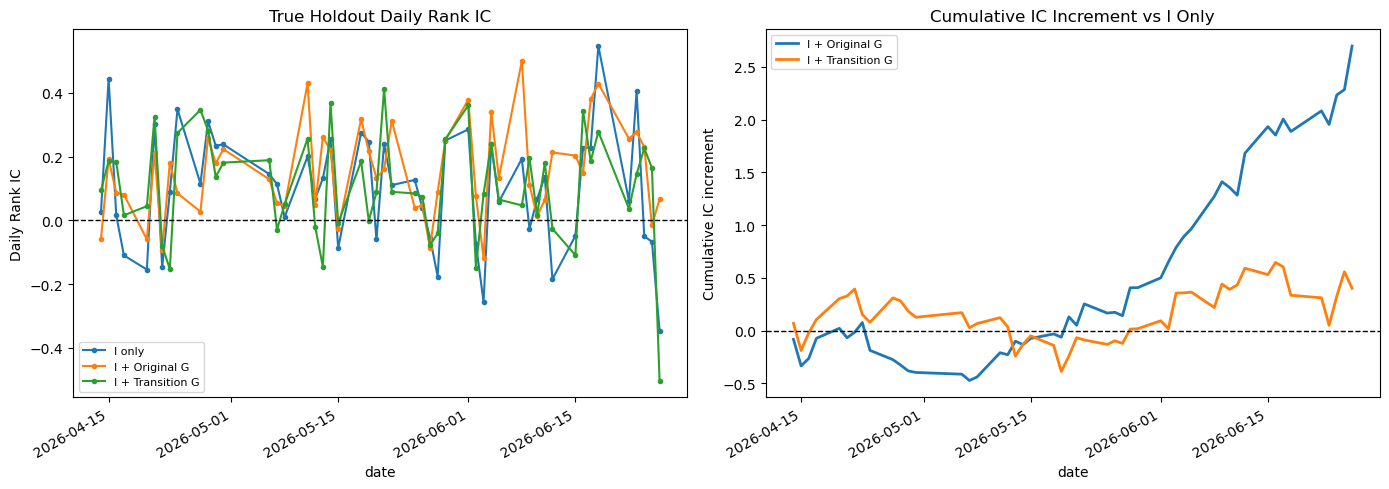

In [381]:
# 15.7 Visual holdout evidence.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, daily_ic in holdout_daily_ic_15.items():
    daily_ic.sort_index().plot(ax=axes[0], marker="o", markersize=3, label=name)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("True Holdout Daily Rank IC")
axes[0].set_ylabel("Daily Rank IC")
axes[0].legend(fontsize=8)

for name in ["I + Original G", "I + Transition G"]:
    difference = (
        holdout_daily_ic_15[name] - holdout_daily_ic_15["I only"]
    ).dropna()
    difference.sort_index().cumsum().plot(
        ax=axes[1], linewidth=2, label=name
    )
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Cumulative IC Increment vs I Only")
axes[1].set_ylabel("Cumulative IC increment")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
